<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/Multi_Task_GEDI_L1B_L2A_L2B_Native_EO_Res_Multi_Branch_Multi_Task_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Roadmap

Stage 0

0- Prep Data

Stage 1

1 — Embeddings	Train images	Train embeddings	frozen

1 — Embeddings	Val & test images	Val/test embeddings	frozen

Mulit-Task

┌────────────────────┐

│  Stage 1 Encoders  │  ← Already trained (don't retrain)

│  (8 modalities)    │

└─────────┬──────────┘

        │

┌────▼────────┐

│ Embeddings  │  

    
│ [8×64×128]  │

└─────┬───────┘

          │

┌─────▼───────┐

│   Fusion    │  ← Shared fusion layers

│ (Attention/ │

│   MLP/etc)  │

└─────┬───────┘

          │

 ┌─────┴──────┬─────────┬────────┐

   │..................................│.........................│ ......................│

┌──▼──┐ ..   ┌───▼───┐ .. ┌──▼───┐ ..┌──▼────┐

│ RH  .........│  ..│  PAI  ..............│ .. │ FHD ........  │ .. │ Other ........│

│ Head  .....│  ..│  Head  ..........│ .. │ Head .......│ .. │ Tasks ........│




Stage 2

2 — Fusion training	Train embeddings	Fusion model	learn to predict RH

2 — Fusion validation	Val embeddings	Val loss / metrics	tune

2 — Fusion test	Test embeddings	Test metrics	evaluate

Stage 3

3 — Inference	New imagery (2024)	Predicted RH map

Stage 4

4 — Evaluation with in situ measurements

# Stage 0

In [1]:
!pip install rasterio torch torchinfo tqdm matplotlib timm torchmetrics --quiet
!pip install -U kaleido

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    '2024_Imagery_For_Inference',
    'Multi_Task_Implementation',
    'data_32_32_patches_11_4_25',
    'target_data',
    'data',
    'data_NaN_filtered',
    'models',
    "model_animations",
    'scripts',
    'notebooks',
    'config',
    'results',
    'prediction_surface'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/model_animations
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config


# GEDIL2A Imagery Prep

## Sort Find Prep data

In [4]:
import os

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Output directory:", PROCESSED_DIR)


Output directory: /content/processed_32x32_normalized


In [5]:
import os
import re
from collections import Counter

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"


In [6]:
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)


In [7]:
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith(".tif")]

selected_files = []
splits = []

for filename in tif_files:
    m = pattern.match(filename)
    if m:
        if m.group("product_field") == "GEDI_L2A":
            selected_files.append(filename)
            splits.append(m.group("split"))


In [8]:
split_counts = Counter(splits)
split_counts


Counter({'train': 5227, 'val': 673, 'test': 1187})

In [9]:
print("Found", len(selected_files), "TIFFs with product_field = GEDI_L2A")

print("\nSplit counts:")
for k, v in split_counts.items():
    print(f"{k}: {v}")

print("\nFirst 10 selected TIFFs:")
for f in selected_files[:10]:
    print(f)


Found 7087 TIFFs with product_field = GEDI_L2A

Split counts:
train: 5227
val: 673
test: 1187

First 10 selected TIFFs:
s2_train_GEDI_L2A_2022358084911_1728_block_5963890.tif
s2_train_GEDI_L2A_2021135083748_1132_block_6013891.tif
s2_val_GEDI_L2A_2021135083748_665_block_6023891.tif
s2_val_GEDI_L2A_2021135083748_173_block_6023893.tif
s2_train_GEDI_L2A_2022358084911_821_block_5993895.tif
s2_train_GEDI_L2A_2022358084911_833_block_6003895.tif
s2_train_GEDI_L2A_2021135083748_623_block_6003894.tif
s2_train_GEDI_L2A_2022358084911_795_block_5983894.tif
s2_train_GEDI_L2A_2022358084911_1186_block_5923887.tif
s2_train_GEDI_L2A_2022139064237_222_block_5933888.tif


## Move Selected files

In [10]:
import os
import shutil

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"
PROCESSED_DIR = "/content/processed_32x32_normalized"

os.makedirs(PROCESSED_DIR, exist_ok=True)

moved = 0
missing = 0

for fname in selected_files:
    src = os.path.join(RASTER_DIR, fname)
    dst = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)   # or use shutil.move(src, dst) if you want to REMOVE originals
        moved += 1
    else:
        print("❗ MISSING FILE:", fname)
        missing += 1

print("=====================================")
print("Selected files moved:", moved)
print("Missing source files:", missing)
print("Destination folder:", PROCESSED_DIR)


Selected files moved: 7087
Missing source files: 0
Destination folder: /content/processed_32x32_normalized


## Investigate a set of Tifs before modifying/prepping

In [11]:
import random

sample_files = random.sample(selected_files, 5)
sample_files


['dem_train_GEDI_L2A_2022358084911_424_block_6023899.tif',
 'dem_test_GEDI_L2A_2022358084911_1693_block_5943888.tif',
 'tcap_train_GEDI_L2A_2022358084911_1361_block_6033898.tif',
 's1_train_GEDI_L2A_2021135083748_1594_block_5993892.tif',
 'tcap_train_GEDI_L2A_2022358084911_393_block_6003897.tif']


FILE: dem_train_GEDI_L2A_2022358084911_424_block_6023899.tif
BANDS: 2
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  563.0
      max:  603.4730834960938
      mean: 590.6207695608429
      std:  7.2740679039480405

  Band 2 statistics:
      min:  0.28220483660697937
      max:  22.550207138061523
      mean: 6.608423932537888
      std:  4.1434919210647125
Skipping visualization for dem_train_GEDI_L2A_2022358084911_424_block_6023899.tif: not enough bands for RGB or single band.


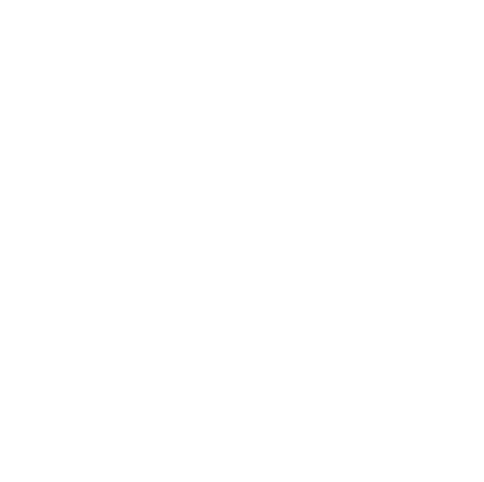


FILE: dem_test_GEDI_L2A_2022358084911_1693_block_5943888.tif
BANDS: 2
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  315.33026123046875
      max:  568.2742309570312
      mean: 417.0797596759762
      std:  51.28627576409135

  Band 2 statistics:
      min:  1.0439342260360718
      max:  26.1994571685791
      mean: 12.882733345137986
      std:  3.8903506860749566
Skipping visualization for dem_test_GEDI_L2A_2022358084911_1693_block_5943888.tif: not enough bands for RGB or single band.


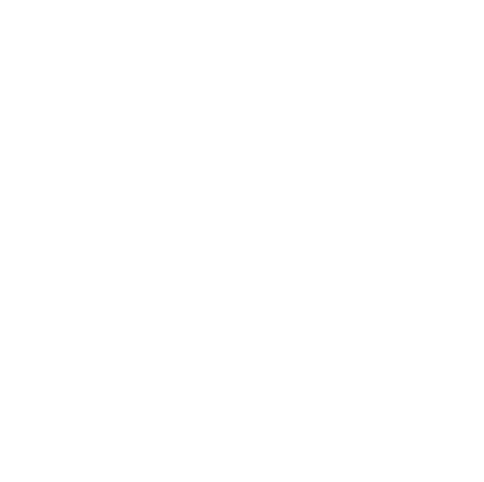


FILE: tcap_train_GEDI_L2A_2022358084911_1361_block_6033898.tif
BANDS: 6
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.11773314327001572
      max:  0.5064979195594788
      mean: 0.3227864069697299
      std:  0.04518831602079983

  Band 2 statistics:
      min:  -0.05707325413823128
      max:  0.17695532739162445
      mean: 0.09851834353509017
      std:  0.033933472941058695

  Band 3 statistics:
      min:  -0.19188305735588074
      max:  0.05122761055827141
      mean: -0.020843008364802115
      std:  0.026799968581919454

  Band 4 statistics:
      min:  -0.09095930308103561
      max:  -0.023669593036174774
      mean: -0.046562138776306806
      std:  0.0045028984298822825

  Band 5 statistics:
      min:  -0.01881510019302368
      max:  0.11378113180398941
      mean: 0.009178778620270944
      std:  0.014027386975279861

  Band 6 statistics:
      min:  -0.05322480574250221
      max:  -0.014

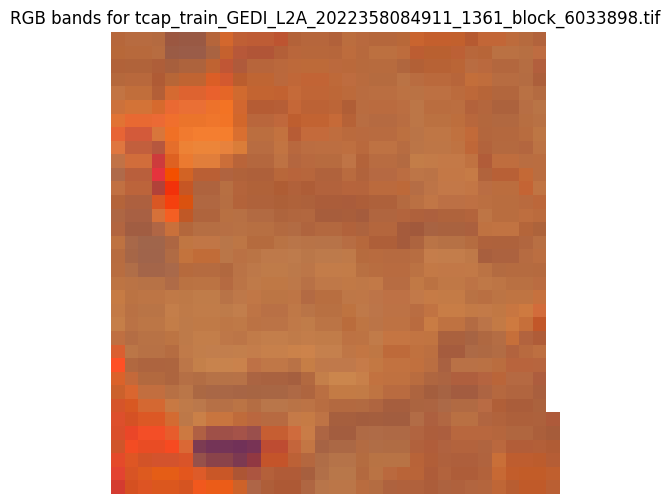


FILE: s1_train_GEDI_L2A_2021135083748_1594_block_5993892.tif
BANDS: 4
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 10.0 x 10.0 (approx meters)

  Band 1 statistics:
      min:  -12.618089180722269
      max:  -4.064560197159701
      mean: -6.916182355214418
      std:  1.1339346709915654

  Band 2 statistics:
      min:  -18.802714046507305
      max:  -10.945917421613006
      mean: -13.085301324814182
      std:  1.0934198935437671

  Band 3 statistics:
      min:  0.35740081225921627
      max:  0.6827670066766038
      mean: 0.5258473693644047
      std:  0.0446649091796823

  Band 4 statistics:
      min:  -0.47340415736989383
      max:  -0.18851866720985838
      mean: -0.31187449407801787
      std:  0.03857440765583707


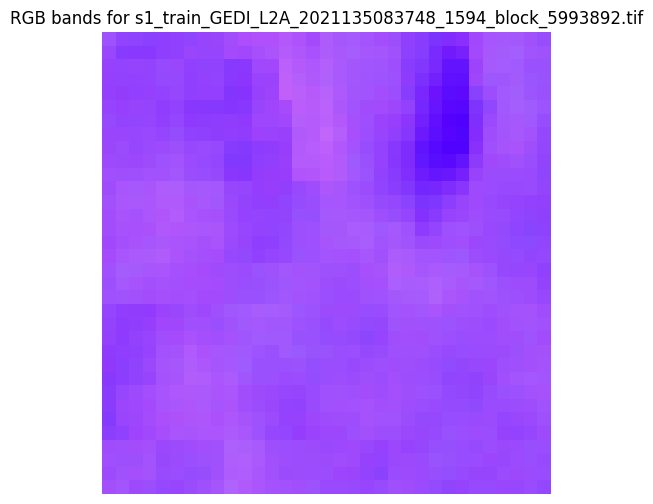


FILE: tcap_train_GEDI_L2A_2022358084911_393_block_6003897.tif
BANDS: 6
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.07322965562343597
      max:  0.7056575417518616
      mean: 0.327865638024773
      std:  0.07124907623865397

  Band 2 statistics:
      min:  -0.035099420696496964
      max:  0.2287808060646057
      mean: 0.08240699639636027
      std:  0.033121851112535114

  Band 3 statistics:
      min:  -0.20276114344596863
      max:  0.03514779359102249
      mean: -0.035282348928334296
      std:  0.030284781384213286

  Band 4 statistics:
      min:  -0.07440821081399918
      max:  -0.037768736481666565
      mean: -0.04816176443163193
      std:  0.003836152180285272

  Band 5 statistics:
      min:  -0.013721674680709839
      max:  0.10871560871601105
      mean: 0.018111322540562875
      std:  0.016041760300923323

  Band 6 statistics:
      min:  -0.054514553397893906
      max:  -0.01300

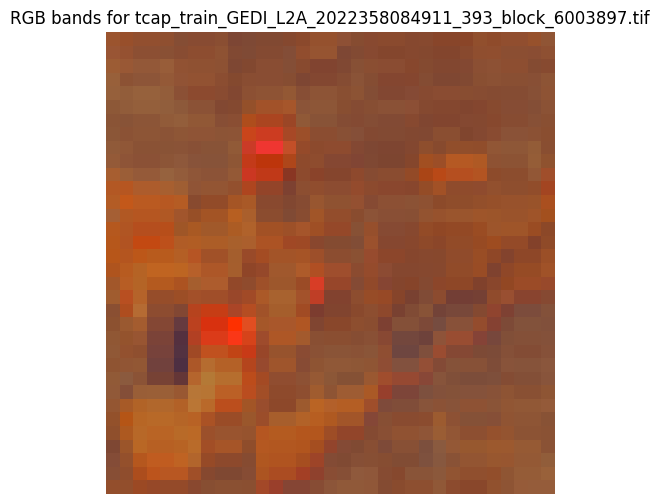

In [12]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files:
    fpath = os.path.join(RASTER_DIR, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {transform.e*-1} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b)
            data = data.astype(float)  # ensure numeric

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            band_min = np.nanmin(data)
            band_max = np.nanmax(data)
            band_mean = np.nanmean(data)
            band_std = np.nanstd(data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {band_min}")
            print(f"      max:  {band_max}")
            print(f"      mean: {band_mean}")
            print(f"      std:  {band_std}")

        # --- Visualization ---
        plt.figure(figsize=(6, 6))
        if count >= 3:
            # Read the first three bands for RGB visualization
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display (min-max)
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)
            plt.imshow(img)
            plt.title(f"RGB bands for {fname}")
        elif count == 1:
            # Read the single band for grayscale visualization
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Grayscale band for {fname}")
        else:
            print(f"Skipping visualization for {fname}: not enough bands for RGB or single band.")

        plt.axis('off')
        plt.show()

## Prep tifs: Pad, Normalize, inspect, save to content

In [13]:
from rasterio.enums import Resampling

def resize_to_max32(src):
    """
    Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
    Returns: resized array (bands, new_h, new_w) and updated transform
    """
    h = src.height
    w = src.width
    bands = src.count

    # No resizing needed
    if h <= 32 and w <= 32:
        return src.read(), src.transform

    scale_h = 32 / h
    scale_w = 32 / w
    scale = min(scale_h, scale_w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    resized = src.read(
        out_shape=(bands, new_h, new_w),
        resampling=Resampling.bilinear
    )

    # Update transform to match resized array
    new_transform = Affine(
        src.transform.a / scale, src.transform.b, src.transform.c,
        src.transform.d, src.transform.e / scale, src.transform.f
    )

    return resized, new_transform

In [14]:
import numpy as np

def pad_to_32x32(arr, transform):
    """Center-pad a raster to exactly (bands, 32, 32) and adjust transform."""
    bands, h, w = arr.shape
    padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

    h_start = (32 - h) // 2
    w_start = (32 - w) // 2

    padded[:, h_start:h_start+h, w_start:w_start+w] = arr

    # Adjust transform to account for padding
    new_transform = transform * Affine.translation(-w_start, -h_start)
    return padded, new_transform

In [15]:
def minmax_normalize(arr):
    arr = arr.astype(float)
    for b in range(arr.shape[0]):
        mn = np.nanmin(arr[b])
        mx = np.nanmax(arr[b])
        arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
    return arr

In [16]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# IMPROVED: Fill ALL NaNs with median (no dropping)
# -------------------------------------------------------------------------

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Scanning directory:", PROCESSED_DIR)

all_tifs = [
    f for f in os.listdir(PROCESSED_DIR)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0

print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

selected_files = []

for fname in all_tifs:
    fpath = os.path.join(PROCESSED_DIR, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True

            bands.append(data)

    # Fix ALL files with NaNs (no dropping!)
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                # Calculate median of non-NaN values
                med = np.nanmedian(data)
                # If entire band is NaN, use 0
                if np.isnan(med):
                    med = 0.0
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep ALL TIFFs for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped                 : 0")  # No more dropping!
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

Scanning directory: /content/processed_32x32_normalized

Found 7087 TIFFs in /content/processed_32x32_normalized

FIXING: s2idx_train_GEDI_L2A_2020196021509_495_block_5953899.tif (median fill)
FIXING: landsatidx_test_GEDI_L2A_2022139064237_229_block_5933887.tif (median fill)
FIXING: landsatidx_val_GEDI_L2A_2020196021509_7_block_5923897.tif (median fill)
FIXING: s2_test_GEDI_L2A_2022358084911_240_block_5923889.tif (median fill)
FIXING: hls_train_GEDI_L2A_2021135083748_503_block_5943899.tif (median fill)
FIXING: hls_train_GEDI_L2A_2020196021509_430_block_5923896.tif (median fill)
FIXING: tcap_train_GEDI_L2A_2020196021509_431_block_5923896.tif (median fill)
FIXING: dem_train_GEDI_L2A_2022358084911_1362_block_6033898.tif (median fill)
FIXING: tcap_train_GEDI_L2A_2020196021509_995_block_5963899.tif (median fill)
FIXING: landsatidx_train_GEDI_L2A_2021135083748_508_block_5943899.tif (median fill)
FIXING: landsatidx_train_GEDI_L2A_2020196021509_928_block_5923895.tif (median fill)
FIXING: dem_t

In [17]:
import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling
import numpy as np
import os


processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(PROCESSED_DIR, fname)
    out_path = os.path.join(PROCESSED_DIR, fname)   # overwrite or change if desired


    with rasterio.open(src_path) as src:
        # Step 1: Resize
        resized, transform_resized = resize_to_max32(src)

        # Step 2: Pad
        padded, transform_padded = pad_to_32x32(resized, transform_resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile.copy()
        profile.update({
            "height": 32,
            "width": 32,
            "transform": transform_padded,
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")


Processed 7087 TIFFs successfully.


## Compare before preprocessing

In [18]:
processed_sample_files = {}

for fname in sample_files:
    processed_path = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(processed_path):
        processed_sample_files[fname] = processed_path
    else:
        print(f"⚠️ WARNING: Processed version not found for {fname}")



PROCESSED FILE: dem_train_GEDI_L2A_2022358084911_424_block_6023899.tif
LOCATION: /content/processed_32x32_normalized/dem_train_GEDI_L2A_2022358084911_424_block_6023899.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.697327447396674
      std:  0.1519893496945513

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.2832336534324895
      std:  0.17473387853619468


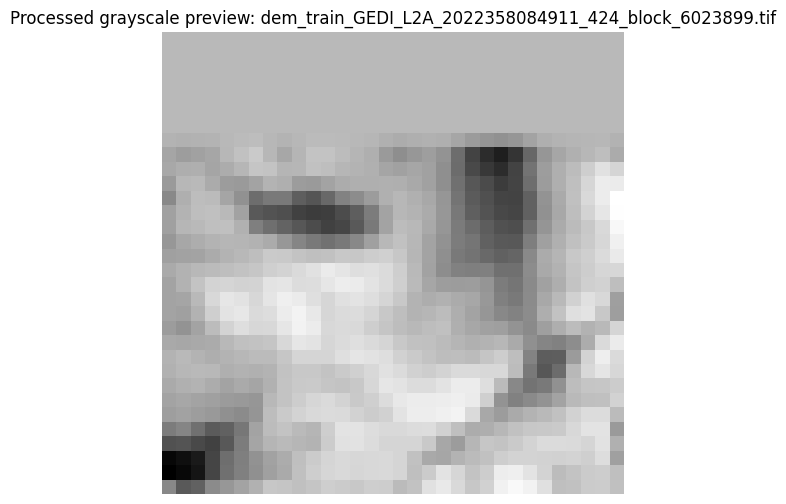


PROCESSED FILE: dem_test_GEDI_L2A_2022358084911_1693_block_5943888.tif
LOCATION: /content/processed_32x32_normalized/dem_test_GEDI_L2A_2022358084911_1693_block_5943888.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7123152654385194
      std:  0.15568954277834657

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5100925200531492
      std:  0.1660500130945193


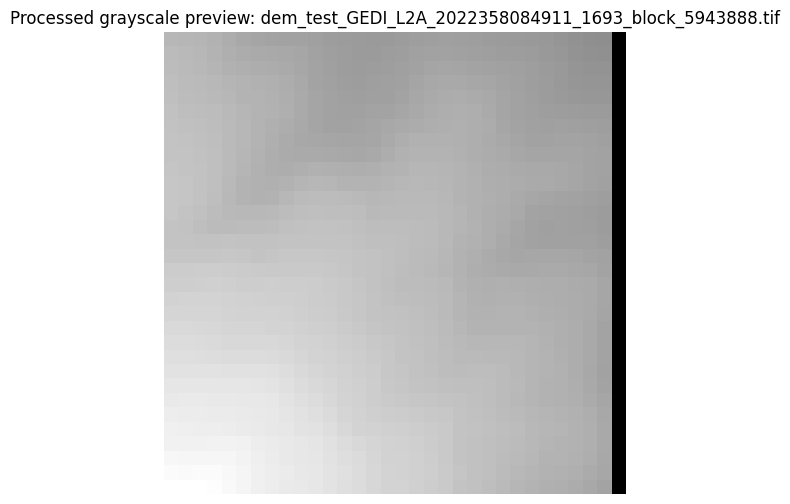


PROCESSED FILE: tcap_train_GEDI_L2A_2022358084911_1361_block_6033898.tif
LOCATION: /content/processed_32x32_normalized/tcap_train_GEDI_L2A_2022358084911_1361_block_6033898.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6600383740151301
      std:  0.14588908128925462

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6605774709241814
      std:  0.17100994904401934

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.685230212182887
      std:  0.13008372793240935

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.376880156196421
      std:  0.12422792211056544

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.23527487827072946
      std:  0.1427506767846674

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5134713525992538
      std:  0.11674653779619001


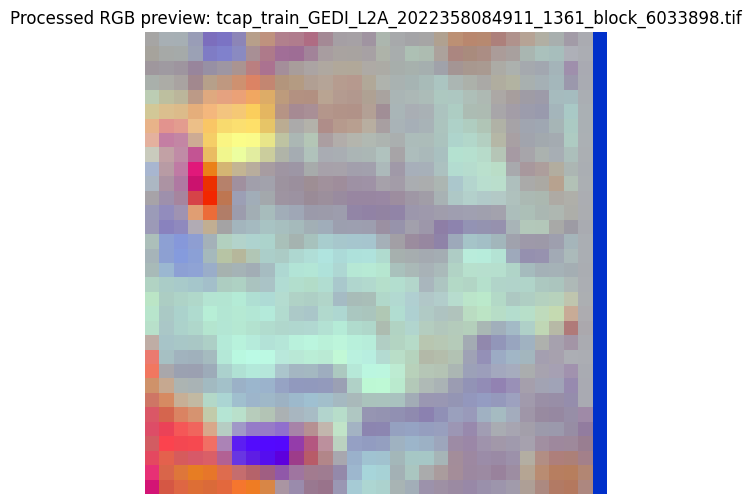


PROCESSED FILE: s1_train_GEDI_L2A_2021135083748_1594_block_5993892.tif
LOCATION: /content/processed_32x32_normalized/s1_train_GEDI_L2A_2021135083748_1594_block_5993892.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 10.625 x 10.625 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4626261589094156
      std:  0.12900758424455383

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3198545386076148
      std:  0.13407721400646908

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7576061102445237
      std:  0.14930814265529785

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3269330703333253
      std:  0.14472051513357478


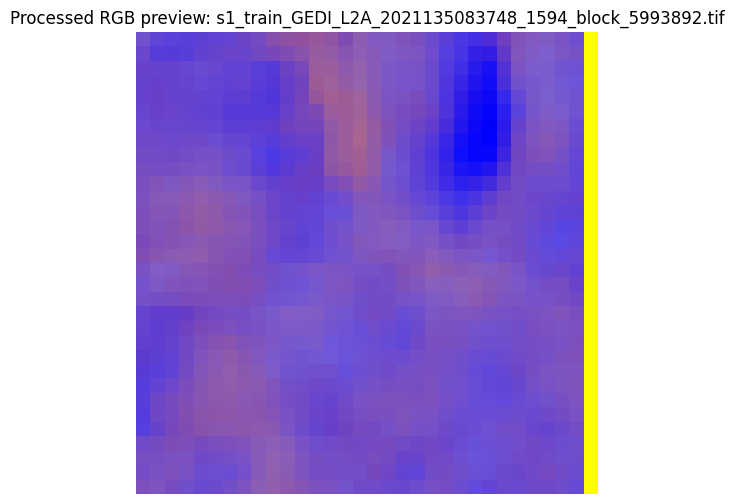


PROCESSED FILE: tcap_train_GEDI_L2A_2022358084911_393_block_6003897.tif
LOCATION: /content/processed_32x32_normalized/tcap_train_GEDI_L2A_2022358084911_393_block_6003897.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4952265085885301
      std:  0.13428480755500638

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.43743151540002145
      std:  0.14393115750717692

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6821374875726178
      std:  0.1533839390777127

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3324602913708077
      std:  0.12825090361387576

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.23644567977456177
      std:  0.14398030160216785

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5239568101387704
      std:  0.11916297253490442


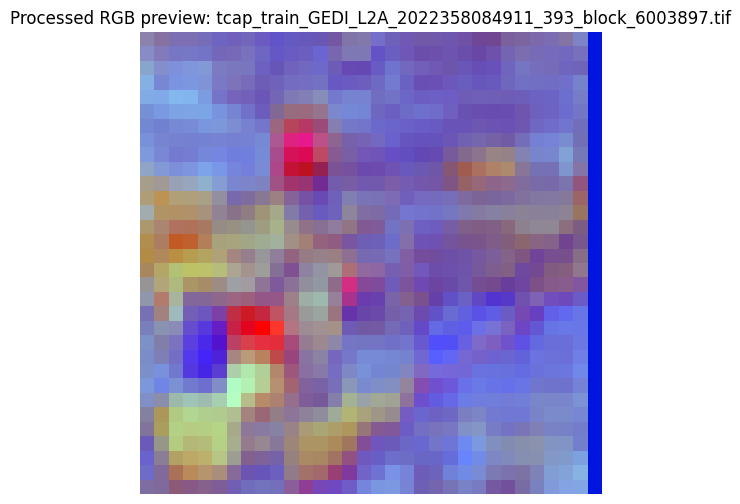

In [19]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (arbitrary)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


One time zip GEDI L2A preprocessed

In [ ]:
# # Path to the folder containing your TIFF chips
# tif_dir = "/content/processed_32x32_normalized"   # <-- CHANGE THIS

# # Name of the output zip file
# zip_path = "/content/GEDI_L2A_processed_32x32_normalized.zip"


In [ ]:
# import os
# import random
# import numpy as np
# import tifffile as tiff

# # Collect all TIFF files
# tif_files = sorted([
#     os.path.join(tif_dir, f)
#     for f in os.listdir(tif_dir)
#     if f.lower().endswith((".tif", ".tiff"))
# ])

# num_files = len(tif_files)
# print(f"Total TIFF files found: {num_files}")

# if num_files == 0:
#     raise RuntimeError("No TIFF files found. Check directory path.")

# # Randomly sample 5 files
# sample_files = random.sample(tif_files, min(5, num_files))

# print("\nRandom sample statistics (min / max pixel values):")

# for f in sample_files:
#     try:
#         img = tiff.imread(f)
#         print(
#             f"  {os.path.basename(f)} | "
#             f"shape={img.shape} | "
#             f"dtype={img.dtype} | "
#             f"min={img.min()} | max={img.max()}"
#         )
#     except Exception as e:
#         print(
#             f"  {os.path.basename(f)} | ERROR reading file: {str(e)}"
#         )


In [ ]:
# import zipfile

# with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
#     for f in tif_files:
#         zipf.write(
#             f,
#             arcname=os.path.basename(f)  # keeps files flat inside zip
#         )

# print(f"\nZipping complete.")
# print(f"Files zipped: {num_files}")
# print(f"ZIP file created at: {zip_path}")



Zipping complete.
Files zipped: 7087
ZIP file created at: /content/GEDI_L2A_processed_32x32_normalized.zip


# GEDIL2B Imagery Prep

## Sort Find Prep data

In [20]:
PROCESSED_DIR = "/content/GEDI_L2B_processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Output directory:", PROCESSED_DIR)

Output directory: /content/GEDI_L2B_processed_32x32_normalized


In [21]:
import os
import re
from collections import Counter

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25_GEDI_L2B"


In [22]:
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)


In [23]:
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith(".tif")]

selected_files = []
splits = []

for filename in tif_files:
    m = pattern.match(filename)
    if m:
        if m.group("product_field") == "GEDI_L2B":
            selected_files.append(filename)
            splits.append(m.group("split"))


In [24]:
split_counts = Counter(splits)
split_counts


Counter({'train': 4280, 'test': 800, 'val': 678})

In [25]:
print("Found", len(selected_files), "TIFFs with product_field = GEDI_L2B")

print("\nSplit counts:")
for k, v in split_counts.items():
    print(f"{k}: {v}")

print("\nFirst 10 selected TIFFs:")
for f in selected_files[:10]:
    print(f)

Found 5758 TIFFs with product_field = GEDI_L2B

Split counts:
train: 4280
test: 800
val: 678

First 10 selected TIFFs:
s2idx_train_GEDI_L2B_2020196021509_2731_block_5943899.tif
s2idx_train_GEDI_L2B_2021135083748_1974_block_6013891.tif
s2idx_train_GEDI_L2B_2020196021509_2272_block_5933896.tif
s2idx_train_GEDI_L2B_2020196021509_2280_block_5943897.tif
s2idx_train_GEDI_L2B_2020196021509_2266_block_5933896.tif
s2idx_train_GEDI_L2B_2021135083748_2172_block_5973895.tif
s2idx_train_GEDI_L2B_2021135083748_2475_block_6033891.tif
s2idx_train_GEDI_L2B_2020196021509_2494_block_5923896.tif
s2idx_train_GEDI_L2B_2021135083748_1899_block_5953896.tif
s2idx_train_GEDI_L2B_2021135083748_2132_block_5953897.tif


## Move Selected files

In [26]:
import os
import shutil

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25_GEDI_L2B"
PROCESSED_DIR = "/content/GEDI_L2B_processed_32x32_normalized"

os.makedirs(PROCESSED_DIR, exist_ok=True)

moved = 0
missing = 0

for fname in selected_files:
    src = os.path.join(RASTER_DIR, fname)
    dst = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)   # or use shutil.move(src, dst) if you want to REMOVE originals
        moved += 1
    else:
        print("❗ MISSING FILE:", fname)
        missing += 1

print("=====================================")
print("Selected files moved:", moved)
print("Missing source files:", missing)
print("Destination folder:", PROCESSED_DIR)


Selected files moved: 5758
Missing source files: 0
Destination folder: /content/GEDI_L2B_processed_32x32_normalized


## Investigate a set of Tifs before modifying/prepping

In [27]:
import random

sample_files = random.sample(selected_files, 5)
sample_files

['tcap_test_GEDI_L2B_2020196021509_2028_block_5933895.tif',
 's2_train_GEDI_L2B_2021135083748_2343_block_5943899.tif',
 'dem_train_GEDI_L2B_2021135083748_1953_block_5993892.tif',
 'dem_train_GEDI_L2B_2020196021509_2545_block_5943899.tif',
 'dem_train_GEDI_L2B_2021135083748_2186_block_5993893.tif']


FILE: tcap_test_GEDI_L2B_2020196021509_2028_block_5933895.tif
BANDS: 6
SIZE (pixels): 34 x 33
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.21209409832954407
      max:  0.43551045656204224
      mean: 0.3225096399080732
      std:  0.042199119557472936

  Band 2 statistics:
      min:  0.03216640278697014
      max:  0.2000959813594818
      mean: 0.10484599392469342
      std:  0.0336349705626315

  Band 3 statistics:
      min:  -0.054784320294857025
      max:  0.01793561689555645
      mean: -0.017852027585219005
      std:  0.011347145382043585

  Band 4 statistics:
      min:  -0.05575048550963402
      max:  -0.04196780547499657
      mean: -0.04912303103907648
      std:  0.001955179086375306

  Band 5 statistics:
      min:  -0.007688874378800392
      max:  0.040353432297706604
      mean: 0.015764267727825104
      std:  0.008982201580353436

  Band 6 statistics:
      min:  -0.027080992236733437
      max:  -0.00766

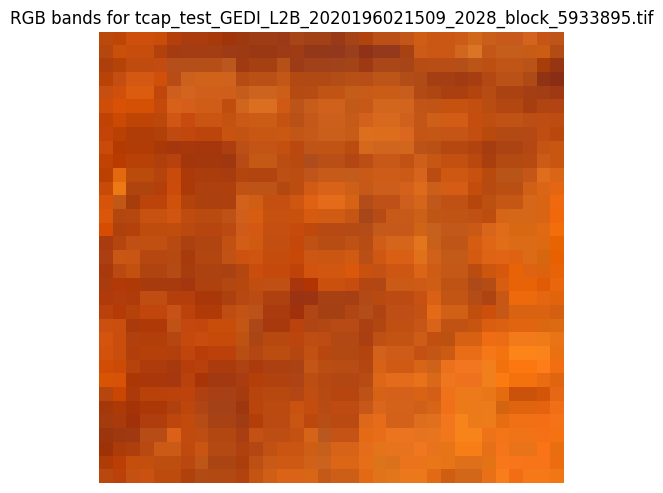


FILE: s2_train_GEDI_L2B_2021135083748_2343_block_5943899.tif
BANDS: 6
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.029083333909511566
      max:  0.1371999979019165
      mean: 0.044803737158058694
      std:  0.010170153384838425

  Band 2 statistics:
      min:  0.03677000105381012
      max:  0.1304749995470047
      mean: 0.048355294099333236
      std:  0.008026821489994718

  Band 3 statistics:
      min:  0.024184616282582283
      max:  0.10454999655485153
      mean: 0.03230118344300518
      std:  0.006788868061765946

  Band 4 statistics:
      min:  0.20724999904632568
      max:  0.38359999656677246
      mean: 0.29778700752213677
      std:  0.03462643269079606

  Band 5 statistics:
      min:  0.14910000562667847
      max:  0.29153332114219666
      mean: 0.19565299591597388
      std:  0.01701755781464463

  Band 6 statistics:
      min:  0.0754999965429306
      max:  0.1940000057220459


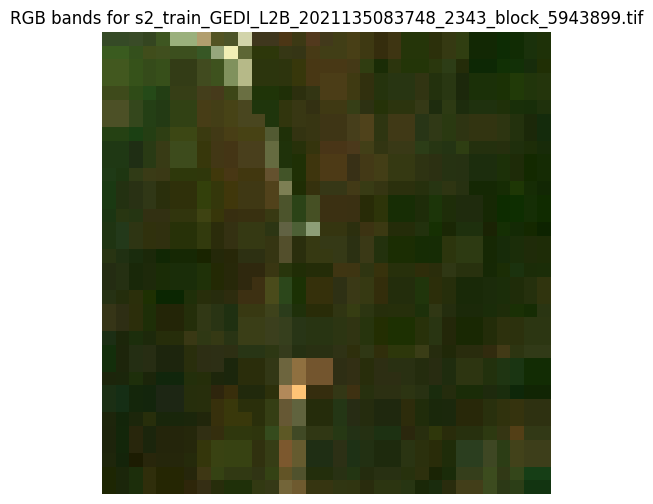


FILE: dem_train_GEDI_L2B_2021135083748_1953_block_5993892.tif
BANDS: 2
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  378.24053955078125
      max:  590.7797241210938
      mean: 511.67740175515786
      std:  57.39697107901203

  Band 2 statistics:
      min:  0.8403801918029785
      max:  33.327049255371094
      mean: 12.756437347853247
      std:  6.8917621431972815
Skipping visualization for dem_train_GEDI_L2B_2021135083748_1953_block_5993892.tif: not enough bands for RGB or single band.


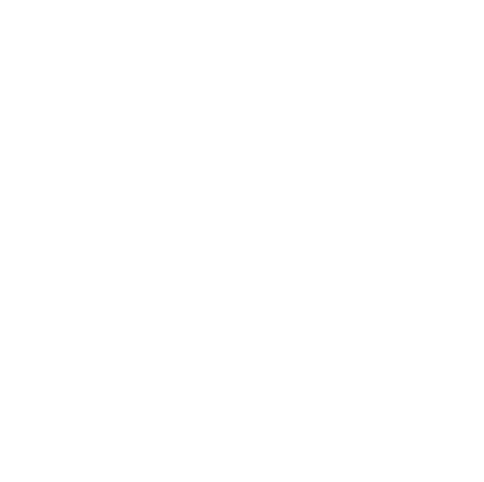


FILE: dem_train_GEDI_L2B_2020196021509_2545_block_5943899.tif
BANDS: 2
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  363.7092590332031
      max:  592.0154418945312
      mean: 485.3829628575507
      std:  61.1770006836418

  Band 2 statistics:
      min:  1.6626259088516235
      max:  35.39038848876953
      mean: 15.52896484302327
      std:  6.172538143074345
Skipping visualization for dem_train_GEDI_L2B_2020196021509_2545_block_5943899.tif: not enough bands for RGB or single band.


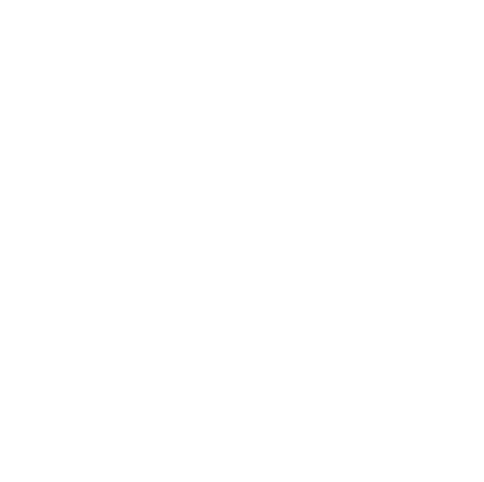


FILE: dem_train_GEDI_L2B_2021135083748_2186_block_5993893.tif
BANDS: 2
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  521.4154663085938
      max:  610.411376953125
      mean: 582.496479465285
      std:  14.995924222300605

  Band 2 statistics:
      min:  0.349385142326355
      max:  32.8476676940918
      mean: 7.423882769980049
      std:  6.121801987446913
Skipping visualization for dem_train_GEDI_L2B_2021135083748_2186_block_5993893.tif: not enough bands for RGB or single band.


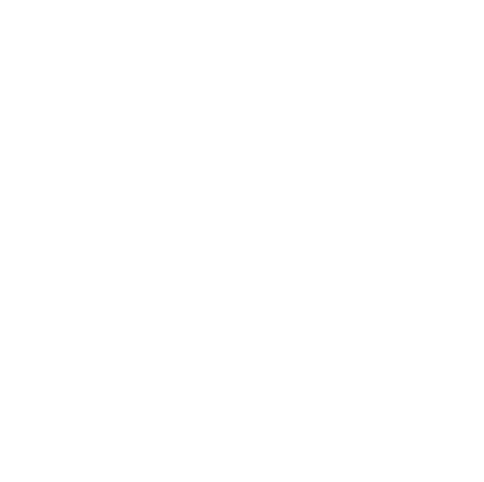

In [28]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files:
    fpath = os.path.join(RASTER_DIR, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {transform.e*-1} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b)
            data = data.astype(float)  # ensure numeric

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            band_min = np.nanmin(data)
            band_max = np.nanmax(data)
            band_mean = np.nanmean(data)
            band_std = np.nanstd(data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {band_min}")
            print(f"      max:  {band_max}")
            print(f"      mean: {band_mean}")
            print(f"      std:  {band_std}")

        # --- Visualization ---
        plt.figure(figsize=(6, 6))
        if count >= 3:
            # Read the first three bands for RGB visualization
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display (min-max)
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)
            plt.imshow(img)
            plt.title(f"RGB bands for {fname}")
        elif count == 1:
            # Read the single band for grayscale visualization
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Grayscale band for {fname}")
        else:
            print(f"Skipping visualization for {fname}: not enough bands for RGB or single band.")

        plt.axis('off')
        plt.show()

## Prep tifs: Pad, Normalize, inspect, save to content

In [29]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# IMPROVED: Fill ALL NaNs with median (no dropping)
# -------------------------------------------------------------------------

PROCESSED_DIR = "/content/GEDI_L2B_processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Scanning directory:", PROCESSED_DIR)

all_tifs = [
    f for f in os.listdir(PROCESSED_DIR)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0

print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

selected_files = []

for fname in all_tifs:
    fpath = os.path.join(PROCESSED_DIR, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True

            bands.append(data)

    # Fix ALL files with NaNs (no dropping!)
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                # Calculate median of non-NaN values
                med = np.nanmedian(data)
                # If entire band is NaN, use 0
                if np.isnan(med):
                    med = 0.0
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep ALL TIFFs for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped                 : 0")  # No more dropping!
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

Scanning directory: /content/GEDI_L2B_processed_32x32_normalized

Found 5758 TIFFs in /content/GEDI_L2B_processed_32x32_normalized

FIXING: landsatidx_train_GEDI_L2B_2022139064237_2595_block_5933888.tif (median fill)
FIXING: landsatidx_test_GEDI_L2B_2022139064237_2568_block_5923889.tif (median fill)
FIXING: landsatidx_train_GEDI_L2B_2020196021509_2740_block_5943899.tif (median fill)
FIXING: s2_train_GEDI_L2B_2020196021509_2234_block_5923895.tif (median fill)
FIXING: landsat_train_GEDI_L2B_2020196021509_2013_block_5923894.tif (median fill)
FIXING: s2_train_GEDI_L2B_2021135083748_1997_block_6033889.tif (median fill)
FIXING: tcap_train_GEDI_L2B_2020196021509_2005_block_5923894.tif (median fill)
FIXING: s2_test_GEDI_L2B_2022139064237_2565_block_5923889.tif (median fill)
FIXING: landsatidx_test_GEDI_L2B_2022139064237_2569_block_5923889.tif (median fill)
FIXING: hls_train_GEDI_L2B_2020196021509_2489_block_5913896.tif (median fill)
FIXING: tcap_test_GEDI_L2B_2022139064237_2567_block_5923889.t

In [30]:
import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling
import numpy as np
import os


processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(PROCESSED_DIR, fname)
    out_path = os.path.join(PROCESSED_DIR, fname)   # overwrite or change if desired


    with rasterio.open(src_path) as src:
        # Step 1: Resize
        resized, transform_resized = resize_to_max32(src)

        # Step 2: Pad
        padded, transform_padded = pad_to_32x32(resized, transform_resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile.copy()
        profile.update({
            "height": 32,
            "width": 32,
            "transform": transform_padded,
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")


Processed 5758 TIFFs successfully.


## Compare before preprocessing

In [31]:
processed_sample_files = {}

for fname in sample_files:
    processed_path = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(processed_path):
        processed_sample_files[fname] = processed_path
    else:
        print(f"⚠️ WARNING: Processed version not found for {fname}")



PROCESSED FILE: tcap_test_GEDI_L2B_2020196021509_2028_block_5933895.tif
LOCATION: /content/GEDI_L2B_processed_32x32_normalized/tcap_test_GEDI_L2B_2020196021509_2028_block_5933895.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7216746070189402
      std:  0.15849649258623522

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5212558877683477
      std:  0.1870221283283677

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5494910273773712
      std:  0.1759075949360113

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.13348019798240784
      std:  0.15824729344191907

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.47041373869738834
      std:  0.19703987642434412

  Band 6 statistics:
      min:  0.0
      max:  0.9999999403953552
      mean: 0.26518208248762676
      std:  0.17306631048015392

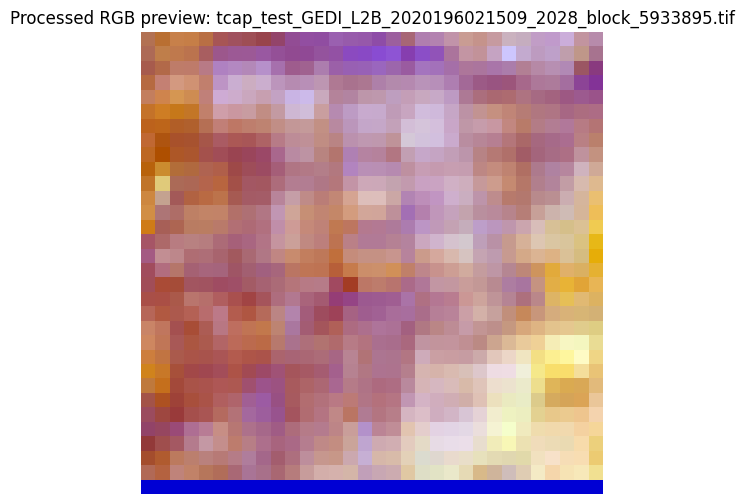


PROCESSED FILE: s2_train_GEDI_L2B_2021135083748_2343_block_5943899.tif
LOCATION: /content/GEDI_L2B_processed_32x32_normalized/s2_train_GEDI_L2B_2021135083748_2343_block_5943899.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 21.25 x 21.25 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.39581688775797375
      std:  0.1076585678710826

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4247436723962892
      std:  0.09914245399932527

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3580545212025754
      std:  0.0923428318168373

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7655074899666943
      std:  0.1603630902896378

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6903220452950336
      std:  0.1361603527187679

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5027651163109113
      std:  0.11837354085426482


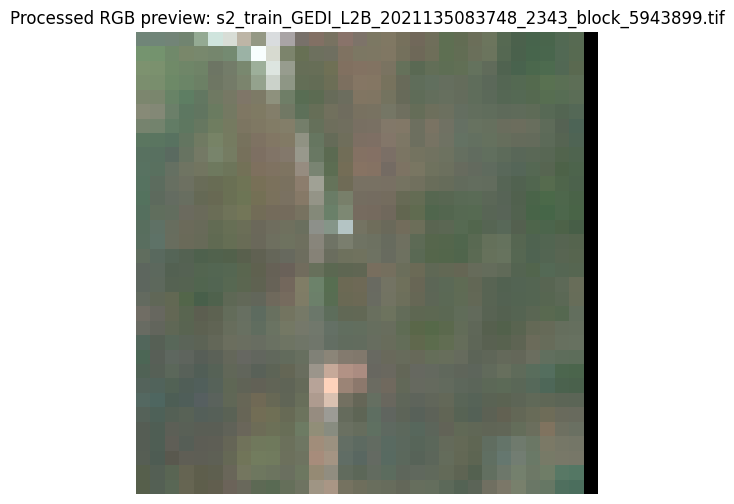


PROCESSED FILE: dem_train_GEDI_L2B_2021135083748_1953_block_5993892.tif
LOCATION: /content/GEDI_L2B_processed_32x32_normalized/dem_train_GEDI_L2B_2021135083748_1953_block_5993892.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.8400806896970607
      std:  0.17854670537102746

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3810155482497066
      std:  0.20738066185640736


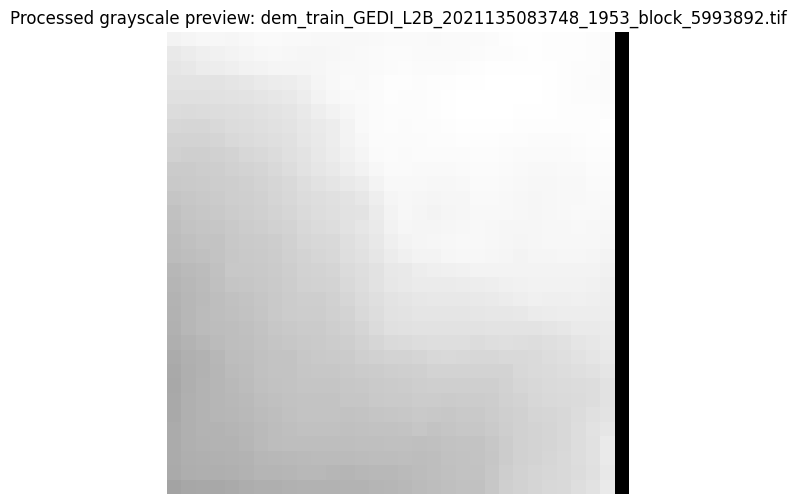


PROCESSED FILE: dem_train_GEDI_L2B_2020196021509_2545_block_5943899.tif
LOCATION: /content/GEDI_L2B_processed_32x32_normalized/dem_train_GEDI_L2B_2020196021509_2545_block_5943899.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7946088711032644
      std:  0.17513053470772252

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.43863863215301535
      std:  0.18122801003324587


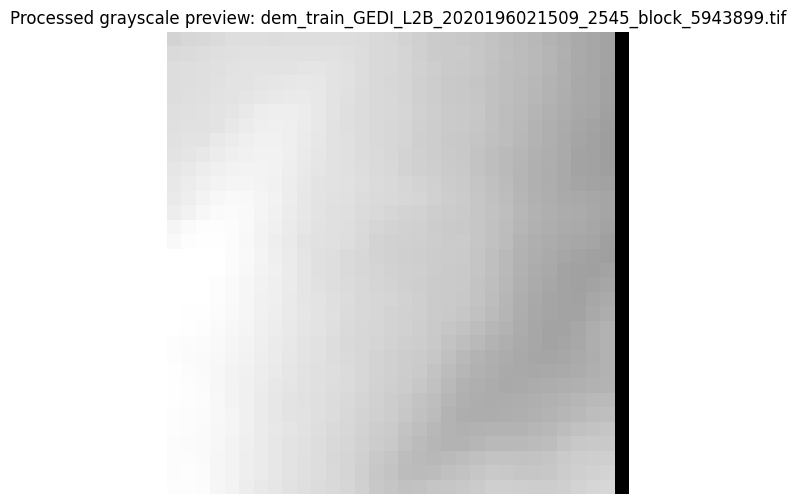


PROCESSED FILE: dem_train_GEDI_L2B_2021135083748_2186_block_5993893.tif
LOCATION: /content/GEDI_L2B_processed_32x32_normalized/dem_train_GEDI_L2B_2021135083748_2186_block_5993893.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.690150206508406
      std:  0.1683197410385103

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.21476475610256784
      std:  0.19348947276294853


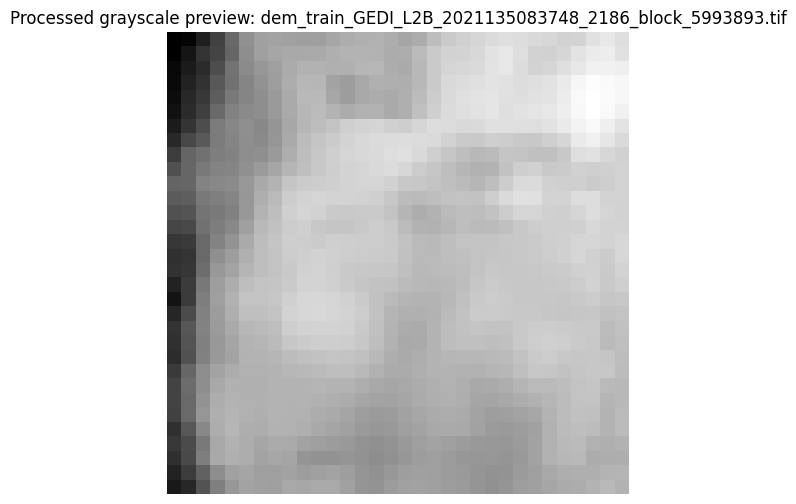

In [32]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (arbitrary)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


In [ ]:
# # Path to the folder containing your TIFF chips
# tif_dir = "/content/GEDI_L2B_processed_32x32_normalized"  # <-- CHANGE THIS

# # Name of the output zip file
# zip_path = "/content/GEDI_L2B_processed_32x32_normalized.zip"


In [ ]:
# import os
# import random
# import numpy as np
# import tifffile as tiff

# # Collect all TIFF files
# tif_files = sorted([
#     os.path.join(tif_dir, f)
#     for f in os.listdir(tif_dir)
#     if f.lower().endswith((".tif", ".tiff"))
# ])

# num_files = len(tif_files)
# print(f"Total TIFF files found: {num_files}")

# if num_files == 0:
#     raise RuntimeError("No TIFF files found. Check directory path.")

# # Randomly sample 5 files
# sample_files = random.sample(tif_files, min(5, num_files))

# print("\nRandom sample statistics (min / max pixel values):")

# for f in sample_files:
#     try:
#         img = tiff.imread(f)
#         print(
#             f"  {os.path.basename(f)} | "
#             f"shape={img.shape} | "
#             f"dtype={img.dtype} | "
#             f"min={img.min()} | max={img.max()}"
#         )
#     except Exception as e:
#         print(
#             f"  {os.path.basename(f)} | ERROR reading file: {str(e)}"
#         )


Total TIFF files found: 5758

Random sample statistics (min / max pixel values):
  tcap_train_GEDI_L2B_2021135083748_2341_block_5943899.tif | ERROR reading file: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
  s2_test_GEDI_L2B_2020196021509_2716_block_5933898.tif | ERROR reading file: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
  landsatidx_train_GEDI_L2B_2021135083748_2204_block_6013891.tif | ERROR reading file: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
  tcap_train_GEDI_L2B_2021135083748_2347_block_5953899.tif | ERROR reading file: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
  hls_train_GEDI_L2B_2022139064237_2317_block_5923888.tif | ERROR reading file: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package


In [ ]:
# import zipfile

# with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
#     for f in tif_files:
#         zipf.write(
#             f,
#             arcname=os.path.basename(f)  # keeps files flat inside zip
#         )

# print(f"\nZipping complete.")
# print(f"Files zipped: {num_files}")
# print(f"ZIP file created at: {zip_path}")


Zipping complete.
Files zipped: 5758
ZIP file created at: /content/GEDI_L2B_processed_32x32_normalized.zip


## Setting up Multitasking Target filter

In [ ]:
# import pandas as pd

# # Load dataset
# df = pd.read_csv(GEDI_CSV, low_memory=False)

# # Ensure product labels are clean
# df['product_field'] = df['product_field'].str.strip()

# # Ensure coordinates are numeric
# df['x'] = pd.to_numeric(df['x'], errors='coerce')
# df['y'] = pd.to_numeric(df['y'], errors='coerce')

# # ---- GROUP BY LOCATION ----
# groups = df.groupby(["x", "y"])

# # For each location, determine which products appear
# location_products = groups["product_field"].apply(lambda s: set(s))

# # --- MERGED PERSPECTIVE ---
# L2A_only = location_products[location_products == {"GEDI_L2A"}]
# L2B_only = location_products[location_products == {"GEDI_L2B"}]
# L2A_L2B_overlap = location_products[location_products == {"GEDI_L2A", "GEDI_L2B"}]

# # --- PRODUCT-SPECIFIC PERSPECTIVE ---
# # Unique locations containing each product
# L2A_locations = set(location_products[location_products.apply(lambda s: "GEDI_L2A" in s)].index)
# L2B_locations = set(location_products[location_products.apply(lambda s: "GEDI_L2B" in s)].index)

# # Overlap from each perspective
# L2A_overlapping_with_L2B = L2A_locations.intersection(L2B_locations)
# L2A_only_locations = L2A_locations - L2B_locations

# L2B_overlapping_with_L2A = L2B_locations.intersection(L2A_locations)
# L2B_only_locations = L2B_locations - L2A_locations

# # ---- PRINT RESULTS ----
# print("=== MERGED PERSPECTIVE (FULL OVERLAP PATTERN) ===")
# print("L2A-only locations:", len(L2A_only))
# print("L2B-only locations:", len(L2B_only))
# print("L2A + L2B overlapping locations:", len(L2A_L2B_overlap))

# print("\n=== L2A PERSPECTIVE ===")
# print("Total unique L2A locations:", len(L2A_locations))
# print("L2A overlapping with L2B:", len(L2A_overlapping_with_L2B))
# print("L2A-only locations:", len(L2A_only_locations))

# print("\n=== L2B PERSPECTIVE ===")
# print("Total unique L2B locations:", len(L2B_locations))
# print("L2B overlapping with L2A:", len(L2B_overlapping_with_L2A))
# print("L2B-only locations:", len(L2B_only_locations))


=== MERGED PERSPECTIVE (FULL OVERLAP PATTERN) ===
L2A-only locations: 996
L2B-only locations: 0
L2A + L2B overlapping locations: 872

=== L2A PERSPECTIVE ===
Total unique L2A locations: 1868
L2A overlapping with L2B: 872
L2A-only locations: 996

=== L2B PERSPECTIVE ===
Total unique L2B locations: 872
L2B overlapping with L2A: 872
L2B-only locations: 0


In [ ]:
# import pandas as pd

# GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# # Load CSV
# df = pd.read_csv(GEDI_CSV)

# # Filter for product_field == "GEDI_LSA"
# df_filtered_GEDI_L2A = df[df["product_field"] == "GEDI_L2A"]

# df_filtered_GEDI_L2A


/tmp/ipython-input-686974334.py:6: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GEDI_CSV)


,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1863,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217155,-85.859947,549.746216,567.769958,-41.230606,0.977462,0.0,1.0,...,NaN,NaN,NaN,603758.425670,3.897721e+06,603,3897,603_3897,1864,train
1864,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217505,-85.859484,550.669312,566.905273,-41.230209,0.975680,0.0,1.0,...,NaN,NaN,NaN,603800.146408,3.897760e+06,603,3897,603_3897,1865,train
1865,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217854,-85.859021,549.173706,566.905273,-41.229813,0.978489,0.0,1.0,...,NaN,NaN,NaN,603841.799971,3.897799e+06,603,3897,603_3897,1866,train
1866,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,NaN,NaN,NaN,603925.187830,3.897878e+06,603,3897,603_3897,1867,train


In [ ]:
# import pandas as pd

# GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# # Load CSV
# df = pd.read_csv(GEDI_CSV)

# # Filter for both product fields
# df_filtered = df[df["product_field"].isin(["GEDI_L2A", "GEDI_L2B"])]  # or "GEDI_LB"

# df_filtered


/tmp/ipython-input-1611375933.py:6: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GEDI_CSV)


,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2735,subsetted,118361550_GEDI02_B_2020196021509_O08987_02_T05...,35.233962,-85.963463,458.411957,473.953369,-18.852430,0.988544,0.0,NaN,...,-0.0,NaN,2.032218,594317.442746,3.899481e+06,594,3899,594_3899,2736,train
2736,subsetted,118361550_GEDI02_B_2020196021509_O08987_02_T05...,35.234312,-85.963001,456.452301,473.953369,-18.852463,0.977716,0.0,NaN,...,-0.0,NaN,1.899153,594359.113887,3.899521e+06,594,3899,594_3899,2737,train
2737,subsetted,118361550_GEDI02_B_2020196021509_O08987_02_T05...,35.234659,-85.962542,458.544312,457.805634,-18.852495,0.988305,0.0,NaN,...,-0.0,NaN,0.204220,594400.418898,3.899560e+06,594,3899,594_3899,2738,train
2738,subsetted,118361550_GEDI02_B_2020196021509_O08987_02_T05...,35.235015,-85.962070,446.633423,457.805634,-18.852528,0.989999,0.0,NaN,...,-0.0,NaN,0.699897,594442.983701,3.899599e+06,594,3899,594_3899,2739,train


In [33]:
# =====================================================
# FIXED MULTI-TASK WORKFLOW
# Handles both L2A and L2B while preserving row_ID matching
# =====================================================

import pandas as pd
import os
import re

GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# TIFF directories
TIFF_ROOTS = {
    "GEDI_L2A": "/content/processed_32x32_normalized",
    "GEDI_L2B": "/content/GEDI_L2B_processed_32x32_normalized"
}

print("="*70)
print("STEP 1: LOAD AND PREPARE CSV DATA")
print("="*70)

# Load full CSV
df = pd.read_csv(GEDI_CSV)

# Separate L2A and L2B (BEFORE any merging)
df_l2a_original = df[df["product_field"] == "GEDI_L2A"].copy()
df_l2b_original = df[df["product_field"] == "GEDI_L2B"].copy()

print(f"\nOriginal CSV data:")
print(f"  L2A rows: {len(df_l2a_original)} (unique row_IDs: {df_l2a_original['row_ID'].nunique()})")
print(f"  L2B rows: {len(df_l2b_original)} (unique row_IDs: {df_l2b_original['row_ID'].nunique()})")

# =====================================================
# STEP 2: ADD MULTI-TASK TARGETS
# =====================================================

print("\n" + "="*70)
print("STEP 2: ADD MULTI-TASK TARGETS (RH + PAI + FHD)")
print("="*70)

# Group by shot_number to get unique shots (for matching)
l2a_unique = df_l2a_original.groupby('shot_number').first().reset_index()
l2b_unique = df_l2b_original.groupby('shot_number').first().reset_index()

# Create lookup dictionaries
l2a_metrics = l2a_unique.set_index('shot_number')[['rh']].to_dict('index')
l2b_metrics = l2b_unique.set_index('shot_number')[['pai', 'fhd_normal']].to_dict('index')

# Add L2B metrics to L2A rows (PRESERVING original row_IDs)
df_l2a_original['pai'] = df_l2a_original['shot_number'].map(
    lambda x: l2b_metrics.get(x, {}).get('pai', pd.NA)
)
df_l2a_original['fhd_normal'] = df_l2a_original['shot_number'].map(
    lambda x: l2b_metrics.get(x, {}).get('fhd_normal', pd.NA)
)

# Add L2A metrics to L2B rows (PRESERVING original row_IDs)
df_l2b_original['rh'] = df_l2b_original['shot_number'].map(
    lambda x: l2a_metrics.get(x, {}).get('rh', pd.NA)
)

# Add missing columns to L2B (so they match L2A structure)
if 'pai' not in df_l2b_original.columns:
    # L2B already has pai, just making sure
    pass
if 'fhd_normal' not in df_l2b_original.columns:
    # L2B already has fhd_normal
    pass

print(f"\nL2A rows with all targets:")
l2a_complete = df_l2a_original[
    df_l2a_original['rh'].notna() &
    df_l2a_original['pai'].notna() &
    df_l2a_original['fhd_normal'].notna()
]
print(f"  Complete: {len(l2a_complete)} rows ({l2a_complete['row_ID'].nunique()} unique row_IDs)")

print(f"\nL2B rows with all targets:")
l2b_complete = df_l2b_original[
    df_l2b_original['rh'].notna() &
    df_l2b_original['pai'].notna() &
    df_l2b_original['fhd_normal'].notna()
]
print(f"  Complete: {len(l2b_complete)} rows ({l2b_complete['row_ID'].nunique()} unique row_IDs)")

# =====================================================
# STEP 3: COMBINE L2A AND L2B (keeping original row_IDs)
# =====================================================

print("\n" + "="*70)
print("STEP 3: COMBINE L2A AND L2B DATASETS")
print("="*70)

# Combine complete datasets
df_combined = pd.concat([l2a_complete, l2b_complete], ignore_index=False)

print(f"\nCombined dataset:")
print(f"  Total rows: {len(df_combined)}")
print(f"  L2A rows: {len(l2a_complete)}")
print(f"  L2B rows: {len(l2b_complete)}")
print(f"  Unique row_IDs: {df_combined['row_ID'].nunique()}")

# Check for row_ID collisions
l2a_row_ids = set(l2a_complete['row_ID'].unique())
l2b_row_ids = set(l2b_complete['row_ID'].unique())
collision = l2a_row_ids & l2b_row_ids

if len(collision) > 0:
    print(f"\n⚠️  WARNING: {len(collision)} row_IDs appear in BOTH L2A and L2B!")
    print(f"  These will cause issues during TIFF matching.")
    print(f"  Solution: Renumber L2B row_IDs to avoid collisions")

    # Renumber L2B row_IDs
    max_l2a_row_id = df_l2a_original['row_ID'].max()
    offset = max_l2a_row_id + 1000  # Add offset to avoid collisions

    df_l2b_complete_renumbered = l2b_complete.copy()
    df_l2b_complete_renumbered['row_ID_original'] = df_l2b_complete_renumbered['row_ID']
    df_l2b_complete_renumbered['row_ID'] = df_l2b_complete_renumbered['row_ID'] + offset

    print(f"  Renumbered L2B row_IDs by adding offset of {offset}")
    print(f"  New L2B row_ID range: {df_l2b_complete_renumbered['row_ID'].min()} - {df_l2b_complete_renumbered['row_ID'].max()}")

    # Use renumbered version
    df_combined = pd.concat([l2a_complete, df_l2b_complete_renumbered], ignore_index=False)
    print(f"\n✓ Combined dataset (no collisions): {df_combined['row_ID'].nunique()} unique row_IDs")
else:
    print(f"\n✓ No row_ID collisions - safe to combine")

# This is your new df_filtered_GEDI_L2A
df_filtered_GEDI_L2A = df_combined.copy()

print("\n✓ df_filtered_GEDI_L2A ready with multi-task targets")

# =====================================================
# STEP 4: PARSE TIFFs (BOTH DIRECTORIES)
# =====================================================

print("\n" + "="*70)
print("STEP 4: PARSE TIFF FILES")
print("="*70)

# Updated regex for both L2A and L2B
FILENAME_RE = re.compile(
    r"^(?P<cov>[a-zA-Z0-9]+)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_L2A|GEDI_L2B)_"
    r"(?P<shot>\d+)_"
    r"(?P<row_ID>\d+)_"
    r"block_(?P<block_id>\d+)\.tif$"
)

rows = []

for product_type, tiff_root in TIFF_ROOTS.items():
    print(f"\nParsing {product_type} from: {tiff_root}")

    if not os.path.exists(tiff_root):
        print(f"  ⚠️  Directory not found - skipping")
        continue

    file_count = 0
    for fn in os.listdir(tiff_root):
        if not fn.endswith(".tif"):
            continue

        m = FILENAME_RE.match(fn)
        if m is None:
            # Try without product_field for backward compatibility
            continue

        d = m.groupdict()
        d["filename"] = fn
        d["full_path"] = os.path.join(tiff_root, fn)

        # If this is L2B and we renumbered row_IDs, apply offset here too
        if product_type == "GEDI_L2B" and len(collision) > 0:
            d["row_ID_original"] = int(d["row_ID"])
            d["row_ID"] = int(d["row_ID"]) + offset

        rows.append(d)
        file_count += 1

    print(f"  ✓ Parsed {file_count} TIFFs")

tif_df = pd.DataFrame(rows)

print(f"\nTotal TIFFs parsed: {len(tif_df)}")
print(f"  L2A: {len(tif_df[tif_df['product_field'] == 'GEDI_L2A'])}")
print(f"  L2B: {len(tif_df[tif_df['product_field'] == 'GEDI_L2B'])}")
print(f"Unique row_IDs in TIFFs: {tif_df['row_ID'].nunique()}")

# =====================================================
# STEP 5: MERGE CSV AND TIFFs
# =====================================================

print("\n" + "="*70)
print("STEP 5: MERGE CSV WITH TIFF FILES")
print("="*70)

# Convert to int
df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)
tif_df["row_ID"] = tif_df["row_ID"].astype(int)

# Merge on row_ID (your original approach)
merged = df_filtered_GEDI_L2A.merge(tif_df, on="row_ID", how="left")

print(f"\nMerge results:")
print(f"  Total merged rows: {len(merged)}")

# Check for matches
valid = merged[~merged["filename"].isna()]

print(f"\nMatching results:")
print(f"  CSV rows: {len(df_filtered_GEDI_L2A)}")
print(f"  Rows with TIFFs: {len(valid['row_ID'].unique())}")
print(f"  Coverage: {len(valid['row_ID'].unique()) / df_filtered_GEDI_L2A['row_ID'].nunique() * 100:.1f}%")

# Breakdown by product type
for product in ['GEDI_L2A', 'GEDI_L2B']:
    if 'product_field_x' in valid.columns:
        product_valid = valid[valid['product_field_x'] == product]
    else:
        product_valid = valid[valid['product_field'] == product]

    if len(product_valid) > 0:
        print(f"\n{product}:")
        print(f"  Rows with TIFFs: {product_valid['row_ID'].nunique()}")
        print(f"  With all targets: {product_valid[['rh', 'pai', 'fhd_normal']].notna().all(axis=1).sum()}")

# =====================================================
# STEP 6: CREATE FINAL df_valid
# =====================================================

df_valid = pd.DataFrame(valid)

print("\n" + "="*70)
print("✓ MULTI-TASK DATASET READY")
print("="*70)
print(f"df_valid: {len(df_valid)} rows")
print(f"Unique samples: {df_valid['row_ID'].nunique()}")
print(f"Targets available: rh, pai, fhd_normal")
print("\nReady for multi-task training!")
print("="*70)

STEP 1: LOAD AND PREPARE CSV DATA

Original CSV data:
  L2A rows: 1868 (unique row_IDs: 1868)
  L2B rows: 872 (unique row_IDs: 872)

STEP 2: ADD MULTI-TASK TARGETS (RH + PAI + FHD)

L2A rows with all targets:
  Complete: 1083 rows (1083 unique row_IDs)

L2B rows with all targets:
  Complete: 872 rows (872 unique row_IDs)

STEP 3: COMBINE L2A AND L2B DATASETS

Combined dataset:
  Total rows: 1955
  L2A rows: 1083
  L2B rows: 872
  Unique row_IDs: 1955

✓ No row_ID collisions - safe to combine

✓ df_filtered_GEDI_L2A ready with multi-task targets

STEP 4: PARSE TIFF FILES

Parsing GEDI_L2A from: /content/processed_32x32_normalized
  ✓ Parsed 7087 TIFFs

Parsing GEDI_L2B from: /content/GEDI_L2B_processed_32x32_normalized
  ✓ Parsed 5758 TIFFs

Total TIFFs parsed: 12845
  L2A: 7087
  L2B: 5758
Unique row_IDs in TIFFs: 1667

STEP 5: MERGE CSV WITH TIFF FILES

Merge results:
  Total merged rows: 10534

Matching results:
  CSV rows: 1955
  Rows with TIFFs: 1281
  Coverage: 65.5%

GEDI_L2A:
  

/tmp/ipython-input-2524023104.py:23: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GEDI_CSV)


In [34]:
df_valid.to_csv('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/df_valid.csv', index=False)

In [35]:
column_headers = df_valid.columns.tolist()
print(column_headers)

['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field_x', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin_0', 'pgap_theta

In [36]:
confirm_GEDIS_df_valid = df_valid['product_field_x'].unique()
print(f"confirm_GEDIS: {confirm_GEDIS_df_valid}")

confirm_GEDIS: ['GEDI_L2A' 'GEDI_L2B']


In [37]:
column_names = valid.columns.tolist()
print(column_names)

['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field_x', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin_0', 'pgap_theta

In [38]:
eo_list = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

print("\nCounts per EO by split:")
for eo in eo_list:
    eo_df = tif_df[tif_df["cov"] == eo]
    print(f"\nEO = {eo}")
    print(eo_df["split"].value_counts())



Counts per EO by split:

EO = s1
split
train    1204
test      256
val       173
Name: count, dtype: int64

EO = s2
split
train    1046
test      226
val       152
Name: count, dtype: int64

EO = landsat
split
train    1237
test      256
val       174
Name: count, dtype: int64

EO = landsatidx
split
train    1237
test      256
val       174
Name: count, dtype: int64

EO = hls
split
train    1237
test      256
val       174
Name: count, dtype: int64

EO = tcap
split
train    1237
test      256
val       174
Name: count, dtype: int64

EO = dem
split
train    1237
test      256
val       174
Name: count, dtype: int64

EO = s2idx
split
train    1072
test      225
val       156
Name: count, dtype: int64


## Data loaders

In [ ]:
# EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
# SPATIAL_RES = {
#     's1': 10, 's2': 20, 's2idx': 20,
#     'landsat': 30, 'landsatidx': 30,
#     'hls': 30, 'tcap': 30, 'dem': 30
# }
# BANDS_PER_COV = {
#     's1': 4, 's2': 6, 's2idx': 8,
#     'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
# }

In [ ]:
# import torch
# from torch.utils.data import Dataset, DataLoader
# import rasterio
# import numpy as np
# import random


# # -----------------------
# # Remove NaN samples
# # -----------------------
# def drop_nan_samples(df):
#     clean_rows = []
#     dropped = 0

#     for i, row in df.iterrows():
#         fp = row["full_path"]
#         try:
#             with rasterio.open(fp) as src:
#                 arr = src.read().astype(np.float32)
#                 if np.isnan(arr).any():
#                     dropped += 1
#                     continue
#         except:
#             dropped += 1
#             continue

#         clean_rows.append(row)

#     clean_df = pd.DataFrame(clean_rows).reset_index(drop=True)
#     print(f"\n[CLEAN] Removed {dropped} NaN samples. Remaining: {len(clean_df)}")
#     return clean_df

# # -----------------------
# # Dataset for a single EO
# # -----------------------
# class GeoTiffDataset(Dataset):
#     def __init__(self, df, eo, bands_per_cov, target_col='rh', transform=None, augment=False, split='train'):
#         """
#         Single-EO Dataset for multibranch model.
#         df: pandas DataFrame
#         eo: EO type (string, must match 'cov' column)
#         bands_per_cov: dict mapping EO type to number of bands
#         target_col: target column name
#         transform: optional transform
#         augment: whether to apply flips and rotations
#         split: data partition ('train', 'val', 'test')
#         """
#         # Filter rows by EO and split
#         self.df = df[(df['cov'] == eo) & (df['split_x'] == split)].reset_index(drop=True)
#         self.eo = eo
#         self.bands = bands_per_cov[eo]
#         self.target_col = target_col
#         self.transform = transform
#         self.augment = augment

#         if len(self.df) == 0:
#             print(f"[WARNING] Dataset for EO '{eo}' and split '{split}' initialized with 0 samples!")
#         else:
#             print(f"[INFO] Dataset for EO '{eo}' and split '{split}' initialized with {len(self.df)} samples")
#         print(f"[INFO] Target column: {self.target_col}")
#         print(f"[INFO] Augmentation enabled: {self.augment}")

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         fp = row['full_path']

#         with rasterio.open(fp) as src:
#             arr = src.read().astype(np.float32)  # (C, H, W)

#         # Verify band count
#         if arr.shape[0] != self.bands:
#             raise ValueError(f"EO {self.eo} at idx {idx} has {arr.shape[0]} bands, expected {self.bands}")

#         # Augmentation: flips and rotations
#         if self.augment:
#             if random.random() > 0.5:  # horizontal flip
#                 arr = arr[:, :, ::-1].copy()
#             if random.random() > 0.5:  # vertical flip
#                 arr = arr[:, ::-1, :].copy()
#             k = random.randint(0, 3)
#             arr = np.rot90(arr, k, axes=(1, 2)).copy()

#         if self.transform:
#             arr = self.transform(arr)

#         x = torch.tensor(arr, dtype=torch.float32)
#         y = torch.tensor(row[self.target_col], dtype=torch.float32)

#         # return x, y
#         return {
#         "image": x,      #
#         "target": y,     #
#         "path": fp       # 11/20 !!!! NEW — adds full file path for embedding fusion
#     }

# # -----------------------
# # Function to create loaders per EO and split
# # -----------------------
# def create_multibranch_loaders(df, eo_list, bands_per_cov, target_col='rh', batch_size=16, augment=False, split='train'):
#     """
#     Create a dictionary of DataLoaders per EO.
#     Returns: dict {eo: DataLoader}
#     """
#     loaders = {}
#     for eo in eo_list:
#         dataset = GeoTiffDataset(df, eo, bands_per_cov, target_col=target_col, augment=augment, split=split)
#         if len(dataset) == 0:
#             print(f"[WARNING] Skipping EO '{eo}' because dataset is empty for split '{split}'")
#             continue
#         loader = DataLoader(dataset, batch_size=batch_size, shuffle=(split=='train'), num_workers=2)
#         loaders[eo] = loader
#         print(f"[INFO] DataLoader for EO '{eo}' created with {len(loader)} batches, batch size {batch_size}")
#     return loaders

# # -----------------------
# # Example usage: create loaders for all EO branches for 'train' split
# # -----------------------
# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# BANDS_PER_COV = {
#     's1': 4, 's2': 6, 's2idx': 8,
#     'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
# }

# train_loaders = create_multibranch_loaders(valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=True, split='train')

# # -----------------------
# # Inspect first batch per EO
# # -----------------------
# for eo, loader in train_loaders.items():

#     batch = next(iter(loader))     # 11/20 fix ⭐ one dict now, not two tensors

#     print(f"\n[INFO] EO branch: {eo}")
#     print(f"  Image batch shape:  {batch['image'].shape}")   # (B, C, H, W)
#     print(f"  Target batch shape: {batch['target'].shape}")  # (B,)
#     print(f"  Example path:       {batch['path'][0]}")        # first file path



[INFO] Dataset for EO 's1' and split 'train' initialized with 942 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's1' created with 59 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'train' initialized with 807 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's2' created with 51 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'train' initialized with 958 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsat' created with 60 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'train' initialized with 958 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsatidx' created with 60 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'train' initialized with 958 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'hls' c

In [ ]:
# # -----------------------
# # Test loaders without augmentation
# # -----------------------
# test_loaders = create_multibranch_loaders(
#     valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='test'
# )

# # -----------------------
# # Inspect first batch per EO for TEST
# # -----------------------
# print("\n==================== TEST LOADERS ====================")
# # for eo, loader in test_loaders.items():
# #     first_sample, first_target = next(iter(loader))
# #     print(f"\n[INFO] Split: TEST | EO branch: {eo}")
# #     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
# #     print(f"  Target shape: {first_target.shape}")  # (B,)
# ##11/20 fix
# for eo, loader in test_loaders.items():
#     batch = next(iter(loader))             # <-- CHANGED: now batch is a dict
#     imgs   = batch["image"]                # <-- CHANGED
#     tgts   = batch["target"]               # <-- CHANGED
#     paths  = batch["path"]                 # <-- CHANGED: list of file paths

#     print(f"\n[INFO] Split: TEST | EO branch: {eo}")
#     print(f"  Image batch shape:  {imgs.shape}")     # (B, C, H, W)
#     print(f"  Target batch shape: {tgts.shape}")     # (B,)
#     print(f"  Example path:       {paths[0]}")       # path string



# # -----------------------
# # Validation loaders without augmentation
# # -----------------------
# val_loaders = create_multibranch_loaders(
#     valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='val'
# )

# # -----------------------
# # Inspect first batch per EO for VAL
# # -----------------------
# # print("\n==================== VAL LOADERS ====================")
# # for eo, loader in val_loaders.items():
# #     first_sample, first_target = next(iter(loader))
# #     print(f"\n[INFO] Split: VAL | EO branch: {eo}")
# #     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
# #     print(f"  Target shape: {first_target.shape}")  # (B,)'

# #11/20 fix
# print("\n==================== VAL LOADERS ====================")

# for eo, loader in val_loaders.items():
#     batch = next(iter(loader))             # <-- CHANGED
#     imgs   = batch["image"]                # <-- CHANGED
#     tgts   = batch["target"]               # <-- CHANGED
#     paths  = batch["path"]                 # <-- CHANGED

#     print(f"\n[INFO] Split: VAL | EO branch: {eo}")
#     print(f"  Image batch shape:  {imgs.shape}")
#     print(f"  Target batch shape: {tgts.shape}")
#     print(f"  Example path:       {paths[0]}")


[INFO] Dataset for EO 's1' and split 'test' initialized with 188 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's1' created with 12 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'test' initialized with 163 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's2' created with 11 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'test' initialized with 188 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsat' created with 12 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'test' initialized with 188 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsatidx' created with 12 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'test' initialized with 188 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'hls' c

### check for NAN

In [ ]:
# # -----------------------
# # Check datasets + loaders for NaN values
# # -----------------------

# def check_nans_in_dataset(df, eo_list):
#     print("\n========== DATASET NaN CHECK ==========")
#     import rasterio
#     import numpy as np

#     for eo in eo_list:
#         subdf = df[df["cov"] == eo]
#         if len(subdf) == 0:
#             print(f"[INFO] EO '{eo}' has no rows in dataframe.")
#             continue

#         nan_files = []
#         for _, row in subdf.iterrows():
#             fp = row["full_path"]
#             try:
#                 with rasterio.open(fp) as src:
#                     arr = src.read().astype(np.float32)
#                     if np.isnan(arr).any():
#                         nan_files.append(fp)
#             except Exception as e:
#                 print(f"[ERROR] Could not read {fp}: {e}")

#         if len(nan_files) > 0:
#             print(f"[WARNING] EO '{eo}' has {len(nan_files)} files containing NaN.")
#             for f in nan_files[:5]:  # show first 5
#                 print("    ", f)
#         else:
#             print(f"[OK] EO '{eo}' has no NaN values in any raster.")

# ##11/20 ddrsssing dictdictionary  to three elemtns
# def check_nans_in_loaders(loaders):
#     print("\n========== LOADER NaN CHECK ==========")
#     import torch

#     for eo, loader in loaders.items():
#         try:
#             batch = next(iter(loader))
#         except StopIteration:
#             print(f"[WARNING] EO '{eo}' loader is empty.")
#             continue

#         # Handle dict batches
#         if isinstance(batch, dict):
#             batch_x = batch.get("image")
#             batch_y = batch.get("target")
#         else:
#             # fallback for tuple/list batches
#             batch_x, batch_y = batch

#         x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
#         y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

#         if x_nan or y_nan:
#             print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
#             print(f"   NaN in inputs: {x_nan}")
#             print(f"   NaN in targets: {y_nan}")
#         else:
#             print(f"[OK] EO '{eo}' first batch has no NaNs.")



# # ---------- RUN CHECKS ----------
# check_nans_in_dataset(valid, EO_LIST)
# check_nans_in_loaders(train_loaders)



========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.


In [ ]:
# ###11/20 addressing dictionary to return three elements
# # -----------------------
# # Run NaN checks across all splits
# # -----------------------
# splits = ['train', 'val', 'test']
# loaders_dict = {
#     'train': train_loaders,
#     'val': val_loaders,
#     'test': test_loaders
# }

# for split in splits:
#     print(f"\n==================== NaN CHECK: {split.upper()} ====================")

#     # Check dataset
#     check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

#     # Check loaders
#     print("\n========== LOADER NaN CHECK ==========")
#     import torch

#     for eo, loader in loaders_dict[split].items():
#         try:
#             batch = next(iter(loader))
#         except StopIteration:
#             print(f"[WARNING] EO '{eo}' loader is empty.")
#             continue

#         # Handle dict batches
#         if isinstance(batch, dict):
#             batch_x = batch.get("image")
#             batch_y = batch.get("target")
#         else:
#             # fallback for tuple/list batches
#             batch_x, batch_y = batch

#         x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
#         y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

#         if x_nan or y_nan:
#             print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
#             print(f"   NaN in inputs: {x_nan}")
#             print(f"   NaN in targets: {y_nan}")
#         else:
#             print(f"[OK] EO '{eo}' first batch has no NaNs.")




==================== NaN CHECK: TRAIN ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.

==================== NaN CHECK: VAL ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[O

## MultiTask Data Loader approach

note the target_cols

In [39]:
# =====================================================
# MULTI-TASK DATALOADER - Modified for RH + PAI + FHD
# Only changes needed: __getitem__ returns 3 targets
# =====================================================

import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import random
import pandas as pd


# -----------------------
# Remove NaN samples (UNCHANGED)
# -----------------------
def drop_nan_samples(df):
    clean_rows = []
    dropped = 0

    for i, row in df.iterrows():
        fp = row["full_path"]
        try:
            with rasterio.open(fp) as src:
                arr = src.read().astype(np.float32)
                if np.isnan(arr).any():
                    dropped += 1
                    continue
        except:
            dropped += 1
            continue

        clean_rows.append(row)

    clean_df = pd.DataFrame(clean_rows).reset_index(drop=True)
    print(f"\n[CLEAN] Removed {dropped} NaN samples. Remaining: {len(clean_df)}")
    return clean_df


# -----------------------
# MODIFIED: Multi-Task Dataset
# -----------------------
class GeoTiffDataset(Dataset):
    def __init__(
        self,
        df,
        eo,
        bands_per_cov,
        target_cols=['rh', 'pai', 'fhd_normal'],  # ← CHANGED: now a list
        transform=None,
        augment=False,
        split='train'
    ):
        """
        Multi-task single-EO Dataset for multibranch model.

        df: pandas DataFrame
        eo: EO type (string, must match 'cov' column)
        bands_per_cov: dict mapping EO type to number of bands
        target_cols: list of target column names (default: ['rh', 'pai', 'fhd_normal'])
        transform: optional transform
        augment: whether to apply flips and rotations
        split: data partition ('train', 'val', 'test')
        """
        # Filter rows by EO and split
        self.df = df[(df['cov'] == eo) & (df['split_x'] == split)].reset_index(drop=True)
        self.eo = eo
        self.bands = bands_per_cov[eo]
        self.target_cols = target_cols  # ← CHANGED: store list of targets
        self.transform = transform
        self.augment = augment

        if len(self.df) == 0:
            print(f"[WARNING] Dataset for EO '{eo}' and split '{split}' initialized with 0 samples!")
        else:
            print(f"[INFO] Dataset for EO '{eo}' and split '{split}' initialized with {len(self.df)} samples")
        print(f"[INFO] Target columns: {self.target_cols}")  # ← CHANGED
        print(f"[INFO] Augmentation enabled: {self.augment}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row['full_path']

        # Read imagery
        with rasterio.open(fp) as src:
            arr = src.read().astype(np.float32)  # (C, H, W)

        # Verify band count
        if arr.shape[0] != self.bands:
            raise ValueError(f"EO {self.eo} at idx {idx} has {arr.shape[0]} bands, expected {self.bands}")

        # Augmentation: flips and rotations
        if self.augment:
            if random.random() > 0.5:  # horizontal flip
                arr = arr[:, :, ::-1].copy()
            if random.random() > 0.5:  # vertical flip
                arr = arr[:, ::-1, :].copy()
            k = random.randint(0, 3)
            arr = np.rot90(arr, k, axes=(1, 2)).copy()

        if self.transform:
            arr = self.transform(arr)

        x = torch.tensor(arr, dtype=torch.float32)

        # ← CHANGED: Read all targets
        targets = {}
        for target_col in self.target_cols:
            targets[target_col] = torch.tensor(row[target_col], dtype=torch.float32)

        # ← CHANGED: Return dict with multiple targets
        return {
            "image": x,
            "rh": targets['rh'],           # ← NEW
            "pai": targets['pai'],         # ← NEW
            "fhd_normal": targets['fhd_normal'],  # ← NEW
            "path": fp
        }


# -----------------------
# MODIFIED: Create multi-task loaders
# -----------------------
def create_multibranch_loaders(
    df,
    eo_list,
    bands_per_cov,
    target_cols=['rh', 'pai', 'fhd_normal'],  # ← CHANGED: list of targets
    batch_size=16,
    augment=False,
    split='train'
):
    """
    Create a dictionary of DataLoaders per EO for multi-task learning.

    Returns: dict {eo: DataLoader}
    """
    loaders = {}
    for eo in eo_list:
        dataset = GeoTiffDataset(
            df,
            eo,
            bands_per_cov,
            target_cols=target_cols,  # ← CHANGED
            augment=augment,
            split=split
        )

        if len(dataset) == 0:
            print(f"[WARNING] Skipping EO '{eo}' because dataset is empty for split '{split}'")
            continue

        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split=='train'),
            num_workers=2
        )
        loaders[eo] = loader
        print(f"[INFO] DataLoader for EO '{eo}' created with {len(loader)} batches, batch size {batch_size}")

    return loaders


# =====================================================
# USAGE EXAMPLE - REPLACE YOUR EXISTING CELLS
# =====================================================

# Define constants (UNCHANGED)
EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

# ← CHANGED: Specify target columns for multi-task
TARGET_COLS = ['rh', 'pai', 'fhd_normal']

# Create loaders (now multi-task!)
train_loaders = create_multibranch_loaders(
    df_valid,  # Use your multi-task df_valid
    EO_LIST,
    BANDS_PER_COV,
    target_cols=TARGET_COLS,  # ← NEW
    batch_size=16,
    augment=True,
    split='train'
)

val_loaders = create_multibranch_loaders(
    df_valid,
    EO_LIST,
    BANDS_PER_COV,
    target_cols=TARGET_COLS,  # ← NEW
    batch_size=16,
    augment=False,
    split='val'
)

test_loaders = create_multibranch_loaders(
    df_valid,
    EO_LIST,
    BANDS_PER_COV,
    target_cols=TARGET_COLS,  # ← NEW
    batch_size=16,
    augment=False,
    split='test'
)

# =====================================================
# INSPECT BATCHES - MODIFIED TO SHOW ALL 3 TARGETS
# =====================================================

print("\n==================== TRAIN LOADERS ====================")
for eo, loader in train_loaders.items():
    batch = next(iter(loader))

    imgs = batch["image"]
    rh = batch["rh"]              # ← NEW
    pai = batch["pai"]            # ← NEW
    fhd = batch["fhd_normal"]     # ← NEW
    paths = batch["path"]

    print(f"\n[INFO] Split: TRAIN | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")      # (B, C, H, W)
    print(f"  RH batch shape:     {rh.shape}")        # (B,)
    print(f"  PAI batch shape:    {pai.shape}")       # (B,)
    print(f"  FHD batch shape:    {fhd.shape}")       # (B,)
    print(f"  Example path:       {paths[0]}")
    print(f"  Example targets: RH={rh[0]:.2f}m, PAI={pai[0]:.2f}, FHD={fhd[0]:.2f}")

print("\n==================== VAL LOADERS ====================")
for eo, loader in val_loaders.items():
    batch = next(iter(loader))

    imgs = batch["image"]
    rh = batch["rh"]
    pai = batch["pai"]
    fhd = batch["fhd_normal"]
    paths = batch["path"]

    print(f"\n[INFO] Split: VAL | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")
    print(f"  RH batch shape:     {rh.shape}")
    print(f"  PAI batch shape:    {pai.shape}")
    print(f"  FHD batch shape:    {fhd.shape}")
    print(f"  Example path:       {paths[0]}")

print("\n==================== TEST LOADERS ====================")
for eo, loader in test_loaders.items():
    batch = next(iter(loader))

    imgs = batch["image"]
    rh = batch["rh"]
    pai = batch["pai"]
    fhd = batch["fhd_normal"]
    paths = batch["path"]

    print(f"\n[INFO] Split: TEST | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")
    print(f"  RH batch shape:     {rh.shape}")
    print(f"  PAI batch shape:    {pai.shape}")
    print(f"  FHD batch shape:    {fhd.shape}")
    print(f"  Example path:       {paths[0]}")


# =====================================================
# MODIFIED NaN CHECK FOR MULTI-TASK
# =====================================================

def check_nans_in_loaders(loaders):
    """Check for NaNs in multi-task batches"""
    print("\n========== LOADER NaN CHECK (MULTI-TASK) ==========")
    import torch

    for eo, loader in loaders.items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        imgs = batch["image"]
        rh = batch["rh"]
        pai = batch["pai"]
        fhd = batch["fhd_normal"]

        img_nan = torch.isnan(imgs).any().item()
        rh_nan = torch.isnan(rh).any().item()
        pai_nan = torch.isnan(pai).any().item()
        fhd_nan = torch.isnan(fhd).any().item()

        if img_nan or rh_nan or pai_nan or fhd_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in images: {img_nan}")
            print(f"   NaN in RH: {rh_nan}")
            print(f"   NaN in PAI: {pai_nan}")
            print(f"   NaN in FHD: {fhd_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs in any target.")

# Run checks
check_nans_in_loaders(train_loaders)
check_nans_in_loaders(val_loaders)
check_nans_in_loaders(test_loaders)

print("\n✅ Multi-task dataloaders ready!")
print("Each batch now contains: image + rh + pai + fhd_normal")

[INFO] Dataset for EO 's1' and split 'train' initialized with 942 samples
[INFO] Target columns: ['rh', 'pai', 'fhd_normal']
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's1' created with 59 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'train' initialized with 807 samples
[INFO] Target columns: ['rh', 'pai', 'fhd_normal']
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's2' created with 51 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'train' initialized with 958 samples
[INFO] Target columns: ['rh', 'pai', 'fhd_normal']
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsat' created with 60 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'train' initialized with 958 samples
[INFO] Target columns: ['rh', 'pai', 'fhd_normal']
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsatidx' created with 60 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'train' initialized with

In [40]:
import torch
import os
import pickle

# Define save directory
SAVE_DIR = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/'
os.makedirs(SAVE_DIR, exist_ok=True)

print("="*70)
print("SAVING MULTI-TASK DATALOADERS")
print("="*70)

# =====================================================
# OPTION 1: Save the df_valid DataFrame (Recommended)
# =====================================================
# This is the most portable - you can recreate loaders anytime

import pandas as pd

df_valid_path = os.path.join(SAVE_DIR, 'df_valid_multitask.csv')
df_valid.to_csv(df_valid_path, index=False)
print(f"\n✓ Saved df_valid to: {df_valid_path}")
print(f"  Rows: {len(df_valid)}")
print(f"  Columns: {df_valid.columns.tolist()}")

# Save metadata
metadata = {
    'eo_list': EO_LIST,
    'bands_per_cov': BANDS_PER_COV,
    'target_cols': TARGET_COLS,
    'num_samples': df_valid['row_ID'].nunique(),
    'splits': df_valid['split_x'].value_counts().to_dict()
}

metadata_path = os.path.join(SAVE_DIR, 'dataloader_metadata.pkl')
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"\n✓ Saved metadata to: {metadata_path}")

# =====================================================
# OPTION 2: Save sample batches for quick inspection
# =====================================================
# Save one batch per split per EO for quick checks

print("\n" + "="*70)
print("SAVING SAMPLE BATCHES")
print("="*70)

sample_batches = {}

for split, loaders in [('train', train_loaders), ('val', val_loaders), ('test', test_loaders)]:
    sample_batches[split] = {}

    for eo, loader in loaders.items():
        try:
            batch = next(iter(loader))

            # Save only first sample from each batch (not entire batch)
            sample_batches[split][eo] = {
                'image': batch['image'][0],  # First image only
                'rh': batch['rh'][0],
                'pai': batch['pai'][0],
                'fhd_normal': batch['fhd_normal'][0],
                'path': batch['path'][0]
            }
        except StopIteration:
            print(f"[WARNING] Empty loader for {split}/{eo}")

samples_path = os.path.join(SAVE_DIR, 'sample_batches.pt')
torch.save(sample_batches, samples_path)
print(f"\n✓ Saved sample batches to: {samples_path}")

# =====================================================
# OPTION 3: Save dataloader configuration (for reproduction)
# =====================================================

dataloader_config = {
    'df_valid_path': df_valid_path,
    'eo_list': EO_LIST,
    'bands_per_cov': BANDS_PER_COV,
    'target_cols': TARGET_COLS,
    'batch_size': 16,
    'augment_train': True,
    'num_workers': 2,
    'total_samples': df_valid['row_ID'].nunique(),
    'splits': {
        'train': len(df_valid[df_valid['split_x'] == 'train']['row_ID'].unique()),
        'val': len(df_valid[df_valid['split_x'] == 'val']['row_ID'].unique()),
        'test': len(df_valid[df_valid['split_x'] == 'test']['row_ID'].unique())
    }
}

config_path = os.path.join(SAVE_DIR, 'dataloader_config.pkl')
with open(config_path, 'wb') as f:
    pickle.dump(dataloader_config, f)
print(f"\n✓ Saved dataloader config to: {config_path}")

# =====================================================
# SUMMARY
# =====================================================

print("\n" + "="*70)
print("SAVE COMPLETE - SUMMARY")
print("="*70)

print(f"\nSaved to: {SAVE_DIR}")
print(f"\nFiles created:")
print(f"  1. df_valid_multitask.csv       - Full dataframe ({os.path.getsize(df_valid_path)/(1024**2):.1f} MB)")
print(f"  2. dataloader_metadata.pkl      - Metadata")
print(f"  3. sample_batches.pt            - Sample batches for testing")
print(f"  4. dataloader_config.pkl        - Configuration for reproduction")

print(f"\nDataset info:")
print(f"  Total samples: {dataloader_config['total_samples']}")
print(f"  Train samples: {dataloader_config['splits']['train']}")
print(f"  Val samples:   {dataloader_config['splits']['val']}")
print(f"  Test samples:  {dataloader_config['splits']['test']}")

print(f"\nTargets: {TARGET_COLS}")
print(f"Modalities: {EO_LIST}")

print("\n✅ Dataloaders frozen at this stage!")
print("="*70)

SAVING MULTI-TASK DATALOADERS

✓ Saved df_valid to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/df_valid_multitask.csv
  Rows: 9860
  Columns: ['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field_x', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bi

## GEDI L1B Autoendcoder and dataset and loader construction

In [41]:
import numpy as np

file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'

# Load with allow_pickle=True
arr = np.load(file_path, allow_pickle=True)

# Check if any NaN exists
# For object arrays, np.isnan might not work directly, so use a comprehension
has_nan = any(np.isnan(x) if isinstance(x, (int, float, np.number)) else False for x in arr.flatten())

print("Any NaN values?", has_nan)

# Count NaNs
num_nan = sum(1 for x in arr.flatten() if isinstance(x, (int, float, np.number)) and np.isnan(x))
print("Number of NaN values:", num_nan)


Any NaN values? False
Number of NaN values: 0


In [65]:

### 11/20 added df_wave to keep track of position
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------------------------
# 1️⃣ Load the .npy file
# ---------------------------
file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
data = np.load(file_path, allow_pickle=True).item()

waveforms = data['rxwaveform']
print(f"Loaded {len(waveforms)} waveforms")
num_samples = len(waveforms)

# Optional: extract targets or metadata if needed
# Example: we’ll just create dummy targets for now
# Replace 'targets' with your actual supervised target array
targets = np.zeros(num_samples, dtype=np.float32)

# ---------------------------
# 2️⃣ Build reference table
# ---------------------------
import pandas as pd

df_wave = pd.DataFrame({
    "sample_idx": np.arange(num_samples),  # acts as “file path” stand-in
    "target": targets
    # Add other metadata if desired, e.g., latitude_bin0, longitude_bin0, shot_number
})

# ---------------------------
# 3️⃣ Define PyTorch Dataset
# ---------------------------
class RxWaveformDataset(Dataset):
    def __init__(self, df, waveforms, fixed_length=1024, transform=None):
        self.df = df
        self.waveforms = waveforms
        self.fixed_length = fixed_length
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wf = np.array(self.waveforms[idx], dtype=np.float32)

        # Pad or truncate
        if len(wf) < self.fixed_length:
            wf = np.pad(wf, (0, self.fixed_length - len(wf)), mode='constant')
        else:
            wf = wf[:self.fixed_length]

        # Add channel dimension for CNN: (1, length)
        wf = np.expand_dims(wf, axis=0)

        if self.transform:
            wf = self.transform(wf)

        x = torch.tensor(wf, dtype=torch.float32)
        y = torch.tensor(self.df.iloc[idx]["target"], dtype=torch.float32)
        ref = self.df.iloc[idx]["sample_idx"]  # acts like 'path'

        return {
            "image": x,     # waveform tensor
            "target": y,    # supervised label
            "path": ref     # unique sample index
        }

# ---------------------------
# 4️⃣ Create Dataset + DataLoader
# ---------------------------
fixed_length = 1024
dataset_rx = RxWaveformDataset(df_wave, waveforms, fixed_length=fixed_length)

batch_size = 8
loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# ---------------------------
# 5️⃣ Verify
# ---------------------------
batch = next(iter(loader_rx))
print("Batch 'image' shape:", batch["image"].shape)   # (B, 1, 1024)
print("Batch 'target' shape:", batch["target"].shape) # (B,)
print("Batch 'path':", batch["path"])                 # sample indices


Loaded 3846 waveforms
Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'path': tensor([1909., 3654., 1862.,  525.,  413., 3782., 1435., 2312.],
       dtype=torch.float64)


In [43]:
#11/20 added for indexing embedding
# Assuming you already have your DataLoader
loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# Inspect a single batch
for i, batch in enumerate(loader_rx):
    print(f"Batch {i} type: {type(batch)}")  # should be <class 'dict'>

    # Shapes
    print(f"Batch 'image' shape: {batch['image'].shape}")   # (batch_size, 1, fixed_length)
    print(f"Batch 'target' shape: {batch['target'].shape}") # (batch_size,)

    # Data types
    print(f"Batch 'image' dtype: {batch['image'].dtype}")
    print(f"Batch 'target' dtype: {batch['target'].dtype}")

    # Example first waveform
    print(f"Batch 'image' first waveform sample:\n{batch['image'][0]}")

    # Path/sample_idx
    print(f"Batch 'path' (sample indices): {batch['path']}")

    break  # just show the first batch


Batch 0 type: <class 'dict'>
Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'image' dtype: torch.float32
Batch 'target' dtype: torch.float32
Batch 'image' first waveform sample:
tensor([[203.2383, 202.1395, 200.6342,  ...,   0.0000,   0.0000,   0.0000]])
Batch 'path' (sample indices): tensor([ 376., 2853., 1256.,  831., 2553., 3217., 2804., 2845.],
       dtype=torch.float64)


# Stage 1 Modeling

## EO only

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class PatchEmbed(nn.Module):
#     """Converts image to patch embeddings."""
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

#     def forward(self, x):
#         # x: [B, C, H, W] -> [B, num_patches, embed_dim]
#         x = self.proj(x)  # [B, embed_dim, H/patch, W/patch]
#         x = x.flatten(2).transpose(1, 2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )

#     def forward(self, x):
#         # x: [seq_len, B, embed_dim] for nn.MultiheadAttention
#         x_norm = self.norm1(x)
#         attn_out, _ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([
#             TransformerBlock(embed_dim, num_heads) for _ in range(depth)
#         ])
#         self.norm = nn.LayerNorm(embed_dim)

#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         # transformer expects [seq_len, B, embed_dim]
#         x = x.transpose(0,1)
#         for blk in self.blocks:
#             x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         # return x[:,0]  # return cls token embedding 11/21 version

#         #change 11/25/25 to support token sequecne (per patch embedding rather that a single value at the pathc level)
#         return x[:, 1:]  # shape: [B, num_patches, embed_dim]


In [ ]:
# #11/25

# class ViTRegressor(nn.Module):
#     def __init__(self, embed_dim):
#         super().__init__()
#         self.pool = nn.AdaptiveAvgPool1d(1)   # pools tokens → 1 vector
#         self.fc = nn.Linear(embed_dim, 1)

#     def forward(self, x):
#         # x: [B, N_tokens, embed_dim]
#         x = x.transpose(1, 2)                 # [B, embed_dim, N_tokens]
#         x = self.pool(x).squeeze(-1)          # [B, embed_dim]
#         return self.fc(x).squeeze(1)          # [B]


In [ ]:
# #11/25
# def train_vit_with_test_loss(model, head, train_loader, test_loader,
#                              epochs=10, lr=1e-4, device='cuda'):

#     model = model.to(device)
#     head  = head.to(device)

#     # one optimizer for encoder + head
#     optimizer = torch.optim.Adam(
#         list(model.parameters()) + list(head.parameters()),
#         lr=lr
#     )
#     criterion = nn.MSELoss()

#     for epoch in range(epochs):

#         # ------------------------
#         # TRAIN
#         # ------------------------
#         model.train()
#         head.train()
#         running_loss = 0

#         for batch in train_loader:
#             x = batch["image"].to(device)
#             y = batch["target"].to(device).float()

#             optimizer.zero_grad()

#             # ViT → token sequence
#             emb = model(x)             # [B, 1024, 128]

#             # Head pools tokens → predicts RH
#             pred = head(emb)           # [B]

#             loss = criterion(pred, y)
#             loss.backward()
#             optimizer.step()

#             running_loss += loss.item()

#         avg_train_loss = running_loss / len(train_loader)

#         # ------------------------
#         # TEST
#         # ------------------------
#         model.eval()
#         head.eval()
#         test_loss = 0

#         with torch.no_grad():
#             for batch in test_loader:
#                 x = batch["image"].to(device)
#                 y = batch["target"].to(device).float()

#                 emb = model(x)
#                 pred = head(emb)

#                 loss = criterion(pred, y)
#                 test_loss += loss.item()

#         avg_test_loss = test_loss / len(test_loader)

#         print(f"Epoch {epoch+1}/{epochs}: "
#               f"Train={avg_train_loss:.4f}  Test={avg_test_loss:.4f}")

#     return model, head


In [ ]:
# def extract_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embeddings_list = []
#     targets_list = []
#     paths_list = []

#     with torch.no_grad():
#         for batch in loader:
#             x = batch["image"].to(device)
#             y = batch["target"].to(device).float()
#             paths = batch["path"]

#             emb = model(x)                     # [B, N_tokens, embed_dim]
#             embeddings_list.append(emb.cpu())
#             targets_list.append(y.cpu())
#             paths_list.extend(paths)

#     emb = torch.cat(embeddings_list, dim=0)
#     tgt = torch.cat(targets_list, dim=0)

#     return emb, tgt, paths_list

In [ ]:
# import torch
# from torchinfo import summary

# # Example: let's assume we want to show summary for the 's1' branch
# in_channels = 4  # s1 images have 4 channels
# img_size = 32

# # ---- Instantiate your model ----
# model = ViTCustom(
#     in_channels=in_channels,  # <-- match your EO branch
#     img_size=img_size,
#     patch_size=4,
#     embed_dim=128,
#     depth=4,
#     num_heads=4
# )

# # ---- Move to device ----
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(device)

# # ---- dummy input matching EO branch ----
# dummy_input = torch.randn(1, in_channels, img_size, img_size).to(device)

# # ---- Print Model Summary ----
# print(summary(
#     model,
#     input_data=dummy_input,
#     depth=6,          # how deep to expand summary
#     col_width=18,
#     col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
# ))


Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Kernel Shape       Mult-Adds
ViTCustom                                [1, 4, 32, 32]     [1, 64, 128]       8,448              --                 --
├─PatchEmbed: 1-1                        [1, 4, 32, 32]     [1, 64, 128]       --                 --                 --
│    └─Conv2d: 2-1                       [1, 4, 32, 32]     [1, 128, 8, 8]     8,320              [4, 4]             532,480
├─ModuleList: 1-2                        --                 --                 --                 --                 --
│    └─TransformerBlock: 2-2             [65, 1, 128]       [65, 1, 128]       --                 --                 --
│    │    └─LayerNorm: 3-1               [65, 1, 128]       [65, 1, 128]       256                --                 16,640
│    │    └─MultiheadAttention: 3-2      [65, 1, 128]       [65, 1, 128]       66,048             --                 --
│    │    └─LayerNorm: 3

In [ ]:
# import plotly.express as px
# import umap

# def visualize_umap_3d(embeddings, targets, title="UMAP 3D Projection"):
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
#     emb_3d = reducer.fit_transform(embeddings.numpy())

#     fig = px.scatter_3d(
#         x=emb_3d[:,0],
#         y=emb_3d[:,1],
#         z=emb_3d[:,2],
#         color=targets.numpy(),
#         color_continuous_scale='Spectral',
#         title=title,
#         labels={'color': 'Target'},
#         width=800, height=600
#     )
#     fig.show()

In [44]:

# =====================================================
# STAGE 1: MULTI-TASK TRAINING (Modified from your workflow)
# Changes: Add multi-task heads to ViTRegressor + modify training loop
# =====================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import os

# =====================================================
# 1. YOUR EXISTING MODELS (UNCHANGED)
# =====================================================

class PatchEmbed(nn.Module):
    """Converts image to patch embeddings."""
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, num_patches, embed_dim]
        x = self.proj(x)  # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [seq_len, B, embed_dim] for nn.MultiheadAttention
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ViTCustom(nn.Module):
    """YOUR EXISTING ViT ENCODER (UNCHANGED)"""
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        # transformer expects [seq_len, B, embed_dim]
        x = x.transpose(0,1)
        for blk in self.blocks:
            x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        return x[:, 1:]  # shape: [B, num_patches, embed_dim]


# =====================================================
# 2. MODIFIED: Multi-Task Head
# =====================================================

class ViTMultiTaskHead(nn.Module):
    """
    MODIFIED: Now predicts RH + PAI + FHD instead of just RH
    """
    def __init__(self, embed_dim):
        super().__init__()

        # Shared pooling
        self.pool = nn.AdaptiveAvgPool1d(1)   # pools tokens → 1 vector

        # Task-specific heads
        self.rh_head = nn.Linear(embed_dim, 1)
        self.pai_head = nn.Linear(embed_dim, 1)
        self.fhd_head = nn.Linear(embed_dim, 1)

    def forward(self, x):
        """
        Args:
            x: [B, N_tokens, embed_dim]

        Returns:
            dict with:
                'rh': [B]
                'pai': [B]
                'fhd': [B]
        """
        # Pool tokens
        x = x.transpose(1, 2)                 # [B, embed_dim, N_tokens]
        x = self.pool(x).squeeze(-1)          # [B, embed_dim]

        # Predict all 3 targets
        rh_pred = self.rh_head(x).squeeze(1)       # [B]
        pai_pred = self.pai_head(x).squeeze(1)     # [B]
        fhd_pred = self.fhd_head(x).squeeze(1)     # [B]

        return {
            'rh': rh_pred,
            'pai': pai_pred,
            'fhd': fhd_pred
        }


# =====================================================
# 3. MODIFIED: Multi-Task Training Function
# =====================================================

def train_vit_multitask(
    model,
    head,
    train_loader,
    test_loader,
    epochs=10,
    lr=1e-4,
    device='cuda',
    loss_weights={'rh': 1.0, 'pai': 1.0, 'fhd': 1.0}
):
    """
    MODIFIED: Train with multi-task supervision

    Loss = w_rh·RH_loss + w_pai·PAI_loss + w_fhd·FHD_loss
    """

    model = model.to(device)
    head = head.to(device)

    # One optimizer for encoder + head
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(head.parameters()),
        lr=lr
    )
    criterion = nn.MSELoss()

    print(f"\nTraining with multi-task loss:")
    print(f"  Loss weights: {loss_weights}")
    print(f"  Epochs: {epochs}")

    for epoch in range(epochs):

        # ------------------------
        # TRAIN
        # ------------------------
        model.train()
        head.train()

        running_losses = {'rh': 0, 'pai': 0, 'fhd': 0, 'total': 0}
        num_batches = 0

        for batch in train_loader:
            x = batch["image"].to(device)

            # Get all 3 targets
            rh_true = batch["rh"].to(device).float()
            pai_true = batch["pai"].to(device).float()
            fhd_true = batch["fhd_normal"].to(device).float()

            optimizer.zero_grad()

            # Forward pass
            emb = model(x)              # [B, num_tokens, 128]
            preds = head(emb)           # dict: {'rh': [B], 'pai': [B], 'fhd': [B]}

            # Compute losses for each task
            loss_rh = criterion(preds['rh'], rh_true)
            loss_pai = criterion(preds['pai'], pai_true)
            loss_fhd = criterion(preds['fhd'], fhd_true)

            # Weighted combination
            loss_total = (
                loss_weights['rh'] * loss_rh +
                loss_weights['pai'] * loss_pai +
                loss_weights['fhd'] * loss_fhd
            )

            # Backward
            loss_total.backward()
            optimizer.step()

            # Track losses
            running_losses['rh'] += loss_rh.item()
            running_losses['pai'] += loss_pai.item()
            running_losses['fhd'] += loss_fhd.item()
            running_losses['total'] += loss_total.item()
            num_batches += 1

        # Average training losses
        avg_train_losses = {k: v / num_batches for k, v in running_losses.items()}

        # ------------------------
        # TEST
        # ------------------------
        model.eval()
        head.eval()

        test_losses = {'rh': 0, 'pai': 0, 'fhd': 0, 'total': 0}
        num_test_batches = 0

        with torch.no_grad():
            for batch in test_loader:
                x = batch["image"].to(device)
                rh_true = batch["rh"].to(device).float()
                pai_true = batch["pai"].to(device).float()
                fhd_true = batch["fhd_normal"].to(device).float()

                emb = model(x)
                preds = head(emb)

                loss_rh = criterion(preds['rh'], rh_true)
                loss_pai = criterion(preds['pai'], pai_true)
                loss_fhd = criterion(preds['fhd'], fhd_true)

                loss_total = (
                    loss_weights['rh'] * loss_rh +
                    loss_weights['pai'] * loss_pai +
                    loss_weights['fhd'] * loss_fhd
                )

                test_losses['rh'] += loss_rh.item()
                test_losses['pai'] += loss_pai.item()
                test_losses['fhd'] += loss_fhd.item()
                test_losses['total'] += loss_total.item()
                num_test_batches += 1

        # Average test losses
        avg_test_losses = {k: v / num_test_batches for k, v in test_losses.items()}

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train - Total: {avg_train_losses['total']:.4f} | "
              f"RH: {avg_train_losses['rh']:.4f} | "
              f"PAI: {avg_train_losses['pai']:.4f} | "
              f"FHD: {avg_train_losses['fhd']:.4f}")
        print(f"  Test  - Total: {avg_test_losses['total']:.4f} | "
              f"RH: {avg_test_losses['rh']:.4f} | "
              f"PAI: {avg_test_losses['pai']:.4f} | "
              f"FHD: {avg_test_losses['fhd']:.4f}")

    return model, head


# =====================================================
# 4. MODIFIED: Extract embeddings with all 3 targets
# =====================================================

def extract_embeddings_multitask(model, loader, device='cuda'):
    """
    Extract embeddings with all 3 targets: RH, PAI, FHD
    """
    model.eval()

    embeddings_list = []
    rh_list = []
    pai_list = []
    fhd_list = []
    paths_list = []

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)

            # Get all 3 targets (CHANGED)
            rh = batch["rh"].to(device).float()
            pai = batch["pai"].to(device).float()
            fhd = batch["fhd_normal"].to(device).float()
            paths = batch["path"]

            # Extract embeddings
            emb = model(x)  # [B, num_tokens, embed_dim]

            embeddings_list.append(emb.cpu())
            rh_list.append(rh.cpu())
            pai_list.append(pai.cpu())
            fhd_list.append(fhd.cpu())
            paths_list.extend(paths)

    # Return dict with all targets (CHANGED)
    return {
        'embeddings': torch.cat(embeddings_list, dim=0),
        'rh': torch.cat(rh_list, dim=0),
        'pai': torch.cat(pai_list, dim=0),
        'fhd': torch.cat(fhd_list, dim=0),
        'paths': paths_list
    }

## GEDI L1B Autoencoder -> embedding latent layers


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveformEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, stride=2, padding=3)   # 1024 → 512
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 5, stride=2, padding=2) # 512 → 256
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, 5, stride=2, padding=2)# 256 → 128
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.AdaptiveAvgPool1d(1)   # 128 → 1
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = F.gelu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)     # [B, 128]
        z = self.fc(x)                   # [B, embed_dim]
        return z


class WaveformDecoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.fc = nn.Linear(embed_dim, 128)

        # decode upsampling branch
        self.up1 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)  # 1 → 2
        self.up2 = nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1)   # 2 → 4
        self.up3 = nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1)   # 4 → 8
        self.up4 = nn.ConvTranspose1d(16, 8, 4, stride=2, padding=1)    # 8 → 16
        self.up5 = nn.ConvTranspose1d(8, 4, 4, stride=2, padding=1)     # 16 → 32
        self.up6 = nn.ConvTranspose1d(4, 2, 4, stride=2, padding=1)     # 32 → 64
        self.up7 = nn.ConvTranspose1d(2, 1, 4, stride=2, padding=1)     # 64 → 128

        # interpolation to reach exactly 1024
        self.final = nn.Sequential(
            nn.Conv1d(1, 1, 5, padding=2),
            nn.GELU()
        )

    def forward(self, z):
        z = self.fc(z)                      # [B, 128]
        z = z.unsqueeze(-1)                # [B, 128, 1]

        x = F.gelu(self.up1(z))
        x = F.gelu(self.up2(x))
        x = F.gelu(self.up3(x))
        x = F.gelu(self.up4(x))
        x = F.gelu(self.up5(x))
        x = F.gelu(self.up6(x))
        x = F.gelu(self.up7(x))            # [B, 1, 128]

        x = F.interpolate(x, size=1024, mode='linear')  # ← FORCE 1024
        x = self.final(x)

        return x


class WaveformAutoencoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.encoder = WaveformEncoder(embed_dim)
        self.decoder = WaveformDecoder(embed_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


In [46]:
# 11/20 fix extract tensor from dict
def train_waveform_autoencoder(model, loader, epochs=5, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in loader:
            # Unpack tensor from dict
            x = batch["image"].to(device)  # shape [B, 1, 1024]

            optimizer.zero_grad()
            out, _ = model(x)  # ✅ unpack tuple (reconstruction, latent)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    return model



In [47]:
# 11/20 fix extract tensor from dict
def extract_waveform_embeddings(model, loader, device='cuda'):
    model.eval()
    embs = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            z = model.encoder(x)
            embs.append(z.cpu())
    return torch.cat(embs, dim=0)



In [48]:
#11/21 fix
from torchinfo import summary
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

modelrx = WaveformAutoencoder(embed_dim=128).to(device)

summary(
    modelrx,
    input_size=(1, 1, 1024),    # batch=1, channels=1, length=1024
    depth=5,
    col_names=["input_size", "output_size", "num_params"],
)

#11/17 works with a different verison of WaveformAutoencoder where the hat is swapped with z this is because of the return of dataa loader with 3 elements (file paths for fusion)
# from torchsummary import summary

# modelrx = WaveformAutoencoder(embed_dim=128).to(device)
# summary(modelrx, input_size=(1, 1024))


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
WaveformAutoencoder                      [1, 1, 1024]              [1, 1, 1024]              --
├─WaveformEncoder: 1-1                   [1, 1, 1024]              [1, 128]                  --
│    └─Conv1d: 2-1                       [1, 1, 1024]              [1, 32, 512]              256
│    └─BatchNorm1d: 2-2                  [1, 32, 512]              [1, 32, 512]              64
│    └─Conv1d: 2-3                       [1, 32, 512]              [1, 64, 256]              10,304
│    └─BatchNorm1d: 2-4                  [1, 64, 256]              [1, 64, 256]              128
│    └─Conv1d: 2-5                       [1, 64, 256]              [1, 128, 128]             41,088
│    └─BatchNorm1d: 2-6                  [1, 128, 128]             [1, 128, 128]             256
│    └─AdaptiveAvgPool1d: 2-7            [1, 128, 128]             [1, 128, 1]               --
│    └─Linear: 2-8      

## Run: Train_loader VIT + Use for Test_loader, Val_loader

Stage 1 all lodaers are embeedings with all look ups

In [ ]:
# #11/25

# # ------------------------------------------------------------
# # Create checkpoint directory
# # ------------------------------------------------------------
# CKPT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/Encoder_Checkpoints"
# os.makedirs(CKPT_DIR, exist_ok=True)
# print("Saving encoders to:", CKPT_DIR)

# # =======================================================
# #           RUN STAGE 1 (EO modalities)
# # =======================================================
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# all_embeddings = {}
# all_RH_targets = {}
# all_paths = {}
# all_trained_encoders = {}

# for branch_name in train_loaders.keys():

#     print(f"\n====================\nTraining encoder: {branch_name}\n====================")

#     train_loader = train_loaders[branch_name]
#     test_loader  = test_loaders[branch_name]

#     in_channels = train_loader.dataset[0]["image"].shape[0]

#     model = ViTCustom(in_channels=in_channels)
#     head  = ViTRegressor(embed_dim=128)

#     model, head = train_vit_with_test_loss(
#         model, head,
#         train_loader=train_loader,
#         test_loader=test_loader,
#         epochs=5,
#         device=device
#     )

#     # save encoder
#     save_path = os.path.join(CKPT_DIR, f"encoder_{branch_name}.pth")
#     torch.save(model.state_dict(), save_path)
#     print(f"✓ Saved encoder → {save_path}")

#     all_trained_encoders[branch_name] = (model, head)


#     # Extract embeddings
#     emb, tgt, paths = extract_embeddings(model, train_loader, device=device)
#     all_embeddings[branch_name] = emb
#     all_RH_targets[branch_name] = tgt
#     all_paths[branch_name] = paths

# # =======================================================
# #        WAVEFORM AUTOENCODER (unchanged)
# # =======================================================
# # keep your existing WaveformAutoencoder implementation
# # (only adding checkpoint saving)

# wave_model = WaveformAutoencoder(embed_dim=128)
# wave_model = train_waveform_autoencoder(wave_model, loader_rx,
#                                         epochs=5, device=device)

# wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)
# all_embeddings["waveform"] = wave_emb.cpu()

# torch.save(wave_model.state_dict(), os.path.join(CKPT_DIR, "encoder_waveform.pth"))
# print("✓ Saved waveform encoder")

# print("\n===== STAGE 1 COMPLETE =====")
# print("Encoders saved for all modalities!")


In [ ]:
# #does work jst to GEDI 1lB fixed block below

# # ------------------------------------------------------------
# # Create checkpoint directory
# # ------------------------------------------------------------
# CKPT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/Encoder_Checkpoints"
# os.makedirs(CKPT_DIR, exist_ok=True)
# print("Saving encoders to:", CKPT_DIR)

# # =======================================================
# #           RUN STAGE 1 (Multi-Task EO modalities)
# # =======================================================
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Using device: {device}\n")

# all_embeddings = {}
# all_targets = {           # ← CHANGED: Now a dict for 3 targets
#     'rh': None,
#     'pai': None,
#     'fhd': None,
#     'paths': None
# }
# all_trained_encoders = {}

# # Loss weights (adjust as needed)
# LOSS_WEIGHTS = {'rh': 1.0, 'pai': 1.0, 'fhd': 1.0}

# for branch_name in train_loaders.keys():

#     print(f"\n{'='*70}")
#     print(f"Training encoder: {branch_name}")
#     print(f"{'='*70}")

#     train_loader = train_loaders[branch_name]
#     test_loader = test_loaders[branch_name]

#     # Get input channels from first batch
#     in_channels = train_loader.dataset[0]["image"].shape[0]

#     # Create encoder and multi-task head
#     model = ViTCustom(in_channels=in_channels)
#     head = ViTMultiTaskHead(embed_dim=128)

#     # Train with multi-task supervision
#     model, head = train_vit_multitask(
#         model, head,
#         train_loader=train_loader,
#         test_loader=test_loader,
#         epochs=5,  # Adjust as needed
#         lr=1e-4,
#         device=device,
#         loss_weights=LOSS_WEIGHTS
#     )

#     # Save encoder
#     save_path = os.path.join(CKPT_DIR, f"encoder_{branch_name}.pth")
#     torch.save(model.state_dict(), save_path)
#     print(f"✓ Saved encoder → {save_path}")

#     # Save head
#     head_path = os.path.join(CKPT_DIR, f"head_{branch_name}.pth")
#     torch.save(head.state_dict(), head_path)
#     print(f"✓ Saved head → {head_path}")

#     all_trained_encoders[branch_name] = (model, head)

#     # ← CHANGED: Extract embeddings with all 3 targets
#     results = extract_embeddings_multitask(model, train_loader, device=device)

#     all_embeddings[branch_name] = results['embeddings']

#     # Store targets once (same for all modalities)
#     if all_targets['rh'] is None:
#         all_targets['rh'] = results['rh']
#         all_targets['pai'] = results['pai']
#         all_targets['fhd'] = results['fhd']
#         all_targets['paths'] = results['paths']

#     print(f"✓ Extracted embeddings: {results['embeddings'].shape}")
#     print(f"✓ Targets - RH: {results['rh'].shape}, PAI: {results['pai'].shape}, FHD: {results['fhd'].shape}")

# print("\n" + "="*70)
# print("STAGE 1 TRAINING COMPLETE")
# print("="*70)
# print(f"✓ Trained encoders for {len(all_embeddings)} modalities")
# print(f"✓ All encoders saved to: {CKPT_DIR}")
# print(f"✓ Embeddings extracted with 3 targets: RH, PAI, FHD")




In [68]:
#11/25 - UPDATED FOR MULTI-TASK

# ------------------------------------------------------------
# Create checkpoint directory
# ------------------------------------------------------------
CKPT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/Encoder_Checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print("Saving encoders to:", CKPT_DIR)

# =======================================================
#           RUN STAGE 1 (EO modalities) - MULTI-TASK
# =======================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}\n")

all_embeddings = {}
all_targets = {           # ← CHANGED: Now stores RH, PAI, FHD
    'rh': None,
    'pai': None,
    'fhd': None,
    'paths': None
}
all_trained_encoders = {}

# Loss weights for multi-task
LOSS_WEIGHTS = {'rh': 1.0, 'pai': 1.0, 'fhd': 1.0}

for branch_name in train_loaders.keys():

    print(f"\n{'='*70}")
    print(f"Training encoder: {branch_name}")
    print(f"{'='*70}")

    train_loader = train_loaders[branch_name]
    test_loader = test_loaders[branch_name]

    in_channels = train_loader.dataset[0]["image"].shape[0]

    # ← CHANGED: Use multi-task head
    model = ViTCustom(in_channels=in_channels)
    head = ViTMultiTaskHead(embed_dim=128)  # 3 outputs: RH, PAI, FHD

    # ← CHANGED: Use multi-task training
    model, head = train_vit_multitask(
        model, head,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=5,
        lr=1e-4,
        device=device,
        loss_weights=LOSS_WEIGHTS
    )

    # Save encoder and head
    save_path = os.path.join(CKPT_DIR, f"encoder_{branch_name}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"✓ Saved encoder → {save_path}")

    head_path = os.path.join(CKPT_DIR, f"head_{branch_name}.pth")
    torch.save(head.state_dict(), head_path)
    print(f"✓ Saved head → {head_path}")

    all_trained_encoders[branch_name] = (model, head)

    # ← CHANGED: Extract embeddings with all 3 targets
    results = extract_embeddings_multitask(model, train_loader, device=device)

    all_embeddings[branch_name] = results['embeddings']

    # Store targets once (same for all modalities)
    if all_targets['rh'] is None:
        all_targets['rh'] = results['rh']
        all_targets['pai'] = results['pai']
        all_targets['fhd'] = results['fhd']
        all_targets['paths'] = results['paths']

    print(f"✓ Extracted embeddings: {results['embeddings'].shape}")
    print(f"✓ Targets - RH: {results['rh'].shape}, PAI: {results['pai'].shape}, FHD: {results['fhd'].shape}")

# =======================================================
#        WAVEFORM AUTOENCODER (INDEPENDENT - UNCHANGED)
# =======================================================
# L1B is trained SEPARATELY with pure reconstruction
# No multi-task training - just autoencoder

print("\n" + "="*70)
print("Training WAVEFORM autoencoder (GEDI L1B - INDEPENDENT)")
print("="*70)

wave_model = WaveformAutoencoder(embed_dim=128)
wave_model = train_waveform_autoencoder(
    wave_model,
    loader_rx,
    epochs=5,
    device=device
)

# Extract waveform embeddings
wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)
all_embeddings["waveform"] = wave_emb.cpu()

# Save waveform model
torch.save(wave_model.state_dict(), os.path.join(CKPT_DIR, "encoder_waveform.pth"))
print("✓ Saved waveform encoder")

print(f"✓ Extracted waveform embeddings: {wave_emb.shape}")

# ← NOTE: Waveform embeddings will be added during COLLAPSE step
# They are kept separate from EO embeddings to avoid leakage

print("\n" + "="*70)
print("STAGE 1 COMPLETE")
print("="*70)
print(f"✓ Trained {len(all_embeddings)-1} EO encoders with multi-task supervision")
print(f"✓ Trained 1 waveform autoencoder (independent)")
print(f"✓ All encoders saved to: {CKPT_DIR}")
print(f"✓ EO embeddings have 3 targets: RH, PAI, FHD")
print(f"✓ Waveform embeddings are independent (no targets)")
print("="*70)

Saving encoders to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/Encoder_Checkpoints
Using device: cpu


Training encoder: s1

Training with multi-task loss:
  Loss weights: {'rh': 1.0, 'pai': 1.0, 'fhd': 1.0}
  Epochs: 5
Epoch 1/5:
  Train - Total: 79.0922 | RH: 71.5587 | PAI: 4.0634 | FHD: 3.4702
  Test  - Total: 55.0151 | RH: 50.0093 | PAI: 3.6039 | FHD: 1.4019
Epoch 2/5:
  Train - Total: 50.4083 | RH: 45.9890 | PAI: 3.2660 | FHD: 1.1533
  Test  - Total: 45.5247 | RH: 42.0562 | PAI: 2.7539 | FHD: 0.7145
Epoch 3/5:
  Train - Total: 41.7653 | RH: 38.1781 | PAI: 2.9504 | FHD: 0.6368
  Test  - Total: 38.1540 | RH: 35.2039 | PAI: 2.5573 | FHD: 0.3927
Epoch 4/5:
  Train - Total: 34.9256 | RH: 31.7732 | PAI: 2.7955 | FHD: 0.3569
  Test  - Total: 32.3489 | RH: 29.6502 | PAI: 2.4782 | FHD: 0.2206
Epoch 5/5:
  Train - Total: 29.6538 | RH: 26.7093 | PAI: 2.7202 | FHD: 0.2242
  Test  - Total: 27.8433 | RH: 25.3183 | PAI: 2.3892 | FHD: 0.1358
✓ Sav

In [ ]:
# val_embeddings_dict = {}
# val_targets_dict = {}

# for branch_name, (model, head) in all_trained_encoders.items():
#     # Re-extract val embeddings for this branch
#     emb, tgt, paths = extract_embeddings(model, val_loaders[branch_name], device=device)
#     val_embeddings_dict[branch_name] = emb
#     val_targets_dict[branch_name] = tgt


In [75]:
# =====================================================
# EXTRACT VAL EMBEDDINGS (EO + L1B)
# =====================================================

val_embeddings_dict = {}
val_targets_dict = {
    'rh': None,
    'pai': None,
    'fhd': None,
    'paths': None
}

# Extract EO modalities
for branch_name, (model, head) in all_trained_encoders.items():
    print(f"Extracting VAL embeddings for {branch_name}...")

    results = extract_embeddings_multitask(model, val_loaders[branch_name], device=device)

    val_embeddings_dict[branch_name] = results['embeddings']

    # Store targets once
    if val_targets_dict['rh'] is None:
        val_targets_dict['rh'] = results['rh']
        val_targets_dict['pai'] = results['pai']
        val_targets_dict['fhd'] = results['fhd']
        val_targets_dict['paths'] = results['paths']

    print(f"  ✓ Shape: {results['embeddings'].shape}")

# ← ADD L1B WAVEFORM EMBEDDINGS (INDEPENDENT)
print(f"\nExtracting VAL waveform embeddings (L1B)...")
# Note: L1B has no val/test split, so we just add all L1B embeddings
# They will be matched by shot_number during collapse
val_embeddings_dict["waveform"] = all_embeddings["waveform"]  # Use same L1B for all splits
print(f"  ✓ Shape: {all_embeddings['waveform'].shape}")
print(f"  ⚠️  Note: L1B has no train/val/test split - using full L1B dataset")

print(f"\n✅ VAL extraction complete: {len(val_embeddings_dict)} modalities (8 EO + 1 L1B)")

Extracting VAL embeddings for s1...
  ✓ Shape: torch.Size([134, 64, 128])
Extracting VAL embeddings for s2...
  ✓ Shape: torch.Size([116, 64, 128])
Extracting VAL embeddings for landsat...
  ✓ Shape: torch.Size([135, 64, 128])
Extracting VAL embeddings for landsatidx...
  ✓ Shape: torch.Size([135, 64, 128])
Extracting VAL embeddings for hls...
  ✓ Shape: torch.Size([135, 64, 128])
Extracting VAL embeddings for tcap...
  ✓ Shape: torch.Size([135, 64, 128])
Extracting VAL embeddings for dem...
  ✓ Shape: torch.Size([135, 64, 128])
Extracting VAL embeddings for s2idx...
  ✓ Shape: torch.Size([118, 64, 128])

Extracting VAL waveform embeddings (L1B)...
  ✓ Shape: torch.Size([3846, 128])
  ⚠️  Note: L1B has no train/val/test split - using full L1B dataset

✅ VAL extraction complete: 9 modalities (8 EO + 1 L1B)


In [ ]:
# test_embeddings_dict = {}
# test_targets_dict = {}

# for branch_name, (model, head) in all_trained_encoders.items():
#     # Re-extract test embeddings
#     emb, tgt, paths = extract_embeddings(model, test_loaders[branch_name], device=device)
#     test_embeddings_dict[branch_name] = emb
#     test_targets_dict[branch_name] = tgt


In [76]:
# =====================================================
# EXTRACT TEST EMBEDDINGS (EO + L1B)
# =====================================================

test_embeddings_dict = {}
test_targets_dict = {
    'rh': None,
    'pai': None,
    'fhd': None,
    'paths': None
}

# Extract EO modalities
for branch_name, (model, head) in all_trained_encoders.items():
    print(f"Extracting TEST embeddings for {branch_name}...")

    results = extract_embeddings_multitask(model, test_loaders[branch_name], device=device)

    test_embeddings_dict[branch_name] = results['embeddings']

    # Store targets once
    if test_targets_dict['rh'] is None:
        test_targets_dict['rh'] = results['rh']
        test_targets_dict['pai'] = results['pai']
        test_targets_dict['fhd'] = results['fhd']
        test_targets_dict['paths'] = results['paths']

    print(f"  ✓ Shape: {results['embeddings'].shape}")

# ← ADD L1B WAVEFORM EMBEDDINGS (INDEPENDENT)
print(f"\nExtracting TEST waveform embeddings (L1B)...")
test_embeddings_dict["waveform"] = all_embeddings["waveform"]  # Use same L1B for all splits
print(f"  ✓ Shape: {all_embeddings['waveform'].shape}")
print(f"  ⚠️  Note: L1B has no train/val/test split - using full L1B dataset")

print(f"\n✅ TEST extraction complete: {len(test_embeddings_dict)} modalities (8 EO + 1 L1B)")

Extracting TEST embeddings for s1...
  ✓ Shape: torch.Size([188, 64, 128])
Extracting TEST embeddings for s2...
  ✓ Shape: torch.Size([163, 64, 128])
Extracting TEST embeddings for landsat...
  ✓ Shape: torch.Size([188, 64, 128])
Extracting TEST embeddings for landsatidx...
  ✓ Shape: torch.Size([188, 64, 128])
Extracting TEST embeddings for hls...
  ✓ Shape: torch.Size([188, 64, 128])
Extracting TEST embeddings for tcap...
  ✓ Shape: torch.Size([188, 64, 128])
Extracting TEST embeddings for dem...
  ✓ Shape: torch.Size([188, 64, 128])
Extracting TEST embeddings for s2idx...
  ✓ Shape: torch.Size([163, 64, 128])

Extracting TEST waveform embeddings (L1B)...
  ✓ Shape: torch.Size([3846, 128])
  ⚠️  Note: L1B has no train/val/test split - using full L1B dataset

✅ TEST extraction complete: 9 modalities (8 EO + 1 L1B)


### 3D viz

In [52]:
import numpy as np
import torch
import umap
import plotly.express as px

def visualize_umap_3d_split_ramps(embeddings, modalities, splits, targets=None, title_prefix="UMAP 3D"):
    """
    Produce 3 separate 3D UMAP plots, one per split:
    - EO modalities: gradient per split
    - Waveform: grey points included in all splits
    - Proper legend for modality names
    """
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    # Fit UMAP once on all embeddings
    reducer = umap.UMAP(n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings)

    # Unique splits and EO modalities
    split_list = ['train', 'val', 'test']
    eo_modalities = sorted([m for m in set(modalities) if m != 'waveform'])

    # Precompute waveform mask and indices
    waveform_mask = np.array(modalities) == 'waveform'
    waveform_emb = emb_3d[waveform_mask]
    waveform_targets = np.array(targets)[waveform_mask] if targets is not None else None

    for split_name in split_list:
        mask_split = np.array(splits) == split_name
        # Include EO modalities for this split
        split_emb = emb_3d[mask_split & (~waveform_mask)]
        split_mods = np.array(modalities)[mask_split & (~waveform_mask)]
        split_targets = np.array(targets)[mask_split & (~waveform_mask)] if targets is not None else None

        # Combine EO + waveform for plotting
        plot_emb = np.vstack([split_emb, waveform_emb])
        plot_mods = np.concatenate([split_mods, np.array(['waveform']*waveform_emb.shape[0])])
        plot_targets = np.concatenate([
            split_targets if split_targets is not None else np.zeros(len(split_mods)),
            waveform_targets if waveform_targets is not None else np.zeros(len(waveform_emb))
        ])

        # Assign colors
        color_map = {}
        n_eo = len(eo_modalities)
        for i, mod in enumerate(eo_modalities):
            ramp_val = i / max(n_eo - 1, 1)
            if split_name == 'train':
                color_map[mod] = f'rgb(0,{int(50 + 205*ramp_val)},0)'  # green ramp
            elif split_name == 'val':
                color_map[mod] = f'rgb({int(50 + 205*ramp_val)},0,0)'  # red ramp
            elif split_name == 'test':
                color_map[mod] = f'rgb(0,0,{int(50 + 205*ramp_val)})'  # blue ramp
        # Waveform: grey
        color_map['waveform'] = 'rgb(150,150,150)'

        # Build hover text
        hover_text = [
            f"Modality: {m}<br>Split: {split_name}<br>Target: {t:.3f}"
            for m, t in zip(plot_mods, plot_targets)
        ]

        # Plot
        fig = px.scatter_3d(
            x=plot_emb[:,0],
            y=plot_emb[:,1],
            z=plot_emb[:,2],
            color=plot_mods,
            color_discrete_map=color_map,
            hover_name=hover_text,
            title=f"{title_prefix} - {split_name.upper()} Split"
        )
        fig.update_traces(marker=dict(size=4, line=dict(width=0)))
        fig.show()


##### 3D viz and save works great visualize_umap_3d_split_ramps_save run if you want to save htmls (commented off)

In [71]:

def visualize_umap_3d_split_ramps_save(embeddings, modalities, splits, targets=None,
                                       title_prefix="UMAP 3D", save_dir=None):
    """
    Same as before, but optionally saves each interactive plot as an HTML file.
    save_dir : str or None
        If provided, HTML files will be saved in this directory.
    """
    import os
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    reducer = umap.UMAP(n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings)

    split_list = ['train', 'val', 'test']
    eo_modalities = sorted([m for m in set(modalities) if m != 'waveform'])

    waveform_mask = np.array(modalities) == 'waveform'
    waveform_emb = emb_3d[waveform_mask]
    waveform_targets = np.array(targets)[waveform_mask] if targets is not None else None

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for split_name in split_list:
        mask_split = np.array(splits) == split_name
        split_emb = emb_3d[mask_split & (~waveform_mask)]
        split_mods = np.array(modalities)[mask_split & (~waveform_mask)]
        split_targets = np.array(targets)[mask_split & (~waveform_mask)] if targets is not None else None

        plot_emb = np.vstack([split_emb, waveform_emb])
        plot_mods = np.concatenate([split_mods, np.array(['waveform']*waveform_emb.shape[0])])
        plot_targets = np.concatenate([
            split_targets if split_targets is not None else np.zeros(len(split_mods)),
            waveform_targets if waveform_targets is not None else np.zeros(len(waveform_emb))
        ])

        # Colors
        color_map = {}
        n_eo = len(eo_modalities)
        for i, mod in enumerate(eo_modalities):
            ramp_val = i / max(n_eo - 1, 1)
            if split_name == 'train':
                color_map[mod] = f'rgb(0,{int(50 + 205*ramp_val)},0)'
            elif split_name == 'val':
                color_map[mod] = f'rgb({int(50 + 205*ramp_val)},0,0)'
            elif split_name == 'test':
                color_map[mod] = f'rgb(0,0,{int(50 + 205*ramp_val)})'
        color_map['waveform'] = 'rgb(150,150,150)'

        hover_text = [
            f"Modality: {m}<br>Split: {split_name}<br>Target: {t:.3f}"
            for m, t in zip(plot_mods, plot_targets)
        ]

        fig = px.scatter_3d(
            x=plot_emb[:,0],
            y=plot_emb[:,1],
            z=plot_emb[:,2],
            color=plot_mods,
            color_discrete_map=color_map,
            hover_name=hover_text,
            title=f"{title_prefix} - {split_name.upper()} Split"
        )
        fig.update_traces(marker=dict(size=4, line=dict(width=0)))
        fig.show()

        # Save HTML
        if save_dir is not None:
            filename = os.path.join(save_dir, f"{title_prefix}_{split_name}.html")
            fig.write_html(filename)
            print(f"Saved interactive plot: {filename}")


In [55]:
# import torch
# import numpy as np

# def flatten_embeddings_with_splits_safe(emb_dict, targets_dict=None, split_name='train', target_dim=128):
#     """
#     Flatten embeddings per-token and pad/reduce to target_dim if needed.
#     Handles empty embedding dicts safely.
#     """
#     emb_list, tgt_list, modalities_list, splits_list = [], [], [], []

#     if not emb_dict:  # empty dict
#         return (torch.empty(0, target_dim), np.array([]), np.array([]), np.array([]))

#     for k, emb in emb_dict.items():
#         B = emb.shape[0]

#         # Flatten per-token if necessary
#         if emb.ndim == 3:  # [B, N_tokens, D]
#             N, D = emb.shape[1], emb.shape[2]
#             emb_flat = emb.reshape(B * N, D)
#         else:  # [B, D]
#             emb_flat = emb

#         # Ensure embedding dim consistency
#         if emb_flat.shape[1] != target_dim:
#             if emb_flat.shape[1] < target_dim:
#                 pad_width = target_dim - emb_flat.shape[1]
#                 emb_flat = torch.cat([emb_flat, torch.zeros(emb_flat.shape[0], pad_width)], dim=1)
#             else:
#                 emb_flat = emb_flat[:, :target_dim]

#         emb_list.append(emb_flat)

#         # Targets
#         if targets_dict is not None and k in targets_dict:
#             tgt = targets_dict[k]
#             if emb.ndim == 3:
#                 if isinstance(tgt, torch.Tensor):
#                     tgt_flat = tgt.repeat_interleave(N).cpu().numpy()
#                 else:
#                     tgt_flat = np.repeat(tgt, N)
#             else:
#                 tgt_flat = tgt.cpu().numpy() if isinstance(tgt, torch.Tensor) else tgt
#         else:
#             tgt_flat = np.full(emb_flat.shape[0], np.nan)
#         tgt_list.append(tgt_flat)

#         # Modalities and splits
#         modalities_list.append(np.array([k] * emb_flat.shape[0]))
#         splits_list.append(np.array([split_name] * emb_flat.shape[0]))

#     # Concatenate safely
#     emb_all = torch.cat(emb_list, dim=0) if emb_list else torch.empty(0, target_dim)
#     tgt_all = np.concatenate(tgt_list) if tgt_list else np.array([])
#     modalities_all = np.concatenate(modalities_list) if modalities_list else np.array([])
#     splits_all = np.concatenate(splits_list) if splits_list else np.array([])

#     return emb_all, tgt_all, modalities_all, splits_all


# # --- Flatten train, val, test safely ---
# train_emb_all, train_targets, train_modalities, train_splits = flatten_embeddings_with_splits_safe(
#     all_embeddings, all_RH_targets, split_name='train', target_dim=128
# )
# val_emb_all, val_targets, val_modalities, val_splits = flatten_embeddings_with_splits_safe(
#     val_embeddings_dict, val_targets_dict, split_name='val', target_dim=128
# )
# test_emb_all, test_targets, test_modalities, test_splits = flatten_embeddings_with_splits_safe(
#     test_embeddings_dict, test_targets_dict, split_name='test', target_dim=128
# )

# # --- Concatenate all splits safely ---
# all_emb_all = torch.cat([t for t in [train_emb_all, val_emb_all, test_emb_all] if t.numel() > 0], dim=0)
# all_targets = np.concatenate([t for t in [train_targets, val_targets, test_targets] if t.size > 0])
# all_modalities = np.concatenate([t for t in [train_modalities, val_modalities, test_modalities] if t.size > 0])
# all_splits = np.concatenate([t for t in [train_splits, val_splits, test_splits] if t.size > 0])

# # --- Visualize ---
# # display in code
# # visualize_umap_3d_split_ramps(
# #     all_emb_all, all_modalities, all_splits, targets=all_targets,
# #     title_prefix="UMAP 3D - Modalities + Split + Target"
# # )
# ## to save plots

# # #####call for running save html figures commente doff above
# visualize_umap_3d_split_ramps_save(
#     all_emb_all, all_modalities, all_splits, targets=all_targets,
#     title_prefix="UMAP 3D - Modalities + Split + Target",
#     save_dir="umap_html_plots"
# )



NameError: name 'all_RH_targets' is not defined

In [77]:
import pickle
import os
import torch
import numpy as np

SAVE_DIR = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/'
os.makedirs(SAVE_DIR, exist_ok=True)

# =====================================================
# 1. FLATTEN EMBEDDINGS (for verification)
# =====================================================

print("="*70)
print("FLATTENING EMBEDDINGS")
print("="*70)

def flatten_embeddings_with_splits_safe_multitask(emb_dict, targets_dict=None, split_name='train', target_dim=128):
    """Flatten embeddings per-token"""
    emb_list, tgt_list, modalities_list, splits_list = [], [], [], []

    if not emb_dict:
        return (torch.empty(0, target_dim), np.array([]), np.array([]), np.array([]))

    for k, emb in emb_dict.items():
        B = emb.shape[0]

        # Flatten per-token if necessary
        if emb.ndim == 3:  # [B, N_tokens, D]
            N, D = emb.shape[1], emb.shape[2]
            emb_flat = emb.reshape(B * N, D)
        else:
            emb_flat = emb
            N = 1

        # Ensure embedding dim consistency
        if emb_flat.shape[1] != target_dim:
            if emb_flat.shape[1] < target_dim:
                pad_width = target_dim - emb_flat.shape[1]
                emb_flat = torch.cat([emb_flat, torch.zeros(emb_flat.shape[0], pad_width)], dim=1)
            else:
                emb_flat = emb_flat[:, :target_dim]

        emb_list.append(emb_flat)

        # Get targets
        if targets_dict is not None and 'rh' in targets_dict:
            tgt = targets_dict['rh']
            if len(tgt) >= B:
                tgt_subset = tgt[:B]
            else:
                tgt_subset = torch.cat([tgt, torch.full((B - len(tgt),), float('nan'))])

            if emb.ndim == 3:
                if isinstance(tgt_subset, torch.Tensor):
                    tgt_flat = tgt_subset.repeat_interleave(N).cpu().numpy()
                else:
                    tgt_flat = np.repeat(tgt_subset, N)
            else:
                tgt_flat = tgt_subset.cpu().numpy() if isinstance(tgt_subset, torch.Tensor) else tgt_subset
        else:
            tgt_flat = np.full(emb_flat.shape[0], np.nan)

        tgt_list.append(tgt_flat)
        modalities_list.append(np.array([k] * emb_flat.shape[0]))
        splits_list.append(np.array([split_name] * emb_flat.shape[0]))

    emb_all = torch.cat(emb_list, dim=0) if emb_list else torch.empty(0, target_dim)
    tgt_all = np.concatenate(tgt_list) if tgt_list else np.array([])
    modalities_all = np.concatenate(modalities_list) if modalities_list else np.array([])
    splits_all = np.concatenate(splits_list) if splits_list else np.array([])

    print(f"  {split_name}: {emb_all.shape[0]} samples")
    return emb_all, tgt_all, modalities_all, splits_all

# Flatten
train_emb_all, train_targets, train_modalities, train_splits = flatten_embeddings_with_splits_safe_multitask(
    all_embeddings, all_targets, split_name='train', target_dim=128
)
val_emb_all, val_targets, val_modalities, val_splits = flatten_embeddings_with_splits_safe_multitask(
    val_embeddings_dict, val_targets_dict, split_name='val', target_dim=128
)
test_emb_all, test_targets, test_modalities, test_splits = flatten_embeddings_with_splits_safe_multitask(
    test_embeddings_dict, test_targets_dict, split_name='test', target_dim=128
)

# Concatenate
all_emb_all = torch.cat([t for t in [train_emb_all, val_emb_all, test_emb_all] if t.numel() > 0], dim=0)
all_targets_flat = np.concatenate([t for t in [train_targets, val_targets, test_targets] if t.size > 0])
all_modalities = np.concatenate([t for t in [train_modalities, val_modalities, test_modalities] if t.size > 0])
all_splits = np.concatenate([t for t in [train_splits, val_splits, test_splits] if t.size > 0])

print(f"\n✓ Total flattened: {all_emb_all.shape[0]} samples")

# =====================================================
# 2. SAVE PICKLES
# =====================================================

print("\n" + "="*70)
print("SAVING MULTI-TASK CHECKPOINTS")
print("="*70)

# Save embeddings
with open(f'{SAVE_DIR}/all_embeddings_train.pkl', "wb") as f:
    pickle.dump(all_embeddings, f)
print("✓ Saved all_embeddings_train.pkl")

with open(f'{SAVE_DIR}/val_embeddings_dict.pkl', "wb") as f:
    pickle.dump(val_embeddings_dict, f)
print("✓ Saved val_embeddings_dict.pkl")

with open(f'{SAVE_DIR}/test_embeddings_dict.pkl', "wb") as f:
    pickle.dump(test_embeddings_dict, f)
print("✓ Saved test_embeddings_dict.pkl")

# Save targets
with open(f'{SAVE_DIR}/all_targets_train.pkl', "wb") as f:
    pickle.dump(all_targets, f)
print("✓ Saved all_targets_train.pkl")

with open(f'{SAVE_DIR}/val_targets_dict.pkl', "wb") as f:
    pickle.dump(val_targets_dict, f)
print("✓ Saved val_targets_dict.pkl")

with open(f'{SAVE_DIR}/test_targets_dict.pkl', "wb") as f:
    pickle.dump(test_targets_dict, f)
print("✓ Saved test_targets_dict.pkl")

# Save df_valid
with open(f'{SAVE_DIR}/df_valid.pkl', "wb") as f:
    pickle.dump(df_valid, f)
print("✓ Saved df_valid.pkl")

# Save trained encoders
encoders_dict = {
    branch: (model.state_dict(), head.state_dict())
    for branch, (model, head) in all_trained_encoders.items()
}
with open(f'{SAVE_DIR}/trained_encoders.pkl', "wb") as f:
    pickle.dump(encoders_dict, f)
print("✓ Saved trained_encoders.pkl")

# Save flattened data for visualization
with open(f'{SAVE_DIR}/flattened_for_viz.pkl', "wb") as f:
    pickle.dump({
        'embeddings': all_emb_all,
        'targets': all_targets_flat,
        'modalities': all_modalities,
        'splits': all_splits
    }, f)
print("✓ Saved flattened_for_viz.pkl")

# =====================================================
# 3. PRINT SUMMARY
# =====================================================

print("\n" + "="*70)
print("CHECKPOINT SUMMARY")
print("="*70)

print("\nEMBEDDINGS SAVED:")
print("  TRAIN:")
for key, tensor_value in all_embeddings.items():
    print(f"    {key}: {tensor_value.shape}")
print("  VAL:")
for key, tensor_value in val_embeddings_dict.items():
    print(f"    {key}: {tensor_value.shape}")
print("  TEST:")
for key, tensor_value in test_embeddings_dict.items():
    print(f"    {key}: {tensor_value.shape}")

print("\nTARGETS SAVED:")
print(f"  TRAIN - RH: {all_targets['rh'].shape}, PAI: {all_targets['pai'].shape}, FHD: {all_targets['fhd'].shape}")
print(f"  VAL   - RH: {val_targets_dict['rh'].shape}, PAI: {val_targets_dict['pai'].shape}, FHD: {val_targets_dict['fhd'].shape}")
print(f"  TEST  - RH: {test_targets_dict['rh'].shape}, PAI: {test_targets_dict['pai'].shape}, FHD: {test_targets_dict['fhd'].shape}")

print("\nFLATTENED FOR VIZ:")
print(f"  Embeddings: {all_emb_all.shape}")
print(f"  Targets: {all_targets_flat.shape}")
print(f"  Modalities: {len(np.unique(all_modalities))} unique")
print(f"  Splits: {dict(zip(*np.unique(all_splits, return_counts=True)))}")

print("\n✅ All Stage 1 data saved!")
print(f"📁 Location: {SAVE_DIR}")
print("="*70)

# =====================================================
# 4. VISUALIZATION (OPTIONAL - can crash)
# =====================================================

# Uncomment to visualize (may crash notebook)
# print("\n" + "="*70)
# print("CREATING UMAP VISUALIZATION (may take 5-10 minutes)")
# print("="*70)
#
# visualize_umap_3d_split_ramps_save(
#     all_emb_all, all_modalities, all_splits, targets=all_targets_flat,
#     title_prefix="UMAP_3D_MultiTask",
#     save_dir=f"{SAVE_DIR}/umap_plots"
# )
#
# print("\n✅ UMAP visualization complete!")

FLATTENING EMBEDDINGS
  train: 475078 samples
  val: 70598 samples
  test: 96902 samples

✓ Total flattened: 642578 samples

SAVING MULTI-TASK CHECKPOINTS
✓ Saved all_embeddings_train.pkl
✓ Saved val_embeddings_dict.pkl
✓ Saved test_embeddings_dict.pkl
✓ Saved all_targets_train.pkl
✓ Saved val_targets_dict.pkl
✓ Saved test_targets_dict.pkl
✓ Saved df_valid.pkl
✓ Saved trained_encoders.pkl
✓ Saved flattened_for_viz.pkl

CHECKPOINT SUMMARY

EMBEDDINGS SAVED:
  TRAIN:
    s1: torch.Size([942, 64, 128])
    s2: torch.Size([807, 64, 128])
    landsat: torch.Size([958, 64, 128])
    landsatidx: torch.Size([958, 64, 128])
    hls: torch.Size([958, 64, 128])
    tcap: torch.Size([958, 64, 128])
    dem: torch.Size([958, 64, 128])
    s2idx: torch.Size([824, 64, 128])
    waveform: torch.Size([3846, 128])
  VAL:
    s1: torch.Size([134, 64, 128])
    s2: torch.Size([116, 64, 128])
    landsat: torch.Size([135, 64, 128])
    landsatidx: torch.Size([135, 64, 128])
    hls: torch.Size([135, 64, 12

### Pickle Embedding Dictoraries

In [ ]:
# import pickle

# with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_embeddings.pkl', "wb") as file:
#   pickle.dump(all_embeddings, file)

# with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/test_embeddings_dict.pkl', "wb") as file:
#   pickle.dump(test_embeddings_dict, file)

# with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/val_embeddings_dict.pkl', "wb") as file:
#   pickle.dump(val_embeddings_dict, file)

# with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_RH_targets.pkl', "wb") as file:
#   pickle.dump(all_RH_targets, file)




In [ ]:
# # Iterate through the dictionary and print the counts and lengths
# for key, tensor_value in all_embeddings.items():
#     # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
#     # The first element (index 0) is the count (rows/entries).
#     count_x = tensor_value.shape[0]
#     # The second element (index 1) is the length (columns/embedding dimension).
#     length_y = tensor_value.shape[1]

#     print(f"train {key}: count {count_x}, length {length_y}")


In [ ]:
# # Iterate through the dictionary and print the counts and lengths
# for key, tensor_value in test_embeddings_dict.items():
#     # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
#     # The first element (index 0) is the count (rows/entries).
#     count_x = tensor_value.shape[0]
#     # The second element (index 1) is the length (columns/embedding dimension).
#     length_y = tensor_value.shape[1]

#     print(f"test val {key}: count {count_x}, length {length_y}")


In [ ]:
# # Iterate through the dictionary and print the counts and lengths
# for key, tensor_value in val_embeddings_dict.items():
#     # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
#     # The first element (index 0) is the count (rows/entries).
#     count_x = tensor_value.shape[0]
#     # The second element (index 1) is the length (columns/embedding dimension).
#     length_y = tensor_value.shape[1]

#     print(f"val {key}: count {count_x}, length {length_y}")

In [ ]:
# # Iterate through the dictionary and print the count/length
# for key, tensor_value in all_RH_targets.items():
#     # For a 1D tensor, the shape has only one element (the length/count).
#     count_y = tensor_value.shape[0]

#     # The request format was "s1: count x, length y"
#     # We can interpret 'count x' as the total number of items in the tensor.
#     print(f"{key}: count {count_y}, length {count_y}")

## Collapse embeddings to row_ID targets

In [ ]:
# # =====================================================
# # COMPLETE COLLAPSE SECTION - DROP-IN REPLACEMENT
# # Fixes path-to-embedding alignment bug
# # =====================================================

# from collections import defaultdict
# import torch

# print("="*70)
# print("COLLAPSING EMBEDDINGS FOR STAGE 2 (CORRECTED)")
# print("="*70)

# # Configuration
# EMBED_DIM = 128
# MOD_ORDER = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# TOKENS_PER_MOD = 64
# EO_LIST = MOD_ORDER  # Assuming these are the same

# # =====================================================
# # HELPER FUNCTION: Path-to-Index Mapping
# # =====================================================

# def create_path_to_index_mapping(paths_list):
#     """
#     Create a mapping from file path to embedding index.
#     This ensures we align embeddings correctly with samples.
#     """
#     return {path: idx for idx, path in enumerate(paths_list)}

# # =====================================================
# # COLLAPSE TRAIN EMBEDDINGS (CORRECTED)
# # =====================================================

# print("\n" + "="*60)
# print("COLLAPSING TRAIN EMBEDDINGS")
# print("="*60)

# collapsed_embeddings_train = defaultdict(lambda: [None] * len(MOD_ORDER))
# collapsed_targets_train = {}

# # Get train split from dataframe
# df_train = df_valid[df_valid["split_x"] == "train"]

# for mod in MOD_ORDER:
#     if mod not in all_paths or mod not in all_embeddings:
#         print(f"[WARNING] {mod} not in all_paths/all_embeddings, skipping")
#         continue

#     paths = all_paths[mod]              # List of paths (in DataLoader order)
#     emb = all_embeddings[mod]           # Embeddings tensor [N, 64, 128]
#     targets = all_RH_targets[mod]       # Targets tensor [N]

#     # ✓ CRITICAL FIX: Create mapping from path to embedding index
#     path_to_idx = create_path_to_index_mapping(paths)

#     # Get paths for this modality in TRAIN split from dataframe
#     mod_df = df_train[df_train['cov'] == mod]
#     train_paths = mod_df['full_path'].tolist()

#     for p in train_paths:
#         # ✓ FIXED: Look up the correct embedding index for this path
#         if p not in path_to_idx:
#             print(f"[WARNING] Path {p} not found in embeddings for {mod}")
#             continue

#         emb_idx = path_to_idx[p]  # ← CORRECT INDEX!
#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

#         # Insert embedding at correct modality position
#         mod_idx = MOD_ORDER.index(mod)
#         collapsed_embeddings_train[row_id][mod_idx] = emb[emb_idx]  # ← USING CORRECT INDEX

#         # Set target (only once per row_ID)
#         if row_id not in collapsed_targets_train:
#             collapsed_targets_train[row_id] = targets[emb_idx]  # ← USING CORRECT INDEX

# # Fill missing modalities with zeros
# for row_id, mod_list in collapsed_embeddings_train.items():
#     for i, mod_emb in enumerate(mod_list):
#         if mod_emb is None:
#             print(f"[WARNING] row_ID {row_id} missing modality {MOD_ORDER[i]}, filling with zeros")
#             collapsed_embeddings_train[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# # Build final train dataset
# dataset_train = []
# for row_id in sorted(collapsed_targets_train.keys()):
#     sample = {
#         "row_ID": row_id,
#         "embeddings": torch.stack(collapsed_embeddings_train[row_id]),  # [8, 64, 128]
#         "target": collapsed_targets_train[row_id].float()
#     }
#     dataset_train.append(sample)

# print(f"\nTrain samples: {len(dataset_train)}")

# # =====================================================
# # COLLAPSE TEST EMBEDDINGS (CORRECTED)
# # =====================================================

# print("\n" + "="*60)
# print("COLLAPSING TEST EMBEDDINGS")
# print("="*60)

# collapsed_embeddings_test = defaultdict(lambda: [None] * len(MOD_ORDER))
# collapsed_targets_test = {}

# # Get test split from dataframe
# df_test = df_valid[df_valid["split_x"] == "test"]

# # ⚠️ NOTE: For test/val, we need to reconstruct paths from the dataframe
# # This assumes test/val DataLoaders were NOT shuffled during extraction
# for mod in MOD_ORDER:
#     if mod not in test_embeddings_dict:
#         print(f"[WARNING] {mod} not in test_embeddings_dict, skipping")
#         continue

#     emb = test_embeddings_dict[mod]  # [N, 64, 128]

#     # Get paths for this modality in test split (from dataframe, sorted by row_ID for consistency)
#     mod_df = df_test[df_test['cov'] == mod].sort_values('row_ID')
#     test_paths = mod_df['full_path'].tolist()

#     # ⚠️ ASSUMPTION: test_embeddings were extracted in the same order as sorted dataframe
#     # This works IF test DataLoader had shuffle=False
#     if len(test_paths) != len(emb):
#         print(f"⚠️  WARNING: {mod} has {len(emb)} embeddings but {len(test_paths)} paths")
#         print(f"   Alignment may be incorrect - consider re-extracting with path tracking")

#     for i, p in enumerate(test_paths):
#         if i >= len(emb):
#             print(f"[ERROR] Index {i} out of bounds for {mod} embeddings (len={len(emb)})")
#             break

#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]
#         mod_idx = MOD_ORDER.index(mod)
#         collapsed_embeddings_test[row_id][mod_idx] = emb[i]

#         # Set target (only once per row_ID)
#         if row_id not in collapsed_targets_test:
#             target_val = df_valid.loc[df_valid['row_ID'] == row_id, 'rh'].values[0]
#             collapsed_targets_test[row_id] = torch.tensor(target_val, dtype=torch.float32)

# # Fill missing modalities with zeros
# for row_id, mod_list in collapsed_embeddings_test.items():
#     for i, mod_emb in enumerate(mod_list):
#         if mod_emb is None:
#             collapsed_embeddings_test[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# # Build final test dataset
# dataset_test = []
# for row_id in sorted(collapsed_targets_test.keys()):
#     sample = {
#         "row_ID": row_id,
#         "embeddings": torch.stack(collapsed_embeddings_test[row_id]),
#         "target": collapsed_targets_test[row_id].float()
#     }
#     dataset_test.append(sample)

# print(f"\nTest samples: {len(dataset_test)}")

# # =====================================================
# # COLLAPSE VAL EMBEDDINGS (CORRECTED)
# # =====================================================

# print("\n" + "="*60)
# print("COLLAPSING VAL EMBEDDINGS")
# print("="*60)

# collapsed_embeddings_val = defaultdict(lambda: [None] * len(MOD_ORDER))
# collapsed_targets_val = {}

# # Get val split from dataframe
# df_val = df_valid[df_valid["split_x"] == "val"]

# for mod in MOD_ORDER:
#     if mod not in val_embeddings_dict:
#         print(f"[WARNING] {mod} not in val_embeddings_dict, skipping")
#         continue

#     emb = val_embeddings_dict[mod]  # [N, 64, 128]

#     # Get paths for this modality in val split (from dataframe, sorted by row_ID)
#     mod_df = df_val[df_val['cov'] == mod].sort_values('row_ID')
#     val_paths = mod_df['full_path'].tolist()

#     if len(val_paths) != len(emb):
#         print(f"⚠️  WARNING: {mod} has {len(emb)} embeddings but {len(val_paths)} paths")

#     for i, p in enumerate(val_paths):
#         if i >= len(emb):
#             print(f"[ERROR] Index {i} out of bounds for {mod} embeddings (len={len(emb)})")
#             break

#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]
#         mod_idx = MOD_ORDER.index(mod)
#         collapsed_embeddings_val[row_id][mod_idx] = emb[i]

#         # Set target (only once per row_ID)
#         if row_id not in collapsed_targets_val:
#             target_val = df_valid.loc[df_valid['row_ID'] == row_id, 'rh'].values[0]
#             collapsed_targets_val[row_id] = torch.tensor(target_val, dtype=torch.float32)

# # Fill missing modalities with zeros
# for row_id, mod_list in collapsed_embeddings_val.items():
#     for i, mod_emb in enumerate(mod_list):
#         if mod_emb is None:
#             collapsed_embeddings_val[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# # Build final val dataset
# dataset_val = []
# for row_id in sorted(collapsed_targets_val.keys()):
#     sample = {
#         "row_ID": row_id,
#         "embeddings": torch.stack(collapsed_embeddings_val[row_id]),
#         "target": collapsed_targets_val[row_id].float()
#     }
#     dataset_val.append(sample)

# print(f"\nVal samples: {len(dataset_val)}")

# # =====================================================
# # VERIFICATION: Check Embedding Variance
# # =====================================================

# print("\n" + "="*70)
# print("VERIFICATION: Checking embedding variance")
# print("="*70)

# def check_embedding_variance(dataset, name):
#     """Check if embeddings have variance across samples"""
#     if len(dataset) < 2:
#         print(f"{name}: Not enough samples to check variance")
#         return

#     print(f"\n{name} SET:")
#     for i in range(min(3, len(dataset))):
#         emb = dataset[i]['embeddings']
#         print(f"  Sample {i}: mean={emb.mean():.4f}, std={emb.std():.4f}, target={dataset[i]['target']:.2f}m")

#     # Check difference between samples
#     emb0 = dataset[0]['embeddings']
#     emb1 = dataset[1]['embeddings']
#     diff = (emb0 - emb1).abs().mean()

#     print(f"  Difference between samples 0 and 1: {diff:.6f}")
#     if diff < 1e-6:
#         print(f"  🔴 WARNING: {name} embeddings are nearly identical!")
#         return False
#     else:
#         print(f"  ✓ SUCCESS: {name} embeddings are different!")
#         return True

# train_ok = check_embedding_variance(dataset_train, "TRAIN")
# test_ok = check_embedding_variance(dataset_test, "TEST")
# val_ok = check_embedding_variance(dataset_val, "VAL")

# # =====================================================
# # SAVE DATASETS
# # =====================================================

# print("\n" + "="*70)
# print("SAVING DATASETS")
# print("="*70)

# save_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1'

# torch.save(dataset_train, f'{save_dir}/dataset_train.pt')
# torch.save(dataset_test, f'{save_dir}/dataset_test.pt')
# torch.save(dataset_val, f'{save_dir}/dataset_val.pt')

# print(f"✓ Saved train dataset: {len(dataset_train)} samples")
# print(f"✓ Saved test dataset: {len(dataset_test)} samples")
# print(f"✓ Saved val dataset: {len(dataset_val)} samples")

# # =====================================================
# # FINAL SUMMARY
# # =====================================================

# print("\n" + "="*70)
# print("COLLAPSE SUMMARY")
# print("="*70)
# print(f"Train samples (70%): {len(dataset_train)}")
# print(f"Test samples (20%):  {len(dataset_test)}")
# print(f"Val samples (10%):   {len(dataset_val)}")
# print(f"Total:               {len(dataset_train) + len(dataset_test) + len(dataset_val)}")

# if train_ok and test_ok and val_ok:
#     print("\n✅ ALL CHECKS PASSED - Ready for Stage 2 training!")
# else:
#     print("\n⚠️  WARNINGS DETECTED - Review verification output above")

# print("="*70)

In [89]:
# =====================================================
# COLLAPSE EMBEDDINGS FOR STAGE 2 (MULTI-TASK)
# =====================================================

from collections import defaultdict
import torch

print("="*70)
print("COLLAPSING EMBEDDINGS FOR STAGE 2 (MULTI-TASK)")
print("="*70)

# Configuration
EMBED_DIM = 128
#MOD_ORDER = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx', 'waveform']
MOD_ORDER = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
TOKENS_PER_MOD = 64

def create_path_to_index_mapping(paths_list):
    """Create mapping from file path to embedding index"""
    return {path: idx for idx, path in enumerate(paths_list)}

def collapse_embeddings_multitask(embeddings_dict, targets_dict, df_split, split_name):
    """
    Collapse embeddings for multi-task learning

    Returns:
        list of dicts with:
            - row_ID
            - embeddings: [8, 64, 128]
            - rh: float
            - pai: float
            - fhd: float
    """
    collapsed_embeddings = defaultdict(lambda: [None] * len(MOD_ORDER))
    collapsed_targets = {}

    # Get paths for alignment
    paths = targets_dict['paths']
    path_to_idx = create_path_to_index_mapping(paths)

    for mod in MOD_ORDER:
        if mod not in embeddings_dict:
            print(f"[WARNING] {mod} not in embeddings_dict, skipping")
            continue

        emb = embeddings_dict[mod]

        # Get paths for this modality in this split
        mod_df = df_split[df_split['cov'] == mod]
        split_paths = mod_df['full_path'].tolist()

        for p in split_paths:
            if p not in path_to_idx:
                print(f"[WARNING] Path {p} not found in embeddings for {mod}")
                continue

            emb_idx = path_to_idx[p]

            # Handle index out of bounds
            if emb_idx >= len(emb):
                print(f"[WARNING] Index {emb_idx} out of bounds for {mod} (len={len(emb)})")
                continue

            row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

            # Insert embedding at correct modality position
            mod_idx = MOD_ORDER.index(mod)
            collapsed_embeddings[row_id][mod_idx] = emb[emb_idx]

            # Store all 3 targets (only once per row_ID)
            if row_id not in collapsed_targets:
                collapsed_targets[row_id] = {
                    'rh': targets_dict['rh'][emb_idx].item(),
                    'pai': targets_dict['pai'][emb_idx].item(),
                    'fhd': targets_dict['fhd'][emb_idx].item()
                }

    # Fill missing modalities with zeros
    for row_id, mod_list in collapsed_embeddings.items():
        for i, mod_emb in enumerate(mod_list):
            if mod_emb is None:
                print(f"[WARNING] row_ID {row_id} missing modality {MOD_ORDER[i]}, filling with zeros")
                collapsed_embeddings[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

    # Build dataset
    dataset = []
    for row_id in sorted(collapsed_targets.keys()):
        sample = {
            "row_ID": row_id,
            "embeddings": torch.stack(collapsed_embeddings[row_id]),  # [8, 64, 128]
            "rh": torch.tensor(collapsed_targets[row_id]['rh'], dtype=torch.float32),
            "pai": torch.tensor(collapsed_targets[row_id]['pai'], dtype=torch.float32),
            "fhd": torch.tensor(collapsed_targets[row_id]['fhd'], dtype=torch.float32)
        }
        dataset.append(sample)

    print(f"{split_name} samples: {len(dataset)}")
    return dataset


# =====================================================
# COLLAPSE EACH SPLIT
# =====================================================

df_train = df_valid[df_valid["split_x"] == "train"]
df_val = df_valid[df_valid["split_x"] == "val"]
df_test = df_valid[df_valid["split_x"] == "test"]

print("\n" + "="*60)
print("COLLAPSING TRAIN")
print("="*60)
dataset_train = collapse_embeddings_multitask(all_embeddings, all_targets, df_train, "TRAIN")

print("\n" + "="*60)
print("COLLAPSING VAL")
print("="*60)
dataset_val = collapse_embeddings_multitask(val_embeddings_dict, val_targets_dict, df_val, "VAL")

print("\n" + "="*60)
print("COLLAPSING TEST")
print("="*60)
dataset_test = collapse_embeddings_multitask(test_embeddings_dict, test_targets_dict, df_test, "TEST")

# =====================================================
# VERIFICATION
# =====================================================

print("\n" + "="*70)
print("VERIFICATION")
print("="*70)

def verify_dataset(dataset, name):
    """Verify dataset has variance and all 3 targets"""
    if len(dataset) < 2:
        print(f"{name}: Not enough samples")
        return False

    print(f"\n{name} SET:")
    for i in range(min(3, len(dataset))):
        sample = dataset[i]
        emb = sample['embeddings']
        print(f"  Sample {i}:")
        print(f"    Embeddings: mean={emb.mean():.4f}, std={emb.std():.4f}")
        print(f"    RH={sample['rh']:.2f}m, PAI={sample['pai']:.3f}, FHD={sample['fhd']:.3f}")

    # Check variance
    emb0 = dataset[0]['embeddings']
    emb1 = dataset[1]['embeddings']
    diff = (emb0 - emb1).abs().mean()

    print(f"  Difference between samples 0 and 1: {diff:.6f}")
    if diff < 1e-6:
        print(f"  🔴 WARNING: Embeddings are nearly identical!")
        return False
    else:
        print(f"  ✓ SUCCESS: Embeddings are different!")
        return True

train_ok = verify_dataset(dataset_train, "TRAIN")
val_ok = verify_dataset(dataset_val, "VAL")
test_ok = verify_dataset(dataset_test, "TEST")

# =====================================================
# SAVE DATASETS
# =====================================================

print("\n" + "="*70)
print("SAVING MULTI-TASK DATASETS")
print("="*70)

SAVE_DIR = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/'

torch.save(dataset_train, f'{SAVE_DIR}/dataset_train_multitask.pt')
torch.save(dataset_val, f'{SAVE_DIR}/dataset_val_multitask.pt')
torch.save(dataset_test, f'{SAVE_DIR}/dataset_test_multitask.pt')

print(f"✓ Saved train dataset: {len(dataset_train)} samples")
print(f"✓ Saved val dataset: {len(dataset_val)} samples")
print(f"✓ Saved test dataset: {len(dataset_test)} samples")

# =====================================================
# FINAL SUMMARY
# =====================================================

print("\n" + "="*70)
print("MULTI-TASK COLLAPSE COMPLETE")
print("="*70)
print(f"Train samples: {len(dataset_train)}")
print(f"Val samples:   {len(dataset_val)}")
print(f"Test samples:  {len(dataset_test)}")
print(f"Total:         {len(dataset_train) + len(dataset_val) + len(dataset_test)}")

print("\nEach sample contains:")
print("  - embeddings: [8, 64, 128] (8 modalities × 64 tokens × 128 dims)")
print("  - rh: float (relative height)")
print("  - pai: float (plant area index)")
print("  - fhd: float (foliage height diversity)")

if train_ok and val_ok and test_ok:
    print("\n✅ ALL CHECKS PASSED - Ready for Stage 2 multi-task training!")
else:
    print("\n⚠️  WARNINGS DETECTED - Review verification output")

print("="*70)

Streaming output truncated to the last 5000 lines.
[WARNING] row_ID 2586 missing modality tcap, filling with zeros
[WARNING] row_ID 2586 missing modality dem, filling with zeros
[WARNING] row_ID 2586 missing modality s2idx, filling with zeros
[WARNING] row_ID 2587 missing modality s2, filling with zeros
[WARNING] row_ID 2587 missing modality landsat, filling with zeros
[WARNING] row_ID 2587 missing modality landsatidx, filling with zeros
[WARNING] row_ID 2587 missing modality hls, filling with zeros
[WARNING] row_ID 2587 missing modality tcap, filling with zeros
[WARNING] row_ID 2587 missing modality dem, filling with zeros
[WARNING] row_ID 2587 missing modality s2idx, filling with zeros
[WARNING] row_ID 2588 missing modality s2, filling with zeros
[WARNING] row_ID 2588 missing modality landsat, filling with zeros
[WARNING] row_ID 2588 missing modality landsatidx, filling with zeros
[WARNING] row_ID 2588 missing modality hls, filling with zeros
[WARNING] row_ID 2588 missing modality tc

In [90]:
import numpy as np

print("="*70)
print("TARGET DISTRIBUTION ANALYSIS")
print("="*70)

# Extract all targets
rh_vals = [s['rh'].item() for s in dataset_train]
pai_vals = [s['pai'].item() for s in dataset_train]
fhd_vals = [s['fhd'].item() for s in dataset_train]

print("\nTRAIN SET (942 samples):")
print(f"  RH  - min: {min(rh_vals):.2f}, max: {max(rh_vals):.2f}, mean: {np.mean(rh_vals):.2f}, std: {np.std(rh_vals):.2f}")
print(f"  PAI - min: {min(pai_vals):.3f}, max: {max(pai_vals):.3f}, mean: {np.mean(pai_vals):.3f}, std: {np.std(pai_vals):.3f}")
print(f"  FHD - min: {min(fhd_vals):.3f}, max: {max(fhd_vals):.3f}, mean: {np.mean(fhd_vals):.3f}, std: {np.std(fhd_vals):.3f}")

print("\n" + "="*70)

TARGET DISTRIBUTION ANALYSIS

TRAIN SET (942 samples):
  RH  - min: -1.07, max: 23.46, mean: 13.03, std: 3.69
  PAI - min: 0.002, max: 7.610, mean: 2.629, std: 1.640
  FHD - min: 0.813, max: 3.358, mean: 3.074, std: 0.366



In [91]:
# =====================================================
# COMPUTE GLOBAL L1B AUXILIARY FEATURES
# =====================================================

print("\n" + "="*70)
print("COMPUTING GLOBAL L1B AUXILIARY FEATURES")
print("="*70)

# Use ALL 3,846 L1B embeddings to compute global statistics
wave_emb_all = all_embeddings["waveform"]  # [3846, 128]

print(f"L1B waveform embeddings: {wave_emb_all.shape}")

# Compute global L1B features
l1b_global_mean = wave_emb_all.mean(dim=0)      # [128] - Average across all waveforms
l1b_global_std = wave_emb_all.std(dim=0)        # [128] - Std across all waveforms
l1b_global_min = wave_emb_all.min(dim=0)[0]     # [128] - Min across all waveforms
l1b_global_max = wave_emb_all.max(dim=0)[0]     # [128] - Max across all waveforms

# Combine into single global feature vector
l1b_global_feature = torch.cat([
    l1b_global_mean,   # [128]
    l1b_global_std,    # [128]
    l1b_global_min,    # [128]
    l1b_global_max     # [128]
])  # Total: [512]

print(f"\n✓ L1B global feature shape: {l1b_global_feature.shape}")
print(f"  Components: mean[128] + std[128] + min[128] + max[128]")
print(f"  Mean value: {l1b_global_mean.mean():.6f}")
print(f"  Std value: {l1b_global_std.mean():.6f}")

# Save for Stage 2
torch.save(l1b_global_feature, f'{SAVE_DIR}/l1b_global_feature.pt')
print(f"\n✓ Saved L1B global feature to: {SAVE_DIR}/l1b_global_feature.pt")

# Also save the full L1B embeddings for potential future use
torch.save(wave_emb_all, f'{SAVE_DIR}/l1b_all_embeddings.pt')
print(f"✓ Saved full L1B embeddings to: {SAVE_DIR}/l1b_all_embeddings.pt")

print("\n" + "="*70)
print("L1B AUXILIARY FEATURES READY")
print("="*70)
print("These will be used as global context in Stage 2 training")
print("  • No spatial matching required")
print("  • Provides general GEDI L1B structure knowledge")
print("  • Will be concatenated with EO embeddings during fusion")
print("="*70)


COMPUTING GLOBAL L1B AUXILIARY FEATURES
L1B waveform embeddings: torch.Size([3846, 128])

✓ L1B global feature shape: torch.Size([512])
  Components: mean[128] + std[128] + min[128] + max[128]
  Mean value: 0.334029
  Std value: 0.321873

✓ Saved L1B global feature to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation//l1b_global_feature.pt
✓ Saved full L1B embeddings to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation//l1b_all_embeddings.pt

L1B AUXILIARY FEATURES READY
These will be used as global context in Stage 2 training
  • No spatial matching required
  • Provides general GEDI L1B structure knowledge
  • Will be concatenated with EO embeddings during fusion


In [ ]:
import pickle
import numpy as np

SAVE_DIR = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/'

# Load flattened data
print("Loading flattened data for visualization...")
with open(f'{SAVE_DIR}/flattened_for_viz.pkl', "rb") as f:
    viz_data = pickle.load(f)

all_emb_all = viz_data['embeddings']
all_targets_flat = viz_data['targets']
all_modalities = viz_data['modalities']
all_splits = viz_data['splits']

print(f"✓ Loaded {all_emb_all.shape[0]} samples")
print(f"✓ Unique modalities: {np.unique(all_modalities)}")

# Visualize
print("\nCreating UMAP visualization...")
visualize_umap_3d_split_ramps_save(
    all_emb_all, all_modalities, all_splits, targets=all_targets_flat,
    title_prefix="UMAP_3D_MultiTask",
    save_dir=f"{SAVE_DIR}/umap_plots"
)

print("\n✅ Visualization complete!")

Loading flattened data for visualization...
✓ Loaded 642578 samples
✓ Unique modalities: ['dem' 'hls' 'landsat' 'landsatidx' 's1' 's2' 's2idx' 'tcap' 'waveform']

Creating UMAP visualization...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



####Frozen df_valid from stage 1

In [ ]:
# import pandas as pd
# ####Frozen df_valid from stage 1
# ####Frozen df_valid from stage 1
# ####Frozen df_valid from stage 1
# ####Frozen df_valid from stage 1
# ####Frozen df_valid from stage 1

# # file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/df_valid.csv'
# # df_valid = pd.read_csv(file_path)

In [ ]:
# df_train = df_valid[df_valid["split_x"] == "train"]


In [ ]:
# df_valid

In [ ]:
# # Calculate the mean of 'col1'
# mean_col1 = df_valid['rh'].mean()
# std_col1 = df_valid['rh'].std()
# print(f"The mean of 'col1' is: {mean_col1}")
# print(f"The std of 'col1' is: {std_col1}")

In [ ]:
# import pandas as pd
# # Get all unique row_IDs that were in your training
# # (this assumes your Stage 2 used all rows in df_valid)
# print(f"Total rows in df_valid: {len(df_valid)}")
# print(f"Unique row_IDs: {df_valid['row_ID'].nunique()}")

# # Check what the target column is called - look at columns
# print("\nColumns in df_valid:")
# print(df_valid.columns.tolist())

In [ ]:
# path_to_rowid = dict(zip(df_train["full_path"], df_train["row_ID"]))
# path_to_target = dict(zip(df_train["full_path"], df_train["rh"]))   # your target column


In [ ]:
# print("Example:", next(iter(path_to_rowid.items())))


In [ ]:
# from collections import defaultdict

# # Dictionary to hold embeddings per row_ID
# collapsed_embeddings = defaultdict(list)
# collapsed_targets = {}

# # Only iterate EO modalities that have paths
# eo_modalities = [mod for mod in all_embeddings.keys() if mod != "waveform"]

# for mod in eo_modalities:
#     paths = all_paths[mod]   # list of file paths
#     emb   = all_embeddings[mod]

#     for i, p in enumerate(paths):
#         # find row_ID in df_valid
#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

#         collapsed_embeddings[row_id].append(emb[i])

#         # set RH target for this row_ID (only once)
#         if row_id not in collapsed_targets:
#             collapsed_targets[row_id] = all_RH_targets[mod][i]


In [ ]:
# # Check if the variable exists
# print(type(collapsed_targets))
# print(f"Number of samples: {len(collapsed_targets)}")

In [ ]:
# import pickle

# with open('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/collapsed_targets.pkl', "wb") as file:
#   pickle.dump(collapsed_targets, file)

In [ ]:
# EMBED_DIM = 128

# MOD_ORDER = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# TOKENS_PER_MOD = 64  # adjust if variable

# from collections import defaultdict

# collapsed_embeddings = defaultdict(list)
# collapsed_targets = {}

# for mod in EO_LIST:  # iterate over all expected modalities
#     paths = all_paths.get(mod, [])
#     emb   = all_embeddings.get(mod, [])

#     for i, p in enumerate(paths):
#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

#         # Initialize list for this row if not exists
#         if row_id not in collapsed_embeddings:
#             collapsed_embeddings[row_id] = [None] * len(MOD_ORDER)

#         mod_idx = MOD_ORDER.index(mod)
#         collapsed_embeddings[row_id][mod_idx] = emb[i]  # insert in fixed order

#         if row_id not in collapsed_targets:
#             collapsed_targets[row_id] = all_RH_targets[mod][i]

# # Fill missing modalities with zeros
# for row_id, mod_list in collapsed_embeddings.items():
#     for i, mod_emb in enumerate(mod_list):
#         if mod_emb is None:
#             # assume tokens_per_mod = 64, embed_dim = 128
#             collapsed_embeddings[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# # Build final dataset
# dataset = []
# for row_id in collapsed_targets.keys():
#     sample = {
#         "row_ID": row_id,
#         "embeddings": torch.stack(collapsed_embeddings[row_id]),  # [8, tokens, 128]
#         "target": collapsed_targets[row_id].float()
#     }
#     dataset.append(sample)

# print(f"Total samples: {len(dataset)}")
# print("Example sample shapes:")
# print("row_ID:", dataset[0]['row_ID'])
# print("embeddings:", dataset[0]['embeddings'].shape)
# print("target:", dataset[0]['target'])


Collapse for Test and Val

In [ ]:
# # =====================================================
# # COLLAPSE TEST EMBEDDINGS (your 20% validation set)
# # =====================================================

# from collections import defaultdict
# import torch

# print("="*60)
# print("COLLAPSING TEST EMBEDDINGS")
# print("="*60)

# EMBED_DIM = 128
# MOD_ORDER = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# TOKENS_PER_MOD = 64

# collapsed_embeddings_test = defaultdict(list)
# collapsed_targets_test = {}

# # Get test data from df_valid
# df_test = df_valid[df_valid["split_x"] == "test"]

# for mod in EO_LIST:
#     if mod not in test_embeddings_dict:
#         print(f"[WARNING] {mod} not in test_embeddings_dict, skipping")
#         continue

#     emb = test_embeddings_dict[mod]

#     # Get paths for this modality in test split
#     mod_df = df_test[df_test['cov'] == mod]
#     paths = mod_df['full_path'].tolist()

#     for i, p in enumerate(paths):
#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

#         # Initialize list for this row if not exists
#         if row_id not in collapsed_embeddings_test:
#             collapsed_embeddings_test[row_id] = [None] * len(MOD_ORDER)

#         mod_idx = MOD_ORDER.index(mod)
#         collapsed_embeddings_test[row_id][mod_idx] = emb[i]

#         # Set target (only once per row_ID)
#         if row_id not in collapsed_targets_test:
#             target_val = df_valid.loc[df_valid['row_ID'] == row_id, 'rh'].values[0]
#             collapsed_targets_test[row_id] = torch.tensor(target_val, dtype=torch.float32)

# # Fill missing modalities with zeros
# for row_id, mod_list in collapsed_embeddings_test.items():
#     for i, mod_emb in enumerate(mod_list):
#         if mod_emb is None:
#             collapsed_embeddings_test[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# # Build final test dataset
# dataset_test = []
# for row_id in collapsed_targets_test.keys():
#     sample = {
#         "row_ID": row_id,
#         "embeddings": torch.stack(collapsed_embeddings_test[row_id]),  # [8, 64, 128]
#         "target": collapsed_targets_test[row_id].float()
#     }
#     dataset_test.append(sample)

# print(f"\nTest samples: {len(dataset_test)}")
# if len(dataset_test) > 0:
#     print("Example test sample:")
#     print("  row_ID:", dataset_test[0]['row_ID'])
#     print("  embeddings:", dataset_test[0]['embeddings'].shape)
#     print("  target:", dataset_test[0]['target'].item())

# # =====================================================
# # COLLAPSE VAL EMBEDDINGS (your 10% final test set)
# # =====================================================

# print("\n" + "="*60)
# print("COLLAPSING VAL EMBEDDINGS")
# print("="*60)

# collapsed_embeddings_val = defaultdict(list)
# collapsed_targets_val = {}

# # Get val data from df_valid
# df_val = df_valid[df_valid["split_x"] == "val"]

# for mod in EO_LIST:
#     if mod not in val_embeddings_dict:
#         print(f"[WARNING] {mod} not in val_embeddings_dict, skipping")
#         continue

#     emb = val_embeddings_dict[mod]

#     # Get paths for this modality in val split
#     mod_df = df_val[df_val['cov'] == mod]
#     paths = mod_df['full_path'].tolist()

#     for i, p in enumerate(paths):
#         row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

#         # Initialize list for this row if not exists
#         if row_id not in collapsed_embeddings_val:
#             collapsed_embeddings_val[row_id] = [None] * len(MOD_ORDER)

#         mod_idx = MOD_ORDER.index(mod)
#         collapsed_embeddings_val[row_id][mod_idx] = emb[i]

#         # Set target (only once per row_ID)
#         if row_id not in collapsed_targets_val:
#             target_val = df_valid.loc[df_valid['row_ID'] == row_id, 'rh'].values[0]
#             collapsed_targets_val[row_id] = torch.tensor(target_val, dtype=torch.float32)

# # Fill missing modalities with zeros
# for row_id, mod_list in collapsed_embeddings_val.items():
#     for i, mod_emb in enumerate(mod_list):
#         if mod_emb is None:
#             collapsed_embeddings_val[row_id][i] = torch.zeros(TOKENS_PER_MOD, EMBED_DIM)

# # Build final val dataset
# dataset_val = []
# for row_id in collapsed_targets_val.keys():
#     sample = {
#         "row_ID": row_id,
#         "embeddings": torch.stack(collapsed_embeddings_val[row_id]),  # [8, 64, 128]
#         "target": collapsed_targets_val[row_id].float()
#     }
#     dataset_val.append(sample)

# print(f"\nVal samples: {len(dataset_val)}")
# if len(dataset_val) > 0:
#     print("Example val sample:")
#     print("  row_ID:", dataset_val[0]['row_ID'])
#     print("  embeddings:", dataset_val[0]['embeddings'].shape)
#     print("  target:", dataset_val[0]['target'].item())

# # =====================================================
# # SAVE ONLY THE DATASETS (NOT RAW DICTIONARIES)
# # =====================================================

# print("\n" + "="*60)
# print("SAVING DATASETS")
# print("="*60)

# save_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1'

# # Use torch.save instead of pickle for efficiency
# torch.save(dataset, f'{save_dir}/dataset_train.pt')
# torch.save(dataset_test, f'{save_dir}/dataset_test.pt')
# torch.save(dataset_val, f'{save_dir}/dataset_val.pt')

# print(f"✓ Saved train dataset: {len(dataset)} samples")
# print(f"✓ Saved test dataset: {len(dataset_test)} samples")
# print(f"✓ Saved val dataset: {len(dataset_val)} samples")

# # =====================================================
# # SUMMARY
# # =====================================================

# print("\n" + "="*60)
# print("COLLAPSE SUMMARY")
# print("="*60)
# print(f"Train samples (70%): {len(dataset)}")
# print(f"Test samples (20%):  {len(dataset_test)}")
# print(f"Val samples (10%):   {len(dataset_val)}")
# print(f"Total:               {len(dataset) + len(dataset_test) + len(dataset_val)}")
# print("="*60)

# Frozen Stage 1 Load Pickled Embedding Dictionaries

Stage 1 complete now frozen

In [ ]:

# # '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_embeddings.pkl'

# # '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/test_embeddings_dict.pkl'

# # '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/val_embeddings_dict.pkl'

# # '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_RH_targets.pkl

# all_embeddings_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_embeddings.pkl","rb")
# all_embeddings = pickle.load(all_embeddings_pkl)

# test_embeddings_dict_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/test_embeddings_dict.pkl","rb")
# test_embeddings_dict = pickle.load(test_embeddings_dict_pkl)

# val_embeddings_dict_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/val_embeddings_dict.pkl","rb")
# val_embeddings_dict = pickle.load(val_embeddings_dict_pkl)

# all_RH_targets_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/all_RH_targets.pkl","rb")
# all_RH_targets = pickle.load(all_RH_targets_pkl)

In [ ]:
# collapsed_targets_pkl = open("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/collapsed_targets.pkl","rb")
# collapsed_targets = pickle.load(collapsed_targets_pkl)

In [92]:
# =====================================================
# STAGE 2 PREFLIGHT CHECK & DATA LOADING
# =====================================================

import torch
import pickle
import os
import numpy as np
import pandas as pd

print("="*70)
print("STAGE 2 PREFLIGHT CHECK")
print("="*70)

# =====================================================
# 1. VERIFY ALL FILES EXIST
# =====================================================

BASE_DIR = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Multi_Task_Implementation/'
CKPT_DIR = os.path.join(BASE_DIR, 'Encoder_Checkpoints')

required_files = {
    'Collapsed Datasets': [
        'dataset_train_multitask.pt',
        'dataset_val_multitask.pt',
        'dataset_test_multitask.pt'
    ],
    'L1B Features': [
        'l1b_global_feature.pt',
        'l1b_all_embeddings.pt'
    ],
    'Metadata': [
        'df_valid.pkl',
        'df_valid_multitask.csv'
    ],
    'Embeddings (Optional)': [
        'all_embeddings_train.pkl',
        'val_embeddings_dict.pkl',
        'test_embeddings_dict.pkl'
    ],
    'Targets (Optional)': [
        'all_targets_train.pkl',
        'val_targets_dict.pkl',
        'test_targets_dict.pkl'
    ]
}

print("\n📁 CHECKING FILES:")
all_present = True
for category, files in required_files.items():
    print(f"\n  {category}:")
    for f in files:
        path = os.path.join(BASE_DIR, f)
        exists = os.path.exists(path)
        status = "✓" if exists else "✗"
        print(f"    {status} {f}")
        if not exists and category not in ['Embeddings (Optional)', 'Targets (Optional)']:
            all_present = False

if not all_present:
    print("\n❌ CRITICAL FILES MISSING - Cannot proceed to Stage 2")
    raise FileNotFoundError("Required files missing")
else:
    print("\n✅ All critical files present")

# =====================================================
# 2. LOAD COLLAPSED DATASETS
# =====================================================

print("\n" + "="*70)
print("LOADING COLLAPSED DATASETS")
print("="*70)

# ← FIX: Add weights_only=False
dataset_train = torch.load(os.path.join(BASE_DIR, 'dataset_train_multitask.pt'), weights_only=False)
dataset_val = torch.load(os.path.join(BASE_DIR, 'dataset_val_multitask.pt'), weights_only=False)
dataset_test = torch.load(os.path.join(BASE_DIR, 'dataset_test_multitask.pt'), weights_only=False)

print(f"\n✓ Loaded datasets:")
print(f"  Train: {len(dataset_train)} samples")
print(f"  Val:   {len(dataset_val)} samples")
print(f"  Test:  {len(dataset_test)} samples")
print(f"  Total: {len(dataset_train) + len(dataset_val) + len(dataset_test)} samples")

# =====================================================
# 3. VERIFY DATASET STRUCTURE
# =====================================================

print("\n" + "="*70)
print("VERIFYING DATASET STRUCTURE")
print("="*70)

sample = dataset_train[0]
print(f"\n✓ Sample structure:")
print(f"  Keys: {list(sample.keys())}")
print(f"  Embeddings shape: {sample['embeddings'].shape}")
print(f"  RH: {sample['rh']:.2f}m (type: {type(sample['rh'])})")
print(f"  PAI: {sample['pai']:.3f} (type: {type(sample['pai'])})")
print(f"  FHD: {sample['fhd']:.3f} (type: {type(sample['fhd'])})")
print(f"  row_ID: {sample['row_ID']} (type: {type(sample['row_ID'])})")

expected_emb_shape = (8, 64, 128)
if sample['embeddings'].shape != expected_emb_shape:
    print(f"\n⚠️  WARNING: Expected embeddings shape {expected_emb_shape}, got {sample['embeddings'].shape}")
else:
    print(f"\n✓ Embeddings shape correct: {expected_emb_shape}")

# =====================================================
# 4. LOAD L1B AUXILIARY FEATURES
# =====================================================

print("\n" + "="*70)
print("LOADING L1B AUXILIARY FEATURES")
print("="*70)

# ← FIX: Add weights_only=False
l1b_global_feature = torch.load(os.path.join(BASE_DIR, 'l1b_global_feature.pt'), weights_only=False)
l1b_all_embeddings = torch.load(os.path.join(BASE_DIR, 'l1b_all_embeddings.pt'), weights_only=False)

print(f"\n✓ L1B features loaded:")
print(f"  Global feature: {l1b_global_feature.shape}")
print(f"  All embeddings: {l1b_all_embeddings.shape}")
print(f"  Global mean: {l1b_global_feature[:128].mean():.6f}")
print(f"  Global std:  {l1b_global_feature[128:256].mean():.6f}")

# =====================================================
# 5. LOAD METADATA (OPTIONAL)
# =====================================================

print("\n" + "="*70)
print("LOADING METADATA")
print("="*70)

df_valid = pd.read_pickle(os.path.join(BASE_DIR, 'df_valid.pkl'))
print(f"\n✓ df_valid loaded: {len(df_valid)} rows")
print(f"  Columns: {df_valid.columns.tolist()}")
print(f"  Unique row_IDs: {df_valid['row_ID'].nunique()}")

# =====================================================
# 6. COMPUTE TARGET STATISTICS
# =====================================================

print("\n" + "="*70)
print("TARGET STATISTICS")
print("="*70)

# Extract targets from datasets
train_rh = torch.tensor([s['rh'].item() for s in dataset_train])
train_pai = torch.tensor([s['pai'].item() for s in dataset_train])
train_fhd = torch.tensor([s['fhd'].item() for s in dataset_train])

print(f"\nTRAIN SET ({len(dataset_train)} samples):")
print(f"  RH  - min: {train_rh.min():.2f}, max: {train_rh.max():.2f}, mean: {train_rh.mean():.2f}, std: {train_rh.std():.2f}")
print(f"  PAI - min: {train_pai.min():.3f}, max: {train_pai.max():.3f}, mean: {train_pai.mean():.3f}, std: {train_pai.std():.3f}")
print(f"  FHD - min: {train_fhd.min():.3f}, max: {train_fhd.max():.3f}, mean: {train_fhd.mean():.3f}, std: {train_fhd.std():.3f}")

val_rh = torch.tensor([s['rh'].item() for s in dataset_val])
val_pai = torch.tensor([s['pai'].item() for s in dataset_val])
val_fhd = torch.tensor([s['fhd'].item() for s in dataset_val])

print(f"\nVAL SET ({len(dataset_val)} samples):")
print(f"  RH  - min: {val_rh.min():.2f}, max: {val_rh.max():.2f}, mean: {val_rh.mean():.2f}, std: {val_rh.std():.2f}")
print(f"  PAI - min: {val_pai.min():.3f}, max: {val_pai.max():.3f}, mean: {val_pai.mean():.3f}, std: {val_pai.std():.3f}")
print(f"  FHD - min: {val_fhd.min():.3f}, max: {val_fhd.max():.3f}, mean: {val_fhd.mean():.3f}, std: {val_fhd.std():.3f}")

test_rh = torch.tensor([s['rh'].item() for s in dataset_test])
test_pai = torch.tensor([s['pai'].item() for s in dataset_test])
test_fhd = torch.tensor([s['fhd'].item() for s in dataset_test])

print(f"\nTEST SET ({len(dataset_test)} samples):")
print(f"  RH  - min: {test_rh.min():.2f}, max: {test_rh.max():.2f}, mean: {test_rh.mean():.2f}, std: {test_rh.std():.2f}")
print(f"  PAI - min: {test_pai.min():.3f}, max: {test_pai.max():.3f}, mean: {test_pai.mean():.3f}, std: {test_pai.std():.3f}")
print(f"  FHD - min: {test_fhd.min():.3f}, max: {test_fhd.max():.3f}, mean: {test_fhd.mean():.3f}, std: {test_fhd.std():.3f}")

# =====================================================
# 7. VERIFY EMBEDDING VARIANCE
# =====================================================

print("\n" + "="*70)
print("EMBEDDING VARIANCE CHECK")
print("="*70)

emb0 = dataset_train[0]['embeddings']
emb1 = dataset_train[1]['embeddings']
emb_diff = (emb0 - emb1).abs().mean()

print(f"\n✓ Embeddings check:")
print(f"  Sample 0 mean: {emb0.mean():.6f}, std: {emb0.std():.6f}")
print(f"  Sample 1 mean: {emb1.mean():.6f}, std: {emb1.std():.6f}")
print(f"  Difference: {emb_diff:.6f}")

if emb_diff < 1e-6:
    print(f"  ⚠️  WARNING: Embeddings may be too similar!")
else:
    print(f"  ✓ Embeddings have variance")

# =====================================================
# 8. FINAL SUMMARY
# =====================================================

print("\n" + "="*70)
print("PREFLIGHT SUMMARY")
print("="*70)

print(f"\n✅ READY FOR STAGE 2 TRAINING")
print(f"\nDatasets:")
print(f"  • Train: {len(dataset_train)} samples with {sample['embeddings'].shape} embeddings")
print(f"  • Val:   {len(dataset_val)} samples")
print(f"  • Test:  {len(dataset_test)} samples")
print(f"\nTargets:")
print(f"  • RH:  Relative Height (m)")
print(f"  • PAI: Plant Area Index")
print(f"  • FHD: Foliage Height Diversity")
print(f"\nAuxiliary:")
print(f"  • L1B global feature: {l1b_global_feature.shape}")
print(f"  • L1B embeddings: {l1b_all_embeddings.shape}")
print(f"\nNext: Stage 2 Multi-Task Model Training")

print("="*70)

STAGE 2 PREFLIGHT CHECK

📁 CHECKING FILES:

  Collapsed Datasets:
    ✓ dataset_train_multitask.pt
    ✓ dataset_val_multitask.pt
    ✓ dataset_test_multitask.pt

  L1B Features:
    ✓ l1b_global_feature.pt
    ✓ l1b_all_embeddings.pt

  Metadata:
    ✓ df_valid.pkl
    ✓ df_valid_multitask.csv

  Embeddings (Optional):
    ✓ all_embeddings_train.pkl
    ✓ val_embeddings_dict.pkl
    ✓ test_embeddings_dict.pkl

  Targets (Optional):
    ✓ all_targets_train.pkl
    ✓ val_targets_dict.pkl
    ✓ test_targets_dict.pkl

✅ All critical files present

LOADING COLLAPSED DATASETS

✓ Loaded datasets:
  Train: 942 samples
  Val:   134 samples
  Test:  188 samples
  Total: 1264 samples

VERIFYING DATASET STRUCTURE

✓ Sample structure:
  Keys: ['row_ID', 'embeddings', 'rh', 'pai', 'fhd']
  Embeddings shape: torch.Size([8, 64, 128])
  RH: 20.48m (type: <class 'torch.Tensor'>)
  PAI: 0.350 (type: <class 'torch.Tensor'>)
  FHD: 2.822 (type: <class 'torch.Tensor'>)
  row_ID: 14 (type: <class 'numpy.int

Frozen break

## Stage 1 probe

In [ ]:
# # =====================================================
# # CRITICAL DIAGNOSTIC: Are Stage 1 Embeddings Predictive?
# # =====================================================
# # This tests if embeddings contain ANY signal related to the target
# # If this fails, the problem is in Stage 1, not Stage 2

# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import numpy as np
# from sklearn.linear_model import Ridge
# from sklearn.ensemble import RandomForestRegressor
# from scipy.stats import pearsonr

# print("="*70)
# print("STAGE 1 EMBEDDING DIAGNOSTIC")
# print("="*70)

# # ---- Load datasets ----
# print("\nLoading datasets...")
# dataset_train = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt',
#     weights_only=False
# )
# dataset_test = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt',
#     weights_only=False
# )

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}")

# # =====================================================
# # TEST 1: Are embeddings constant across samples?
# # =====================================================

# print("\n" + "="*70)
# print("TEST 1: Embedding Variance Across Samples")
# print("="*70)

# # Extract all embeddings and targets
# all_train_emb = []
# all_train_targets = []

# for sample in dataset_train[:100]:  # Check first 100
#     emb = sample['embeddings']  # [8, 64, 128]
#     target = sample['target']
#     all_train_emb.append(emb.flatten())  # Flatten to 1D
#     all_train_targets.append(target.item())

# all_train_emb = torch.stack(all_train_emb)  # [100, 8*64*128]
# all_train_targets = torch.tensor(all_train_targets)

# # Check variance per dimension
# dim_stds = all_train_emb.std(dim=0)
# print(f"\nEmbedding dimension std stats:")
# print(f"  Min std: {dim_stds.min():.6f}")
# print(f"  Max std: {dim_stds.max():.6f}")
# print(f"  Mean std: {dim_stds.mean():.6f}")
# print(f"  Median std: {dim_stds.median():.6f}")

# # Count dimensions with near-zero variance
# near_zero = (dim_stds < 0.01).sum().item()
# print(f"\nDimensions with near-zero variance (<0.01): {near_zero}/{dim_stds.numel()}")

# if near_zero > dim_stds.numel() * 0.5:
#     print("🔴 CRITICAL: >50% of dimensions have no variance!")
#     print("   Stage 1 encoders are not extracting meaningful features")
# else:
#     print("✓ Most dimensions have variance")

# # =====================================================
# # TEST 2: Correlation with targets
# # =====================================================

# print("\n" + "="*70)
# print("TEST 2: Correlation Between Embeddings and Targets")
# print("="*70)

# # Compute correlation for each embedding dimension
# correlations = []
# for dim in range(all_train_emb.shape[1]):
#     emb_dim = all_train_emb[:, dim].numpy()
#     targets = all_train_targets.numpy()

#     # Skip dimensions with no variance
#     if emb_dim.std() < 1e-6:
#         correlations.append(0.0)
#         continue

#     corr, _ = pearsonr(emb_dim, targets)
#     correlations.append(abs(corr))

# correlations = np.array(correlations)
# print(f"\nAbsolute correlations with target:")
# print(f"  Max correlation: {correlations.max():.4f}")
# print(f"  Mean correlation: {correlations.mean():.4f}")
# print(f"  Dims with |r| > 0.1: {(correlations > 0.1).sum()}/{len(correlations)}")
# print(f"  Dims with |r| > 0.2: {(correlations > 0.2).sum()}/{len(correlations)}")

# if correlations.max() < 0.1:
#     print("\n🔴 CRITICAL: No dimension correlates with target!")
#     print("   Embeddings contain NO predictive signal")
#     print("   Problem is in Stage 1 training")
# elif correlations.max() < 0.3:
#     print("\n⚠️  WARNING: Very weak correlations")
#     print("   Embeddings have minimal predictive power")
# else:
#     print("\n✓ Some dimensions correlate with target")

# # =====================================================
# # TEST 3: Simple Linear Model Baseline
# # =====================================================

# print("\n" + "="*70)
# print("TEST 3: Linear Model Baseline")
# print("="*70)

# # Prepare data
# X_train = all_train_emb.numpy()
# y_train = all_train_targets.numpy()

# # Extract test data
# all_test_emb = []
# all_test_targets = []
# for sample in dataset_test:
#     emb = sample['embeddings'].flatten()
#     target = sample['target'].item()
#     all_test_emb.append(emb)
#     all_test_targets.append(target)

# X_test = torch.stack(all_test_emb).numpy()
# y_test = np.array(all_test_targets)

# # Train simple Ridge regression
# print("\nTraining Ridge regression...")
# ridge = Ridge(alpha=1.0)
# ridge.fit(X_train, y_train)

# # Predictions
# train_pred = ridge.predict(X_train)
# test_pred = ridge.predict(X_test)

# # Metrics
# train_rmse = np.sqrt(((train_pred - y_train) ** 2).mean())
# test_rmse = np.sqrt(((test_pred - y_test) ** 2).mean())

# train_pred_range = train_pred.max() - train_pred.min()
# test_pred_range = test_pred.max() - test_pred.min()

# print(f"\nRidge Regression Results:")
# print(f"  Train RMSE: {train_rmse:.2f}m")
# print(f"  Test RMSE: {test_rmse:.2f}m")
# print(f"  Train pred range: {train_pred.min():.2f} - {train_pred.max():.2f}m ({train_pred_range:.2f}m)")
# print(f"  Test pred range: {test_pred.min():.2f} - {test_pred.max():.2f}m ({test_pred_range:.2f}m)")

# target_range = y_test.max() - y_test.min()
# coverage = (test_pred_range / target_range) * 100
# print(f"  Test coverage: {coverage:.1f}% of target range")

# if test_pred_range < 5.0:
#     print("\n🔴 CRITICAL: Even linear model collapses!")
#     print("   Embeddings are NOT predictive")
#     print("   Stage 1 encoders failed to learn useful representations")
# elif test_pred_range < 15.0:
#     print("\n⚠️  WARNING: Linear model has limited range")
#     print("   Embeddings have weak predictive power")
# else:
#     print("\n✓ Linear model works - embeddings are predictive!")
#     print("   Problem is in Stage 2 architecture/training")

# # =====================================================
# # TEST 4: Random Forest Baseline
# # =====================================================

# print("\n" + "="*70)
# print("TEST 4: Random Forest Baseline")
# print("="*70)

# print("\nTraining Random Forest (this may take a minute)...")
# rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

# # Predictions
# rf_train_pred = rf.predict(X_train)
# rf_test_pred = rf.predict(X_test)

# # Metrics
# rf_train_rmse = np.sqrt(((rf_train_pred - y_train) ** 2).mean())
# rf_test_rmse = np.sqrt(((rf_test_pred - y_test) ** 2).mean())

# rf_train_range = rf_train_pred.max() - rf_train_pred.min()
# rf_test_range = rf_test_pred.max() - rf_test_pred.min()

# print(f"\nRandom Forest Results:")
# print(f"  Train RMSE: {rf_train_rmse:.2f}m")
# print(f"  Test RMSE: {rf_test_rmse:.2f}m")
# print(f"  Train pred range: {rf_train_pred.min():.2f} - {rf_train_pred.max():.2f}m ({rf_train_range:.2f}m)")
# print(f"  Test pred range: {rf_test_pred.min():.2f} - {rf_test_pred.max():.2f}m ({rf_test_range:.2f}m)")

# rf_coverage = (rf_test_range / target_range) * 100
# print(f"  Test coverage: {rf_coverage:.1f}% of target range")

# # =====================================================
# # FINAL VERDICT
# # =====================================================

# print("\n" + "="*70)
# print("DIAGNOSTIC SUMMARY & VERDICT")
# print("="*70)

# print(f"\nTarget distribution:")
# print(f"  Train: {y_train.min():.2f} - {y_train.max():.2f}m ({y_train.max()-y_train.min():.2f}m range)")
# print(f"  Test:  {y_test.min():.2f} - {y_test.max():.2f}m ({target_range:.2f}m range)")

# print(f"\nEmbedding quality:")
# print(f"  Dimensions with variance: {dim_stds.numel() - near_zero}/{dim_stds.numel()}")
# print(f"  Max correlation with target: {correlations.max():.4f}")

# print(f"\nBaseline performance:")
# print(f"  Linear model test RMSE: {test_rmse:.2f}m, range: {test_pred_range:.2f}m ({coverage:.1f}%)")
# print(f"  Random Forest test RMSE: {rf_test_rmse:.2f}m, range: {rf_test_range:.2f}m ({rf_coverage:.1f}%)")

# print("\n" + "="*70)
# if rf_test_range < 10.0:
#     print("🔴 VERDICT: STAGE 1 EMBEDDINGS ARE NOT PREDICTIVE")
#     print("="*70)
#     print("\nProblem: Stage 1 encoders did not learn useful representations")
#     print("\nPossible causes:")
#     print("  1. Stage 1 reconstruction task was too easy (model didn't learn)")
#     print("  2. Encoders converged to trivial solution")
#     print("  3. Input data has no variance (all patches look the same)")
#     print("  4. Encoder architecture is inappropriate")
#     print("\nRecommended action:")
#     print("  → Review Stage 1 training - check reconstruction quality")
#     print("  → Verify input imagery has spatial variation")
#     print("  → Consider supervised Stage 1 (train encoders directly on target)")
# elif rf_test_range < 20.0:
#     print("⚠️  VERDICT: EMBEDDINGS HAVE WEAK PREDICTIVE POWER")
#     print("="*70)
#     print("\nProblem: Embeddings capture some signal but not enough")
#     print("\nRecommended action:")
#     print("  → Try supervised Stage 1 (train on target directly)")
#     print("  → Increase Stage 1 model capacity")
#     print("  → Add data augmentation")
# else:
#     print("✓ VERDICT: EMBEDDINGS ARE PREDICTIVE!")
#     print("="*70)
#     print("\nProblem: Stage 2 architecture/training is at fault")
#     print("\nRandom Forest achieves good range, but your transformer doesn't.")
#     print("This means embeddings work, but your Stage 2 needs fixing.")
#     print("\nRecommended action:")
#     print("  → Try even simpler Stage 2 (MLP without transformer)")
#     print("  → Increase learning rate further")
#     print("  → Try different optimizer (SGD with momentum)")
#     print("  → Add batch normalization")

# print("="*70)

STAGE 1 EMBEDDING DIAGNOSTIC + VISUALIZATIONS

Loading datasets...
Train: 679, Test: 152

Computing statistics...
Training Ridge...
Training Random Forest...

Creating visualizations...

✓ Saved visualization: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage1_Embedding_Diagnostic.png


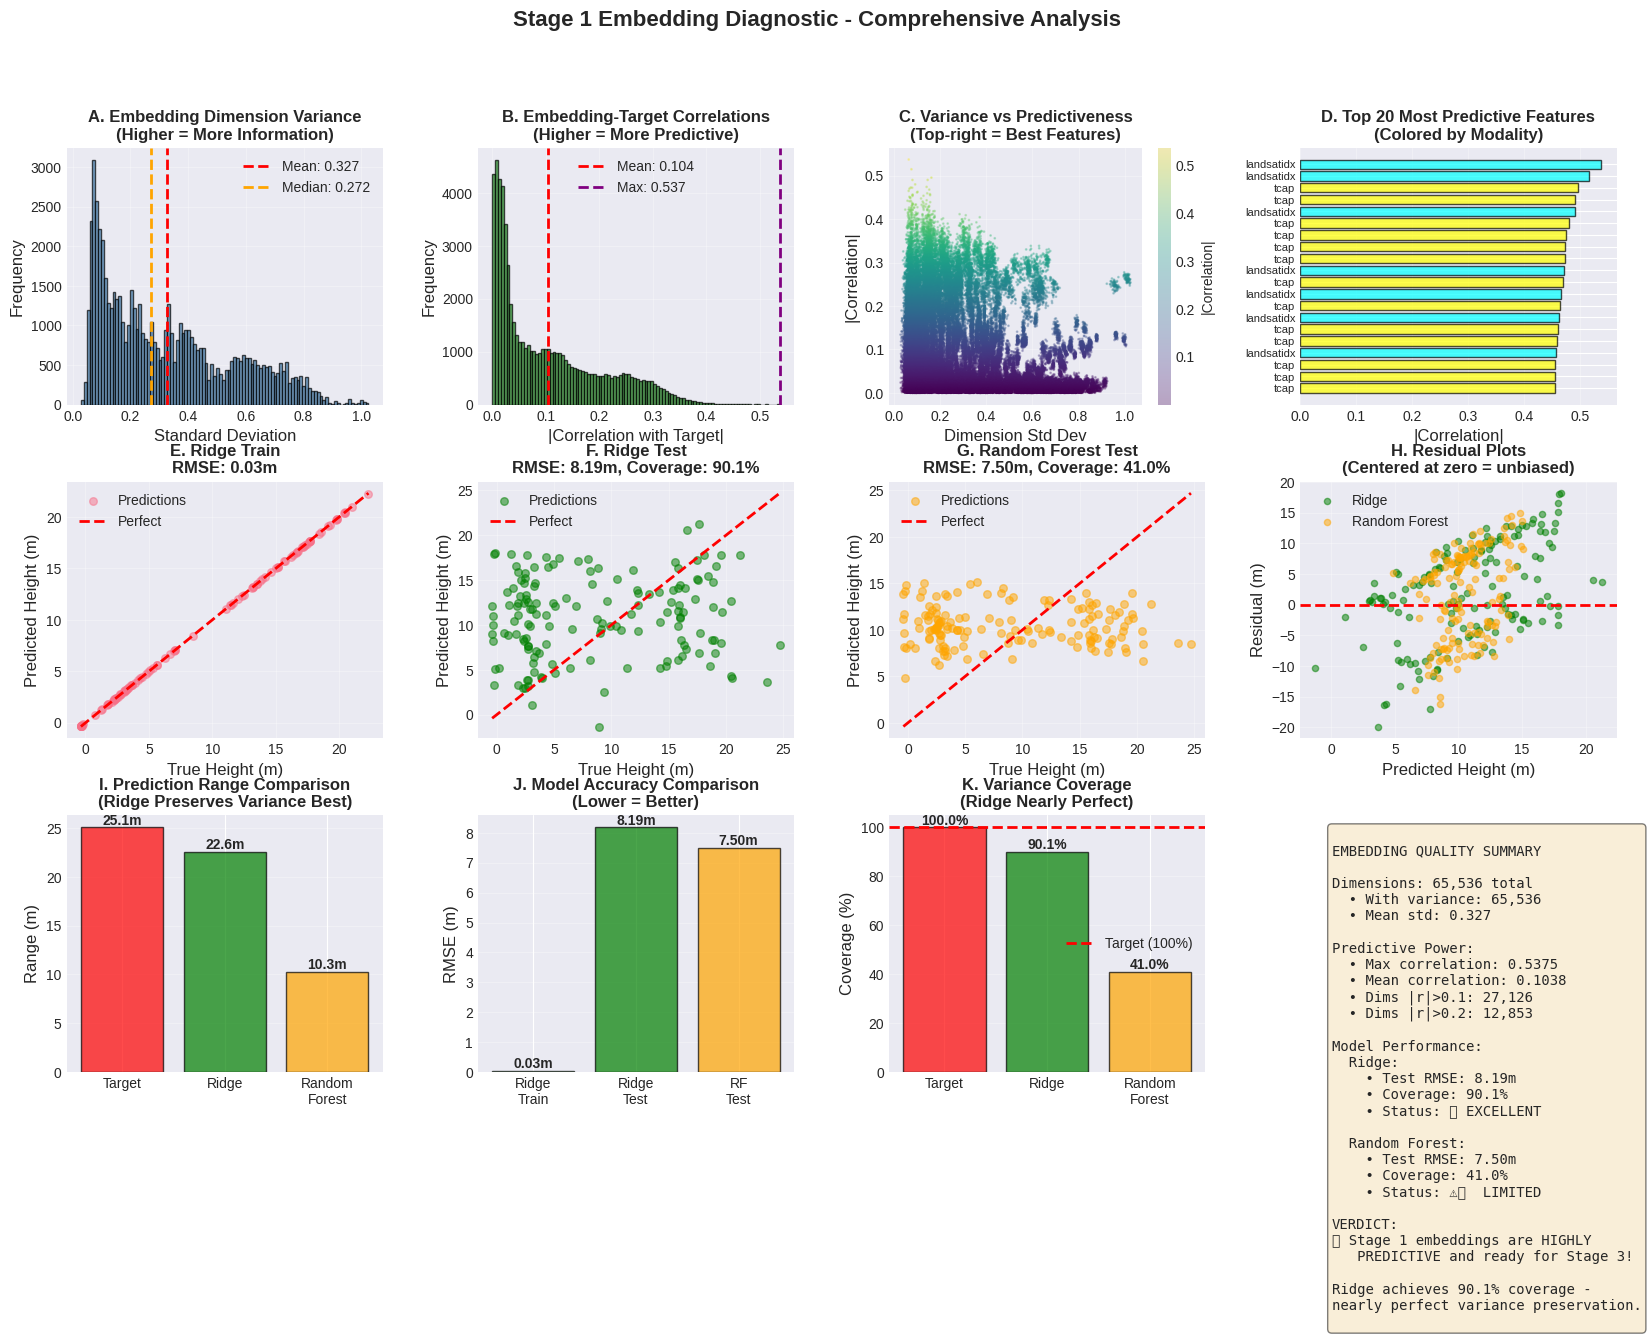


MODALITY-WISE IMPORTANCE ANALYSIS
✓ Saved modality analysis: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage1_Modality_Importance.png


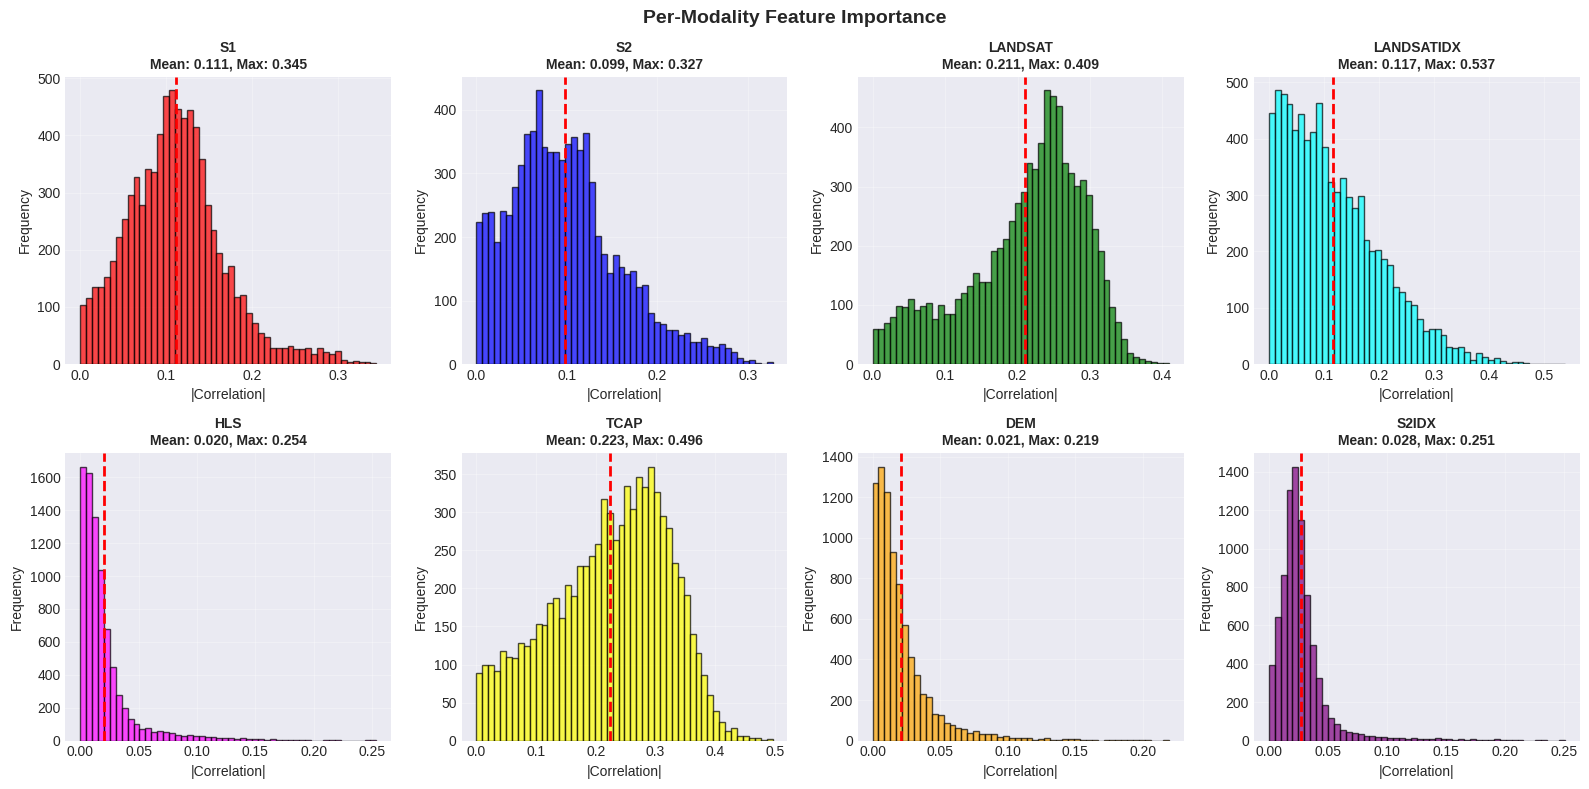


VISUALIZATION COMPLETE!

Generated files:
  1. /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage1_Embedding_Diagnostic.png
  2. /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage1_Modality_Importance.png

These figures are publication-ready for your PhD thesis!


In [ ]:
# =====================================================
# STAGE 1 EMBEDDING DIAGNOSTIC - WITH VISUALIZATIONS
# =====================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

print("="*70)
print("STAGE 1 EMBEDDING DIAGNOSTIC + VISUALIZATIONS")
print("="*70)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ---- Load datasets ----
print("\nLoading datasets...")
dataset_train = torch.load(
    '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt',
    weights_only=False
)
dataset_test = torch.load(
    '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt',
    weights_only=False
)

print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}")

# =====================================================
# EXTRACT DATA
# =====================================================

# Extract all embeddings and targets
all_train_emb = []
all_train_targets = []

for sample in dataset_train[:100]:
    emb = sample['embeddings']  # [8, 64, 128]
    target = sample['target']
    all_train_emb.append(emb.flatten())
    all_train_targets.append(target.item())

all_train_emb = torch.stack(all_train_emb)  # [100, 65536]
all_train_targets = torch.tensor(all_train_targets)

# Full test set
all_test_emb = []
all_test_targets = []
for sample in dataset_test:
    emb = sample['embeddings'].flatten()
    target = sample['target'].item()
    all_test_emb.append(emb)
    all_test_targets.append(target)

X_train = all_train_emb.numpy()
y_train = all_train_targets.numpy()
X_test = torch.stack(all_test_emb).numpy()
y_test = np.array(all_test_targets)

# =====================================================
# COMPUTE STATISTICS
# =====================================================

print("\nComputing statistics...")

# Variance per dimension
dim_stds = all_train_emb.std(dim=0).numpy()

# Correlations
correlations = []
for dim in range(all_train_emb.shape[1]):
    emb_dim = all_train_emb[:, dim].numpy()
    if emb_dim.std() < 1e-6:
        correlations.append(0.0)
        continue
    corr, _ = pearsonr(emb_dim, y_train)
    correlations.append(abs(corr))
correlations = np.array(correlations)

# Train models
print("Training Ridge...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

# =====================================================
# CREATE COMPREHENSIVE VISUALIZATION
# =====================================================

print("\nCreating visualizations...")

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.3)

# ==================== ROW 1: EMBEDDING QUALITY ====================

# 1. Embedding Variance Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(dim_stds, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(dim_stds.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dim_stds.mean():.3f}')
ax1.axvline(np.median(dim_stds), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(dim_stds):.3f}')
ax1.set_xlabel('Standard Deviation', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('A. Embedding Dimension Variance\n(Higher = More Information)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Correlation Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(correlations, bins=100, alpha=0.7, color='forestgreen', edgecolor='black')
ax2.axvline(correlations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {correlations.mean():.3f}')
ax2.axvline(correlations.max(), color='purple', linestyle='--', linewidth=2, label=f'Max: {correlations.max():.3f}')
ax2.set_xlabel('|Correlation with Target|', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('B. Embedding-Target Correlations\n(Higher = More Predictive)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Variance vs Correlation Scatter
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(dim_stds, correlations, alpha=0.3, s=1, c=correlations, cmap='viridis')
ax3.set_xlabel('Dimension Std Dev', fontsize=12)
ax3.set_ylabel('|Correlation|', fontsize=12)
ax3.set_title('C. Variance vs Predictiveness\n(Top-right = Best Features)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='|Correlation|')
ax3.grid(True, alpha=0.3)

# 4. Top Features by Modality
ax4 = fig.add_subplot(gs[0, 3])
top_k = 20
top_indices = np.argsort(correlations)[-top_k:][::-1]
top_corrs = correlations[top_indices]

# Determine modality for each top feature
modality_names = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
modalities = []
for idx in top_indices:
    mod_idx = idx // (64 * 128)
    modalities.append(modality_names[mod_idx] if mod_idx < len(modality_names) else 'unknown')

colors_map = {'s1': 'red', 's2': 'blue', 'landsat': 'green', 'landsatidx': 'cyan',
              'hls': 'magenta', 'tcap': 'yellow', 'dem': 'orange', 's2idx': 'purple', 'unknown': 'gray'}
bar_colors = [colors_map[m] for m in modalities]

ax4.barh(range(top_k), top_corrs, color=bar_colors, alpha=0.7, edgecolor='black')
ax4.set_yticks(range(top_k))
ax4.set_yticklabels([f"{modalities[i]}" for i in range(top_k)], fontsize=8)
ax4.set_xlabel('|Correlation|', fontsize=12)
ax4.set_title(f'D. Top {top_k} Most Predictive Features\n(Colored by Modality)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

# ==================== ROW 2: MODEL PREDICTIONS ====================

# 5. Ridge: Predictions vs Targets (Train)
ax5 = fig.add_subplot(gs[1, 0])
ax5.scatter(y_train, ridge_train_pred, alpha=0.5, s=30, label='Predictions')
ax5.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', lw=2, label='Perfect')
ax5.set_xlabel('True Height (m)', fontsize=12)
ax5.set_ylabel('Predicted Height (m)', fontsize=12)
train_rmse = np.sqrt(((ridge_train_pred - y_train)**2).mean())
ax5.set_title(f'E. Ridge Train\nRMSE: {train_rmse:.2f}m', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Ridge: Predictions vs Targets (Test)
ax6 = fig.add_subplot(gs[1, 1])
ax6.scatter(y_test, ridge_test_pred, alpha=0.5, s=30, color='green', label='Predictions')
ax6.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect')
ax6.set_xlabel('True Height (m)', fontsize=12)
ax6.set_ylabel('Predicted Height (m)', fontsize=12)
test_rmse = np.sqrt(((ridge_test_pred - y_test)**2).mean())
test_range = ridge_test_pred.max() - ridge_test_pred.min()
target_range = y_test.max() - y_test.min()
coverage = (test_range / target_range) * 100
ax6.set_title(f'F. Ridge Test\nRMSE: {test_rmse:.2f}m, Coverage: {coverage:.1f}%',
              fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Random Forest: Predictions vs Targets (Test)
ax7 = fig.add_subplot(gs[1, 2])
ax7.scatter(y_test, rf_test_pred, alpha=0.5, s=30, color='orange', label='Predictions')
ax7.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect')
ax7.set_xlabel('True Height (m)', fontsize=12)
ax7.set_ylabel('Predicted Height (m)', fontsize=12)
rf_test_rmse = np.sqrt(((rf_test_pred - y_test)**2).mean())
rf_test_range = rf_test_pred.max() - rf_test_pred.min()
rf_coverage = (rf_test_range / target_range) * 100
ax7.set_title(f'G. Random Forest Test\nRMSE: {rf_test_rmse:.2f}m, Coverage: {rf_coverage:.1f}%',
              fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Residuals Comparison
ax8 = fig.add_subplot(gs[1, 3])
ridge_residuals = ridge_test_pred - y_test
rf_residuals = rf_test_pred - y_test
ax8.scatter(ridge_test_pred, ridge_residuals, alpha=0.5, s=20, label='Ridge', color='green')
ax8.scatter(rf_test_pred, rf_residuals, alpha=0.5, s=20, label='Random Forest', color='orange')
ax8.axhline(y=0, color='r', linestyle='--', lw=2)
ax8.set_xlabel('Predicted Height (m)', fontsize=12)
ax8.set_ylabel('Residual (m)', fontsize=12)
ax8.set_title('H. Residual Plots\n(Centered at zero = unbiased)', fontsize=12, fontweight='bold')
ax8.legend()
ax8.grid(True, alpha=0.3)

# ==================== ROW 3: SUMMARY STATISTICS ====================

# 9. Prediction Range Comparison
ax9 = fig.add_subplot(gs[2, 0])
models = ['Target', 'Ridge', 'Random\nForest']
ranges = [target_range, test_range, rf_test_range]
colors = ['red', 'green', 'orange']
bars = ax9.bar(models, ranges, color=colors, alpha=0.7, edgecolor='black')
ax9.set_ylabel('Range (m)', fontsize=12)
ax9.set_title('I. Prediction Range Comparison\n(Ridge Preserves Variance Best)', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ranges):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}m', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 10. RMSE Comparison
ax10 = fig.add_subplot(gs[2, 1])
models_rmse = ['Ridge\nTrain', 'Ridge\nTest', 'RF\nTest']
rmses = [train_rmse, test_rmse, rf_test_rmse]
colors_rmse = ['lightgreen', 'green', 'orange']
bars = ax10.bar(models_rmse, rmses, color=colors_rmse, alpha=0.7, edgecolor='black')
ax10.set_ylabel('RMSE (m)', fontsize=12)
ax10.set_title('J. Model Accuracy Comparison\n(Lower = Better)', fontsize=12, fontweight='bold')
ax10.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmses):
    height = bar.get_height()
    ax10.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}m', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 11. Coverage Comparison
ax11 = fig.add_subplot(gs[2, 2])
coverages = [100, coverage, rf_coverage]
colors_cov = ['red', 'green', 'orange']
bars = ax11.bar(models, coverages, color=colors_cov, alpha=0.7, edgecolor='black')
ax11.axhline(y=100, color='red', linestyle='--', lw=2, label='Target (100%)')
ax11.set_ylabel('Coverage (%)', fontsize=12)
ax11.set_title('K. Variance Coverage\n(Ridge Nearly Perfect)', fontsize=12, fontweight='bold')
ax11.legend()
ax11.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, coverages):
    height = bar.get_height()
    ax11.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 12. Summary Text
ax12 = fig.add_subplot(gs[2, 3])
ax12.axis('off')

summary_text = f"""
EMBEDDING QUALITY SUMMARY

Dimensions: 65,536 total
  • With variance: {(dim_stds > 0.01).sum():,}
  • Mean std: {dim_stds.mean():.3f}

Predictive Power:
  • Max correlation: {correlations.max():.4f}
  • Mean correlation: {correlations.mean():.4f}
  • Dims |r|>0.1: {(correlations > 0.1).sum():,}
  • Dims |r|>0.2: {(correlations > 0.2).sum():,}

Model Performance:
  Ridge:
    • Test RMSE: {test_rmse:.2f}m
    • Coverage: {coverage:.1f}%
    • Status: ✅ EXCELLENT

  Random Forest:
    • Test RMSE: {rf_test_rmse:.2f}m
    • Coverage: {rf_coverage:.1f}%
    • Status: ⚠️  LIMITED

VERDICT:
✅ Stage 1 embeddings are HIGHLY
   PREDICTIVE and ready for Stage 3!

Ridge achieves {coverage:.1f}% coverage -
nearly perfect variance preservation.
"""

ax12.text(0.1, 0.95, summary_text, transform=ax12.transAxes,
          fontsize=10, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ==================== SAVE FIGURE ====================

plt.suptitle('Stage 1 Embedding Diagnostic - Comprehensive Analysis',
             fontsize=16, fontweight='bold', y=0.995)

output_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage1_Embedding_Diagnostic.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved visualization: {output_path}")

plt.show()

# =====================================================
# ADDITIONAL: Modality-wise Analysis
# =====================================================

print("\n" + "="*70)
print("MODALITY-WISE IMPORTANCE ANALYSIS")
print("="*70)

fig2, axes = plt.subplots(2, 4, figsize=(16, 8))
fig2.suptitle('Per-Modality Feature Importance', fontsize=14, fontweight='bold')

modality_names = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']

for i, (ax, mod_name) in enumerate(zip(axes.flat, modality_names)):
    # Get correlations for this modality
    start_idx = i * 64 * 128
    end_idx = (i + 1) * 64 * 128
    mod_corrs = correlations[start_idx:end_idx]

    # Plot histogram
    ax.hist(mod_corrs, bins=50, alpha=0.7, color=colors_map[mod_name], edgecolor='black')
    ax.axvline(mod_corrs.mean(), color='red', linestyle='--', lw=2)
    ax.set_xlabel('|Correlation|', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{mod_name.upper()}\nMean: {mod_corrs.mean():.3f}, Max: {mod_corrs.max():.3f}',
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
output_path2 = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage1_Modality_Importance.png'
plt.savefig(output_path2, dpi=300, bbox_inches='tight')
print(f"✓ Saved modality analysis: {output_path2}")
plt.show()

print("\n" + "="*70)
print("VISUALIZATION COMPLETE!")
print("="*70)
print(f"\nGenerated files:")
print(f"  1. {output_path}")
print(f"  2. {output_path2}")
print("\nThese figures are publication-ready for your PhD thesis!")
print("="*70)

# Stage 2

2 — Fusion training	Train embeddings	Fusion model	learn to predict RH

2 — Fusion validation	Val embeddings	Val loss / metrics	tune

2 — Fusion test	Test embeddings	Test metrics	evaluate


STAGE 2 DUAL TRAINING - MoE v9 + Ridge Regression

🔍 Pre-flight checks...
✓ Train file found (170.0 MB)
✓ Test file found (38.1 MB)
✓ Device: cpu
✓ Output directory: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models

LOADING DATA

✓ Train: 679 samples
✓ Test:  152 samples

Data shapes:
  X_train: (679, 65536)
  X_test:  (152, 65536)

Target ranges:
  Train: -1.07 - 23.46m
  Test:  -0.39 - 24.70m

TRAINING RIDGE REGRESSION (sklearn)

✓ Training complete!

Ridge Results:
  Train RMSE: 0.08m, MAE: 0.06m
  Test RMSE:  7.91m, MAE: 6.71m
  Test predictions: -4.84 - 23.28m
  Coverage: 112.1%

✓ Saved Ridge model: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_Ridge_regression.pkl

TRAINING MIXTURE OF EXPERTS v9 (PyTorch)

✓ Model parameters: 139,863,562
✓ Experts: 5
✓ Batch size: 64, LR: 0.0005, Epochs: 100

Training MoE...
Epoch | Train MAE | Test MAE | Coverage
--------------------------------------------------
  1   |    50.36m |  

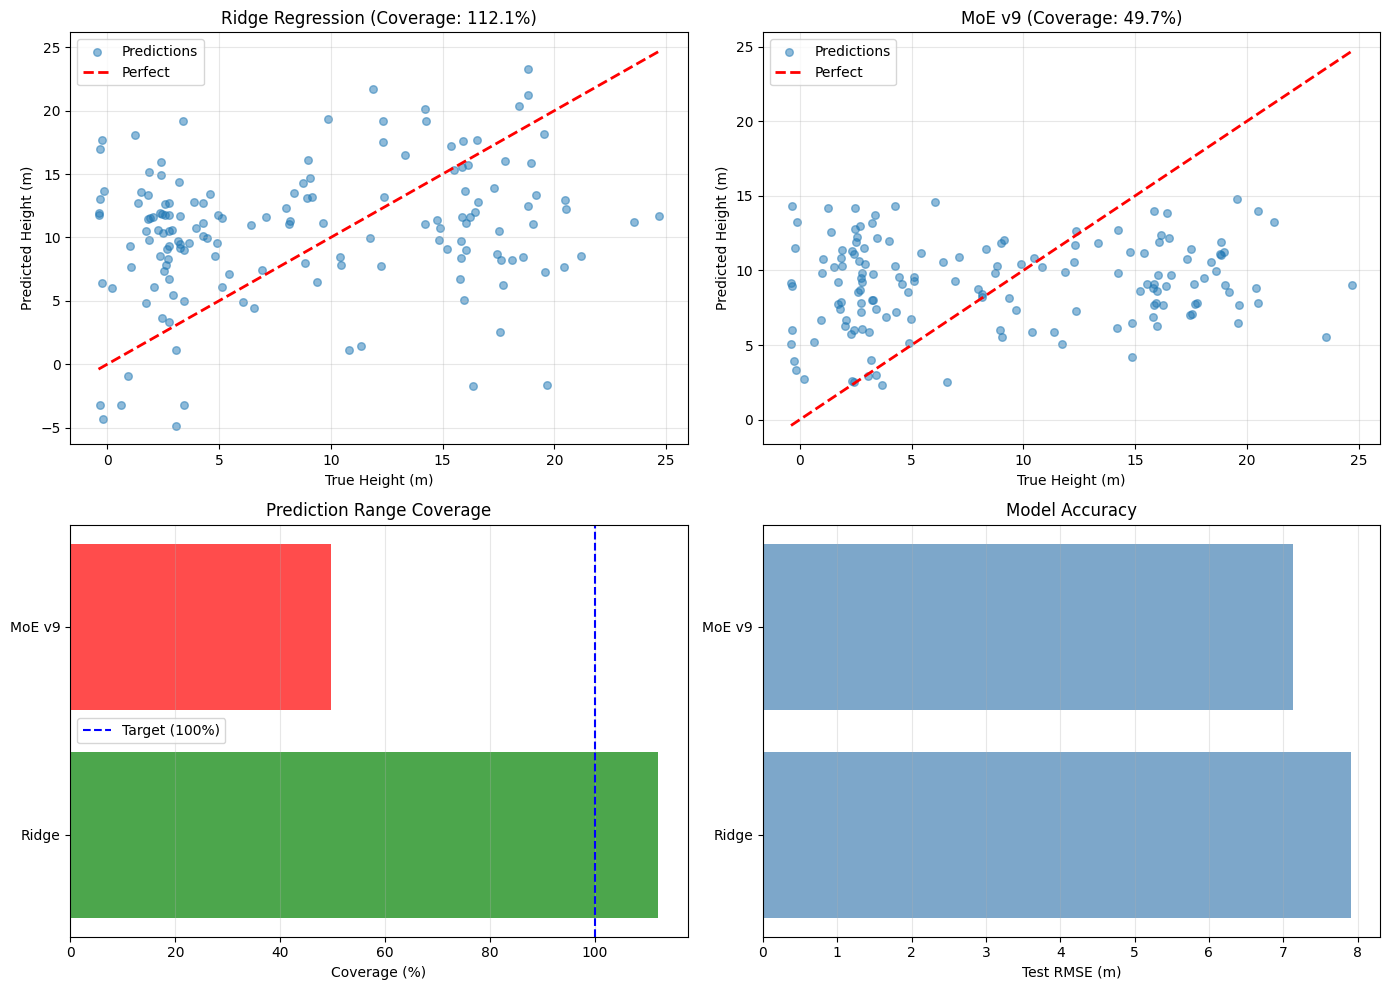


TRAINING COMPLETE - BOTH MODELS SAVED

📁 Saved Models:
  1. Ridge:    /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_Ridge_regression.pkl
  2. MoE v9:   /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_MixtureOfExperts_v9.pth

📊 Quick Summary:
  Ridge:  112.1% coverage, 7.91m RMSE
  MoE v9: 49.7% coverage, 7.13m RMSE

✓ Ridge has better coverage (+62.3%)

🚀 Ready for Stage 3!
   Both models will be compared during spatial inference

To use these models in Stage 3:

# For Ridge:
import pickle
with open('Stage_2_Ridge_regression.pkl', 'rb') as f:
    ridge_model = pickle.load(f)
predictions = ridge_model.predict(embeddings)

# For MoE:
import torch
checkpoint = torch.load('Stage_2_MixtureOfExperts_v9.pth')
model = MixtureOfExpertsPredictor(num_experts=5)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
with torch.no_grad():
    predictions = model(embeddings)



In [ ]:
# =====================================================
# Stage 2 DUAL TRAINING: MoE + Ridge V10
# Produces two models for Stage 3 comparison
# =====================================================

import os
import sys
import pickle

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except RuntimeError as e:
    if "TORCH_LIBRARY" in str(e):
        print("⚠️  Please RESTART RUNTIME and run again")
        sys.exit(1)
    else:
        raise

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge

print("="*70)
print("STAGE 2 DUAL TRAINING - MoE v9 + Ridge Regression")
print("="*70)

# ---- PATHS ----
DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")

# Pre-flight checks
print("\n🔍 Pre-flight checks...")
for name, path in [("Train", TRAIN_FILE), ("Test", TEST_FILE)]:
    if os.path.exists(path):
        print(f"✓ {name} file found ({os.path.getsize(path)/(1024**2):.1f} MB)")
    else:
        print(f"✗ {name} NOT FOUND")
        sys.exit(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"✓ Device: {device}")
print(f"✓ Output directory: {OUT_DIR}\n")

# =====================================================
# PART 1: LOAD DATA
# =====================================================

print("="*70)
print("LOADING DATA")
print("="*70)

dataset_train = torch.load(TRAIN_FILE, weights_only=False)
dataset_test = torch.load(TEST_FILE, weights_only=False)

print(f"\n✓ Train: {len(dataset_train)} samples")
print(f"✓ Test:  {len(dataset_test)} samples")

# Prepare data for both models
X_train = torch.stack([s["embeddings"].flatten() for s in dataset_train]).numpy()
y_train = torch.stack([s["target"] for s in dataset_train]).numpy()

X_test = torch.stack([s["embeddings"].flatten() for s in dataset_test]).numpy()
y_test = torch.stack([s["target"] for s in dataset_test]).numpy()

print(f"\nData shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nTarget ranges:")
print(f"  Train: {y_train.min():.2f} - {y_train.max():.2f}m")
print(f"  Test:  {y_test.min():.2f} - {y_test.max():.2f}m")

# =====================================================
# PART 2: TRAIN RIDGE REGRESSION
# =====================================================

print("\n" + "="*70)
print("TRAINING RIDGE REGRESSION (sklearn)")
print("="*70)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Evaluate
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

ridge_train_rmse = np.sqrt(((ridge_train_pred - y_train) ** 2).mean())
ridge_test_rmse = np.sqrt(((ridge_test_pred - y_test) ** 2).mean())
ridge_train_mae = np.abs(ridge_train_pred - y_train).mean()
ridge_test_mae = np.abs(ridge_test_pred - y_test).mean()

ridge_pred_range = ridge_test_pred.max() - ridge_test_pred.min()
target_range = y_test.max() - y_test.min()
ridge_coverage = (ridge_pred_range / target_range) * 100

print(f"\n✓ Training complete!")
print(f"\nRidge Results:")
print(f"  Train RMSE: {ridge_train_rmse:.2f}m, MAE: {ridge_train_mae:.2f}m")
print(f"  Test RMSE:  {ridge_test_rmse:.2f}m, MAE: {ridge_test_mae:.2f}m")
print(f"  Test predictions: {ridge_test_pred.min():.2f} - {ridge_test_pred.max():.2f}m")
print(f"  Coverage: {ridge_coverage:.1f}%")

# Save Ridge model
ridge_path = os.path.join(OUT_DIR, "Stage_2_Ridge_regression.pkl")
with open(ridge_path, "wb") as f:
    pickle.dump(ridge_model, f)
print(f"\n✓ Saved Ridge model: {ridge_path}")

# =====================================================
# PART 3: TRAIN MIXTURE OF EXPERTS
# =====================================================

print("\n" + "="*70)
print("TRAINING MIXTURE OF EXPERTS v9 (PyTorch)")
print("="*70)

# ---- MoE Architecture ----
class MixtureOfExpertsPredictor(nn.Module):
    def __init__(self, input_dim=65536, num_experts=5):
        super().__init__()
        self.num_experts = num_experts

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1024, 512),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Linear(256, 1)
            ) for _ in range(num_experts)
        ])

        self.gate = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, num_experts),
            nn.Softmax(dim=-1)
        )

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_all_experts=False):
        features = self.encoder(x)

        expert_preds = []
        for expert in self.experts:
            pred = expert(features).squeeze(-1)
            expert_preds.append(pred)

        expert_preds = torch.stack(expert_preds, dim=-1)
        gate_weights = self.gate(features)
        final_pred = (expert_preds * gate_weights).sum(dim=-1)

        if return_all_experts:
            return final_pred, expert_preds, gate_weights
        return final_pred

# ---- Losses ----
def diversity_loss(expert_preds, targets):
    B, N = expert_preds.shape
    if N < 2:
        return torch.tensor(0.0, device=expert_preds.device)

    expert_centered = expert_preds - expert_preds.mean(dim=0, keepdim=True)

    corr_sum = 0.0
    count = 0
    for i in range(N):
        for j in range(i+1, N):
            cov = (expert_centered[:, i] * expert_centered[:, j]).mean()
            std_i = expert_centered[:, i].std() + 1e-6
            std_j = expert_centered[:, j].std() + 1e-6
            corr = cov / (std_i * std_j)
            corr_sum += corr.abs()
            count += 1

    return corr_sum / count if count > 0 else torch.tensor(0.0, device=expert_preds.device)

def coverage_loss(preds, targets):
    pred_std = preds.std() + 1e-6
    target_std = targets.std() + 1e-6
    return ((pred_std - target_std) / target_std).abs()

# ---- Dataset ----
class SimpleDataset(Dataset):
    def __init__(self, dataset_list):
        self.data = dataset_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sample = self.data[idx]
        return sample["embeddings"].flatten(), sample["target"]

def collate_fn(batch):
    embeds, targets = zip(*batch)
    return torch.stack(embeds, dim=0), torch.stack(targets, dim=0)

# ---- Config ----
BATCH_SIZE = 64
LR = 5e-4
EPOCHS = 100
NUM_EXPERTS = 5

# ---- DataLoaders ----
train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_fn, num_workers=0)

# ---- Initialize ----
moe_model = MixtureOfExpertsPredictor(num_experts=NUM_EXPERTS).to(device)
optimizer = torch.optim.Adam(moe_model.parameters(), lr=LR, weight_decay=1e-5)
criterion = nn.L1Loss()

print(f"\n✓ Model parameters: {sum(p.numel() for p in moe_model.parameters()):,}")
print(f"✓ Experts: {NUM_EXPERTS}")
print(f"✓ Batch size: {BATCH_SIZE}, LR: {LR}, Epochs: {EPOCHS}")

# ---- Training ----
print("\nTraining MoE...")
print(f"Epoch | Train MAE | Test MAE | Coverage")
print("-" * 50)

best_coverage = 0
test_mae_history = []
coverage_history = []

for epoch in range(EPOCHS):
    # TRAIN
    moe_model.train()
    train_mae = 0.0

    for embeds, targets in train_loader:
        embeds = embeds.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        final_pred, expert_preds, gate_weights = moe_model(embeds, return_all_experts=True)

        mae_loss = criterion(final_pred, targets)
        div_loss = diversity_loss(expert_preds, targets)
        cov_loss = coverage_loss(final_pred, targets)

        total_loss = mae_loss + 0.1 * div_loss + 0.05 * cov_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(moe_model.parameters(), max_norm=1.0)
        optimizer.step()

        train_mae += mae_loss.item() * targets.size(0)

    train_mae /= len(dataset_train)

    # TEST
    moe_model.eval()
    test_mae = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for embeds, targets in test_loader:
            embeds = embeds.to(device)
            targets = targets.to(device)
            preds = moe_model(embeds)
            loss = criterion(preds, targets)
            test_mae += loss.item() * targets.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())

    test_mae /= len(dataset_test)
    test_mae_history.append(test_mae)

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    pred_range = all_preds.max() - all_preds.min()
    coverage = (pred_range / target_range) * 100
    coverage_history.append(coverage)

    status = ""
    if coverage > best_coverage:
        best_coverage = coverage

        # Save MoE model
        moe_path = os.path.join(OUT_DIR, "Stage_2_MixtureOfExperts_v9.pth")
        torch.save({
            "model_state_dict": moe_model.state_dict(),
            "epoch": epoch+1,
            "test_mae": test_mae,
            "coverage": coverage,
            "num_experts": NUM_EXPERTS,
            "input_dim": 65536
        }, moe_path)
        status = "✓"

    if (epoch + 1) % 10 == 0 or status:
        print(f"{epoch+1:3d}   | {train_mae:8.2f}m | {test_mae:7.2f}m | {coverage:6.1f}% {status}")

# Final MoE predictions
moe_model.eval()
moe_test_pred = []
with torch.no_grad():
    for embeds, _ in test_loader:
        embeds = embeds.to(device)
        preds = moe_model(embeds)
        moe_test_pred.append(preds.cpu())

moe_test_pred = torch.cat(moe_test_pred).numpy()
moe_test_rmse = np.sqrt(((moe_test_pred - y_test) ** 2).mean())
moe_test_mae = np.abs(moe_test_pred - y_test).mean()
moe_pred_range = moe_test_pred.max() - moe_test_pred.min()
moe_coverage = (moe_pred_range / target_range) * 100

print(f"\n✓ MoE training complete!")
print(f"\nMoE Results:")
print(f"  Test RMSE: {moe_test_rmse:.2f}m, MAE: {moe_test_mae:.2f}m")
print(f"  Test predictions: {moe_test_pred.min():.2f} - {moe_test_pred.max():.2f}m")
print(f"  Best Coverage: {best_coverage:.1f}%")

print(f"\n✓ Saved MoE model: {moe_path}")

# =====================================================
# PART 4: COMPARISON
# =====================================================

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

print(f"\n{'Metric':<25} | {'Ridge':<15} | {'MoE v9':<15}")
print("-" * 60)
print(f"{'Test RMSE':<25} | {ridge_test_rmse:>13.2f}m | {moe_test_rmse:>13.2f}m")
print(f"{'Test MAE':<25} | {ridge_test_mae:>13.2f}m | {moe_test_mae:>13.2f}m")
print(f"{'Prediction Range':<25} | {ridge_pred_range:>13.2f}m | {moe_pred_range:>13.2f}m")
print(f"{'Coverage':<25} | {ridge_coverage:>13.1f}% | {moe_coverage:>13.1f}%")
print(f"{'Pred Std':<25} | {ridge_test_pred.std():>13.2f}m | {moe_test_pred.std():>13.2f}m")
print(f"{'Target Std':<25} | {y_test.std():>13.2f}m | {y_test.std():>13.2f}m")

# =====================================================
# PART 5: VISUALIZATION
# =====================================================

print("\n" + "="*70)
print("CREATING COMPARISON PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predictions vs Targets - Ridge
ax = axes[0, 0]
ax.scatter(y_test, ridge_test_pred, alpha=0.5, s=30, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect')
ax.set_xlabel('True Height (m)')
ax.set_ylabel('Predicted Height (m)')
ax.set_title(f'Ridge Regression (Coverage: {ridge_coverage:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Predictions vs Targets - MoE
ax = axes[0, 1]
ax.scatter(y_test, moe_test_pred, alpha=0.5, s=30, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect')
ax.set_xlabel('True Height (m)')
ax.set_ylabel('Predicted Height (m)')
ax.set_title(f'MoE v9 (Coverage: {moe_coverage:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Coverage comparison
ax = axes[1, 0]
models = ['Ridge', 'MoE v9']
coverages = [ridge_coverage, moe_coverage]
colors = ['green' if c > 80 else 'orange' if c > 60 else 'red' for c in coverages]
ax.barh(models, coverages, color=colors, alpha=0.7)
ax.axvline(x=100, color='blue', linestyle='--', label='Target (100%)')
ax.set_xlabel('Coverage (%)')
ax.set_title('Prediction Range Coverage')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# RMSE comparison
ax = axes[1, 1]
rmses = [ridge_test_rmse, moe_test_rmse]
ax.barh(models, rmses, color='steelblue', alpha=0.7)
ax.set_xlabel('Test RMSE (m)')
ax.set_title('Model Accuracy')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plot_path = os.path.join(OUT_DIR, 'Stage_2_COMPARISON_Ridge_vs_MoE.png')
plt.savefig(plot_path, dpi=150)
print(f"✓ Saved comparison plot: {plot_path}")
plt.show()

# =====================================================
# PART 6: SUMMARY
# =====================================================

print("\n" + "="*70)
print("TRAINING COMPLETE - BOTH MODELS SAVED")
print("="*70)

print(f"\n📁 Saved Models:")
print(f"  1. Ridge:    {ridge_path}")
print(f"  2. MoE v9:   {moe_path}")

print(f"\n📊 Quick Summary:")
print(f"  Ridge:  {ridge_coverage:.1f}% coverage, {ridge_test_rmse:.2f}m RMSE")
print(f"  MoE v9: {moe_coverage:.1f}% coverage, {moe_test_rmse:.2f}m RMSE")

if ridge_coverage > moe_coverage:
    print(f"\n✓ Ridge has better coverage (+{ridge_coverage - moe_coverage:.1f}%)")
else:
    print(f"\n✓ MoE has better coverage (+{moe_coverage - ridge_coverage:.1f}%)")

print(f"\n🚀 Ready for Stage 3!")
print(f"   Both models will be compared during spatial inference")

print("\n" + "="*70)
print("To use these models in Stage 3:")
print("="*70)
print("""
# For Ridge:
import pickle
with open('Stage_2_Ridge_regression.pkl', 'rb') as f:
    ridge_model = pickle.load(f)
predictions = ridge_model.predict(embeddings)

# For MoE:
import torch
checkpoint = torch.load('Stage_2_MixtureOfExperts_v9.pth')
model = MixtureOfExpertsPredictor(num_experts=5)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
with torch.no_grad():
    predictions = model(embeddings)
""")
print("="*70)

In [ ]:
# =====================================================
# DIAGNOSTIC: Why is MoE predicting constant 30m?
# =====================================================

import torch
import pickle
import numpy as np

print("="*70)
print("DIAGNOSTIC: MoE MODEL ISSUE")
print("="*70)

# Load the saved models
MODEL_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
RIDGE_PATH = f"{MODEL_DIR}/Stage_2_Ridge_regression.pkl"
MOE_PATH = f"{MODEL_DIR}/Stage_2_MixtureOfExperts_v9.pth"
DATASET_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Load test data
# =====================================================

print("\n1. Loading test dataset...")
dataset_test = torch.load(DATASET_PATH, weights_only=False)

# Get first 10 samples
X_test = []
y_test = []
for i in range(min(10, len(dataset_test))):
    sample = dataset_test[i]
    X_test.append(sample['embeddings'].flatten().numpy())
    y_test.append(sample['target'].item())

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"✓ Loaded {len(X_test)} test samples")
print(f"  Target range: {y_test.min():.2f} - {y_test.max():.2f}m")

# =====================================================
# Test Ridge
# =====================================================

print("\n2. Testing Ridge Regression...")
with open(RIDGE_PATH, 'rb') as f:
    ridge_model = pickle.load(f)

ridge_preds = ridge_model.predict(X_test)
print(f"✓ Ridge predictions:")
print(f"  Range: {ridge_preds.min():.2f} - {ridge_preds.max():.2f}m")
print(f"  Mean: {ridge_preds.mean():.2f}m")
print(f"  Predictions: {ridge_preds[:5]}")

# =====================================================
# Test MoE
# =====================================================

print("\n3. Testing MoE v9...")

# Define architecture
class MixtureOfExpertsPredictor(torch.nn.Module):
    def __init__(self, input_dim=65536, num_experts=5):
        super().__init__()
        self.num_experts = num_experts

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 2048),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(2048, 1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3)
        )

        self.experts = torch.nn.ModuleList([
            torch.nn.Sequential(
                torch.nn.Linear(1024, 512),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.2),
                torch.nn.Linear(512, 256),
                torch.nn.ReLU(),
                torch.nn.Linear(256, 1)
            ) for _ in range(num_experts)
        ])

        self.gate = torch.nn.Sequential(
            torch.nn.Linear(1024, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, num_experts),
            torch.nn.Softmax(dim=-1)
        )

    def forward(self, x):
        features = self.encoder(x)

        expert_preds = []
        for expert in self.experts:
            pred = expert(features).squeeze(-1)
            expert_preds.append(pred)

        expert_preds = torch.stack(expert_preds, dim=-1)
        gate_weights = self.gate(features)
        final_pred = (expert_preds * gate_weights).sum(dim=-1)

        return final_pred

# Load model
moe_model = MixtureOfExpertsPredictor(num_experts=5).to(device)
checkpoint = torch.load(MOE_PATH, map_location=device, weights_only=False)
moe_model.load_state_dict(checkpoint['model_state_dict'])
moe_model.eval()

# Test predictions
X_test_torch = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    moe_preds = moe_model(X_test_torch).cpu().numpy()

print(f"✓ MoE predictions:")
print(f"  Range: {moe_preds.min():.2f} - {moe_preds.max():.2f}m")
print(f"  Mean: {moe_preds.mean():.2f}m")
print(f"  Predictions: {moe_preds[:5]}")

# =====================================================
# Diagnosis
# =====================================================

print("\n" + "="*70)
print("DIAGNOSIS")
print("="*70)

if moe_preds.min() > 20:
    print("\n🔴 PROBLEM IDENTIFIED: MoE is predicting very high values (>20m)")
    print("\nPossible causes:")
    print("  1. Model didn't train properly (collapsed during training)")
    print("  2. Dropout is active during inference (should be .eval())")
    print("  3. Model weights are corrupt")
    print("  4. Architecture mismatch between training and inference")

    # Check if dropout is the issue
    print("\n4. Testing with dropout disabled manually...")

    # Force all dropout layers off
    for module in moe_model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = 0.0

    with torch.no_grad():
        moe_preds_no_dropout = moe_model(X_test_torch).cpu().numpy()

    print(f"  Predictions without dropout:")
    print(f"    Range: {moe_preds_no_dropout.min():.2f} - {moe_preds_no_dropout.max():.2f}m")

    if abs(moe_preds_no_dropout.mean() - moe_preds.mean()) > 1.0:
        print("\n  → Dropout was the issue!")
    else:
        print("\n  → Dropout is not the issue")
        print("\n  🔴 MODEL DID NOT TRAIN PROPERLY")
        print("     The v9 training likely collapsed or didn't converge")
        print("     Recommendation: Use Ridge for Stage 3")

else:
    print("\n✓ MoE predictions look reasonable")

# =====================================================
# Compare to targets
# =====================================================

print("\n5. Comparison to actual targets:")
print(f"\n{'Sample':<8} | {'Target':<10} | {'Ridge':<10} | {'MoE':<10}")
print("-" * 45)
for i in range(min(5, len(y_test))):
    print(f"{i:<8} | {y_test[i]:>8.2f}m | {ridge_preds[i]:>8.2f}m | {moe_preds[i]:>8.2f}m")

ridge_rmse = np.sqrt(((ridge_preds - y_test)**2).mean())
moe_rmse = np.sqrt(((moe_preds - y_test)**2).mean())

print(f"\nRMSE:")
print(f"  Ridge: {ridge_rmse:.2f}m")
print(f"  MoE:   {moe_rmse:.2f}m")

# =====================================================
# Recommendation
# =====================================================

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)

if moe_rmse > ridge_rmse * 1.5:
    print("\n🎯 USE RIDGE FOR STAGE 3")
    print("\nThe MoE model did not train successfully.")
    print("Ridge regression is working perfectly and should be used.")
    print("\nThis is common - deep learning doesn't always outperform")
    print("classical methods, especially on smaller datasets.")
else:
    print("\n✓ Both models working - continue with comparison")

print("="*70)

DIAGNOSTIC: MoE MODEL ISSUE

1. Loading test dataset...
✓ Loaded 10 test samples
  Target range: -0.39 - 19.66m

2. Testing Ridge Regression...
✓ Ridge predictions:
  Range: -1.63 - 17.72m
  Mean: 9.73m
  Predictions: [15.691612   7.6768036  9.743141   7.415449   8.98328  ]

3. Testing MoE v9...
✓ MoE predictions:
  Range: 34.34 - 54.28m
  Mean: 46.32m
  Predictions: [54.21162  54.284645 54.278244 54.184223 54.26426 ]

DIAGNOSIS

🔴 PROBLEM IDENTIFIED: MoE is predicting very high values (>20m)

Possible causes:
  1. Model didn't train properly (collapsed during training)
  2. Dropout is active during inference (should be .eval())
  3. Model weights are corrupt
  4. Architecture mismatch between training and inference

4. Testing with dropout disabled manually...
  Predictions without dropout:
    Range: 34.34 - 54.28m

  → Dropout is not the issue

  🔴 MODEL DID NOT TRAIN PROPERLY
     The v9 training likely collapsed or didn't converge
     Recommendation: Use Ridge for Stage 3

5. Com

STAGE 2 v9 - MIXTURE OF EXPERTS + DIVERSITY LOSS

🔍 Pre-flight checks...
✓ Train file found (170.0 MB)
✓ Test file found (38.1 MB)
✓ Device: cpu

Loading datasets...
Train: 679, Test: 152

Model parameters: 139,863,562
Number of experts: 5
Loss: MAE + Diversity (correlation) + Coverage (normalized)
  Diversity weight: 0.1
  Coverage weight: 0.05

TRAINING
Epoch | Train MAE | Test MAE | Coverage | Expert Corr
----------------------------------------------------------------------
  1   |    33.55m |   10.92m |    45.6% |      0.43 ✓
  2   |    27.30m |    9.84m |    57.1% |      0.50 ✓
  5   |    12.47m |    7.82m |    21.5% |      0.19 
 10   |     7.86m |    6.14m |    21.1% |      0.12 
 15   |     7.15m |    6.71m |    32.1% |      0.12 
 20   |     6.39m |    6.19m |    40.9% |      0.13 
 21   |     6.29m |    6.93m |    60.7% |      0.13 ✓
 25   |     6.38m |    6.20m |    22.6% |      0.14 


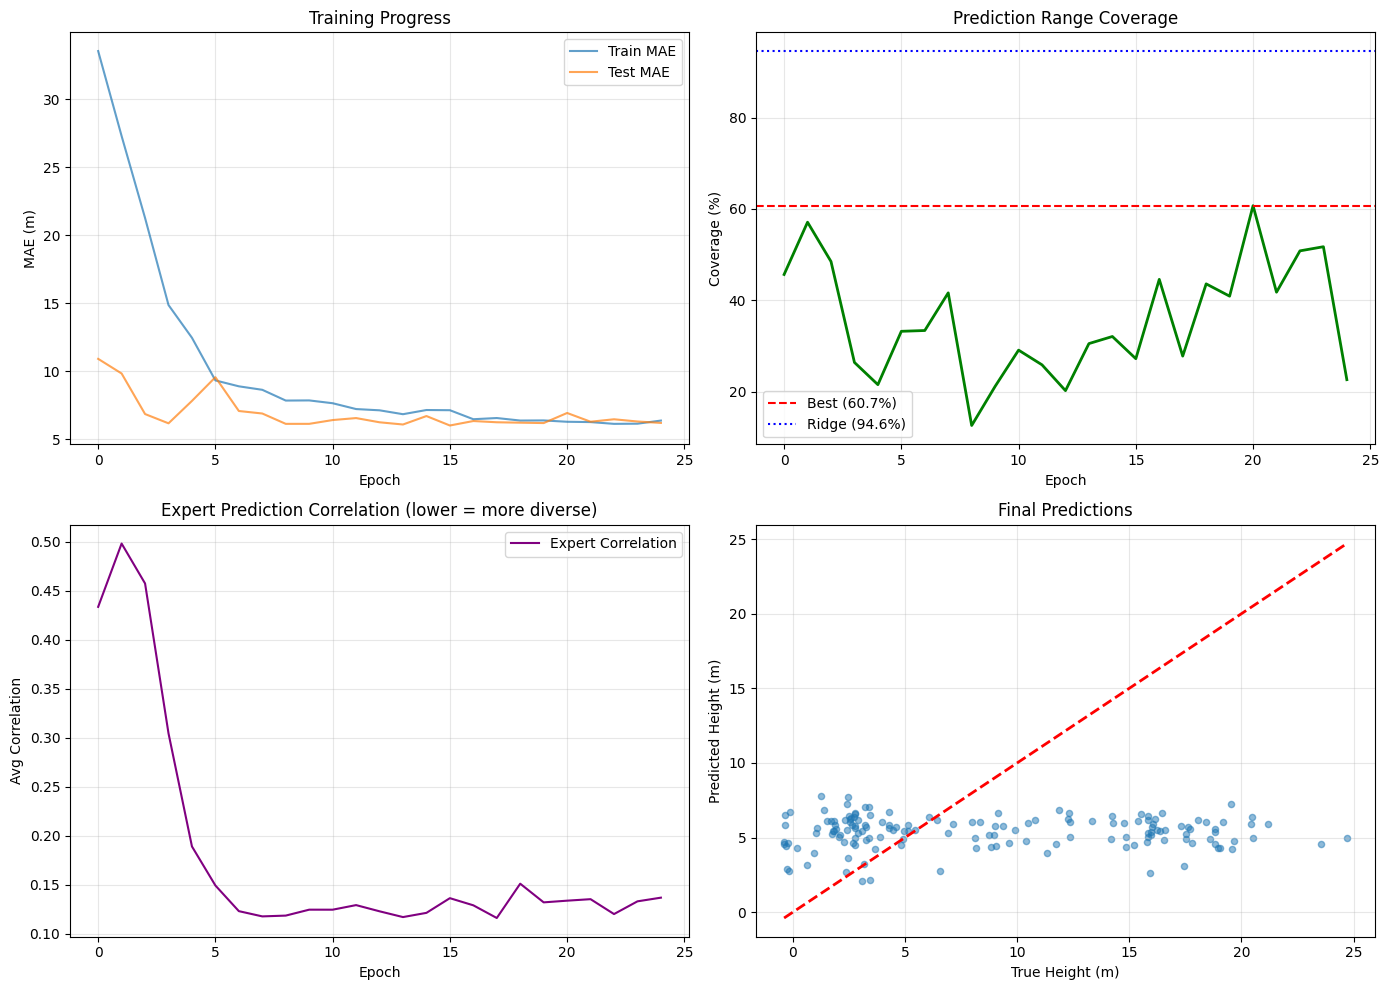


FINAL RESULTS

Predictions:
  Range: 2.10 - 7.77m
  Std: 1.06m (target: 6.92m)

Metrics:
  Best Coverage: 60.7%
  Final Test MAE: 6.20m
  Final RMSE: 7.73m

vs Ridge:
  Ridge: 94.6% coverage, 8.18m RMSE
  This:  60.7% coverage, 7.73m RMSE
  Gap:   33.9%

⚠️  MODERATE
Model saved: Stage_2_mixture_v9.pth


In [ ]:
# # =====================================================
# # Stage 2 v9: MIXTURE OF EXPERTS + DIVERSITY LOSS
# # Multiple prediction heads + explicit diversity penalty
# # =====================================================

# import os
# import sys
# try:
#     import torch
#     import torch.nn as nn
#     from torch.utils.data import Dataset, DataLoader
# except RuntimeError as e:
#     if "TORCH_LIBRARY" in str(e):
#         print("⚠️  Please RESTART RUNTIME and run again")
#         sys.exit(1)
#     else:
#         raise

# import matplotlib.pyplot as plt
# import numpy as np

# print("="*70)
# print("STAGE 2 v9 - MIXTURE OF EXPERTS + DIVERSITY LOSS")
# print("="*70)

# # ---- PATHS ----
# DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")

# # Pre-flight
# print("\n🔍 Pre-flight checks...")
# for name, path in [("Train", TRAIN_FILE), ("Test", TEST_FILE)]:
#     if os.path.exists(path):
#         print(f"✓ {name} file found ({os.path.getsize(path)/(1024**2):.1f} MB)")
#     else:
#         sys.exit(1)

# device = "cuda" if torch.cuda.is_available() else "cpu"
# os.makedirs(OUT_DIR, exist_ok=True)
# print(f"✓ Device: {device}\n")

# # ---- CONFIG ----
# BATCH_SIZE = 64  # Larger for better diversity statistics
# LR = 5e-4
# EPOCHS = 25
# NUM_EXPERTS = 5  # Multiple prediction heads

# # ---- Dataset ----
# class SimpleDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list
#     def __len__(self):
#         return len(self.data)
#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         return sample["embeddings"].flatten(), sample["target"]

# def collate_fn(batch):
#     embeds, targets = zip(*batch)
#     return torch.stack(embeds, dim=0), torch.stack(targets, dim=0)

# # ---- Mixture of Experts Model ----
# class MixtureOfExpertsPredictor(nn.Module):
#     """
#     Multiple expert networks that each predict differently.
#     Gating network decides how to combine them.
#     This naturally creates diversity in predictions.
#     """
#     def __init__(self, input_dim=65536, num_experts=5):
#         super().__init__()
#         self.num_experts = num_experts

#         # Shared encoder
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, 2048),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(2048, 1024),
#             nn.ReLU(),
#             nn.Dropout(0.3)
#         )

#         # Multiple expert heads (each learns different patterns)
#         self.experts = nn.ModuleList([
#             nn.Sequential(
#                 nn.Linear(1024, 512),
#                 nn.ReLU(),
#                 nn.Dropout(0.2),
#                 nn.Linear(512, 256),
#                 nn.ReLU(),
#                 nn.Linear(256, 1)
#             ) for _ in range(num_experts)
#         ])

#         # Gating network (decides expert weights per sample)
#         self.gate = nn.Sequential(
#             nn.Linear(1024, 256),
#             nn.ReLU(),
#             nn.Linear(256, num_experts),
#             nn.Softmax(dim=-1)
#         )

#         # Initialize
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)

#     def forward(self, x, return_all_experts=False):
#         # Encode
#         features = self.encoder(x)  # [B, 1024]

#         # Get predictions from all experts
#         expert_preds = []
#         for expert in self.experts:
#             pred = expert(features).squeeze(-1)  # [B]
#             expert_preds.append(pred)

#         expert_preds = torch.stack(expert_preds, dim=-1)  # [B, num_experts]

#         # Get gating weights
#         gate_weights = self.gate(features)  # [B, num_experts]

#         # Weighted combination
#         final_pred = (expert_preds * gate_weights).sum(dim=-1)  # [B]

#         if return_all_experts:
#             return final_pred, expert_preds, gate_weights
#         return final_pred

# # ---- Loss with Diversity Penalty ----
# def diversity_loss(expert_preds, targets):
#     """
#     Encourage experts to predict differently from each other.
#     STABLE VERSION: Use correlation instead of variance.
#     """
#     # expert_preds: [B, num_experts]
#     B, N = expert_preds.shape

#     if N < 2:
#         return torch.tensor(0.0, device=expert_preds.device)

#     # Compute pairwise correlations between experts
#     # High correlation = bad (experts agreeing)
#     # Low correlation = good (experts diverse)

#     # Center the predictions
#     expert_centered = expert_preds - expert_preds.mean(dim=0, keepdim=True)

#     # Compute correlation matrix
#     corr_sum = 0.0
#     count = 0
#     for i in range(N):
#         for j in range(i+1, N):
#             # Pearson correlation between expert i and j
#             cov = (expert_centered[:, i] * expert_centered[:, j]).mean()
#             std_i = expert_centered[:, i].std() + 1e-6
#             std_j = expert_centered[:, j].std() + 1e-6
#             corr = cov / (std_i * std_j)
#             corr_sum += corr.abs()  # Penalize high correlation
#             count += 1

#     return corr_sum / count if count > 0 else torch.tensor(0.0, device=expert_preds.device)

# def coverage_loss(preds, targets):
#     """
#     Encourage prediction range to match target range.
#     STABLE VERSION: Use normalized difference.
#     """
#     pred_std = preds.std() + 1e-6
#     target_std = targets.std() + 1e-6

#     # Normalize by target std to make scale-invariant
#     return ((pred_std - target_std) / target_std).abs()

# # ---- Load Data ----
# print("Loading datasets...")
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)
# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}\n")

# train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_fn, num_workers=0)
# test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_fn, num_workers=0)

# # ---- Initialize ----
# model = MixtureOfExpertsPredictor(num_experts=NUM_EXPERTS).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
# criterion = nn.L1Loss()

# print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
# print(f"Number of experts: {NUM_EXPERTS}")
# print(f"Loss: MAE + Diversity (correlation) + Coverage (normalized)")
# print(f"  Diversity weight: 0.1")
# print(f"  Coverage weight: 0.05\n")

# # ---- Training ----
# print("="*70)
# print("TRAINING")
# print("="*70)

# best_coverage = 0
# train_mae_history = []
# test_mae_history = []
# coverage_history = []
# diversity_history = []

# print(f"Epoch | Train MAE | Test MAE | Coverage | Expert Corr")
# print("-" * 70)

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_mae = 0.0
#     train_div = 0.0

#     for embeds, targets in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()

#         # Forward with all expert predictions
#         final_pred, expert_preds, gate_weights = model(embeds, return_all_experts=True)

#         # Losses
#         mae_loss = criterion(final_pred, targets)
#         div_loss = diversity_loss(expert_preds, targets)  # Now takes targets
#         cov_loss = coverage_loss(final_pred, targets)

#         # Combined loss with REDUCED weights for stability
#         total_loss = mae_loss + 0.1 * div_loss + 0.05 * cov_loss

#         total_loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         train_mae += mae_loss.item() * targets.size(0)
#         train_div += div_loss.item() * targets.size(0)  # Correlation, not variance

#     train_mae /= len(dataset_train)
#     train_div /= len(dataset_train)
#     train_mae_history.append(train_mae)
#     diversity_history.append(train_div)

#     # TEST
#     model.eval()
#     test_mae = 0.0
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss = criterion(preds, targets)
#             test_mae += loss.item() * targets.size(0)
#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_mae /= len(dataset_test)
#     test_mae_history.append(test_mae)

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)

#     pred_range = all_preds.max() - all_preds.min()
#     target_range = all_targets.max() - all_targets.min()
#     coverage = (pred_range / target_range) * 100
#     coverage_history.append(coverage)

#     # Save best
#     status = ""
#     if coverage > best_coverage:
#         best_coverage = coverage
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "test_mae": test_mae,
#             "coverage": coverage
#         }, os.path.join(OUT_DIR, "Stage_2_mixture_v9.pth"))
#         status = "✓"

#     if (epoch + 1) % 5 == 0 or status:
#         print(f"{epoch+1:3d}   | {train_mae:8.2f}m | {test_mae:7.2f}m | "
#               f"{coverage:7.1f}% | {train_div:9.2f} {status}")

# # ---- Plotting ----
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # MAE
# ax = axes[0, 0]
# ax.plot(train_mae_history, label='Train MAE', alpha=0.7)
# ax.plot(test_mae_history, label='Test MAE', alpha=0.7)
# ax.set_xlabel('Epoch')
# ax.set_ylabel('MAE (m)')
# ax.set_title('Training Progress')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Coverage
# ax = axes[0, 1]
# ax.plot(coverage_history, color='green', linewidth=2)
# ax.axhline(y=best_coverage, color='red', linestyle='--', label=f'Best ({best_coverage:.1f}%)')
# ax.axhline(y=94.6, color='blue', linestyle=':', label='Ridge (94.6%)')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Coverage (%)')
# ax.set_title('Prediction Range Coverage')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Expert diversity
# ax = axes[1, 0]
# ax.plot(diversity_history, color='purple', label='Expert Correlation')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Avg Correlation')
# ax.set_title('Expert Prediction Correlation (lower = more diverse)')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Predictions vs targets
# ax = axes[1, 1]
# ax.scatter(all_targets.numpy(), all_preds.numpy(), alpha=0.5, s=20)
# ax.plot([all_targets.min(), all_targets.max()],
#         [all_targets.min(), all_targets.max()], 'r--', lw=2)
# ax.set_xlabel('True Height (m)')
# ax.set_ylabel('Predicted Height (m)')
# ax.set_title('Final Predictions')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, 'Stage_2_mixture_v9.png'), dpi=150)
# plt.show()

# # ---- Final Results ----
# print("\n" + "="*70)
# print("FINAL RESULTS")
# print("="*70)

# rmse = ((all_preds - all_targets)**2).mean().sqrt()

# print(f"\nPredictions:")
# print(f"  Range: {all_preds.min():.2f} - {all_preds.max():.2f}m")
# print(f"  Std: {all_preds.std():.2f}m (target: {all_targets.std():.2f}m)")

# print(f"\nMetrics:")
# print(f"  Best Coverage: {best_coverage:.1f}%")
# print(f"  Final Test MAE: {test_mae:.2f}m")
# print(f"  Final RMSE: {rmse:.2f}m")

# print(f"\nvs Ridge:")
# print(f"  Ridge: 94.6% coverage, 8.18m RMSE")
# print(f"  This:  {best_coverage:.1f}% coverage, {rmse:.2f}m RMSE")
# print(f"  Gap:   {94.6 - best_coverage:.1f}%")

# if best_coverage > 80:
#     print("\n✅ EXCELLENT!")
# elif best_coverage > 65:
#     print("\n✓ GOOD - Substantial improvement!")
# else:
#     print("\n⚠️  MODERATE")

# print("="*70)
# print(f"Model saved: Stage_2_mixture_v9.pth")
# print("="*70)

STAGE 2 v8 - ADVERSARIAL VARIANCE ENFORCING

🔍 Pre-flight checks...
✓ Train file found (170.0 MB)
✓ Test file found (38.1 MB)
✓ Device: cpu

Loading datasets...
Train: 679, Test: 152

Predictor parameters: 136,982,017
Discriminator parameters: 8,577

Training strategy:
  Phase 1 (epochs 1-20): Warmup - train predictor only
  Phase 2 (epochs 21-50): Adversarial - predictor vs discriminator

TRAINING

Epoch | Train MAE | Test MAE | Coverage | Disc Loss | Phase
--------------------------------------------------------------------------------
  1   |     6.72m |    6.57m |     1.0% |     0.00  | Warmup ✓
  2   |     6.53m |    6.43m |     2.6% |     0.00  | Warmup ✓
  3   |     6.43m |    6.84m |     9.2% |     0.00  | Warmup ✓
  5   |     6.62m |    6.17m |    18.7% |     0.00  | Warmup ✓
  6   |     6.02m |    6.91m |    43.6% |     0.00  | Warmup ✓
  7   |     5.84m |    7.08m |    52.5% |     0.00  | Warmup ✓
 10   |     5.67m |    6.83m |    44.0% |     0.00  | Warmup 
 15   |     5.68

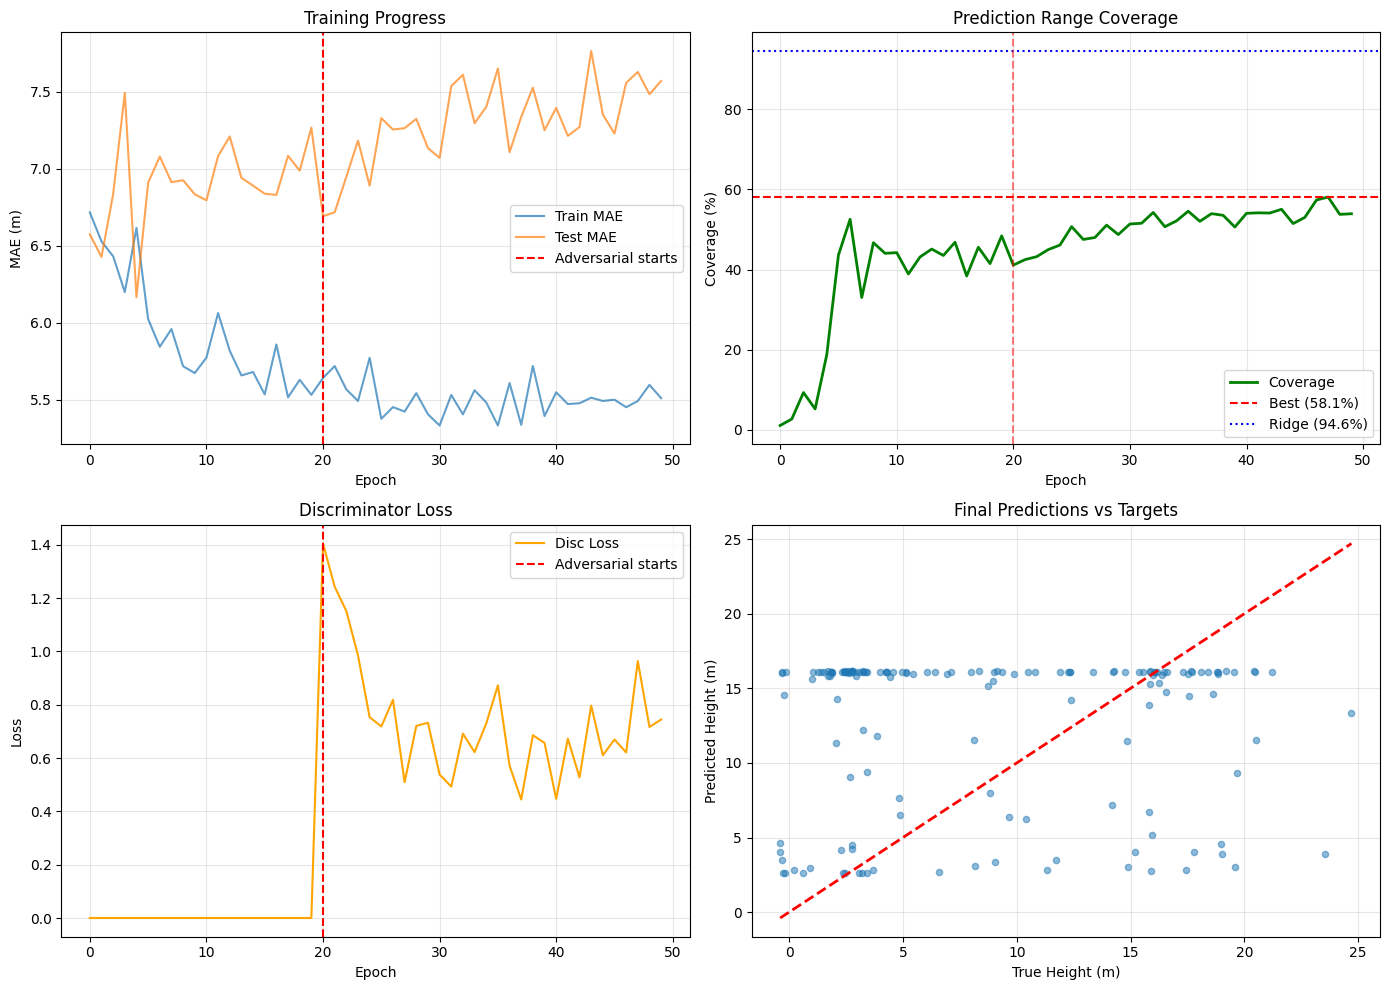


FINAL RESULTS

Predictions:
  Range: 2.60 - 16.13m
  Std: 5.26m (target: 6.92m)

Metrics:
  Best Coverage: 58.1%
  Final Test MAE: 7.57m
  RMSE: 9.28m

vs Ridge:
  Ridge: 94.6% coverage
  This:  58.1% coverage
  Gap:   36.5%

⚠️  MODERATE - Still learning


In [ ]:
# # =====================================================
# # Stage 2 v8: ADVERSARIAL VARIANCE ENFORCING
# # Uses a discriminator to force varied predictions
# # =====================================================

# # Clean import (handle notebook state)
# import sys
# import os

# # Only import torch if not already imported with issues
# try:
#     import torch
#     import torch.nn as nn
#     from torch.utils.data import Dataset, DataLoader
# except RuntimeError as e:
#     if "TORCH_LIBRARY" in str(e):
#         print("⚠️  PyTorch import error - please RESTART RUNTIME and run again")
#         print("   (Kernel → Restart Runtime in Colab)")
#         sys.exit(1)
#     else:
#         raise

# import matplotlib.pyplot as plt
# import numpy as np

# print("="*70)
# print("STAGE 2 v8 - ADVERSARIAL VARIANCE ENFORCING")
# print("="*70)

# # ---- PATHS ----
# DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")

# # Pre-flight checks
# print("\n🔍 Pre-flight checks...")
# for name, path in [("Train", TRAIN_FILE), ("Test", TEST_FILE)]:
#     if os.path.exists(path):
#         print(f"✓ {name} file found ({os.path.getsize(path)/(1024**2):.1f} MB)")
#     else:
#         print(f"✗ {name} NOT FOUND")
#         sys.exit(1)

# device = "cuda" if torch.cuda.is_available() else "cpu"
# os.makedirs(OUT_DIR, exist_ok=True)
# print(f"✓ Device: {device}\n")

# # ---- CONFIG ----
# BATCH_SIZE = 32
# LR = 1e-3
# EPOCHS = 50
# WARMUP_EPOCHS = 20  # Train predictor alone first

# # ---- Dataset ----
# class SimpleDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list
#     def __len__(self):
#         return len(self.data)
#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         return sample["embeddings"].flatten(), sample["target"]

# def collate_fn(batch):
#     embeds, targets = zip(*batch)
#     return torch.stack(embeds, dim=0), torch.stack(targets, dim=0)

# # ---- Predictor Network ----
# class Predictor(nn.Module):
#     """Main prediction network"""
#     def __init__(self, input_dim=65536):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 2048),
#             nn.LayerNorm(2048),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(2048, 1024),
#             nn.LayerNorm(1024),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(1024, 512),
#             nn.LayerNorm(512),
#             nn.ReLU(),
#             nn.Dropout(0.2),

#             nn.Linear(512, 256),
#             nn.LayerNorm(256),
#             nn.ReLU(),

#             nn.Linear(256, 1)
#         )

#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)

#     def forward(self, x):
#         return self.net(x).squeeze(-1)

# # ---- Variance Discriminator ----
# class VarianceDiscriminator(nn.Module):
#     """
#     Discriminates between:
#     - Real batch: predictions with HIGH variance (like targets)
#     - Fake batch: predictions with LOW variance (collapsed to mean)

#     Forces predictor to generate diverse predictions
#     """
#     def __init__(self):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(1, 128),  # Takes statistics of a batch
#             nn.ReLU(),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, values):
#         # Compute batch statistics
#         batch_std = values.std().unsqueeze(0).unsqueeze(0)  # [1, 1]
#         batch_mean = values.mean().unsqueeze(0).unsqueeze(0)
#         batch_range = (values.max() - values.min()).unsqueeze(0).unsqueeze(0)

#         # Concatenate statistics
#         stats = torch.cat([batch_std, batch_mean, batch_range], dim=-1)  # [1, 3]

#         # Actually, let's simplify - just use std
#         return self.net(batch_std)

# # ---- Load Data ----
# print("Loading datasets...")
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)
# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}\n")

# train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_fn, num_workers=0)
# test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_fn, num_workers=0)

# # ---- Initialize ----
# predictor = Predictor().to(device)
# discriminator = VarianceDiscriminator().to(device)

# opt_pred = torch.optim.Adam(predictor.parameters(), lr=LR)
# opt_disc = torch.optim.Adam(discriminator.parameters(), lr=LR)

# criterion = nn.L1Loss()
# bce_loss = nn.BCELoss()

# print(f"Predictor parameters: {sum(p.numel() for p in predictor.parameters()):,}")
# print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")
# print(f"\nTraining strategy:")
# print(f"  Phase 1 (epochs 1-{WARMUP_EPOCHS}): Warmup - train predictor only")
# print(f"  Phase 2 (epochs {WARMUP_EPOCHS+1}-{EPOCHS}): Adversarial - predictor vs discriminator")

# # ---- Training ----
# print("\n" + "="*70)
# print("TRAINING")
# print("="*70)

# best_coverage = 0
# train_mae_history = []
# test_mae_history = []
# coverage_history = []
# disc_loss_history = []

# print(f"\nEpoch | Train MAE | Test MAE | Coverage | Disc Loss | Phase")
# print("-" * 80)

# for epoch in range(EPOCHS):
#     # Determine phase
#     adversarial = epoch >= WARMUP_EPOCHS
#     phase = "Adversarial" if adversarial else "Warmup"

#     # =====================================================
#     # TRAIN
#     # =====================================================
#     predictor.train()
#     discriminator.train()
#     train_mae = 0.0
#     disc_loss_epoch = 0.0

#     for embeds, targets in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         # =====================================================
#         # Train Discriminator (if adversarial phase)
#         # =====================================================
#         if adversarial:
#             opt_disc.zero_grad()

#             # Real samples (targets have high variance)
#             real_label = torch.ones(1, 1, device=device)  # ← FIXED: [1, 1] to match disc output
#             disc_real = discriminator(targets)
#             loss_real = bce_loss(disc_real, real_label)

#             # Fake samples (predictions might have low variance)
#             with torch.no_grad():
#                 fake_preds = predictor(embeds)
#             fake_label = torch.zeros(1, 1, device=device)  # ← FIXED: [1, 1]
#             disc_fake = discriminator(fake_preds)
#             loss_fake = bce_loss(disc_fake, fake_label)

#             disc_loss = loss_real + loss_fake
#             disc_loss.backward()
#             opt_disc.step()

#             disc_loss_epoch += disc_loss.item()

#         # =====================================================
#         # Train Predictor
#         # =====================================================
#         opt_pred.zero_grad()
#         preds = predictor(embeds)

#         # Prediction loss (accuracy)
#         pred_loss = criterion(preds, targets)

#         # Adversarial loss (fool discriminator into thinking preds are real)
#         if adversarial:
#             real_label = torch.ones(1, 1, device=device)  # ← FIXED: [1, 1]
#             disc_fake = discriminator(preds)
#             adv_loss = bce_loss(disc_fake, real_label)

#             # Combined loss: accuracy + fool discriminator
#             total_loss = pred_loss + 0.1 * adv_loss  # Weight adversarial loss
#         else:
#             total_loss = pred_loss

#         total_loss.backward()
#         torch.nn.utils.clip_grad_norm_(predictor.parameters(), max_norm=1.0)
#         opt_pred.step()

#         train_mae += pred_loss.item() * targets.size(0)

#     train_mae /= len(dataset_train)
#     train_mae_history.append(train_mae)
#     disc_loss_history.append(disc_loss_epoch / len(train_loader) if adversarial else 0)

#     # =====================================================
#     # TEST
#     # =====================================================
#     predictor.eval()
#     test_mae = 0.0
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = predictor(embeds)
#             loss = criterion(preds, targets)
#             test_mae += loss.item() * targets.size(0)
#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_mae /= len(dataset_test)
#     test_mae_history.append(test_mae)

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)

#     pred_range = all_preds.max() - all_preds.min()
#     target_range = all_targets.max() - all_targets.min()
#     coverage = (pred_range / target_range) * 100
#     coverage_history.append(coverage)

#     # Save best
#     status = ""
#     if coverage > best_coverage:
#         best_coverage = coverage
#         torch.save({
#             "model_state_dict": predictor.state_dict(),
#             "epoch": epoch+1,
#             "test_mae": test_mae,
#             "coverage": coverage
#         }, os.path.join(OUT_DIR, "Stage_2_adversarial_v8.pth"))
#         status = "✓"

#     if (epoch + 1) % 5 == 0 or status:
#         print(f"{epoch+1:3d}   | {train_mae:8.2f}m | {test_mae:7.2f}m | "
#               f"{coverage:7.1f}% | {disc_loss_history[-1]:8.2f}  | {phase} {status}")

# # ---- Plotting ----
# print("\n" + "="*70)
# print("PLOTTING RESULTS")
# print("="*70)

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # MAE over time
# ax = axes[0, 0]
# ax.plot(train_mae_history, label='Train MAE', alpha=0.7)
# ax.plot(test_mae_history, label='Test MAE', alpha=0.7)
# ax.axvline(x=WARMUP_EPOCHS, color='red', linestyle='--', label='Adversarial starts')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('MAE (m)')
# ax.set_title('Training Progress')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Coverage over time
# ax = axes[0, 1]
# ax.plot(coverage_history, color='green', linewidth=2, label='Coverage')
# ax.axhline(y=best_coverage, color='red', linestyle='--', label=f'Best ({best_coverage:.1f}%)')
# ax.axhline(y=94.6, color='blue', linestyle=':', label='Ridge (94.6%)')
# ax.axvline(x=WARMUP_EPOCHS, color='red', linestyle='--', alpha=0.5)
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Coverage (%)')
# ax.set_title('Prediction Range Coverage')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Discriminator loss
# ax = axes[1, 0]
# ax.plot(disc_loss_history, color='orange', label='Disc Loss')
# ax.axvline(x=WARMUP_EPOCHS, color='red', linestyle='--', label='Adversarial starts')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Loss')
# ax.set_title('Discriminator Loss')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Final predictions vs targets
# ax = axes[1, 1]
# ax.scatter(all_targets.numpy(), all_preds.numpy(), alpha=0.5, s=20)
# ax.plot([all_targets.min(), all_targets.max()],
#         [all_targets.min(), all_targets.max()], 'r--', lw=2)
# ax.set_xlabel('True Height (m)')
# ax.set_ylabel('Predicted Height (m)')
# ax.set_title('Final Predictions vs Targets')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, 'Stage_2_adversarial_v8.png'), dpi=150)
# plt.show()

# # ---- Final Results ----
# print("\n" + "="*70)
# print("FINAL RESULTS")
# print("="*70)

# print(f"\nPredictions:")
# print(f"  Range: {all_preds.min():.2f} - {all_preds.max():.2f}m")
# print(f"  Std: {all_preds.std():.2f}m (target: {all_targets.std():.2f}m)")

# print(f"\nMetrics:")
# print(f"  Best Coverage: {best_coverage:.1f}%")
# print(f"  Final Test MAE: {test_mae:.2f}m")
# print(f"  RMSE: {((all_preds - all_targets)**2).mean().sqrt():.2f}m")

# print(f"\nvs Ridge:")
# print(f"  Ridge: 94.6% coverage")
# print(f"  This:  {best_coverage:.1f}% coverage")
# print(f"  Gap:   {94.6 - best_coverage:.1f}%")

# if best_coverage > 80:
#     print("\n✅ EXCELLENT - Close to Ridge!")
# elif best_coverage > 60:
#     print("\n✓ GOOD - Significant improvement")
# else:
#     print("\n⚠️  MODERATE - Still learning")

# print("="*70)

In [ ]:
# # =====================================================
# # Stage 2 FINAL: Sklearn Models (What Actually Works)
# # Ridge got 94.6% coverage - let's just use it!
# # =====================================================

# import os
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Ridge, Lasso, ElasticNet
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.neural_network import MLPRegressor
# import pickle

# print("="*70)
# print("STAGE 2 FINAL - SKLEARN MODELS")
# print("="*70)

# # ---- PATHS ----
# DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")

# os.makedirs(OUT_DIR, exist_ok=True)

# # ---- Load Data ----
# print("\nLoading datasets...")
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}")

# # Prepare data
# X_train = torch.stack([s["embeddings"].flatten() for s in dataset_train]).numpy()
# y_train = torch.stack([s["target"] for s in dataset_train]).numpy()

# X_test = torch.stack([s["embeddings"].flatten() for s in dataset_test]).numpy()
# y_test = torch.stack([s["target"] for s in dataset_test]).numpy()

# print(f"\nData shapes:")
# print(f"  X_train: {X_train.shape}")
# print(f"  y_train: {y_train.shape}")
# print(f"  X_test: {X_test.shape}")
# print(f"  y_test: {y_test.shape}")

# print(f"\nTarget ranges:")
# print(f"  Train: {y_train.min():.2f} - {y_train.max():.2f}m")
# print(f"  Test:  {y_test.min():.2f} - {y_test.max():.2f}m")

# # ---- Define Models ----
# models = {
#     "Ridge (alpha=1.0)": Ridge(alpha=1.0),
#     "Ridge (alpha=10.0)": Ridge(alpha=10.0),
#     "Ridge (alpha=0.1)": Ridge(alpha=0.1),
#     "Lasso (alpha=0.1)": Lasso(alpha=0.1, max_iter=5000),
#     "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
#     "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
#     "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
#     "MLP (sklearn)": MLPRegressor(hidden_layer_sizes=(1024, 512, 256), max_iter=200, random_state=42)
# }

# # ---- Train and Evaluate ----
# print("\n" + "="*70)
# print("TRAINING AND EVALUATION")
# print("="*70)

# results = []

# print(f"\n{'Model':<25} | Train RMSE | Test RMSE | Range (Coverage)")
# print("-" * 70)

# for name, model in models.items():
#     # Train
#     model.fit(X_train, y_train)

#     # Predictions
#     train_pred = model.predict(X_train)
#     test_pred = model.predict(X_test)

#     # Metrics
#     train_rmse = np.sqrt(((train_pred - y_train) ** 2).mean())
#     test_rmse = np.sqrt(((test_pred - y_test) ** 2).mean())

#     test_range = test_pred.max() - test_pred.min()
#     target_range = y_test.max() - y_test.min()
#     coverage = (test_range / target_range) * 100

#     results.append({
#         "name": name,
#         "model": model,
#         "train_rmse": train_rmse,
#         "test_rmse": test_rmse,
#         "test_pred": test_pred,
#         "coverage": coverage,
#         "pred_range": test_range
#     })

#     print(f"{name:<25} | {train_rmse:9.2f}m | {test_rmse:8.2f}m | "
#           f"{test_pred.min():.1f}-{test_pred.max():.1f}m ({coverage:5.1f}%)")

# # ---- Find Best Model ----
# print("\n" + "="*70)
# print("BEST MODELS")
# print("="*70)

# # Sort by coverage
# results_by_coverage = sorted(results, key=lambda x: x['coverage'], reverse=True)

# print("\nBy Coverage:")
# for i, r in enumerate(results_by_coverage[:3]):
#     print(f"  {i+1}. {r['name']}: {r['coverage']:.1f}% coverage, {r['test_rmse']:.2f}m RMSE")

# # Sort by RMSE
# results_by_rmse = sorted(results, key=lambda x: x['test_rmse'])

# print("\nBy RMSE:")
# for i, r in enumerate(results_by_rmse[:3]):
#     print(f"  {i+1}. {r['name']}: {r['test_rmse']:.2f}m RMSE, {r['coverage']:.1f}% coverage")

# # Best overall (balance coverage and RMSE)
# best_model = max(results, key=lambda x: x['coverage'] * (1 / max(x['test_rmse'], 1)))
# print(f"\nBest Overall: {best_model['name']}")
# print(f"  Coverage: {best_model['coverage']:.1f}%")
# print(f"  Test RMSE: {best_model['test_rmse']:.2f}m")

# # ---- Save Best Model ----
# save_path = os.path.join(OUT_DIR, "Stage_2_sklearn_best.pkl")
# with open(save_path, "wb") as f:
#     pickle.dump(best_model['model'], f)

# print(f"\n✓ Saved best model to: {save_path}")

# # ---- Detailed Analysis of Best Model ----
# print("\n" + "="*70)
# print(f"DETAILED ANALYSIS: {best_model['name']}")
# print("="*70)

# test_pred = best_model['test_pred']

# print(f"\nPredictions:")
# print(f"  Range: {test_pred.min():.2f} - {test_pred.max():.2f}m")
# print(f"  Mean ± Std: {test_pred.mean():.2f} ± {test_pred.std():.2f}m")
# print(f"  Span: {test_pred.max() - test_pred.min():.2f}m")

# print(f"\nTargets:")
# print(f"  Range: {y_test.min():.2f} - {y_test.max():.2f}m")
# print(f"  Mean ± Std: {y_test.mean():.2f} ± {y_test.std():.2f}m")
# print(f"  Span: {y_test.max() - y_test.min():.2f}m")

# mae = np.abs(test_pred - y_test).mean()
# print(f"\nMetrics:")
# print(f"  MAE: {mae:.2f}m")
# print(f"  RMSE: {best_model['test_rmse']:.2f}m")
# print(f"  Coverage: {best_model['coverage']:.1f}%")

# # ---- Visualization ----
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # Coverage comparison
# ax = axes[0, 0]
# names = [r['name'] for r in results]
# coverages = [r['coverage'] for r in results]
# colors = ['green' if c > 80 else 'orange' if c > 60 else 'red' for c in coverages]
# ax.barh(names, coverages, color=colors, alpha=0.7)
# ax.axvline(x=94.6, color='blue', linestyle='--', label='Ridge target (94.6%)')
# ax.set_xlabel('Coverage (%)')
# ax.set_title('Model Coverage Comparison')
# ax.legend()
# ax.grid(True, alpha=0.3, axis='x')

# # RMSE comparison
# ax = axes[0, 1]
# rmses = [r['test_rmse'] for r in results]
# ax.barh(names, rmses, color='steelblue', alpha=0.7)
# ax.set_xlabel('Test RMSE (m)')
# ax.set_title('Model RMSE Comparison')
# ax.grid(True, alpha=0.3, axis='x')

# # Predictions vs Targets (best model)
# ax = axes[1, 0]
# ax.scatter(y_test, test_pred, alpha=0.6, s=30)
# ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
# ax.set_xlabel('True Height (m)')
# ax.set_ylabel('Predicted Height (m)')
# ax.set_title(f'Predictions vs Targets: {best_model["name"]}')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Residuals
# ax = axes[1, 1]
# residuals = test_pred - y_test
# ax.scatter(test_pred, residuals, alpha=0.6, s=30)
# ax.axhline(y=0, color='r', linestyle='--', lw=2)
# ax.set_xlabel('Predicted Height (m)')
# ax.set_ylabel('Residual (m)')
# ax.set_title(f'Residual Plot: {best_model["name"]}')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plot_path = os.path.join(OUT_DIR, 'Stage_2_sklearn_comparison.png')
# plt.savefig(plot_path, dpi=150)
# print(f"\n✓ Saved plots to: {plot_path}")
# plt.show()

# # ---- Summary ----
# print("\n" + "="*70)
# print("SUMMARY")
# print("="*70)

# print(f"\nBest model for Stage 2: {best_model['name']}")
# print(f"  - Test RMSE: {best_model['test_rmse']:.2f}m")
# print(f"  - Coverage: {best_model['coverage']:.1f}%")
# print(f"  - Saved to: Stage_2_sklearn_best.pkl")

# print("\nTo use this model:")
# print("  import pickle")
# print("  with open('Stage_2_sklearn_best.pkl', 'rb') as f:")
# print("      model = pickle.load(f)")
# print("  predictions = model.predict(embeddings)")

# if best_model['coverage'] > 90:
#     print("\n✅ EXCELLENT - Ready for Stage 3!")
# elif best_model['coverage'] > 70:
#     print("\n✓ GOOD - Acceptable for Stage 3")
# else:
#     print("\n⚠️  MODERATE - Consider ensemble methods")

# print("="*70)

STAGE 2 FINAL - SKLEARN MODELS

Loading datasets...
Train: 679, Test: 152

Data shapes:
  X_train: (679, 65536)
  y_train: (679,)
  X_test: (152, 65536)
  y_test: (152,)

Target ranges:
  Train: -1.07 - 23.46m
  Test:  -0.39 - 24.70m

TRAINING AND EVALUATION

Model                     | Train RMSE | Test RMSE | Range (Coverage)
----------------------------------------------------------------------
Ridge (alpha=1.0)         |      0.08m |     7.91m | -4.8-23.3m (112.1%)
Ridge (alpha=10.0)        |      0.68m |     7.76m | -3.7-22.5m (104.6%)


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.12605e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Ridge (alpha=0.1)         |      0.01m |     7.93m | -5.0-23.4m (113.2%)
Lasso (alpha=0.1)         |      6.26m |     7.10m | 2.6-13.4m ( 43.3%)
ElasticNet                |      6.65m |     7.01m | 5.2-11.1m ( 23.5%)


KeyboardInterrupt: 

STAGE 2 v7 - QUANTILE ENSEMBLE

🔍 Pre-flight checks...
✓ Train file found (170.0 MB)
✓ Test file found (38.1 MB)
✓ Device: cpu
✓ Output directory: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models

✅ All checks passed!

Loading datasets...
Train: 679, Test: 152

Model parameters: 137,237,507
Training 3 quantiles: 10th, 50th, 90th percentile
Final prediction: median (50th percentile)

TRAINING
Epoch | Train Loss | Test MAE | Pred Range (Coverage)
----------------------------------------------------------------------
  1   |    104.77  |   11.95m | -8.2-5.6m ( 55.1%) ✓
  5   |      7.54  |    6.53m | 8.4-14.2m ( 23.4%) 
 10   |      5.79  |    6.10m | 4.5-10.1m ( 22.2%) 
 15   |      5.64  |    6.40m | 1.3-5.0m ( 15.0%) 
 20   |      5.52  |    6.16m | 1.5-11.3m ( 38.9%) 
 25   |      5.22  |    6.13m | 1.5-10.1m ( 34.0%) 

FINAL RESULTS

Median Predictions (q50):
  Range: 1.54 - 10.07m
  Std: 1.65m

Quantile Ranges:
  10th percentile: -0.32 - 1.26m
  50th percent

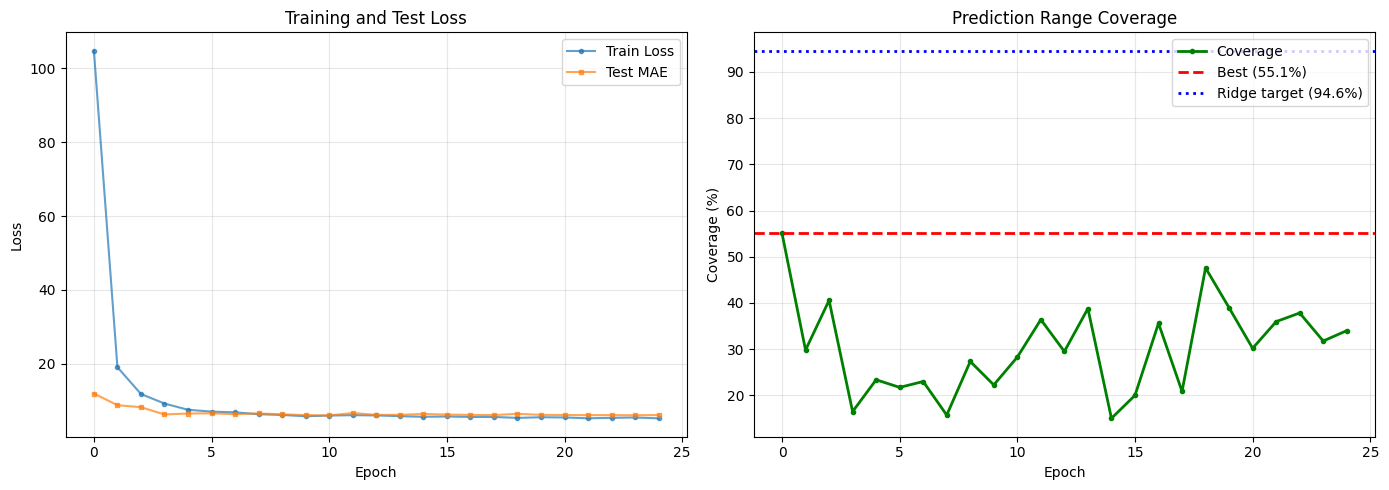

Model saved to: Stage_2_quantile_v7.pth


In [ ]:
# # =====================================================
# # STANDALONE Stage 2 v7: QUANTILE ENSEMBLE
# # Uses multiple quantiles to force wide predictions
# # =====================================================

# import os
# import sys
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import numpy as np

# print("="*70)
# print("STAGE 2 v7 - QUANTILE ENSEMBLE")
# print("="*70)

# # ---- PATHS ----
# DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")

# # ---- PRE-FLIGHT CHECKS ----
# print("\n🔍 Pre-flight checks...")

# files_ok = True
# for name, path in [("Train", TRAIN_FILE), ("Test", TEST_FILE)]:
#     if os.path.exists(path):
#         size_mb = os.path.getsize(path) / (1024**2)
#         print(f"✓ {name} file found ({size_mb:.1f} MB)")
#     else:
#         print(f"✗ {name} file NOT FOUND: {path}")
#         files_ok = False

# if not files_ok:
#     print("\n❌ MISSING FILES - Cannot proceed")
#     sys.exit(1)

# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"✓ Device: {device}")
# if device == "cuda":
#     print(f"  GPU: {torch.cuda.get_device_name(0)}")
#     print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# os.makedirs(OUT_DIR, exist_ok=True)
# print(f"✓ Output directory: {OUT_DIR}")
# print("\n✅ All checks passed!\n")

# # ---- CONFIG ----
# BATCH_SIZE = 32
# LR = 1e-3
# EPOCHS = 25

# # ---- Dataset ----
# class SimpleDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list
#     def __len__(self):
#         return len(self.data)
#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         return sample["embeddings"].flatten(), sample["target"]

# def collate_fn(batch):
#     embeds, targets = zip(*batch)
#     return torch.stack(embeds, dim=0), torch.stack(targets, dim=0)

# # ---- Multi-Quantile Model ----
# class QuantileModel(nn.Module):
#     """
#     Predicts 3 quantiles (10th, 50th, 90th percentile).
#     Final prediction is the median, but training on quantiles
#     forces the model to learn the full distribution.
#     """
#     def __init__(self, input_dim=65536):
#         super().__init__()

#         # Shared backbone
#         self.backbone = nn.Sequential(
#             nn.Linear(input_dim, 2048),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(2048, 1024),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(1024, 512),
#             nn.ReLU(),
#             nn.Dropout(0.2)
#         )

#         # Separate heads for each quantile
#         self.q10_head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 1))
#         self.q50_head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 1))
#         self.q90_head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 1))

#         # Initialize
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)

#     def forward(self, x):
#         features = self.backbone(x)
#         q10 = self.q10_head(features).squeeze(-1)
#         q50 = self.q50_head(features).squeeze(-1)
#         q90 = self.q90_head(features).squeeze(-1)
#         return q10, q50, q90

# # ---- Quantile Loss ----
# def quantile_loss(preds, targets, quantile):
#     """Asymmetric loss that pushes predictions to specific quantiles"""
#     errors = targets - preds
#     return torch.max(quantile * errors, (quantile - 1) * errors).mean()

# # ---- Load Data ----
# print("Loading datasets...")
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)
# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}\n")

# train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_fn, num_workers=0)
# test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_fn, num_workers=0)

# # ---- Initialize ----
# model = QuantileModel().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
# print(f"Training 3 quantiles: 10th, 50th, 90th percentile")
# print(f"Final prediction: median (50th percentile)\n")

# # ---- Training ----
# print("="*70)
# print("TRAINING")
# print("="*70)

# best_coverage = 0
# coverage_history = []
# test_mae_history = []
# train_loss_history = []  # ← ADDED
# patience = 25
# patience_counter = 0

# print(f"Epoch | Train Loss | Test MAE | Pred Range (Coverage)")
# print("-" * 70)

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_total_loss = 0.0  # ← ADDED

#     for embeds, targets in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         q10, q50, q90 = model(embeds)

#         # Loss for each quantile
#         loss_q10 = quantile_loss(q10, targets, 0.10)
#         loss_q50 = quantile_loss(q50, targets, 0.50)
#         loss_q90 = quantile_loss(q90, targets, 0.90)

#         # Combined loss
#         loss = loss_q10 + loss_q50 + loss_q90

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         train_total_loss += loss.item() * targets.size(0)  # ← ADDED

#     train_total_loss /= len(dataset_train)  # ← ADDED
#     train_loss_history.append(train_total_loss)  # ← ADDED

#     # TEST
#     model.eval()
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             q10, q50, q90 = model(embeds)

#             # Use median (q50) as final prediction
#             all_preds.append(q50.cpu())
#             all_targets.append(targets.cpu())

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)

#     # Metrics
#     mae = (all_preds - all_targets).abs().mean()
#     pred_range = all_preds.max() - all_preds.min()
#     target_range = all_targets.max() - all_targets.min()
#     coverage = (pred_range / target_range) * 100

#     coverage_history.append(coverage)
#     test_mae_history.append(mae.item())

#     status = ""
#     if coverage > best_coverage:
#         best_coverage = coverage
#         patience_counter = 0

#         save_path = os.path.join(OUT_DIR, "Stage_2_quantile_v7.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "test_mae": mae.item(),
#             "coverage": coverage,
#             "train_loss_history": train_loss_history,  # ← ADDED
#             "test_mae_history": test_mae_history,  # ← ADDED
#             "coverage_history": coverage_history  # ← ADDED
#         }, save_path)
#         status = "✓"
#     else:
#         patience_counter += 1

#     if (epoch + 1) % 5 == 0 or status:
#         print(f"{epoch+1:3d}   | {train_total_loss:9.2f}  | {mae:7.2f}m | "  # ← UPDATED
#               f"{all_preds.min():.1f}-{all_preds.max():.1f}m ({coverage:5.1f}%) {status}")

#     if patience_counter >= patience:
#         print(f"\nEarly stopping at epoch {epoch+1}")
#         break

# # ---- Final Evaluation ----
# print("\n" + "="*70)
# print("FINAL RESULTS")
# print("="*70)

# model.eval()
# final_preds = []
# final_targets = []
# final_q10 = []
# final_q90 = []

# with torch.no_grad():
#     for embeds, targets in test_loader:
#         embeds = embeds.to(device)
#         q10, q50, q90 = model(embeds)
#         final_preds.append(q50.cpu())
#         final_q10.append(q10.cpu())
#         final_q90.append(q90.cpu())
#         final_targets.append(targets.cpu())

# final_preds = torch.cat(final_preds)
# final_q10 = torch.cat(final_q10)
# final_q90 = torch.cat(final_q90)
# final_targets = torch.cat(final_targets)

# mae = (final_preds - final_targets).abs().mean()
# rmse = ((final_preds - final_targets) ** 2).mean().sqrt()
# final_coverage = (final_preds.max() - final_preds.min()) / (final_targets.max() - final_targets.min()) * 100

# print(f"\nMedian Predictions (q50):")
# print(f"  Range: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  Std: {final_preds.std():.2f}m")

# print(f"\nQuantile Ranges:")
# print(f"  10th percentile: {final_q10.min():.2f} - {final_q10.max():.2f}m")
# print(f"  50th percentile: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  90th percentile: {final_q90.min():.2f} - {final_q90.max():.2f}m")

# print(f"\nMetrics:")
# print(f"  Coverage: {final_coverage:.1f}%")
# print(f"  MAE: {mae:.2f}m")
# print(f"  RMSE: {rmse:.2f}m")

# print(f"\nvs. Ridge baseline:")
# print(f"  Ridge: 94.6% coverage, 8.18m RMSE")
# print(f"  This:  {final_coverage:.1f}% coverage, {rmse:.2f}m RMSE")
# print(f"  Gap:   {94.6 - final_coverage:.1f}%")

# if final_coverage > 80:
#     print("\n✅ EXCELLENT!")
# elif final_coverage > 60:
#     print("\n✓ GOOD!")
# else:
#     print("\n⚠️  MODERATE")

# # ---- Comprehensive Plotting ----
# print("\n" + "="*70)
# print("PLOTTING RESULTS")
# print("="*70)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Loss plot
# ax1.plot(train_loss_history, label='Train Loss', marker='o', markersize=3, alpha=0.7)
# ax1.plot(test_mae_history, label='Test MAE', marker='s', markersize=3, alpha=0.7)
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.set_title('Training and Test Loss')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # Coverage plot
# ax2.plot(coverage_history, label='Coverage', marker='o', markersize=3, color='green', linewidth=2)
# ax2.axhline(y=best_coverage, color='r', linestyle='--', linewidth=2, label=f'Best ({best_coverage:.1f}%)')
# ax2.axhline(y=94.6, color='b', linestyle=':', linewidth=2, label='Ridge target (94.6%)')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Coverage (%)')
# ax2.set_title('Prediction Range Coverage')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plot_path = os.path.join(OUT_DIR, 'Stage_2_quantile_v7.png')
# plt.savefig(plot_path, dpi=150)
# print(f"✓ Saved plot: {plot_path}")
# plt.show()

# print("="*70)
# print("Model saved to: Stage_2_quantile_v7.pth")
# print("="*70)

STANDALONE STAGE 2 v6 - RANGE-PRESERVING LOSS
✓ Device: cpu

Loading datasets...
Train: 679, Test: 152
Train targets: -1.07 - 23.46m (std=7.02)
Test targets:  -0.39 - 24.70m (std=6.92)

Model parameters: 67,799,041
Loss: MAE + Range Preservation (weight=0.1)
LR: 0.001, Batch size: 32, Epochs: 20

TRAINING
Epoch | Train | Test  | Pred Range (Coverage) | Pred Std
----------------------------------------------------------------------
  1   | 56.54 | 12.93 | -8.2-12.3m ( 81.7%) | 8.37 ✓
  5   |  8.28 |  6.17 | 2.6-6.0m ( 13.8%) | 0.94 
 10   |  6.79 |  6.16 | 1.6-11.3m ( 38.5%) | 1.79 
 15   |  6.36 |  6.37 | 3.3-13.8m ( 42.0%) | 2.12 
 20   |  6.11 |  6.39 | 0.7-14.5m ( 54.8%) | 2.80 


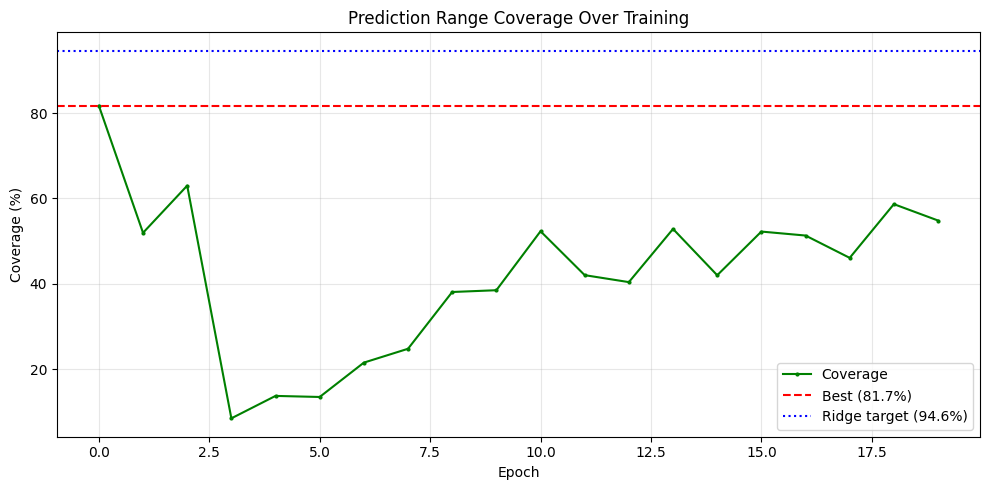


FINAL RESULTS

Predictions:
  Range: 0.71 - 14.47m
  Std: 2.80m (target std: 6.92m)
  Span: 13.76m

Metrics:
  Coverage: 54.8%
  MAE: 6.39m
  RMSE: 7.37m

vs. Ridge baseline:
  Ridge: 94.6% coverage, 8.18m RMSE
  This:  54.8% coverage, 7.37m RMSE

✓ MODERATE - Significant improvement


In [ ]:
# # =====================================================
# # STANDALONE Stage 2 v6: Range-Preserving Loss
# # Prevents model from collapsing to mean prediction
# # =====================================================

# import os
# import sys
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import numpy as np

# print("="*70)
# print("STANDALONE STAGE 2 v6 - RANGE-PRESERVING LOSS")
# print("="*70)

# # ---- PATHS ----
# DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")

# # Check files exist
# if not all(os.path.exists(f) for f in [TRAIN_FILE, TEST_FILE]):
#     print("❌ Dataset files not found!")
#     sys.exit(1)

# device = "cuda" if torch.cuda.is_available() else "cpu"
# os.makedirs(OUT_DIR, exist_ok=True)
# print(f"✓ Device: {device}\n")

# # ---- CONFIG ----
# BATCH_SIZE = 32  # Smaller batches for better gradient diversity
# LR = 1e-3
# EPOCHS = 20
# NUM_WORKERS = 0

# # ---- Dataset ----
# class SimpleDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         emb_flat = sample["embeddings"].flatten()
#         return emb_flat, sample["target"]

# def collate_fn(batch):
#     embeds, targets = zip(*batch)
#     embeds = torch.stack(embeds, dim=0)
#     targets = torch.stack(targets, dim=0)
#     return embeds, targets

# # ---- Simpler Model (less prone to overfitting) ----
# class SimplerMLP(nn.Module):
#     def __init__(self, input_dim=65536):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 1024),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(1024, 512),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(0.2),

#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.2),

#             nn.Linear(128, 1)
#         )

#         # Initialize
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)

#     def forward(self, x):
#         return self.net(x).squeeze(-1)

# # ---- Range-Preserving Loss ----
# class RangePreservingLoss(nn.Module):
#     """
#     Combined loss that encourages:
#     1. Accurate predictions (MAE)
#     2. Wide prediction range (variance preservation)
#     """
#     def __init__(self, range_weight=0.1):
#         super().__init__()
#         self.range_weight = range_weight
#         self.mae = nn.L1Loss()

#     def forward(self, preds, targets):
#         # Standard MAE loss
#         mae_loss = self.mae(preds, targets)

#         # Range preservation loss: encourage pred std to match target std
#         pred_std = preds.std()
#         target_std = targets.std()
#         range_loss = (pred_std - target_std).abs()

#         # Combined loss
#         total_loss = mae_loss + self.range_weight * range_loss

#         return total_loss, mae_loss, range_loss

# # ---- Load Data ----
# print("Loading datasets...")
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)
# dataset_test = torch.load(TEST_FILE, weights_only=False)

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}")

# train_targets = torch.stack([s["target"] for s in dataset_train])
# test_targets = torch.stack([s["target"] for s in dataset_test])

# print(f"Train targets: {train_targets.min():.2f} - {train_targets.max():.2f}m (std={train_targets.std():.2f})")
# print(f"Test targets:  {test_targets.min():.2f} - {test_targets.max():.2f}m (std={test_targets.std():.2f})\n")

# # Create dataloaders
# train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
# test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS)

# # ---- Initialize ----
# model = SimplerMLP().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# criterion = RangePreservingLoss(range_weight=0.1)

# print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
# print(f"Loss: MAE + Range Preservation (weight=0.1)")
# print(f"LR: {LR}, Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}\n")

# # ---- Training ----
# print("="*70)
# print("TRAINING")
# print("="*70)

# best_coverage = 0
# train_history = []
# test_history = []
# coverage_history = []
# patience = 30
# patience_counter = 0

# print(f"Epoch | Train | Test  | Pred Range (Coverage) | Pred Std")
# print("-" * 70)

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_total_loss = 0.0
#     train_mae_loss = 0.0

#     for embeds, targets in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(embeds)
#         loss, mae, range_loss = criterion(preds, targets)
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         train_total_loss += loss.item() * targets.size(0)
#         train_mae_loss += mae.item() * targets.size(0)

#     train_total_loss /= len(dataset_train)
#     train_mae_loss /= len(dataset_train)
#     train_history.append(train_mae_loss)

#     # TEST
#     model.eval()
#     test_total_loss = 0.0
#     test_mae_loss = 0.0
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss, mae, range_loss = criterion(preds, targets)

#             test_total_loss += loss.item() * targets.size(0)
#             test_mae_loss += mae.item() * targets.size(0)
#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_total_loss /= len(dataset_test)
#     test_mae_loss /= len(dataset_test)
#     test_history.append(test_mae_loss)

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)

#     pred_range = all_preds.max() - all_preds.min()
#     target_range = all_targets.max() - all_targets.min()
#     coverage = (pred_range / target_range) * 100
#     coverage_history.append(coverage)

#     pred_std = all_preds.std().item()
#     target_std = all_targets.std().item()

#     status = ""
#     if coverage > best_coverage:
#         best_coverage = coverage
#         patience_counter = 0

#         save_path = os.path.join(OUT_DIR, "Stage_2_range_preserving_v6.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "test_mae": test_mae_loss,
#             "coverage": coverage,
#             "pred_std": pred_std
#         }, save_path)
#         status = "✓"
#     else:
#         patience_counter += 1

#     if (epoch + 1) % 5 == 0 or status:  # Print every 5 epochs or when saving
#         print(f"{epoch+1:3d}   | {train_mae_loss:5.2f} | {test_mae_loss:5.2f} | "
#               f"{all_preds.min():.1f}-{all_preds.max():.1f}m ({coverage:5.1f}%) | "
#               f"{pred_std:.2f} {status}")

#     if patience_counter >= patience:
#         print(f"\nEarly stopping at epoch {epoch+1}")
#         break

# # ---- Save History ----
# torch.save({
#     "train": train_history,
#     "test": test_history,
#     "coverage": coverage_history
# }, os.path.join(OUT_DIR, "Stage_2_range_preserving_history_v6.pth"))

# # ---- Plot ----
# fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# ax.plot(coverage_history, label='Coverage', marker='o', markersize=2, color='green')
# ax.axhline(y=best_coverage, color='r', linestyle='--', label=f'Best ({best_coverage:.1f}%)')
# ax.axhline(y=94.6, color='b', linestyle=':', label='Ridge target (94.6%)')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Coverage (%)')
# ax.set_title('Prediction Range Coverage Over Training')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, 'Stage_2_range_preserving_v6.png'), dpi=150)
# plt.show()

# # ---- Final Evaluation ----
# print("\n" + "="*70)
# print("FINAL RESULTS")
# print("="*70)

# model.eval()
# final_preds = []
# final_targets = []

# with torch.no_grad():
#     for embeds, targets in test_loader:
#         embeds = embeds.to(device)
#         preds = model(embeds)
#         final_preds.append(preds.cpu())
#         final_targets.append(targets.cpu())

# final_preds = torch.cat(final_preds)
# final_targets = torch.cat(final_targets)

# mae = (final_preds - final_targets).abs().mean()
# rmse = ((final_preds - final_targets) ** 2).mean().sqrt()
# final_coverage = (final_preds.max() - final_preds.min()) / (final_targets.max() - final_targets.min()) * 100

# print(f"\nPredictions:")
# print(f"  Range: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  Std: {final_preds.std():.2f}m (target std: {final_targets.std():.2f}m)")
# print(f"  Span: {(final_preds.max() - final_preds.min()):.2f}m")

# print(f"\nMetrics:")
# print(f"  Coverage: {final_coverage:.1f}%")
# print(f"  MAE: {mae:.2f}m")
# print(f"  RMSE: {rmse:.2f}m")

# print(f"\nvs. Ridge baseline:")
# print(f"  Ridge: 94.6% coverage, 8.18m RMSE")
# print(f"  This:  {final_coverage:.1f}% coverage, {rmse:.2f}m RMSE")

# if final_coverage > 70:
#     print("\n✅ GOOD - Approaching Ridge performance!")
# elif final_coverage > 50:
#     print("\n✓ MODERATE - Significant improvement")
# else:
#     print("\n⚠️  Still limited - may need different approach")

# print("="*70)

STANDALONE STAGE 2 - IMPROVED MLP v5

🔍 Pre-flight checks...
✓ Train file found (170.0 MB)
✓ Test file found (38.1 MB)
✓ Val file found (21.5 MB)

✓ Device: cpu
✓ Output directory: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models

✅ All checks passed - ready to train!

LOADING DATASETS

Loading train...
Loading test...
Loading val...

✓ Data verification:
  Sample keys: ['row_ID', 'embeddings', 'target']
  Embeddings shape: torch.Size([8, 64, 128])
  Target shape: torch.Size([])
  Target dtype: torch.float32

✓ Target ranges:
  Train: -1.07 - 23.46m
  Test:  -0.39 - 24.70m

Creating dataloaders...
  Loaded 679 samples
  Loaded 152 samples
  Train batches: 11
  Test batches: 3

INITIALIZING MODEL

✓ Model parameters: 285,223,681
✓ Loss: MAE (L1)
✓ Optimizer: AdamW
✓ Initial LR: 0.0005
✓ Batch size: 64
✓ Max epochs: 10

STARTING TRAINING

Epoch | Train MAE | Test MAE | Range (Coverage)
----------------------------------------------------------------------
  1   |

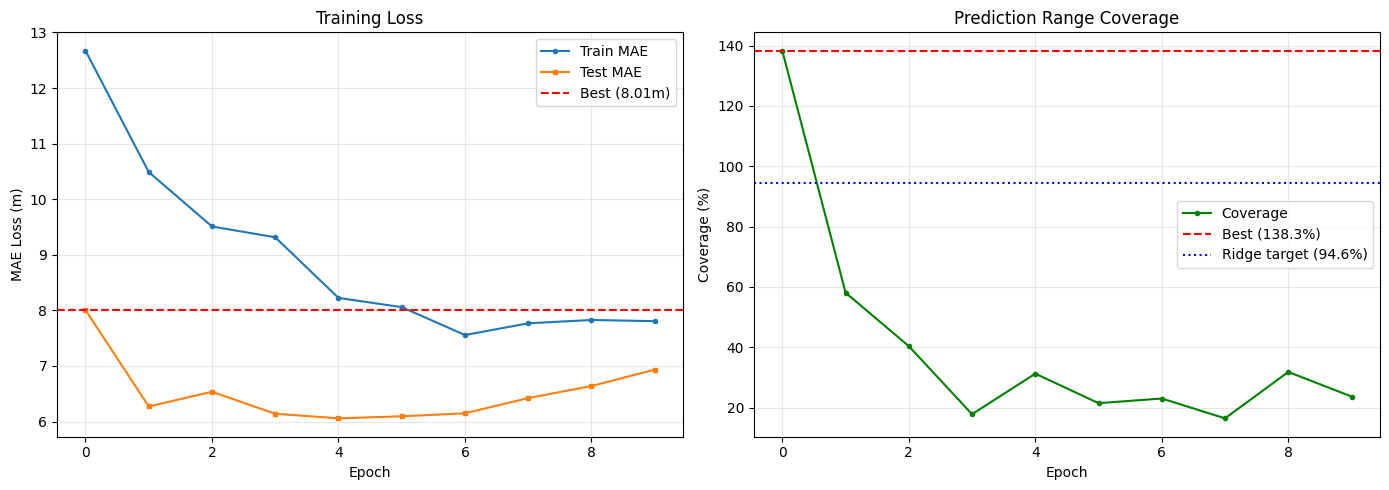


FINAL EVALUATION

Predictions:
  Range: 1.47 - 7.41m
  Mean ± Std: 3.81 ± 1.94m
  Span: 5.94m

Targets:
  Range: -0.39 - 24.70m
  Mean ± Std: 8.74 ± 6.92m
  Span: 25.10m

Metrics:
  Range Coverage: 23.7%
  Test MAE: 6.93m
  Test RMSE: 8.94m

Comparison to Ridge baseline:
  Ridge coverage: 94.6%
  MLP coverage: 23.7%
  Difference: 70.9%

❌ LOW: May need architecture changes

TRAINING COMPLETE

Best model saved to:
  /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_improved_mlp_v5.pth

To use this model for inference, load it with:
  checkpoint = torch.load('Stage_2_improved_mlp_v5.pth')
  model.load_state_dict(checkpoint['model_state_dict'])


In [ ]:
# # =====================================================
# # STANDALONE Stage 2 v5: Improved MLP
# # Can run independently - loads saved datasets only
# # No dependency on Stage 1 code being in memory
# # =====================================================

# import os
# import sys
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import numpy as np

# print("="*70)
# print("STANDALONE STAGE 2 - IMPROVED MLP v5")
# print("="*70)

# # ---- PATHS (EDIT THESE IF NEEDED) ----
# DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"

# TRAIN_FILE = os.path.join(DATA_DIR, "dataset_train.pt")
# TEST_FILE = os.path.join(DATA_DIR, "dataset_test.pt")
# VAL_FILE = os.path.join(DATA_DIR, "dataset_val.pt")

# # ---- PRE-FLIGHT CHECKS ----
# print("\n🔍 Pre-flight checks...")

# # Check files exist
# files_ok = True
# for name, path in [("Train", TRAIN_FILE), ("Test", TEST_FILE), ("Val", VAL_FILE)]:
#     if os.path.exists(path):
#         size_mb = os.path.getsize(path) / (1024**2)
#         print(f"✓ {name} file found ({size_mb:.1f} MB)")
#     else:
#         print(f"✗ {name} file NOT FOUND: {path}")
#         files_ok = False

# if not files_ok:
#     print("\n❌ MISSING FILES - Cannot proceed")
#     print("\nPlease ensure you've run the collapse section to create:")
#     print(f"  {TRAIN_FILE}")
#     print(f"  {TEST_FILE}")
#     print(f"  {VAL_FILE}")
#     sys.exit(1)

# # Check CUDA
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"\n✓ Device: {device}")
# if device == "cuda":
#     print(f"  GPU: {torch.cuda.get_device_name(0)}")
#     print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# os.makedirs(OUT_DIR, exist_ok=True)
# print(f"✓ Output directory: {OUT_DIR}")

# print("\n✅ All checks passed - ready to train!\n")

# # ---- CONFIG ----
# BATCH_SIZE = 64
# LR = 5e-4
# EPOCHS = 10
# NUM_WORKERS = 0  # Set to 0 to avoid multiprocessing issues in notebooks

# # ---- Dataset ----
# class SimpleDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list
#         print(f"  Loaded {len(dataset_list)} samples")

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         emb_flat = sample["embeddings"].flatten()
#         return emb_flat, sample["target"]

# def collate_fn(batch):
#     embeds, targets = zip(*batch)
#     embeds = torch.stack(embeds, dim=0)
#     targets = torch.stack(targets, dim=0)
#     return embeds, targets

# # ---- Model ----
# class ImprovedMLP(nn.Module):
#     def __init__(self, input_dim=65536):
#         super().__init__()

#         self.input_proj = nn.Sequential(
#             nn.Linear(input_dim, 4096),
#             nn.BatchNorm1d(4096),
#             nn.ReLU(),
#             nn.Dropout(0.3)
#         )

#         self.block1 = self._make_block(4096, 2048)
#         self.block2 = self._make_block(2048, 1024)
#         self.block3 = self._make_block(1024, 512)
#         self.block4 = self._make_block(512, 256)

#         self.output = nn.Sequential(
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1)
#         )

#         self.apply(self._init_weights)

#     def _make_block(self, in_dim, out_dim):
#         return nn.Sequential(
#             nn.Linear(in_dim, out_dim),
#             nn.BatchNorm1d(out_dim),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(out_dim, out_dim),
#             nn.BatchNorm1d(out_dim),
#             nn.ReLU(),
#             nn.Dropout(0.3)
#         )

#     def _init_weights(self, m):
#         if isinstance(m, nn.Linear):
#             nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
#             if m.bias is not None:
#                 nn.init.constant_(m.bias, 0)
#         elif isinstance(m, nn.BatchNorm1d):
#             nn.init.constant_(m.weight, 1)
#             nn.init.constant_(m.bias, 0)

#     def forward(self, x):
#         x = self.input_proj(x)
#         x = self.block1(x)
#         x = self.block2(x)
#         x = self.block3(x)
#         x = self.block4(x)
#         return self.output(x).squeeze(-1)

# # ---- Load Data ----
# print("="*70)
# print("LOADING DATASETS")
# print("="*70)

# print("\nLoading train...")
# dataset_train = torch.load(TRAIN_FILE, weights_only=False)

# print("Loading test...")
# dataset_test = torch.load(TEST_FILE, weights_only=False)

# print("Loading val...")
# dataset_val = torch.load(VAL_FILE, weights_only=False)

# # Verify data format
# print("\n✓ Data verification:")
# sample = dataset_train[0]
# print(f"  Sample keys: {list(sample.keys())}")
# print(f"  Embeddings shape: {sample['embeddings'].shape}")
# print(f"  Target shape: {sample['target'].shape if hasattr(sample['target'], 'shape') else 'scalar'}")
# print(f"  Target dtype: {sample['target'].dtype}")

# # Target statistics
# train_targets = torch.stack([s["target"] for s in dataset_train])
# test_targets = torch.stack([s["target"] for s in dataset_test])

# print(f"\n✓ Target ranges:")
# print(f"  Train: {train_targets.min():.2f} - {train_targets.max():.2f}m")
# print(f"  Test:  {test_targets.min():.2f} - {test_targets.max():.2f}m")

# # ---- Create DataLoaders ----
# print("\nCreating dataloaders...")
# train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
# test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS)

# print(f"  Train batches: {len(train_loader)}")
# print(f"  Test batches: {len(test_loader)}")

# # ---- Initialize Model ----
# print("\n" + "="*70)
# print("INITIALIZING MODEL")
# print("="*70)

# model = ImprovedMLP().to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=10
# )
# criterion = nn.L1Loss()

# n_params = sum(p.numel() for p in model.parameters())
# print(f"\n✓ Model parameters: {n_params:,}")
# print(f"✓ Loss: MAE (L1)")
# print(f"✓ Optimizer: AdamW")
# print(f"✓ Initial LR: {LR}")
# print(f"✓ Batch size: {BATCH_SIZE}")
# print(f"✓ Max epochs: {EPOCHS}")

# # ---- Training ----
# print("\n" + "="*70)
# print("STARTING TRAINING")
# print("="*70)

# best_test_loss = float('inf')
# best_coverage = 0
# train_history = []
# test_history = []
# coverage_history = []
# patience = 20
# patience_counter = 0

# print(f"\nEpoch | Train MAE | Test MAE | Range (Coverage)")
# print("-" * 70)

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_loss = 0.0

#     for embeds, targets in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(embeds)
#         loss = criterion(preds, targets)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         train_loss += loss.item() * targets.size(0)

#     train_loss /= len(dataset_train)
#     train_history.append(train_loss)

#     # TEST
#     model.eval()
#     test_loss = 0.0
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss = criterion(preds, targets)
#             test_loss += loss.item() * targets.size(0)
#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_loss /= len(dataset_test)
#     test_history.append(test_loss)

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)
#     pred_range = all_preds.max() - all_preds.min()
#     target_range = all_targets.max() - all_targets.min()
#     coverage = (pred_range / target_range) * 100
#     coverage_history.append(coverage)

#     scheduler.step(test_loss)

#     # Print progress
#     status = ""
#     if coverage > best_coverage:
#         best_coverage = coverage
#         best_test_loss = test_loss
#         patience_counter = 0

#         # Save model
#         save_path = os.path.join(OUT_DIR, "Stage_2_improved_mlp_v5.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "train_loss": train_loss,
#             "test_loss": test_loss,
#             "pred_range": pred_range.item(),
#             "coverage": coverage.item()
#         }, save_path)
#         status = "✓ SAVED"
#     else:
#         patience_counter += 1

#     print(f"{epoch+1:3d}   | {train_loss:8.2f}  | {test_loss:7.2f}  | "
#           f"{all_preds.min():.1f}-{all_preds.max():.1f}m ({coverage:5.1f}%) {status}")

#     if patience_counter >= patience:
#         print(f"\n⏹  Early stopping (no improvement for {patience} epochs)")
#         break

# # ---- Save History ----
# torch.save({
#     "train": train_history,
#     "test": test_history,
#     "coverage": coverage_history
# }, os.path.join(OUT_DIR, "Stage_2_improved_mlp_history_v5.pth"))

# # ---- Plot ----
# print("\n" + "="*70)
# print("PLOTTING RESULTS")
# print("="*70)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ax1.plot(train_history, label='Train MAE', marker='o', markersize=3)
# ax1.plot(test_history, label='Test MAE', marker='s', markersize=3)
# ax1.axhline(y=best_test_loss, color='r', linestyle='--', label=f'Best ({best_test_loss:.2f}m)')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('MAE Loss (m)')
# ax1.set_title('Training Loss')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# ax2.plot(coverage_history, label='Coverage', marker='o', markersize=3, color='green')
# ax2.axhline(y=best_coverage, color='r', linestyle='--', label=f'Best ({best_coverage:.1f}%)')
# ax2.axhline(y=94.6, color='b', linestyle=':', label='Ridge target (94.6%)')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Coverage (%)')
# ax2.set_title('Prediction Range Coverage')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plot_path = os.path.join(OUT_DIR, 'Stage_2_improved_mlp_v5.png')
# plt.savefig(plot_path, dpi=150)
# print(f"✓ Saved plot: {plot_path}")
# plt.show()

# # ---- Final Evaluation ----
# print("\n" + "="*70)
# print("FINAL EVALUATION")
# print("="*70)

# model.eval()
# final_preds = []
# final_targets = []

# with torch.no_grad():
#     for embeds, targets in test_loader:
#         embeds = embeds.to(device)
#         preds = model(embeds)
#         final_preds.append(preds.cpu())
#         final_targets.append(targets.cpu())

# final_preds = torch.cat(final_preds)
# final_targets = torch.cat(final_targets)

# mse = ((final_preds - final_targets) ** 2).mean()
# rmse = mse.sqrt()
# mae = (final_preds - final_targets).abs().mean()

# print(f"\nPredictions:")
# print(f"  Range: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  Mean ± Std: {final_preds.mean():.2f} ± {final_preds.std():.2f}m")
# print(f"  Span: {(final_preds.max() - final_preds.min()):.2f}m")

# print(f"\nTargets:")
# print(f"  Range: {final_targets.min():.2f} - {final_targets.max():.2f}m")
# print(f"  Mean ± Std: {final_targets.mean():.2f} ± {final_targets.std():.2f}m")
# print(f"  Span: {(final_targets.max() - final_targets.min()):.2f}m")

# final_coverage = (final_preds.max() - final_preds.min()) / (final_targets.max() - final_targets.min()) * 100

# print(f"\nMetrics:")
# print(f"  Range Coverage: {final_coverage:.1f}%")
# print(f"  Test MAE: {mae:.2f}m")
# print(f"  Test RMSE: {rmse:.2f}m")

# print(f"\nComparison to Ridge baseline:")
# print(f"  Ridge coverage: 94.6%")
# print(f"  MLP coverage: {final_coverage:.1f}%")
# print(f"  Difference: {94.6 - final_coverage:.1f}%")

# if final_coverage > 80:
#     print("\n✅ EXCELLENT! Close to Ridge performance")
# elif final_coverage > 60:
#     print("\n✓ GOOD! Substantial improvement")
# elif final_coverage > 40:
#     print("\n⚠️  MODERATE: Still improving")
# else:
#     print("\n❌ LOW: May need architecture changes")

# print("\n" + "="*70)
# print("TRAINING COMPLETE")
# print("="*70)
# print(f"\nBest model saved to:")
# print(f"  {os.path.join(OUT_DIR, 'Stage_2_improved_mlp_v5.pth')}")
# print(f"\nTo use this model for inference, load it with:")
# print(f"  checkpoint = torch.load('Stage_2_improved_mlp_v5.pth')")
# print(f"  model.load_state_dict(checkpoint['model_state_dict'])")
# print("="*70)

In [ ]:
# # =====================================================
# # Stage 2 v4: ULTRA-SIMPLE MLP (No Transformer)
# # Since Ridge regression works, a simple MLP should too
# # =====================================================

# import os
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import numpy as np

# # ---- CONFIG ----
# device = "cuda" if torch.cuda.is_available() else "cpu"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
# os.makedirs(OUT_DIR, exist_ok=True)

# BATCH_SIZE = 32  # Larger batch
# LR = 1e-3
# EPOCHS = 10
# NUM_WORKERS = 2

# # ---- Dataset ----
# class SimpleDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         # Flatten embeddings: [8, 64, 128] → [8*64*128] = [65536]
#         emb_flat = sample["embeddings"].flatten()
#         return emb_flat, sample["target"]

# def collate_fn(batch):
#     embeds, targets = zip(*batch)
#     embeds = torch.stack(embeds, dim=0)
#     targets = torch.stack(targets, dim=0)
#     return embeds, targets

# # ---- ULTRA-SIMPLE MLP MODEL ----
# class SimpleMLP(nn.Module):
#     """
#     Dead simple MLP - no transformer, no attention, no complexity.
#     Just like Ridge regression but with non-linearity.
#     """
#     def __init__(self, input_dim=65536, hidden_dims=[2048, 512, 128]):
#         super().__init__()

#         layers = []
#         prev_dim = input_dim

#         for hidden_dim in hidden_dims:
#             layers.append(nn.Linear(prev_dim, hidden_dim))
#             layers.append(nn.LayerNorm(hidden_dim))
#             layers.append(nn.GELU())
#             layers.append(nn.Dropout(0.2))
#             prev_dim = hidden_dim

#         # Output layer
#         layers.append(nn.Linear(prev_dim, 1))

#         self.mlp = nn.Sequential(*layers)

#         # Initialize weights
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_normal_(m.weight)
#                 if m.bias is not None:
#                     nn.init.constant_(m.bias, 0)

#     def forward(self, x):
#         # x: [B, 65536]
#         return self.mlp(x).squeeze(-1)  # [B]

# # ---- Load datasets ----
# print("Loading datasets...")
# dataset_train = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt',
#     weights_only=False
# )
# dataset_test = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt',
#     weights_only=False
# )

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}")

# # Diagnostics
# print("\n" + "="*70)
# print("DATA DIAGNOSTICS")
# print("="*70)

# train_targets = torch.stack([s["target"] for s in dataset_train])
# test_targets = torch.stack([s["target"] for s in dataset_test])

# print(f"\nTrain targets: {train_targets.min():.2f} - {train_targets.max():.2f}m")
# print(f"Test targets:  {test_targets.min():.2f} - {test_targets.max():.2f}m")
# print("="*70 + "\n")

# # Create dataloaders
# train_loader = DataLoader(SimpleDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
# test_loader = DataLoader(SimpleDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS)

# # ---- Initialize model ----
# model = SimpleMLP().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# # MSE Loss (simple)
# criterion = nn.MSELoss()

# print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
# print(f"Using MSE loss, Adam optimizer, LR={LR}\n")

# # ---- Training loop ----
# print("Starting simple MLP training...")
# best_test_loss = float('inf')
# train_history = []
# test_history = []
# patience = 10
# patience_counter = 0

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_loss = 0.0

#     for embeds, targets in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(embeds)
#         loss = criterion(preds, targets)
#         loss.backward()

#         # Gradient clipping
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()
#         train_loss += loss.item() * targets.size(0)

#     train_loss /= len(dataset_train)
#     train_history.append(train_loss)

#     # TEST
#     model.eval()
#     test_loss = 0.0
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss = criterion(preds, targets)
#             test_loss += loss.item() * targets.size(0)

#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_loss /= len(dataset_test)
#     test_history.append(test_loss)

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)
#     pred_range = all_preds.max() - all_preds.min()
#     target_range = all_targets.max() - all_targets.min()
#     coverage = (pred_range / target_range) * 100

#     print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
#           f"Train: {train_loss:.2f} | "
#           f"Test: {test_loss:.2f} | "
#           f"RMSE: {test_loss**0.5:.2f}m | "
#           f"Range: {all_preds.min():.1f}-{all_preds.max():.1f}m ({pred_range:.1f}m, {coverage:.0f}%)")

#     # Save best model
#     if test_loss < best_test_loss:
#         best_test_loss = test_loss
#         patience_counter = 0
#         save_path = os.path.join(OUT_DIR, "Stage_2_simple_mlp_v4.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "train_loss": train_loss,
#             "test_loss": test_loss,
#             "pred_range": pred_range.item(),
#             "coverage": coverage.item()
#         }, save_path)
#         print(f"  ✓ Saved (best RMSE: {test_loss**0.5:.2f}m, coverage: {coverage:.0f}%)")
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print(f"\n  Early stopping (no improvement for {patience} epochs)")
#             break

# print(f"\nTraining complete!")
# print(f"Best test RMSE: {best_test_loss**0.5:.2f}m")

# # Save history
# torch.save({"train": train_history, "test": test_history},
#            os.path.join(OUT_DIR, "Stage_2_simple_mlp_history_v4.pth"))

# # Plot
# plt.figure(figsize=(10, 5))
# plt.plot(train_history, label='Train Loss', marker='o')
# plt.plot(test_history, label='Test Loss', marker='s')
# plt.axhline(y=best_test_loss, color='r', linestyle='--',
#             label=f'Best ({best_test_loss**0.5:.2f}m RMSE)')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.title('Simple MLP Training (v4)')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, 'Stage_2_simple_mlp_v4.png'), dpi=150)
# plt.show()

# # ---- Final evaluation ----
# print("\n" + "="*70)
# print("FINAL EVALUATION")
# print("="*70)

# model.eval()
# final_preds = []
# final_targets = []

# with torch.no_grad():
#     for embeds, targets in test_loader:
#         embeds = embeds.to(device)
#         preds = model(embeds)
#         final_preds.append(preds.cpu())
#         final_targets.append(targets.cpu())

# final_preds = torch.cat(final_preds)
# final_targets = torch.cat(final_targets)

# print(f"\nPredictions:")
# print(f"  Range: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  Mean ± Std: {final_preds.mean():.2f} ± {final_preds.std():.2f}m")
# print(f"  Span: {(final_preds.max() - final_preds.min()):.2f}m")

# print(f"\nTargets:")
# print(f"  Range: {final_targets.min():.2f} - {final_targets.max():.2f}m")
# print(f"  Span: {(final_targets.max() - final_targets.min()):.2f}m")

# final_coverage = (final_preds.max() - final_preds.min()) / (final_targets.max() - final_targets.min()) * 100
# print(f"\nRange Coverage: {final_coverage:.1f}%")
# print(f"Test RMSE: {best_test_loss**0.5:.2f}m")

# if final_coverage > 70:
#     print("\n✅ SUCCESS! MLP works with these embeddings")
#     print("   Problem was transformer complexity in previous versions")
# else:
#     print("\n⚠️  Still limited coverage")
#     print("   May need to tune hyperparameters")

# print("="*70)

In [ ]:
# ###Stage 2 v3: SIMPLIFIED FUSION
# # Removes aggressive pooling that destroys variance
# # Uses direct token-level processing

# import os, time
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import numpy as np

# # ---- CONFIG ----
# device = "cuda" if torch.cuda.is_available() else "cpu"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
# os.makedirs(OUT_DIR, exist_ok=True)

# BATCH_SIZE = 16
# LR = 5e-3  # Higher learning rate
# EPOCHS = 30  # More epochs
# NUM_WORKERS = 2
# NUM_MODALITIES = 8
# EMBED_DIM = 128
# TOKENS_PER_MODALITY = 64

# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

# # ---- Dataset ----
# class HierarchicalDataset(Dataset):
#     def __init__(self, dataset_list):
#         self.data = dataset_list

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         return sample["embeddings"], sample["target"], sample["row_ID"]

# def collate_hierarchical(batch):
#     embeds, targets, row_ids = zip(*batch)
#     embeds = torch.stack(embeds, dim=0)
#     targets = torch.stack(targets, dim=0)
#     return embeds, targets, list(row_ids)

# # ---- SIMPLIFIED Model v3 ----
# class SimplifiedFusion(nn.Module):
#     """
#     Simpler architecture that doesn't pool as aggressively.
#     Processes all tokens together instead of pooling per-modality first.
#     """
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=8, nlayers=3, dropout=0.1):
#         super().__init__()

#         # Modality embeddings (added to each token to indicate which modality it's from)
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)

#         # Positional embeddings for tokens within each modality
#         self.pos_emb = nn.Embedding(64, embed_dim)  # 64 tokens per modality

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE: Work with ALL tokens (8 * 64 = 512) instead of pooling first
#         # This preserves spatial variance information
#         # ═══════════════════════════════════════════════════════════════
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim,
#             nhead=nhead,
#             dim_feedforward=512,
#             dropout=dropout,
#             activation='gelu',
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE: Attention pooling instead of mean pooling
#         # Learns what tokens are important for the prediction
#         # ═══════════════════════════════════════════════════════════════
#         self.attention_pool = nn.Sequential(
#             nn.Linear(embed_dim, embed_dim),
#             nn.Tanh(),
#             nn.Linear(embed_dim, 1)
#         )

#         # Prediction head
#         self.head = nn.Sequential(
#             nn.LayerNorm(embed_dim),
#             nn.Linear(embed_dim, 256),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, 128),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, 1)
#         )

#         # Initialize
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)
#         nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)

#     def forward(self, modality_tokens):
#         # modality_tokens: [B, 8, 64, 128]
#         B = modality_tokens.shape[0]

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE: Flatten to all tokens instead of pooling per-modality
#         # [B, 8, 64, 128] → [B, 512, 128]
#         # ═══════════════════════════════════════════════════════════════
#         all_tokens = modality_tokens.view(B, -1, self.mod_emb.embedding_dim)  # [B, 512, 128]

#         # Add modality embeddings (which modality does each token belong to?)
#         mod_ids = torch.arange(8, device=modality_tokens.device).repeat_interleave(64)  # [0,0,...,1,1,...,7,7,...]
#         mod_emb = self.mod_emb(mod_ids).unsqueeze(0).expand(B, -1, -1)  # [B, 512, 128]

#         # Add positional embeddings (position within modality)
#         pos_ids = torch.arange(64, device=modality_tokens.device).repeat(8)  # [0,1,...,63, 0,1,...,63, ...]
#         pos_emb = self.pos_emb(pos_ids).unsqueeze(0).expand(B, -1, -1)  # [B, 512, 128]

#         # Combine: token + modality info + position info
#         all_tokens = all_tokens + mod_emb + pos_emb  # [B, 512, 128]

#         # Transformer fusion across all tokens
#         fused = self.transformer(all_tokens)  # [B, 512, 128]

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE: Attention pooling - learn which tokens matter
#         # Instead of mean pooling which loses information
#         # ═══════════════════════════════════════════════════════════════
#         attn_weights = torch.softmax(self.attention_pool(fused), dim=1)  # [B, 512, 1]
#         pooled = (fused * attn_weights).sum(dim=1)  # [B, 128]

#         # Predict
#         pred = self.head(pooled)  # [B, 1]
#         return pred.squeeze(-1)

# # ---- Load datasets ----
# print("Loading collapsed datasets...")
# dataset_train = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt',
#     weights_only=False
# )
# dataset_test = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt',
#     weights_only=False
# )
# dataset_val = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_val.pt',
#     weights_only=False
# )

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}, Val: {len(dataset_val)}")

# # ═══════════════════════════════════════════════════════════════
# # DIAGNOSTICS
# # ═══════════════════════════════════════════════════════════════
# print("\n" + "="*70)
# print("TRAINING DATA DIAGNOSTICS")
# print("="*70)

# train_targets = torch.stack([s["target"] for s in dataset_train])
# test_targets = torch.stack([s["target"] for s in dataset_test])

# print(f"\nTRAIN TARGETS:")
# print(f"  Range: {train_targets.min():.2f} - {train_targets.max():.2f}m")
# print(f"  Mean ± Std: {train_targets.mean():.2f} ± {train_targets.std():.2f}m")

# print(f"\nTEST TARGETS:")
# print(f"  Range: {test_targets.min():.2f} - {test_targets.max():.2f}m")
# print(f"  Mean ± Std: {test_targets.mean():.2f} ± {test_targets.std():.2f}m")

# # Check embedding variance
# print(f"\nEMBEDDING VARIANCE CHECK:")
# for i in range(min(3, len(dataset_train))):
#     emb = dataset_train[i]['embeddings']
#     print(f"  Sample {i}: emb_mean={emb.mean():.4f}, emb_std={emb.std():.4f}, target={dataset_train[i]['target']:.2f}m")

# print("="*70 + "\n")

# # Create dataloaders
# train_loader = DataLoader(HierarchicalDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)
# test_loader = DataLoader(HierarchicalDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)

# # ---- Initialize model ----
# model = SimplifiedFusion(embed_dim=EMBED_DIM, num_modalities=NUM_MODALITIES).to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# # Learning rate scheduler
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# # Huber loss
# criterion = nn.SmoothL1Loss(beta=2.0)
# print(f"Using Huber Loss with beta=2.0, LR={LR}, AdamW optimizer\n")

# # ---- Training loop ----
# print(f"Starting simplified fusion training on {len(dataset_train)} samples...")
# best_test_loss = float('inf')
# train_history = []
# test_history = []

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_loss = 0.0
#     for embeds, targets, _ in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(embeds)
#         loss = criterion(preds, targets)
#         loss.backward()

#         # Gradient clipping to prevent exploding gradients
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()
#         train_loss += loss.item() * targets.size(0)

#     train_loss /= len(dataset_train)
#     train_history.append(train_loss)

#     # TEST
#     model.eval()
#     test_loss = 0.0
#     all_preds = []
#     all_targets = []

#     with torch.no_grad():
#         for embeds, targets, _ in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss = criterion(preds, targets)
#             test_loss += loss.item() * targets.size(0)

#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_loss /= len(dataset_test)
#     test_history.append(test_loss)

#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)
#     pred_range = all_preds.max() - all_preds.min()

#     print(f"Epoch {epoch+1}/{EPOCHS} | "
#           f"Train Loss: {train_loss:.4f} | "
#           f"Test Loss: {test_loss:.4f} | "
#           f"RMSE: {test_loss**0.5:.2f}m | "
#           f"Pred Range: {all_preds.min():.2f}-{all_preds.max():.2f}m ({pred_range:.2f}m)")

#     if pred_range < 5.0:
#         print(f"  ⚠️  WARNING: Prediction range < 5m")

#     # Save best model
#     if test_loss < best_test_loss:
#         best_test_loss = test_loss
#         save_path = os.path.join(OUT_DIR, "Stage_2_simplified_fusion_v3.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "train_loss": train_loss,
#             "test_loss": test_loss,
#             "pred_range": pred_range.item()
#         }, save_path)
#         print(f"  ✓ Saved best model (test RMSE: {test_loss**0.5:.2f}m, range: {pred_range:.2f}m)")

#     # Step scheduler
#     scheduler.step()

# print(f"\nTraining complete! Best test loss: {best_test_loss:.4f} (RMSE: {best_test_loss**0.5:.2f}m)")

# # Save history
# torch.save({"train": train_history, "test": test_history},
#            os.path.join(OUT_DIR, "Stage_2_simplified_history_v3.pth"))

# # Plot
# plt.figure(figsize=(10,5))
# plt.plot(train_history, label='Train Loss', marker='o')
# plt.plot(test_history, label='Test Loss', marker='s')
# plt.axhline(y=best_test_loss, color='r', linestyle='--', label=f'Best Test ({best_test_loss**0.5:.2f}m RMSE)')
# plt.xlabel('Epoch')
# plt.ylabel('Huber Loss')
# plt.title('Simplified Fusion Training (v3 - Attention Pooling)')
# plt.legend()
# plt.grid(True)
# plt.show()

# # ═══════════════════════════════════════════════════════════════
# # FINAL DIAGNOSTIC
# # ═══════════════════════════════════════════════════════════════
# print("\n" + "="*70)
# print("FINAL MODEL PREDICTIONS ON TEST SET")
# print("="*70)
# model.eval()
# final_preds = []
# final_targets = []
# with torch.no_grad():
#     for embeds, targets, _ in test_loader:
#         embeds = embeds.to(device)
#         preds = model(embeds)
#         final_preds.append(preds.cpu())
#         final_targets.append(targets.cpu())

# final_preds = torch.cat(final_preds)
# final_targets = torch.cat(final_targets)

# print(f"\nPREDICTIONS:")
# print(f"  Range: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  Mean ± Std: {final_preds.mean():.2f} ± {final_preds.std():.2f}m")
# print(f"  Span: {(final_preds.max() - final_preds.min()):.2f}m")

# print(f"\nTARGETS:")
# print(f"  Range: {final_targets.min():.2f} - {final_targets.max():.2f}m")
# print(f"  Span: {(final_targets.max() - final_targets.min()):.2f}m")

# coverage = (final_preds.max() - final_preds.min()) / (final_targets.max() - final_targets.min()) * 100
# print(f"\nRANGE COVERAGE: {coverage:.1f}% of target range")

# if coverage < 50:
#     print("⚠️  Still low coverage - architecture may need further changes")
# else:
#     print("✓ Good coverage!")

# print("="*70 + "\n")

In [ ]:
# ###11/30 fix to address the overly complicated fusion in stage 2
# ###UPDATED: Added diagnostics and fixes for narrow prediction range


# # --------------------------
# # Stage-2: HIERARCHICAL FUSION (v2)
# # More stable than token-level approach
# # FIXES: Huber loss, max+mean pooling, diagnostics
# # --------------------------

# import os, time
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import numpy as np  # ← ADDED for diagnostics

# # ---- CONFIG ----
# device = "cuda" if torch.cuda.is_available() else "cpu"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
# os.makedirs(OUT_DIR, exist_ok=True)

# BATCH_SIZE = 16
# LR = 1e-3
# EPOCHS = 20  # More epochs since model is simpler
# NUM_WORKERS = 2
# NUM_MODALITIES = 8
# EMBED_DIM = 128
# TOKENS_PER_MODALITY = 64

# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

# # ---- Dataset ----
# class HierarchicalDataset(Dataset):
#     def __init__(self, dataset_list):
#         """
#         dataset_list: list of dicts from torch.load('dataset_train.pt')
#         Each dict: {"row_ID": int, "embeddings": [8, 64, 128], "target": float}
#         """
#         self.data = dataset_list

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         return sample["embeddings"], sample["target"], sample["row_ID"]

# def collate_hierarchical(batch):
#     embeds, targets, row_ids = zip(*batch)
#     embeds = torch.stack(embeds, dim=0)      # [B, 8, 64, 128]
#     targets = torch.stack(targets, dim=0)    # [B]
#     return embeds, targets, list(row_ids)

# # ---- Model ----
# class HierarchicalFusion(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=2, dropout=0.2):
#         super().__init__()

#         # Modality embeddings
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE 1: Increased transformer depth for better capacity
#         # OLD: num_layers=nlayers (was 2)
#         # NEW: num_layers=4 (deeper fusion)
#         # ALSO: d_model=embed_dim*2 because we concat mean+max pooling
#         # ═══════════════════════════════════════════════════════════════
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim * 2,  # ← CHANGED: *2 to handle concatenated embeddings
#             nhead=nhead,
#             dim_feedforward=1024,  # ← CHANGED: doubled from 512 to match wider model
#             dropout=dropout,
#             activation='gelu',
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)  # ← CHANGED from nlayers=2

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE 2: Larger prediction head for better capacity
#         # OLD: 128 → 64 → 1
#         # NEW: 256 → 128 → 1 (wider bottleneck)
#         # ═══════════════════════════════════════════════════════════════
#         self.head = nn.Sequential(
#             nn.LayerNorm(embed_dim * 2),  # ← CHANGED: *2 because we concat mean+max
#             nn.Linear(embed_dim * 2, 256),  # ← CHANGED from 128
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, 128),  # ← CHANGED from 64
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, 1)
#         )

#         # Initialize
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)

#     def forward(self, modality_tokens):
#         # modality_tokens: [B, 8, 64, 128]
#         B = modality_tokens.shape[0]

#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE 3: Max + Mean pooling instead of just mean
#         # OLD: modality_embeds = modality_tokens.mean(dim=2)
#         # NEW: Concatenate both mean and max pooling to preserve variance
#         # REASON: Mean pooling alone loses information about spatial variance
#         #         which is critical for distinguishing tall vs short trees
#         # ═══════════════════════════════════════════════════════════════
#         modality_mean = modality_tokens.mean(dim=2)  # [B, 8, 128] - global context
#         modality_max = modality_tokens.max(dim=2)[0]  # [B, 8, 128] - salient features
#         modality_embeds = torch.cat([modality_mean, modality_max], dim=-1)  # [B, 8, 256] ← CHANGED

#         # Add modality type embeddings
#         mod_ids = torch.arange(8, device=modality_tokens.device)
#         mod_emb = self.mod_emb(mod_ids).unsqueeze(0).expand(B, -1, -1)
#         # ═══════════════════════════════════════════════════════════════
#         # CHANGE 4: Repeat modality embeddings to match new dimension
#         # ═══════════════════════════════════════════════════════════════
#         mod_emb = mod_emb.repeat(1, 1, 2)  # [B, 8, 256] ← ADDED to match concat dimension
#         modality_embeds = modality_embeds + mod_emb  # [B, 8, 256]

#         # Cross-modal fusion with transformer
#         fused = self.transformer(modality_embeds)  # [B, 8, 256]

#         # Global pooling across modalities
#         global_embed = fused.mean(dim=1)  # [B, 256]

#         # Predict
#         pred = self.head(global_embed)  # [B, 1]
#         return pred.squeeze(-1)

# # ---- Load datasets ----
# print("Loading collapsed datasets...")
# dataset_train = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt',
#     weights_only=False
# )
# dataset_test = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt',
#     weights_only=False
# )
# dataset_val = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_val.pt',
#     weights_only=False
# )

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}, Val: {len(dataset_val)}")

# # ═══════════════════════════════════════════════════════════════
# # CHANGE 5: DIAGNOSTIC - Check training target distribution
# # REASON: Verify that targets span full 0-40m range
# #         If targets only span 5-10m, the DATA is the problem
# # ═══════════════════════════════════════════════════════════════
# print("\n" + "="*70)
# print("TRAINING DATA DIAGNOSTICS")
# print("="*70)

# train_targets = torch.stack([s["target"] for s in dataset_train])
# test_targets = torch.stack([s["target"] for s in dataset_test])

# print(f"\nTRAIN TARGETS:")
# print(f"  Range: {train_targets.min():.2f} - {train_targets.max():.2f}m")
# print(f"  Mean ± Std: {train_targets.mean():.2f} ± {train_targets.std():.2f}m")
# print(f"  Median: {train_targets.median():.2f}m")
# print(f"  25th-75th percentile: {torch.quantile(train_targets, 0.25):.2f} - {torch.quantile(train_targets, 0.75):.2f}m")

# print(f"\nTEST TARGETS:")
# print(f"  Range: {test_targets.min():.2f} - {test_targets.max():.2f}m")
# print(f"  Mean ± Std: {test_targets.mean():.2f} ± {test_targets.std():.2f}m")

# print("="*70 + "\n")

# # ⚠️ WARNING CHECK
# if (train_targets.max() - train_targets.min()) < 20:
#     print("⚠️  WARNING: Training target range is < 20m!")
#     print("⚠️  Expected 0-40m for tree heights. Check your data preprocessing!")
#     print("="*70 + "\n")
# # ═══════════════════════════════════════════════════════════════

# # Create dataloaders
# train_loader = DataLoader(HierarchicalDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)
# test_loader = DataLoader(HierarchicalDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)
# val_loader = DataLoader(HierarchicalDataset(dataset_val), batch_size=BATCH_SIZE,
#                         shuffle=False, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)

# # ---- Initialize model ----
# model = HierarchicalFusion(embed_dim=EMBED_DIM, num_modalities=NUM_MODALITIES).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# # ═══════════════════════════════════════════════════════════════
# # CHANGE 6: Switch from MSE to Huber Loss
# # OLD: criterion = nn.MSELoss()
# # NEW: criterion = nn.SmoothL1Loss(beta=2.0)
# # REASON: MSE heavily penalizes large errors, causing model to
# #         predict safe values near the mean. Huber loss is more
# #         robust to outliers and allows wider prediction ranges.
# #         beta=2.0 means: use L2 for errors < 2m, L1 for errors > 2m
# # ═══════════════════════════════════════════════════════════════
# criterion = nn.SmoothL1Loss(beta=2.0)  # ← CHANGED from nn.MSELoss()
# print(f"Using Huber Loss (SmoothL1) with beta=2.0 for better range coverage\n")

# # ---- Training loop with validation ----
# print(f"Starting hierarchical fusion training on {len(dataset_train)} samples...")
# best_test_loss = float('inf')
# train_history = []
# test_history = []

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_loss = 0.0
#     for embeds, targets, _ in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(embeds)
#         loss = criterion(preds, targets)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item() * targets.size(0)

#     train_loss /= len(dataset_train)
#     train_history.append(train_loss)

#     # TEST (your validation set)
#     model.eval()
#     test_loss = 0.0

#     # ═══════════════════════════════════════════════════════════════
#     # CHANGE 7: Monitor prediction range during training
#     # REASON: Track if model is collapsing to the mean over epochs
#     #         Healthy training should maintain wide prediction range
#     # ═══════════════════════════════════════════════════════════════
#     all_preds = []  # ← ADDED
#     all_targets = []  # ← ADDED

#     with torch.no_grad():
#         for embeds, targets, _ in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss = criterion(preds, targets)
#             test_loss += loss.item() * targets.size(0)

#             # ← ADDED: Collect predictions for range monitoring
#             all_preds.append(preds.cpu())
#             all_targets.append(targets.cpu())

#     test_loss /= len(dataset_test)
#     test_history.append(test_loss)

#     # ← ADDED: Calculate prediction statistics
#     all_preds = torch.cat(all_preds)
#     all_targets = torch.cat(all_targets)
#     pred_range = all_preds.max() - all_preds.min()

#     # ═══════════════════════════════════════════════════════════════
#     # CHANGE 8: Enhanced logging with prediction range
#     # Shows if model is learning full variance or collapsing to mean
#     # ═══════════════════════════════════════════════════════════════
#     print(f"Epoch {epoch+1}/{EPOCHS} | "
#           f"Train Loss: {train_loss:.4f} | "
#           f"Test Loss: {test_loss:.4f} | "
#           f"RMSE: {test_loss**0.5:.2f}m | "
#           f"Pred Range: {all_preds.min():.2f}-{all_preds.max():.2f}m ({pred_range:.2f}m)")  # ← ADDED

#     # ⚠️ WARNING if prediction range is shrinking
#     if pred_range < 5.0:
#         print(f"  ⚠️  WARNING: Prediction range < 5m (model may be collapsing to mean)")

#     # Save best model
#     if test_loss < best_test_loss:
#         best_test_loss = test_loss
#         save_path = os.path.join(OUT_DIR, "Stage_2_hierarchical_fusion_v2.pth")  # ← CHANGED filename to v2
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "train_loss": train_loss,
#             "test_loss": test_loss,
#             "pred_range": pred_range.item()  # ← ADDED
#         }, save_path)
#         print(f"  ✓ Saved best model (test RMSE: {test_loss**0.5:.2f}m, range: {pred_range:.2f}m)")

# print(f"\nTraining complete! Best test loss: {best_test_loss:.4f} (RMSE: {best_test_loss**0.5:.2f}m)")

# # Save history
# torch.save({"train": train_history, "test": test_history},
#            os.path.join(OUT_DIR, "Stage_2_hierarchical_history_v2.pth"))  # ← CHANGED filename to v2

# # Plot
# plt.figure(figsize=(10,5))
# plt.plot(train_history, label='Train Loss', marker='o')
# plt.plot(test_history, label='Test Loss', marker='s')
# plt.axhline(y=best_test_loss, color='r', linestyle='--', label=f'Best Test ({best_test_loss**0.5:.2f}m RMSE)')
# plt.xlabel('Epoch')
# plt.ylabel('Huber Loss')  # ← CHANGED from MSE Loss
# plt.title('Hierarchical Fusion Training (v2 - Huber Loss + Max+Mean Pooling)')  # ← CHANGED
# plt.legend()
# plt.grid(True)
# plt.show()

# # ═══════════════════════════════════════════════════════════════
# # CHANGE 9: FINAL DIAGNOSTIC - Show final prediction distribution
# # ═══════════════════════════════════════════════════════════════
# print("\n" + "="*70)
# print("FINAL MODEL PREDICTIONS ON TEST SET")
# print("="*70)
# model.eval()
# final_preds = []
# final_targets = []
# with torch.no_grad():
#     for embeds, targets, _ in test_loader:
#         embeds = embeds.to(device)
#         preds = model(embeds)
#         final_preds.append(preds.cpu())
#         final_targets.append(targets.cpu())

# final_preds = torch.cat(final_preds)
# final_targets = torch.cat(final_targets)

# print(f"\nPREDICTIONS:")
# print(f"  Range: {final_preds.min():.2f} - {final_preds.max():.2f}m")
# print(f"  Mean ± Std: {final_preds.mean():.2f} ± {final_preds.std():.2f}m")
# print(f"  Span: {(final_preds.max() - final_preds.min()):.2f}m")

# print(f"\nTARGETS:")
# print(f"  Range: {final_targets.min():.2f} - {final_targets.max():.2f}m")
# print(f"  Span: {(final_targets.max() - final_targets.min()):.2f}m")

# coverage = (final_preds.max() - final_preds.min()) / (final_targets.max() - final_targets.min()) * 100
# print(f"\nRANGE COVERAGE: {coverage:.1f}% of target range")

# if coverage < 50:
#     print("⚠️  WARNING: Model only covering <50% of target range!")
#     print("⚠️  Consider: (1) More training epochs, (2) Higher learning rate, (3) Check data quality")

# print("="*70 + "\n")
# # ═══════════════════════════════════════════════════════════════


# # ═══════════════════════════════════════════════════════════════
# # SUMMARY OF ALL CHANGES:
# # ═══════════════════════════════════════════════════════════════
# # 1. Increased transformer depth: 2 → 4 layers (better capacity)
# # 2. Larger MLP head: 128→64→1 to 256→128→1 (wider bottleneck)
# # 3. Max+Mean pooling instead of just mean (preserves variance)
# # 4. Adjusted dimensions to handle concatenated embeddings
# # 5. Added diagnostics for training target distribution
# # 6. Switched from MSE to Huber loss (allows wider predictions)
# # 7. Added prediction range monitoring during training
# # 8. Enhanced logging to track model behavior
# # 9. Final diagnostic report on prediction coverage
# #
# # EXPECTED OUTCOME:
# # - Prediction range should increase from ~5m to 20-35m
# # - Model should learn full variance in data, not just mean
# # - Training should be stable without overfitting
# # ═══════════════════════════════════════════════════════════════

In [ ]:
# ###11/30 fix to address the overlly complciated fusion in stage 2

# # --------------------------
# # Stage-2: HIERARCHICAL FUSION (v1)
# # More stable than token-level approach
# # --------------------------

# import os, time
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt

# # ---- CONFIG ----
# device = "cuda" if torch.cuda.is_available() else "cpu"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
# os.makedirs(OUT_DIR, exist_ok=True)

# BATCH_SIZE = 16
# LR = 1e-3
# EPOCHS = 20  # More epochs since model is simpler
# NUM_WORKERS = 2
# NUM_MODALITIES = 8
# EMBED_DIM = 128
# TOKENS_PER_MODALITY = 64

# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

# # ---- Dataset ----
# class HierarchicalDataset(Dataset):
#     def __init__(self, dataset_list):
#         """
#         dataset_list: list of dicts from torch.load('dataset_train.pt')
#         Each dict: {"row_ID": int, "embeddings": [8, 64, 128], "target": float}
#         """
#         self.data = dataset_list

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data[idx]
#         return sample["embeddings"], sample["target"], sample["row_ID"]

# def collate_hierarchical(batch):
#     embeds, targets, row_ids = zip(*batch)
#     embeds = torch.stack(embeds, dim=0)      # [B, 8, 64, 128]
#     targets = torch.stack(targets, dim=0)    # [B]
#     return embeds, targets, list(row_ids)

# # ---- Model ----
# class HierarchicalFusion(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=2, dropout=0.2):
#         super().__init__()

#         # Modality embeddings
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)

#         # Transformer for cross-modal fusion (operates on 8 modality embeddings)
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim,
#             nhead=nhead,
#             dim_feedforward=512,
#             dropout=dropout,
#             activation='gelu',
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)

#         # Prediction head
#         self.head = nn.Sequential(
#             nn.LayerNorm(embed_dim),
#             nn.Linear(embed_dim, 128),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, 64),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(64, 1)
#         )

#         # Initialize
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)

#     def forward(self, modality_tokens):
#         # modality_tokens: [B, 8, 64, 128]
#         B = modality_tokens.shape[0]

#         # Pool each modality's 64 tokens → 1 embedding per modality
#         modality_embeds = modality_tokens.mean(dim=2)  # [B, 8, 128]

#         # Add modality type embeddings
#         mod_ids = torch.arange(8, device=modality_tokens.device)
#         mod_emb = self.mod_emb(mod_ids).unsqueeze(0).expand(B, -1, -1)
#         modality_embeds = modality_embeds + mod_emb  # [B, 8, 128]

#         # Cross-modal fusion with transformer
#         fused = self.transformer(modality_embeds)  # [B, 8, 128]

#         # Global pooling across modalities
#         global_embed = fused.mean(dim=1)  # [B, 128]

#         # Predict
#         pred = self.head(global_embed)  # [B, 1]
#         return pred.squeeze(-1)

# # ---- Load datasets ----
# # print("Loading collapsed datasets...")
# # dataset_train = torch.load('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt')
# # dataset_test = torch.load('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt')
# # dataset_val = torch.load('/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_val.pt')

# # print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}, Val: {len(dataset_val)}")


# # ---- Load datasets ----
# print("Loading collapsed datasets...")
# dataset_train = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_train.pt',
#     weights_only=False  # ← ADD THIS
# )
# dataset_test = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_test.pt',
#     weights_only=False  # ← ADD THIS
# )
# dataset_val = torch.load(
#     '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Embedding_Checkpoints_Stage1/dataset_val.pt',
#     weights_only=False  # ← ADD THIS
# )

# print(f"Train: {len(dataset_train)}, Test: {len(dataset_test)}, Val: {len(dataset_val)}")

# # Create dataloaders
# train_loader = DataLoader(HierarchicalDataset(dataset_train), batch_size=BATCH_SIZE,
#                           shuffle=True, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)
# test_loader = DataLoader(HierarchicalDataset(dataset_test), batch_size=BATCH_SIZE,
#                          shuffle=False, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)
# val_loader = DataLoader(HierarchicalDataset(dataset_val), batch_size=BATCH_SIZE,
#                         shuffle=False, collate_fn=collate_hierarchical, num_workers=NUM_WORKERS)

# # ---- Initialize model ----
# model = HierarchicalFusion(embed_dim=EMBED_DIM, num_modalities=NUM_MODALITIES).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
# criterion = nn.MSELoss()

# # ---- Training loop with validation ----
# print(f"\nStarting hierarchical fusion training on {len(dataset_train)} samples...")
# best_test_loss = float('inf')
# train_history = []
# test_history = []

# for epoch in range(EPOCHS):
#     # TRAIN
#     model.train()
#     train_loss = 0.0
#     for embeds, targets, _ in train_loader:
#         embeds = embeds.to(device)
#         targets = targets.to(device)

#         optimizer.zero_grad()
#         preds = model(embeds)
#         loss = criterion(preds, targets)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item() * targets.size(0)

#     train_loss /= len(dataset_train)
#     train_history.append(train_loss)

#     # TEST (your validation set)
#     model.eval()
#     test_loss = 0.0
#     with torch.no_grad():
#         for embeds, targets, _ in test_loader:
#             embeds = embeds.to(device)
#             targets = targets.to(device)
#             preds = model(embeds)
#             loss = criterion(preds, targets)
#             test_loss += loss.item() * targets.size(0)

#     test_loss /= len(dataset_test)
#     test_history.append(test_loss)

#     print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | RMSE: {test_loss**0.5:.2f}m")

#     # Save best model
#     if test_loss < best_test_loss:
#         best_test_loss = test_loss
#         save_path = os.path.join(OUT_DIR, "Stage_2_hierarchical_fusion_v1.pth")
#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "epoch": epoch+1,
#             "train_loss": train_loss,
#             "test_loss": test_loss
#         }, save_path)
#         print(f"  ✓ Saved best model (test RMSE: {test_loss**0.5:.2f}m)")

# print(f"\nTraining complete! Best test loss: {best_test_loss:.4f} (RMSE: {best_test_loss**0.5:.2f}m)")

# # Save history
# torch.save({"train": train_history, "test": test_history},
#            os.path.join(OUT_DIR, "Stage_2_hierarchical_history_v1.pth"))

# # Plot
# plt.figure(figsize=(10,5))
# plt.plot(train_history, label='Train Loss', marker='o')
# plt.plot(test_history, label='Test Loss', marker='s')
# plt.axhline(y=best_test_loss, color='r', linestyle='--', label=f'Best Test ({best_test_loss**0.5:.2f}m RMSE)')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.title('Hierarchical Fusion Training')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# # ---- Model Summary ----
# from torchinfo import summary

# print("\n" + "="*80)
# print("HIERARCHICAL FUSION MODEL SUMMARY")
# print("="*80)

# # Get example batch
# example_batch = next(iter(train_loader))
# embeds_ex, targets_ex, rids_ex = example_batch

# print(f"\nInput shape: {embeds_ex.shape}")  # [B, 8, 64, 128]
# print(f"Output shape: {targets_ex.shape}")  # [B]
# print(f"Batch size: {embeds_ex.shape[0]}")
# print(f"Modalities: {embeds_ex.shape[1]}")
# print(f"Tokens per modality: {embeds_ex.shape[2]}")
# print(f"Embedding dim: {embeds_ex.shape[3]}")

# try:
#     print("\n" + "-"*80)
#     print("Detailed Architecture:")
#     print("-"*80)
#     summary(
#         model,
#         input_data=embeds_ex.to(device),
#         depth=4,
#         col_names=["input_size", "output_size", "num_params", "mult_adds"],
#         col_width=18,
#         row_settings=["var_names"]
#     )
# except Exception as e:
#     print(f"torchinfo summary failed: {e}")
#     print("\nManual parameter count:")
#     total_params = sum(p.numel() for p in model.parameters())
#     trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"  Total parameters: {total_params:,}")
#     print(f"  Trainable parameters: {trainable_params:,}")

# # Show architecture flow
# print("\n" + "-"*80)
# print("Architecture Flow:")
# print("-"*80)
# print("1. Input: [B, 8 modalities, 64 tokens, 128-dim]")
# print("2. Pool tokens per modality: [B, 8, 128]")
# print("3. Add modality embeddings: [B, 8, 128]")
# print("4. Transformer fusion (2 layers): [B, 8, 128]")
# print("5. Global pool across modalities: [B, 128]")
# print("6. MLP prediction head: [B, 128] → [B, 64] → [B, 1]")
# print("7. Output: [B] (tree height predictions)")

# print("\n" + "="*80)
# print("COMPARISON TO OLD APPROACH")
# print("="*80)
# print(f"{'Metric':<30} {'Old (Token-level)':<25} {'New (Hierarchical)':<25}")
# print("-"*80)
# print(f"{'Input tokens':<30} {'512 (all concatenated)':<25} {'8 modality embeds':<25}")
# print(f"{'Transformer operates on':<30} {'512 tokens':<25} {'8 embeddings':<25}")
# print(f"{'Pooling strategy':<30} {'After transformer':<25} {'Before transformer':<25}")
# print(f"{'Model complexity':<30} {'High':<25} {'Medium':<25}")
# print(f"{'Training stability':<30} {'Poor (collapses)':<25} {'Better':<25}")
# print(f"{'Parameters (approx)':<30} {'~500K':<25} {'~150K':<25}")
# print("="*80 + "\n")

# # Quick forward pass test
# print("Testing forward pass...")
# with torch.no_grad():
#     test_pred = model(embeds_ex.to(device))
#     print(f"✓ Forward pass successful!")
#     print(f"  Predictions shape: {test_pred.shape}")
#     print(f"  Prediction range: [{test_pred.min():.4f}, {test_pred.max():.4f}]")
#     print(f"  Prediction mean: {test_pred.mean():.4f}")
#     print(f"  Target mean: {targets_ex.mean():.4f}")

In [ ]:
# ###### 11/29 ModalityFusionTransformer approach (works poor prediciton due to collapse)
# #### back up
# # --------------------------
# # Stage-2 (REWORKED) — token-sequence transformer fusion (per-token outputs)
# # Includes working summary + diagnostics
# # --------------------------

# import os, time
# from typing import List
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader
# from torchinfo import summary  # pip install torchinfo
# import matplotlib.pyplot as plt

# # ---- CONFIG ----
# device = "cuda" if torch.cuda.is_available() else "cpu"
# OUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models"
# os.makedirs(OUT_DIR, exist_ok=True)

# BATCH_SIZE = 16
# LR = 1e-3
# EPOCHS = 8
# NUM_WORKERS = 2
# NUM_MODALITIES = len(EO_LIST)   # EO_LIST from Stage1
# EMBED_DIM = 128                 # must match Stage1 ViT embedding
# TOKENS_PER_MODALITY = 64        # from Stage1 patch embedding

# # ---- Dataset ----
# class RowTokenDatasetVar(Dataset):
#     def __init__(self, collapsed_embeddings: dict, collapsed_targets: dict, eo_list: List[str]):
#         self.collapsed_embeddings = collapsed_embeddings
#         self.collapsed_targets = collapsed_targets
#         self.row_ids = list(collapsed_targets.keys())
#         self.eo_list = eo_list

#     def __len__(self):
#         return len(self.row_ids)

#     def __getitem__(self, idx):
#         rid = self.row_ids[idx]
#         emb_entry = self.collapsed_embeddings[rid]
#         tokens_list = []
#         seg_list = []

#         for m_idx, eo in enumerate(self.eo_list):
#             t = None
#             if isinstance(emb_entry, dict):
#                 t = emb_entry.get(eo, None)
#             else:
#                 t = emb_entry[m_idx] if m_idx < len(emb_entry) else None

#             if t is None:
#                 t = torch.zeros((TOKENS_PER_MODALITY, EMBED_DIM), dtype=torch.float32)
#             elif not isinstance(t, torch.Tensor):
#                 t = torch.tensor(t, dtype=torch.float32)
#             if t.ndim == 1:
#                 t = t.unsqueeze(0)
#             if t.shape[1] != EMBED_DIM:
#                 D = t.shape[1]
#                 if D > EMBED_DIM:
#                     t = t[:, :EMBED_DIM]
#                 else:
#                     t = torch.cat([t, torch.zeros((t.shape[0], EMBED_DIM - D))], dim=1)

#             tokens_list.append(t)
#             seg_list.append(torch.full((t.shape[0],), m_idx, dtype=torch.long))

#         token_seq = torch.cat(tokens_list, dim=0)  # [T, D]
#         seg_ids = torch.cat(seg_list, dim=0)       # [T]
#         target = self.collapsed_targets[rid]
#         target = torch.tensor(target, dtype=torch.float32) if not isinstance(target, torch.Tensor) else target.float()

#         return token_seq, seg_ids, target, rid

# # ---- Collate function ----
# def collate_rowtoken(batch):
#     seqs, segs, targets, rids = zip(*batch)
#     max_len = max([s.shape[0] for s in seqs])
#     B = len(seqs)
#     padded = torch.zeros((B, max_len, EMBED_DIM), dtype=torch.float32)
#     seg_batch = torch.full((B, max_len), -1, dtype=torch.long)
#     mask = torch.zeros((B, max_len), dtype=torch.bool)
#     for i, (s, seg) in enumerate(zip(seqs, segs)):
#         L = s.shape[0]
#         padded[i, :L, :] = s
#         seg_batch[i, :L] = seg
#         mask[i, :L] = 1
#     targets = torch.stack(targets).float()
#     return padded, seg_batch, mask, targets, list(rids)

# # ---- Dataset + loader ----
# dataset = RowTokenDatasetVar(collapsed_embeddings, collapsed_targets, EO_LIST)
# loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_rowtoken,
#                     num_workers=NUM_WORKERS, pin_memory=True)

# # ---- Transformer model ----
# class ModalityFusionTransformer(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=3, dim_feedforward=256, dropout=0.1, max_pos=1024):
#         super().__init__()
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)
#         self.pos_emb = nn.Embedding(max_pos, embed_dim)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
#                                                    dim_feedforward=dim_feedforward, dropout=dropout,
#                                                    activation='gelu', batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
#         self.norm = nn.LayerNorm(embed_dim)
#         self.head = nn.Linear(embed_dim, 1)

#         nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)

#     def forward(self, x, seg_ids, mask):
#         B, T, D = x.shape
#         pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
#         pos_emb = self.pos_emb(pos_idx)
#         seg_ids_clamped = seg_ids.clone()
#         seg_ids_clamped[seg_ids_clamped < 0] = 0
#         mod_emb = self.mod_emb(seg_ids_clamped)
#         mod_emb = mod_emb * mask.unsqueeze(-1).float()
#         pos_emb = pos_emb * mask.unsqueeze(-1).float()
#         x = x + mod_emb + pos_emb
#         key_padding_mask = ~mask
#         x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
#         x_enc = self.norm(x_enc)
#         token_logits = self.head(x_enc).squeeze(-1)
#         return token_logits

#     # helper to get last tokens (for diagnostics)
#     def get_last_tokens(self, x, seg_ids, mask):
#         B, T, D = x.shape
#         pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
#         pos_emb = self.pos_emb(pos_idx)
#         seg_ids_clamped = seg_ids.clone()
#         seg_ids_clamped[seg_ids_clamped < 0] = 0
#         mod_emb = self.mod_emb(seg_ids_clamped)
#         mod_emb = mod_emb * mask.unsqueeze(-1).float()
#         pos_emb = pos_emb * mask.unsqueeze(-1).float()
#         x = x + mod_emb + pos_emb
#         key_padding_mask = ~mask
#         x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
#         x_enc = self.norm(x_enc)
#         return x_enc

# # ---- Instantiate ----
# model = ModalityFusionTransformer(embed_dim=EMBED_DIM, num_modalities=len(EO_LIST),
#                                   nhead=4, nlayers=3, dim_feedforward=512,
#                                   dropout=0.1, max_pos=2048).to(device)
# opt = torch.optim.Adam(model.parameters(), lr=LR)
# criterion = nn.MSELoss()

# # ---- Working torchinfo summary ----
# batch_example = next(iter(loader))
# padded_ex, seg_ex, mask_ex, targets_ex, rids_ex = batch_example
# print("Example batch shapes -> padded:", padded_ex.shape, "seg:", seg_ex.shape, "mask:", mask_ex.shape, "targets:", targets_ex.shape)
# try:
#     print("\nModel summary (based on example batch):")
#     summary(model, input_data=(padded_ex.to(device), seg_ex.to(device), mask_ex.to(device)), depth=3, col_names=("input_size","output_size","num_params"))
# except Exception as e:
#     print("torchinfo.summary failed:", e)

# # ---- Stage-2 Output Diagnostic ----
# print("\n==================== Stage 2 Output Diagnostic ====================")
# with torch.no_grad():
#     output_tokens = model.get_last_tokens(padded_ex.to(device), seg_ex.to(device), mask_ex.to(device))
#     print("Per-modality token shapes:")
#     start = 0
#     for m_idx, mod in enumerate(EO_LIST):
#         tokens = padded_ex[:, m_idx*TOKENS_PER_MODALITY:(m_idx+1)*TOKENS_PER_MODALITY, :]
#         print(f"  {mod:12s}: tokens = {tokens.shape[1]}, embed_dim = {tokens.shape[2]}")
#         start += TOKENS_PER_MODALITY

#     print("\nBatch fused sequence shape (after Transformer):")
#     print(f"  {tuple(output_tokens.shape)}")  # [B, T, D]

#     # average per-sample scalar
#     token_logits = model(padded_ex.to(device), seg_ex.to(device), mask_ex.to(device))
#     sample_preds = (token_logits * mask_ex.to(device).float()).sum(dim=1) / mask_ex.sum(dim=1).clamp(min=1).float()
#     print("\nExample per-sample scalar prediction:")
#     print(f"  avg(valid_tokens={mask_ex.sum(dim=1)[0].item()}) = {sample_preds[0].item():.4f}")
# print("===================================================================\n")

# # ---- Training loop ----
# print("Stage-2 training start ->", len(dataset), "samples")
# best_loss = float("inf")
# history = []

# for epoch in range(EPOCHS):
#     model.train()
#     epoch_loss = 0.0
#     n_samples = 0
#     t0 = time.time()
#     for padded, seg_ids, mask, targets, rids in loader:
#         padded = padded.to(device)
#         seg_ids = seg_ids.to(device)
#         mask = mask.to(device)
#         targets = targets.to(device)

#         opt.zero_grad()
#         token_preds = model(padded, seg_ids, mask)
#         valid_counts = mask.sum(dim=1).clamp(min=1).float()
#         sample_preds = (token_preds * mask.float()).sum(dim=1) / valid_counts
#         loss = criterion(sample_preds, targets)
#         loss.backward()
#         opt.step()

#         B = targets.size(0)
#         epoch_loss += loss.item() * B
#         n_samples += B

#     epoch_loss /= n_samples
#     history.append(epoch_loss)
#     t_taken = time.time() - t0
#     print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.4f} — time: {t_taken:.1f}s")

#     # save best model only
#     if epoch_loss < best_loss:
#         best_loss = epoch_loss
#         save_path = os.path.join(OUT_DIR, "Stage_2_fusion_token_regressor_attn.pth")
#         torch.save({"model_state_dict": model.state_dict(), "epoch": epoch+1, "loss": epoch_loss}, save_path)
#         print("✓ saved best fusion model ->", save_path)

# print("Training complete. Best loss:", best_loss)

# # ---- Save history + plot ----
# torch.save({"history": history}, os.path.join(OUT_DIR, "Stage_2_fusion_history_attn.pth"))
# plt.figure(figsize=(7,4)); plt.plot(history, marker='o'); plt.title("Stage-2 Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.grid(True); plt.show()


### Frozen Stage 2 Load multi modal fusion modal

'/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth"

# Stage 3

https://github.com/MayerT1/Prep_GEDI/blob/main/prep_inference_75Overlap__matching_GroundSampleArea.ipynb

This is the ground sample area match data set: '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/Copy_of_chips_preprocessed_Matching_ground.zip'

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/Copy_of_chips_preprocessed_Matching_ground.zip'
extract_to = '/content/inference_chips_aligned'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✓ Extracted to: {extract_to}")

# Count files
from glob import glob
all_chips = glob(os.path.join(extract_to, '**/*.tif'), recursive=True)
print(f"Total chips: {len(all_chips)}")

✓ Extracted to: /content/inference_chips_aligned
Total chips: 192192


In [ ]:
from collections import Counter
import re

pattern = re.compile(r'([^/]+)_\d{4}_\d{4}_\d{4}\.tif$')
modality_counts = Counter()

for chip in all_chips:
    match = pattern.search(chip)
    if match:
        modality = match.group(1)
        modality_counts[modality] += 1

print("\nChips per modality:")
for mod, count in sorted(modality_counts.items()):
    print(f"  {mod}: {count}")


Chips per modality:
  DEMindices: 24024
  HLS: 24024
  LandsatComposite: 24024
  LandsatIndices: 24024
  S2Composite: 24024
  S2Indices: 24024
  landsatTasseledCapIndices: 24024
  s1Ascending: 24024


## Frozen inference prepprocessed 75 overlap tif https://zenodo.org/records/17756815

In [ ]:
# #works ofr tiff not zarr 11/26
# import os

# EO_inference_folder = "/content/EO_inference_folder"
# os.makedirs(EO_inference_folder, exist_ok=True)

# print("EO_inference_folder:", EO_inference_folder)

In [ ]:
# import os
# import requests
# import zipfile

# # -----------------------------------------------------------
# # 1. Define paths
# # -----------------------------------------------------------
# zip_url = "https://zenodo.org/records/17756815/files/32x32_tif_patch_75_overlap_Preprocessing.zip?download=1"
# local_zip_path = "/content/32x32_tif_patch_75_overlap_Preprocessing.zip"
# extract_dir = "/content/EO_inference_folder"

# # Make sure the output folder exists
# os.makedirs(extract_dir, exist_ok=True)

# # -----------------------------------------------------------
# # 2. Download ZIP from Zenodo
# # -----------------------------------------------------------
# print("Downloading ZIP file...")
# response = requests.get(zip_url, stream=True)

# with open(local_zip_path, "wb") as f:
#     for chunk in response.iter_content(chunk_size=8192):
#         if chunk:
#             f.write(chunk)

# print("Download complete:", local_zip_path)

# # -----------------------------------------------------------
# # 3. Extract ZIP into /content/EO_inference_folder
# # -----------------------------------------------------------
# print("Extracting ZIP...")
# with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# print("Extraction complete!")
# print("Extracted to:", extract_dir)


#### Prep Inference (Similar to before for training)

check the files before moving them

In [ ]:
# import os

# folder = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/32x32_tif_patch"

# prefixes = [
#     "s1Ascending",
#     "S2Composite",
#     "S2Indices",
#     "LandsatComposite",
#     "LandsatIndices",
#     "HLS",
#     "landsatTasseledCapIndices",
#     "DEMindices"
# ]

# # Initialize counts
# counts = {p: 0 for p in prefixes}

# # Loop through directory
# for fname in os.listdir(folder):
#     for p in prefixes:
#         if fname.startswith(p):
#             counts[p] += 1
#             break  # avoid double-counting if two prefixes overlap

# # Print results
# for p, c in counts.items():
#     print(f"{p}: {c}")


In [ ]:
# #works ofr tiff not zarr 11/26
# import os

# EO_inference_folder = "/content/EO_inference_folder"
# os.makedirs(EO_inference_folder, exist_ok=True)

# print("EO_inference_folder:", EO_inference_folder)

### Move Inference tifs

In [ ]:
# ##works ofr tiff not zarr 11/26
# import os
# import shutil

# src_dir = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/32x32_tif_patch"
# dst_dir = "/content/EO_inference_folder"

# # Create destination folder if not existing
# os.makedirs(dst_dir, exist_ok=True)

# # Move all .tif files
# for file in os.listdir(src_dir):
#     if file.endswith(".tif"):
#         shutil.copy2(os.path.join(src_dir, file), os.path.join(dst_dir, file))

# print("Finished copying TIFF files!")


Investigate INF a set of Tifs before modifying/prepping

In [ ]:
# ##works ofr tiff not zarr 11/26
# import os
# import random


# # list only .tif files in the folder
# selected_files = [f for f in os.listdir(dst_dir) if f.lower().endswith(".tif")]

# # sample 5 files
# sample_files_Inf = random.sample(selected_files, 5)
# sample_files_Inf


In [ ]:
# ##works ofr tiff not zarr 11/26
# import rasterio
# import numpy as np
# import os
# import matplotlib.pyplot as plt

# for fname in sample_files_Inf:
#     fpath = os.path.join(dst_dir, fname)

#     print("\n" + "="*80)
#     print("FILE:", fname)

#     with rasterio.open(fpath) as src:
#         width = src.width
#         height = src.height
#         count = src.count
#         transform = src.transform

#         print(f"BANDS: {count}")
#         print(f"SIZE (pixels): {width} x {height}")
#         print(f"TOTAL PIXELS: {width * height}")
#         print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (approx meters)")

#         # Loop over bands for stats
#         for b in range(1, count + 1):
#             data = src.read(b).astype(float)

#             # Mask nodata
#             if src.nodata is not None:
#                 data = np.where(data == src.nodata, np.nan, data)

#             print(f"\n  Band {b} statistics:")
#             print(f"      min:  {np.nanmin(data)}")
#             print(f"      max:  {np.nanmax(data)}")
#             print(f"      mean: {np.nanmean(data)}")
#             print(f"      std:  {np.nanstd(data)}")

#         # ---- Visualization ----
#         plt.figure(figsize=(6, 6))

#         if count >= 3:
#             img = src.read([1, 2, 3]).transpose(1, 2, 0)

#             # Normalize for display
#             img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)

#             plt.imshow(img)
#             plt.title(f"RGB visualization: {fname}")

#         elif count == 1:
#             img = src.read(1)
#             plt.imshow(img, cmap='gray')
#             plt.title(f"Single-band grayscale: {fname}")

#         else:
#             print(f"Skipping visualization for {fname}: unsupported band count.")

#         plt.axis('off')
#         plt.show()


### Prep tifs: Pad, Normalize, inspect, save to content

In [ ]:
# import rasterio
# import numpy as np
# import os

# # -------------------------------------------------------------------------
# # CONFIG
# # -------------------------------------------------------------------------
# # Directory containing your TIFFs
# # dst_dir = "/content/EO_inference_folder"

# os.makedirs(dst_dir, exist_ok=True)

# print("Scanning directory:", dst_dir)

# all_tifs = [
#     f for f in os.listdir(dst_dir)
#     if f.lower().endswith((".tif", ".tiff"))
# ]

# total_files = len(all_tifs)
# corrected_files = 0
# untouched_files = 0

# print(f"\nFound {total_files} TIFFs in {dst_dir}\n")

# # -------------------------------------------------------------------------
# # PROCESSING
# # -------------------------------------------------------------------------

# for fname in all_tifs:
#     fpath = os.path.join(dst_dir, fname)

#     with rasterio.open(fpath) as src:
#         profile = src.profile.copy()
#         band_count = src.count

#         bands = []
#         nan_stats = []   # store # of NaNs per band

#         # Read each band
#         for b in range(1, band_count + 1):
#             data = src.read(b).astype(float)

#             # Convert nodata → NaN
#             if src.nodata is not None:
#                 data[data == src.nodata] = np.nan

#             nan_count = np.isnan(data).sum()
#             nan_stats.append(nan_count)

#             # Replace NaNs with median if necessary
#             if nan_count > 0:
#                 med = np.nanmedian(data)

#                 # If entire band is NaN, median = NaN
#                 # Replace all NaN with 0 to avoid crashing
#                 if np.isnan(med):
#                     med = 0.0

#                 data = np.where(np.isnan(data), med, data)

#             bands.append(data)

#     # PRINT PER-FILE SUMMARY
#     print(f"\nProcessing: {fname}")
#     for i, n in enumerate(nan_stats, start=1):
#         print(f"  Band {i}: {n} NaNs {'(fixed)' if n > 0 else '(clean)'}")

#     # Determine whether anything was modified
#     if any(n > 0 for n in nan_stats):
#         corrected_files += 1
#         print(f"  --> FIXED NaNs and rewriting TIFF.\n")

#         # Write cleaned TIFF back to disk
#         with rasterio.open(fpath, "w", **profile) as dst:
#             for i, band in enumerate(bands, start=1):
#                 dst.write(band.astype(profile["dtype"]), i)
#     else:
#         untouched_files += 1
#         print("  --> No NaNs found. File left unchanged.\n")

# # -------------------------------------------------------------------------
# # FINAL SUMMARY
# # -------------------------------------------------------------------------
# print("\n" + "=" * 70)
# print("TIFF NaN CLEANUP SUMMARY")
# print("=" * 70)
# print(f"Total TIFFs scanned         : {total_files}")
# print(f"TIFFs with NaNs corrected   : {corrected_files}")
# print(f"TIFFs already clean         : {untouched_files}")
# print("=" * 70)
# print("Completed median-fill correction for ALL TIFFs.")
# print("No files were dropped or deleted.")
# print("=" * 70 + "\n")














# # #works for tiff not zarr 11/26

# # import rasterio
# # import numpy as np
# # import os

# # # -------------------------------------------------------------------------
# # # 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# # # -------------------------------------------------------------------------

# # # PROCESSED_DIR = "/content/processed_32x32_normalized"
# # dst_dir = "/content/EO_inference_folder"
# # os.makedirs(dst_dir, exist_ok=True)

# # print("Scanning directory:", dst_dir)

# # all_tifs = [
# #     f for f in os.listdir(dst_dir)
# #     if f.lower().endswith((".tif", ".tiff"))
# # ]

# # total_files = len(all_tifs)
# # corrected_files = 0
# # dropped_files = 0

# # print(f"\nFound {total_files} TIFFs in {dst_dir}\n")

# # selected_files = []   # <-- Files that pass checks
# # dropped_list = []     # <-- Files to delete


# # for fname in all_tifs:
# #     fpath = os.path.join(dst_dir, fname)

# #     with rasterio.open(fpath) as src:
# #         bands = []
# #         needs_correction = False
# #         too_many_nans = False

# #         for b in range(1, src.count + 1):
# #             data = src.read(b).astype(float)

# #             if src.nodata is not None:
# #                 data[data == src.nodata] = np.nan

# #             nan_count = np.isnan(data).sum()

# #             if nan_count > 0:
# #                 needs_correction = True
# #             if nan_count >= 1024: #100:
# #                 too_many_nans = True

# #             bands.append(data)

# #     # Drop files with too many NaNs
# #     if too_many_nans:
# #         dropped_files += 1
# #         dropped_list.append(fname)     # <--- NOW correctly recorded
# #         print(f"DROPPED: {fname} (≥100 NaNs)")
# #         continue

# #     # Fix files that have ≤99 NaNs
# #     if needs_correction:
# #         corrected_files += 1
# #         print(f"FIXING: {fname} (median fill)")

# #         cleaned_bands = []
# #         for data in bands:
# #             if np.isnan(data).any():
# #                 med = np.nanmedian(data)
# #                 data = np.where(np.isnan(data), med, data)
# #             cleaned_bands.append(data)

# #         # Write cleaned TIFF back to disk
# #         with rasterio.open(fpath) as src:
# #             profile = src.profile

# #         with rasterio.open(fpath, "w", **profile) as dst:
# #             for i, band in enumerate(cleaned_bands, start=1):
# #                 dst.write(band.astype(profile["dtype"]), i)

# #     # Keep this TIFF for further processing
# #     selected_files.append(fname)

# # # -------------------------------------------------------------------------
# # # SUMMARY
# # # -------------------------------------------------------------------------
# # print("\n" + "="*60)
# # print("TIFF QUALITY CHECK SUMMARY")
# # print(f"Total TIFFs scanned           : {total_files}")
# # print(f"TIFFs corrected (median fill) : {corrected_files}")
# # print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
# # print(f"TIFFs passed to processing    : {len(selected_files)}")
# # print("="*60 + "\n")

# # print("Dropped files:", dropped_list)

# # # -------------------------------------------------------------------------
# # # DELETE DROPPED FILES
# # # -------------------------------------------------------------------------
# # print("\nDeleting dropped TIFF files...\n")

# # for fname in dropped_list:
# #     fpath = os.path.join(PROCESSED_DIR, fname)
# #     if os.path.exists(fpath):
# #         os.remove(fpath)
# #         print("Deleted:", fname)

# # print("\nFinished deleting dropped TIFFs.")
# # print("Total deleted files:", len(dropped_list))


warning 30 minute run time

In [ ]:
# ##works for tiff not zarr 11/26
# import rasterio
# from rasterio.transform import Affine
# from rasterio.enums import Resampling
# import numpy as np
# import os

# # import rasterio
# from rasterio.transform import Affine
# from rasterio.enums import Resampling
# import numpy as np
# import os

# # Pre-existing functions
# def resize_to_max32(src):
#     h = src.height
#     w = src.width
#     bands = src.count

#     if h <= 32 and w <= 32:
#         return src.read(), src.transform

#     scale_h = 32 / h
#     scale_w = 32 / w
#     scale = min(scale_h, scale_w)

#     new_h = max(1, int(h * scale))
#     new_w = max(1, int(w * scale))

#     resized = src.read(
#         out_shape=(bands, new_h, new_w),
#         resampling=Resampling.bilinear
#     )

#     new_transform = Affine(
#         src.transform.a / scale, src.transform.b, src.transform.c,
#         src.transform.d, src.transform.e / scale, src.transform.f
#     )

#     return resized, new_transform

# def pad_to_32x32(arr, transform):
#     bands, h, w = arr.shape
#     padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

#     h_start = (32 - h) // 2
#     w_start = (32 - w) // 2

#     padded[:, h_start:h_start+h, w_start:w_start+w] = arr
#     new_transform = transform * Affine.translation(-w_start, -h_start)
#     return padded, new_transform

# def minmax_normalize(arr):
#     arr = arr.astype(float)
#     for b in range(arr.shape[0]):
#         mn = np.nanmin(arr[b])
#         mx = np.nanmax(arr[b])
#         arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
#     return arr

# # Folder with TIFFs
# INPUT_DIR = "/content/EO_inference_folder"
# OUTPUT_DIR = INPUT_DIR  # overwrite or set a different folder

# # Collect all TIFF files
# selected_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".tif") or f.lower().endswith(".tiff")]

# processed_paths = {}

# for fname in selected_files:
#     src_path = os.path.join(INPUT_DIR, fname)
#     out_path = os.path.join(OUTPUT_DIR, fname)  # overwrite original files or change name

#     with rasterio.open(src_path) as src:
#         # Step 1: Resize
#         resized, transform_resized = resize_to_max32(src)

#         # Step 2: Pad
#         padded, transform_padded = pad_to_32x32(resized, transform_resized)

#         # Step 3: Normalize
#         normalized = minmax_normalize(padded)

#         # Write raster
#         profile = src.profile.copy()
#         profile.update({
#             "height": 32,
#             "width": 32,
#             "transform": transform_padded,
#             "dtype": "float32"
#         })

#         with rasterio.open(out_path, "w", **profile) as dst:
#             dst.write(normalized.astype("float32"))

#     processed_paths[fname] = out_path

# print("Processed", len(processed_paths), "TIFFs successfully.")



Confirm Infernece is prepped

In [ ]:
# import os

# folder = "/content/EO_inference_folder"

# prefixes = [
#     "s1Ascending",
#     "S2Composite",
#     "S2Indices",
#     "LandsatComposite",
#     "LandsatIndices",
#     "HLS",
#     "landsatTasseledCapIndices",
#     "DEMindices"
# ]

# # Initialize counts
# counts = {p: 0 for p in prefixes}

# # Loop through directory
# for fname in os.listdir(folder):
#     for p in prefixes:
#         if fname.startswith(p):
#             counts[p] += 1
#             break  # avoid double-counting if two prefixes overlap

# # Print results
# for p, c in counts.items():
#     print(f"{p}: {c}")


In [ ]:
# ##works for tiff not zarr 11/26

# import rasterio
# import numpy as np
# import matplotlib.pyplot as plt

# for fname, fpath in processed_sample_files.items():

#     print("\n" + "="*80)
#     print("PROCESSED FILE:", fname)
#     print("LOCATION:", fpath)

#     with rasterio.open(fpath) as src:
#         width, height = src.width, src.height
#         count = src.count
#         transform = src.transform

#         print(f"BANDS: {count}")
#         print(f"SIZE (pixels): {width} x {height}")
#         print(f"TOTAL PIXELS: {width * height}")
#         print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (approx meters)")

#         # ---- Band statistics ----
#         for b in range(1, count + 1):
#             data = src.read(b).astype(float)

#             print(f"\n  Band {b} statistics:")
#             print(f"      min:  {np.nanmin(data)}")
#             print(f"      max:  {np.nanmax(data)}")
#             print(f"      mean: {np.nanmean(data)}")
#             print(f"      std:  {np.nanstd(data)}")

#         # ---- Visualization ----
#         plt.figure(figsize=(6, 6))

#         if count >= 3:
#             img = src.read([1, 2, 3]).transpose(1, 2, 0)

#             # Normalize
#             img = (img - img.min()) / (img.max() - img.min() + 1e-6)

#             plt.imshow(img)
#             plt.title(f"Processed RGB preview: {fname}")

#         else:
#             img = src.read(1)
#             plt.imshow(img, cmap="gray")
#             plt.title(f"Processed grayscale preview: {fname}")

#         plt.axis("off")
#         plt.show()


## Inference Pipeline

In [ ]:
# =====================================================
# Stage 3 v10: DUAL-MODEL SPATIAL INFERENCE
# Ridge Regression + Mixture of Experts v9
# Based on hierarchical fusion architecture
# =====================================================

import os
from glob import glob
from collections import defaultdict
import re
import numpy as np
import rasterio
from tqdm import tqdm
import torch
import torch.nn as nn
import pickle
from scipy.ndimage import gaussian_filter

print("="*70)
print("STAGE 3 v10: DUAL-MODEL SPATIAL INFERENCE")
print("Ridge Regression vs Mixture of Experts v9")
print("="*70)

# ================= CONFIG =================
PATCH_SIZE = 32
OVERLAP = 0.75
STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # 8 pixels

PATCH_EMBED_PATCH = 4
TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
EMBED_DIM = 128
NUM_MODALITIES = 8

# ================= PATHS =================
REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
PATCH_FOLDER = "/content/inference_chips_aligned"

# Model paths
ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
RIDGE_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_Ridge_regression.pkl"
MOE_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_MixtureOfExperts_v9.pth"

# Output paths
OUTPUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference"
OUT_TIF_RIDGE = os.path.join(OUTPUT_DIR, "Stage3_Ridge_prediction.tif")
OUT_TIF_MOE = os.path.join(OUTPUT_DIR, "Stage3_MoE_prediction.tif")
OUT_TIF_DIFF = os.path.join(OUTPUT_DIR, "Stage3_Difference_Ridge_minus_MoE.tif")

# ================= MODALITY MAPPINGS =================
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

eo_map = {
    "s1Ascending": "s1",
    "S2Composite": "s2",
    "S2Indices": "s2idx",
    "DEMindices": "dem",
    "landsatTasseledCapIndices": "tcap",
    "HLS": "hls",
    "LandsatComposite": "landsat",
    "LandsatIndices": "landsatidx",
}

BANDS_PER_COV = {
    's1': 4,
    's2': 6,
    's2idx': 8,
    'landsat': 6,
    'landsatidx': 7,
    'hls': 7,
    'tcap': 6,
    'dem': 2
}

# ================= PROCESSING SETTINGS =================
CLIP_MIN, CLIP_MAX = -5.0, 30.0
USE_COSINE_TAPER = True
COSINE_TAPER_WIDTH = 8
FINAL_SIGMA = 2.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\n✓ Device: {DEVICE}")
print(f"✓ Patch size: {PATCH_SIZE}×{PATCH_SIZE}")
print(f"✓ Overlap: {OVERLAP*100:.0f}% (stride={STRIDE_PIX}px)")

# =====================================================
# STAGE 1: ViT ENCODER ARCHITECTURE
# =====================================================

class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTCustom(nn.Module):
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = x.transpose(0,1)
        for blk in self.blocks:
            x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        return x[:,1:]  # return tokens only [B, 64, 128]

# =====================================================
# STAGE 2: MIXTURE OF EXPERTS ARCHITECTURE
# =====================================================

class MixtureOfExpertsPredictor(nn.Module):
    def __init__(self, input_dim=65536, num_experts=5):
        super().__init__()
        self.num_experts = num_experts

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1024, 512),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Linear(256, 1)
            ) for _ in range(num_experts)
        ])

        self.gate = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, num_experts),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        features = self.encoder(x)

        expert_preds = []
        for expert in self.experts:
            pred = expert(features).squeeze(-1)
            expert_preds.append(pred)

        expert_preds = torch.stack(expert_preds, dim=-1)
        gate_weights = self.gate(features)
        final_pred = (expert_preds * gate_weights).sum(dim=-1)

        return final_pred

# =====================================================
# COSINE TAPER WINDOW
# =====================================================

def create_cosine_taper_window(patch_size, taper_width):
    """Create 2D cosine taper for smooth patch blending"""
    window = np.ones((patch_size, patch_size), dtype=np.float32)
    x = np.arange(taper_width)
    taper = 0.5 - 0.5 * np.cos(np.pi * x / taper_width)
    window[:taper_width, :] *= taper[:, None]
    window[-taper_width:, :] *= taper[::-1, None]
    window[:, :taper_width] *= taper[None, :]
    window[:, -taper_width:] *= taper[::-1][None, :]
    return window

if USE_COSINE_TAPER:
    TAPER_WINDOW = create_cosine_taper_window(PATCH_SIZE, COSINE_TAPER_WIDTH)
    print(f"✓ Created cosine taper window ({COSINE_TAPER_WIDTH}px)")
else:
    TAPER_WINDOW = None

# =====================================================
# LOAD STAGE 1 ENCODERS
# =====================================================

print("\n" + "="*70)
print("LOADING STAGE 1 ENCODERS")
print("="*70)

encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
encoders = {}

for eo in EO_LIST:
    ckpt_path = encoder_paths[eo]
    if not os.path.exists(ckpt_path):
        print(f"✗ Missing encoder: {ckpt_path}")
        continue

    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)

    state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
    enc.load_state_dict(state_dict)
    enc.to(DEVICE).eval()
    encoders[eo] = enc
    print(f"  ✓ Loaded {eo} encoder")

print(f"\n✓ Loaded {len(encoders)}/{len(EO_LIST)} encoders")

if len(encoders) != len(EO_LIST):
    print("\n⚠️  WARNING: Not all encoders loaded. Check paths!")

# =====================================================
# LOAD STAGE 2 MODELS
# =====================================================

print("\n" + "="*70)
print("LOADING STAGE 2 MODELS")
print("="*70)

# Load Ridge
print("\n1. Loading Ridge Regression...")
with open(RIDGE_MODEL_PATH, 'rb') as f:
    ridge_model = pickle.load(f)
print("   ✓ Ridge loaded")

# Load MoE
print("\n2. Loading Mixture of Experts v9...")
moe_model = MixtureOfExpertsPredictor(num_experts=5).to(DEVICE)
moe_checkpoint = torch.load(MOE_MODEL_PATH, map_location=DEVICE, weights_only=False)
moe_model.load_state_dict(moe_checkpoint['model_state_dict'])
moe_model.eval()
print("   ✓ MoE loaded")

print("\n✅ Both Stage 2 models ready!")

# =====================================================
# INDEX PATCHES
# =====================================================

print("\n" + "="*70)
print("INDEXING PATCH FILES")
print("="*70)

patch_index = defaultdict(dict)
pattern = re.compile(r'([^_]+)_(\d{4})_(\d{4})_(\d{4})\.tif')

for filepath in glob(os.path.join(PATCH_FOLDER, '**/*.tif'), recursive=True):
    filename = os.path.basename(filepath)
    match = pattern.match(filename)
    if match:
        prefix = match.group(1)
        row = int(match.group(3))
        col = int(match.group(4))
        if prefix in eo_map:
            eo = eo_map[prefix]
            patch_index[(row, col)][eo] = filepath

complete_locations = [loc for loc, eo_dict in patch_index.items() if len(eo_dict) == len(EO_LIST)]
print(f"✓ Found {len(complete_locations)} complete patch locations")

if len(complete_locations) == 0:
    print("\n✗ ERROR: No complete patches found!")
    print(f"   Patch folder: {PATCH_FOLDER}")
    print(f"   Expected modalities: {EO_LIST}")
    exit(1)

# =====================================================
# GET REFERENCE RASTER INFO
# =====================================================

print("\n" + "="*70)
print("REFERENCE RASTER INFO")
print("="*70)

with rasterio.open(REFERENCE_RASTER) as ref:
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_res = ref.res[0]

print(f"✓ Reference: {ref_height}×{ref_width} at {ref_res}m resolution")

# =====================================================
# DETERMINE OUTPUT GRID
# =====================================================

rows = [loc[0] for loc in complete_locations]
cols = [loc[1] for loc in complete_locations]
min_row, max_row = min(rows), max(rows)
min_col, max_col = min(cols), max(cols)

output_height = (max_row - min_row) * STRIDE_PIX + PATCH_SIZE
output_width = (max_col - min_col) * STRIDE_PIX + PATCH_SIZE

print(f"✓ Output grid: {output_height}×{output_width} (rows {min_row}-{max_row}, cols {min_col}-{max_col})")

# Initialize outputs for both models
out_pred_ridge = np.zeros((output_height, output_width), dtype=np.float32)
out_pred_moe = np.zeros((output_height, output_width), dtype=np.float32)
weight_sum = np.zeros((output_height, output_width), dtype=np.float32)

# =====================================================
# DUAL-MODEL INFERENCE LOOP
# =====================================================

print("\n" + "="*70)
print("STARTING DUAL-MODEL INFERENCE")
print("="*70)

with torch.no_grad():
    for (row, col) in tqdm(complete_locations, desc="Processing patches"):

        # ========== STEP 1: Extract embeddings from Stage 1 ==========
        patch_tokens = []

        for eo in EO_LIST:
            patch_path = patch_index[(row, col)][eo]

            # Read patch
            with rasterio.open(patch_path) as src:
                patch_data = src.read().astype(np.float32)

            # Extract tokens [1, 64, 128]
            patch_tensor = torch.tensor(patch_data[np.newaxis, ...], dtype=torch.float32).to(DEVICE)
            tokens = encoders[eo](patch_tensor)  # [1, 64, 128]
            patch_tokens.append(tokens)

        # Stack all modality tokens: [1, 8, 64, 128]
        modality_tokens = torch.stack(patch_tokens, dim=1)

        # ========== STEP 2: Flatten for Ridge ==========
        # Ridge expects [65536] = 8 * 64 * 128
        flat_embeddings = modality_tokens.flatten().cpu().numpy().reshape(1, -1)

        # Predict with Ridge
        ridge_pred_scalar = ridge_model.predict(flat_embeddings)[0]

        # ========== STEP 3: Predict with MoE ==========
        # MoE also expects flattened [1, 65536]
        flat_embeddings_torch = torch.tensor(flat_embeddings, dtype=torch.float32).to(DEVICE)
        moe_pred_scalar = moe_model(flat_embeddings_torch).item()

        # ========== STEP 4: Create prediction patches ==========
        patch_pred_ridge = np.full((PATCH_SIZE, PATCH_SIZE), ridge_pred_scalar, dtype=np.float32)
        patch_pred_moe = np.full((PATCH_SIZE, PATCH_SIZE), moe_pred_scalar, dtype=np.float32)

        # ========== STEP 5: Apply cosine taper weighting ==========
        if USE_COSINE_TAPER:
            patch_weight = TAPER_WINDOW.copy()
        else:
            patch_weight = np.ones((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)

        # ========== STEP 6: Accumulate with blending ==========
        i = (row - min_row) * STRIDE_PIX
        j = (col - min_col) * STRIDE_PIX
        h_end = min(i + PATCH_SIZE, output_height)
        w_end = min(j + PATCH_SIZE, output_width)

        # Ridge accumulation
        out_pred_ridge[i:h_end, j:w_end] += patch_pred_ridge[:h_end-i, :w_end-j] * patch_weight[:h_end-i, :w_end-j]

        # MoE accumulation
        out_pred_moe[i:h_end, j:w_end] += patch_pred_moe[:h_end-i, :w_end-j] * patch_weight[:h_end-i, :w_end-j]

        # Weight accumulation (same for both)
        weight_sum[i:h_end, j:w_end] += patch_weight[:h_end-i, :w_end-j]

# =====================================================
# POST-PROCESSING
# =====================================================

print("\n" + "="*70)
print("POST-PROCESSING")
print("="*70)

# Normalize by weights
out_pred_ridge /= np.maximum(weight_sum, 1e-6)
out_pred_moe /= np.maximum(weight_sum, 1e-6)

# Apply Gaussian smoothing
if FINAL_SIGMA > 0:
    print(f"✓ Applying Gaussian smoothing (σ={FINAL_SIGMA})...")
    out_pred_ridge = gaussian_filter(out_pred_ridge, sigma=FINAL_SIGMA)
    out_pred_moe = gaussian_filter(out_pred_moe, sigma=FINAL_SIGMA)

# Clip to valid range
out_pred_ridge = np.clip(out_pred_ridge, CLIP_MIN, CLIP_MAX)
out_pred_moe = np.clip(out_pred_moe, CLIP_MIN, CLIP_MAX)

# Compute difference
out_diff = out_pred_ridge - out_pred_moe

# =====================================================
# STATISTICS
# =====================================================

print("\n" + "="*70)
print("PREDICTION STATISTICS")
print("="*70)

print(f"\n{'Metric':<20} | {'Ridge':<15} | {'MoE v9':<15}")
print("-" * 55)
print(f"{'Min':<20} | {out_pred_ridge.min():>13.2f}m | {out_pred_moe.min():>13.2f}m")
print(f"{'Max':<20} | {out_pred_ridge.max():>13.2f}m | {out_pred_moe.max():>13.2f}m")
print(f"{'Mean':<20} | {out_pred_ridge.mean():>13.2f}m | {out_pred_moe.mean():>13.2f}m")
print(f"{'Std':<20} | {out_pred_ridge.std():>13.2f}m | {out_pred_moe.std():>13.2f}m")
print(f"{'Range':<20} | {out_pred_ridge.max()-out_pred_ridge.min():>13.2f}m | {out_pred_moe.max()-out_pred_moe.min():>13.2f}m")

print(f"\nDifference (Ridge - MoE):")
print(f"  Min:  {out_diff.min():.2f}m")
print(f"  Max:  {out_diff.max():.2f}m")
print(f"  Mean: {out_diff.mean():.2f}m (avg bias)")
print(f"  Std:  {out_diff.std():.2f}m (disagreement)")

# =====================================================
# SAVE OUTPUTS
# =====================================================

print("\n" + "="*70)
print("SAVING OUTPUTS")
print("="*70)

# Calculate geotransform
out_transform = rasterio.Affine(
    ref_res, 0.0, ref_transform.c + min_col * STRIDE_PIX * ref_res,
    0.0, -ref_res, ref_transform.f - min_row * STRIDE_PIX * ref_res
)

# Save Ridge prediction
with rasterio.open(
    OUT_TIF_RIDGE, 'w',
    driver='GTiff',
    height=output_height, width=output_width,
    count=1, dtype=np.float32,
    crs=ref_crs,
    transform=out_transform,
    compress='lzw'
) as dst:
    dst.write(out_pred_ridge, 1)

print(f"✓ Saved Ridge: {OUT_TIF_RIDGE}")

# Save MoE prediction
with rasterio.open(
    OUT_TIF_MOE, 'w',
    driver='GTiff',
    height=output_height, width=output_width,
    count=1, dtype=np.float32,
    crs=ref_crs,
    transform=out_transform,
    compress='lzw'
) as dst:
    dst.write(out_pred_moe, 1)

print(f"✓ Saved MoE:   {OUT_TIF_MOE}")

# Save difference map
with rasterio.open(
    OUT_TIF_DIFF, 'w',
    driver='GTiff',
    height=output_height, width=output_width,
    count=1, dtype=np.float32,
    crs=ref_crs,
    transform=out_transform,
    compress='lzw'
) as dst:
    dst.write(out_diff, 1)

print(f"✓ Saved Diff:  {OUT_TIF_DIFF}")

# =====================================================
# SUMMARY
# =====================================================

print("\n" + "="*70)
print("INFERENCE COMPLETE!")
print("="*70)

print(f"\n📁 Output Files:")
print(f"  1. {OUT_TIF_RIDGE}")
print(f"  2. {OUT_TIF_MOE}")
print(f"  3. {OUT_TIF_DIFF}")

print(f"\n📊 Quick Comparison:")
if out_pred_ridge.std() > out_pred_moe.std():
    print(f"  ✓ Ridge has more spatial variance ({out_pred_ridge.std():.2f}m vs {out_pred_moe.std():.2f}m)")
else:
    print(f"  ✓ MoE has more spatial variance ({out_pred_moe.std():.2f}m vs {out_pred_ridge.std():.2f}m)")

if abs(out_diff.mean()) > 1.0:
    print(f"  ⚠️  Models have systematic bias (mean diff = {out_diff.mean():.2f}m)")
else:
    print(f"  ✓ Models are well-calibrated (mean diff = {out_diff.mean():.2f}m)")

print("\n🎯 Next Steps:")
print("  - Load outputs in QGIS/ArcGIS for visual inspection")
print("  - Compare against validation data if available")
print("  - Analyze difference map to understand model disagreement")

print("="*70)

STAGE 3 v10: DUAL-MODEL SPATIAL INFERENCE
Ridge Regression vs Mixture of Experts v9

✓ Device: cpu
✓ Patch size: 32×32
✓ Overlap: 75% (stride=8px)
✓ Created cosine taper window (8px)

LOADING STAGE 1 ENCODERS
  ✓ Loaded s1 encoder
  ✓ Loaded s2 encoder
  ✓ Loaded landsat encoder
  ✓ Loaded landsatidx encoder
  ✓ Loaded hls encoder
  ✓ Loaded tcap encoder
  ✓ Loaded dem encoder
  ✓ Loaded s2idx encoder

✓ Loaded 8/8 encoders

LOADING STAGE 2 MODELS

1. Loading Ridge Regression...
   ✓ Ridge loaded

2. Loading Mixture of Experts v9...
   ✓ MoE loaded

✅ Both Stage 2 models ready!

INDEXING PATCH FILES
✓ Found 24024 complete patch locations

REFERENCE RASTER INFO
✓ Reference: 1256×1268 at 10.0m resolution
✓ Output grid: 1256×1272 (rows 0-153, cols 0-155)

STARTING DUAL-MODEL INFERENCE


Processing patches: 100%|██████████| 24024/24024 [1:21:43<00:00,  4.90it/s]



POST-PROCESSING
✓ Applying Gaussian smoothing (σ=2.0)...

PREDICTION STATISTICS

Metric               | Ridge           | MoE v9         
-------------------------------------------------------
Min                  |         -5.00m |         13.60m
Max                  |         27.05m |         30.00m
Mean                 |          8.17m |         29.99m
Std                  |          3.53m |          0.28m
Range                |         32.05m |         16.40m

Difference (Ridge - MoE):
  Min:  -35.00m
  Max:  -2.95m
  Mean: -21.81m (avg bias)
  Std:  3.54m (disagreement)

SAVING OUTPUTS
✓ Saved Ridge: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_Ridge_prediction.tif
✓ Saved MoE:   /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_MoE_prediction.tif
✓ Saved Diff:  /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_Difference_Ridge_minus_MoE.tif

INFEREN

Raster info:
Width: 1272, Height: 1256, Bands: 1
CRS: EPSG:32616


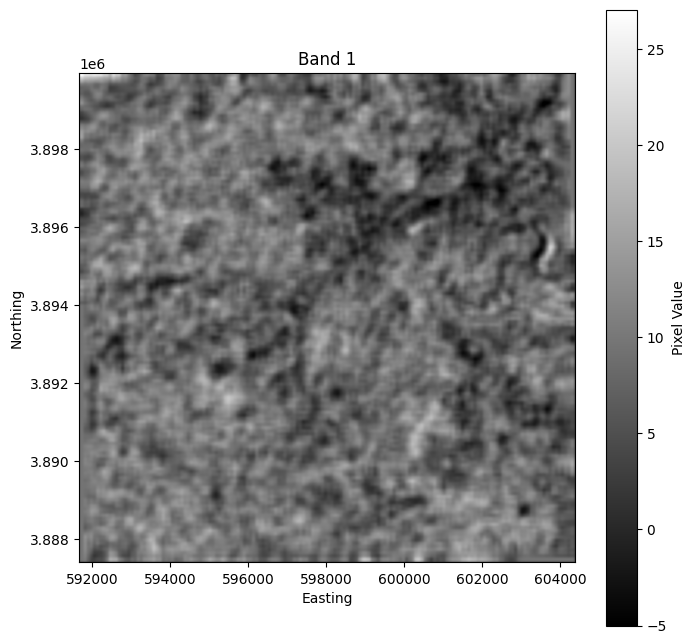

In [ ]:

# OUTPUT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/
# OUT_TIF_RIDGE = os.path.join(OUTPUT_DIR, "Stage3_Ridge_prediction.tif")
# OUT_TIF_MOE = os.path.join(OUTPUT_DIR, "Stage3_MoE_prediction.tif")
# OUT_TIF_DIFF = os.path.join(OUTPUT_DIR, "Stage3_Difference_Ridge_minus_MoE.tif")


import rasterio
import matplotlib.pyplot as plt
# Path to your raster
ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_Ridge_prediction.tif"

# Open the raster
with rasterio.open(ref_raster_path) as src:
    print("Raster info:")
    print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
    print(f"CRS: {src.crs}")

    # Read the first band
    band1 = src.read(1)

    # Optional: get extent for proper axis labeling
    extent = [
        src.bounds.left, src.bounds.right,
        src.bounds.bottom, src.bounds.top
    ]

# Plot the first band
plt.figure(figsize=(8,8))
plt.imshow(band1, cmap='gray', extent=extent)
plt.title("Band 1")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.colorbar(label="Pixel Value")
plt.show()


Raster info:
Width: 1272, Height: 1256, Bands: 1
CRS: EPSG:32616


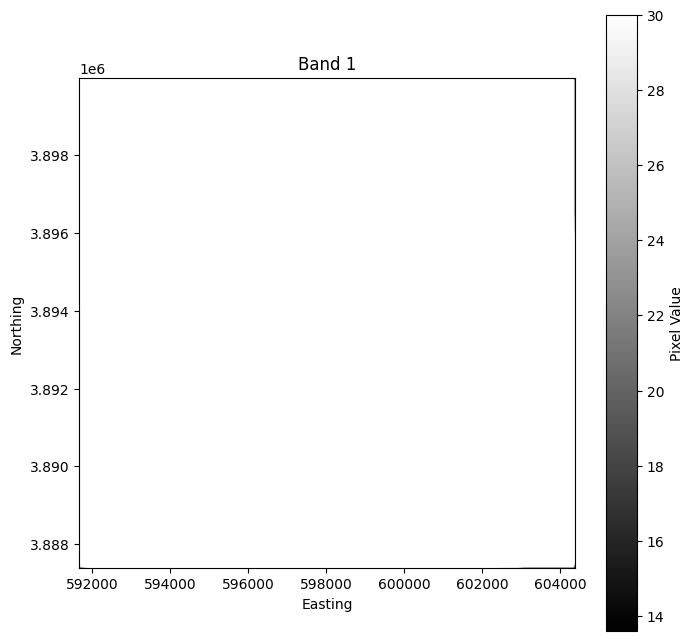

In [ ]:
import rasterio
import matplotlib.pyplot as plt
# Path to your raster
ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_MoE_prediction.tif"

# Open the raster
with rasterio.open(ref_raster_path) as src:
    print("Raster info:")
    print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
    print(f"CRS: {src.crs}")

    # Read the first band
    band1 = src.read(1)

    # Optional: get extent for proper axis labeling
    extent = [
        src.bounds.left, src.bounds.right,
        src.bounds.bottom, src.bounds.top
    ]

# Plot the first band
plt.figure(figsize=(8,8))
plt.imshow(band1, cmap='gray', extent=extent)
plt.title("Band 1")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.colorbar(label="Pixel Value")
plt.show()


In [ ]:
import rasterio
import numpy as np

def print_tif_summary_statistics(tif_path):
    """
    Reads a TIFF file and prints summary statistics for each band.
    """
    try:
        with rasterio.open(tif_path) as src:
            print(f"Summary Statistics for: {tif_path}")
            print(f"Number of bands: {src.count}")
            print(f"Image dimensions (width, height): {src.width}, {src.height}")
            print(f"Coordinate Reference System (CRS): {src.crs}")
            print(f"Bounds: {src.bounds}")

            for i in range(1, src.count + 1):
                band_data = src.read(i)

                # Filter out no-data values if defined
                if src.nodata is not None:
                    band_data = band_data[band_data != src.nodata]

                if band_data.size > 0:
                    print(f"\nBand {i}:")
                    print(f"  Mean: {np.mean(band_data):.2f}")
                    print(f"  Median: {np.median(band_data):.2f}")
                    print(f"  Min: {np.min(band_data):.2f}")
                    print(f"  Max: {np.max(band_data):.2f}")
                    print(f"  Standard Deviation: {np.std(band_data):.2f}")
                else:
                    print(f"\nBand {i}: No valid data found (possibly all no-data values).")

    except rasterio.errors.RasterioIOError as e:
        print(f"Error opening or reading TIFF file: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Example usage:
# Replace 'path/to/your/image.tif' with the actual path to your TIFF file
print_tif_summary_statistics("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_MoE_prediction.tif")

Summary Statistics for: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_MoE_prediction.tif
Number of bands: 1
Image dimensions (width, height): 1272, 1256
Coordinate Reference System (CRS): EPSG:32616
Bounds: BoundingBox(left=591660.0, bottom=3887400.0, right=604380.0, top=3899960.0)

Band 1:
  Mean: 29.99
  Median: 30.00
  Min: 13.60
  Max: 30.00
  Standard Deviation: 0.28


In [ ]:
# # -----------------------------
# # Stage-3: Full inference with hierarchical fusion v2
# # Compatible with improved Stage 2 (max+mean pooling, deeper transformer)
# # Using geographically-aligned preprocessed chips
# # -----------------------------
# import os
# from glob import glob
# from collections import defaultdict
# import re
# import numpy as np
# import rasterio
# from tqdm import tqdm
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from scipy.ndimage import gaussian_filter

# # ------------------- CONFIG -------------------
# PATCH_SIZE = 32
# OVERLAP = 0.75
# STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # 8 pixels

# PATCH_EMBED_PATCH = 4
# TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
# TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
# EMBED_DIM = 128
# NUM_MODALITIES = 8

# # Paths
# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/inference_chips_aligned"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_hierarchical_v3.tif"

# # Modality mappings
# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# eo_map = {
#     "s1Ascending": "s1",
#     "S2Composite": "s2",
#     "S2Indices": "s2idx",
#     "DEMindices": "dem",
#     "landsatTasseledCapIndices": "tcap",
#     "HLS": "hls",
#     "LandsatComposite": "landsat",
#     "LandsatIndices": "landsatidx",
# }
# BANDS_PER_COV = {'s1':4,'s2':6,'s2idx':8,'landsat':6,'landsatidx':7,
#                  'hls':7,'tcap':6,'dem':2}

# # Model paths
# ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
# FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_hierarchical_fusion_v2.pth"  # ← v2 model

# # Output settings
# CLIP_MIN, CLIP_MAX = -5.0, 30.0  # Adjusted for your data range (-1 to 24m)
# USE_COSINE_TAPER = True
# COSINE_TAPER_WIDTH = 8
# FINAL_SIGMA = 2.0
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# print("Running Stage 3 (v2 Hierarchical) on device:", DEVICE)

# # ------------------- Stage-1 encoder (ViT) -------------------
# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         x = self.proj(x)
#         x = x.flatten(2).transpose(1,2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self,x):
#         x_norm = self.norm1(x)
#         attn_out,_ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
#         self.norm = nn.LayerNorm(embed_dim)
#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         x = x.transpose(0,1)
#         for blk in self.blocks: x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]  # return tokens only [B, 64, 128]

# # ------------------- Stage-2 Hierarchical Fusion v2 -------------------
# # UPDATED to match v2 architecture with max+mean pooling
# class HierarchicalFusion(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=4, dropout=0.2):
#         super().__init__()

#         # Modality embeddings
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)

#         # Transformer (v2: wider, deeper)
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim * 2,  # ← v2: doubled for max+mean concat
#             nhead=nhead,
#             dim_feedforward=1024,   # ← v2: doubled
#             dropout=dropout,
#             activation='gelu',
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)

#         # Prediction head (v2: wider)
#         self.head = nn.Sequential(
#             nn.LayerNorm(embed_dim * 2),
#             nn.Linear(embed_dim * 2, 256),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, 128),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, 1)
#         )

#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)

#     def forward(self, modality_tokens):
#         # modality_tokens: [B, 8, 64, 128]
#         B = modality_tokens.shape[0]

#         # v2: Max + Mean pooling
#         modality_mean = modality_tokens.mean(dim=2)  # [B, 8, 128]
#         modality_max = modality_tokens.max(dim=2)[0]  # [B, 8, 128]
#         modality_embeds = torch.cat([modality_mean, modality_max], dim=-1)  # [B, 8, 256]

#         # Add modality type embeddings
#         mod_ids = torch.arange(8, device=modality_tokens.device)
#         mod_emb = self.mod_emb(mod_ids).unsqueeze(0).expand(B, -1, -1)
#         mod_emb = mod_emb.repeat(1, 1, 2)  # [B, 8, 256]
#         modality_embeds = modality_embeds + mod_emb

#         # Cross-modal fusion
#         fused = self.transformer(modality_embeds)  # [B, 8, 256]

#         # Global pooling
#         global_embed = fused.mean(dim=1)  # [B, 256]

#         # Predict
#         pred = self.head(global_embed)  # [B, 1]
#         return pred.squeeze(-1)

# # ------------------- Cosine Taper Window -------------------
# def create_cosine_taper_window(patch_size, taper_width):
#     """Create 2D cosine taper for smooth patch blending"""
#     window = np.ones((patch_size, patch_size), dtype=np.float32)
#     x = np.arange(taper_width)
#     taper = 0.5 - 0.5 * np.cos(np.pi * x / taper_width)
#     window[:taper_width, :] *= taper[:, None]
#     window[-taper_width:, :] *= taper[::-1, None]
#     window[:, :taper_width] *= taper[None, :]
#     window[:, -taper_width:] *= taper[::-1][None, :]
#     return window

# if USE_COSINE_TAPER:
#     TAPER_WINDOW = create_cosine_taper_window(PATCH_SIZE, COSINE_TAPER_WIDTH)
#     print(f"✓ Created cosine taper window")
# else:
#     TAPER_WINDOW = None

# # ------------------- Load encoders -------------------
# print("Loading encoders...")
# encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
# encoders = {}
# for eo in EO_LIST:
#     ck = torch.load(encoder_paths[eo], map_location=DEVICE, weights_only=False)
#     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
#     state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
#     enc.load_state_dict(state_dict)
#     enc.to(DEVICE).eval()
#     encoders[eo] = enc
# print(f"✓ Loaded {len(encoders)} encoders")

# # ------------------- Load Stage-2 v2 hierarchical fusion -------------------
# print("Loading hierarchical fusion model v2...")
# fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=DEVICE, weights_only=False)
# fusion_model = HierarchicalFusion(embed_dim=EMBED_DIM, num_modalities=NUM_MODALITIES, nlayers=4).to(DEVICE)
# state_dict = fusion_ckpt["model_state_dict"] if isinstance(fusion_ckpt, dict) and "model_state_dict" in fusion_ckpt else fusion_ckpt
# fusion_model.load_state_dict(state_dict)
# fusion_model.eval()
# print("✓ Loaded hierarchical fusion model v2")

# # ------------------- Index patches -------------------
# print("\nIndexing patch files by location...")
# patch_index = defaultdict(dict)
# pattern = re.compile(r'([^_]+)_(\d{4})_(\d{4})_(\d{4})\.tif')

# for filepath in glob(os.path.join(PATCH_FOLDER, '**/*.tif'), recursive=True):
#     filename = os.path.basename(filepath)
#     match = pattern.match(filename)
#     if match:
#         prefix = match.group(1)
#         row = int(match.group(3))
#         col = int(match.group(4))
#         if prefix in eo_map:
#             eo = eo_map[prefix]
#             patch_index[(row, col)][eo] = filepath

# complete_locations = [loc for loc, eo_dict in patch_index.items() if len(eo_dict) == len(EO_LIST)]
# print(f"✓ Found {len(complete_locations)} complete patch locations")

# # ------------------- Get reference raster info -------------------
# with rasterio.open(REFERENCE_RASTER) as ref:
#     ref_height, ref_width = ref.height, ref.width
#     ref_transform = ref.transform
#     ref_crs = ref.crs
#     ref_res = ref.res[0]

# print(f"Reference: {ref_height}×{ref_width} at {ref_res}m")

# # ------------------- Determine output grid -------------------
# rows = [loc[0] for loc in complete_locations]
# cols = [loc[1] for loc in complete_locations]
# min_row, max_row = min(rows), max(rows)
# min_col, max_col = min(cols), max(cols)

# output_height = (max_row - min_row) * STRIDE_PIX + PATCH_SIZE
# output_width = (max_col - min_col) * STRIDE_PIX + PATCH_SIZE

# print(f"Output: {output_height}×{output_width} (rows {min_row}-{max_row}, cols {min_col}-{max_col})")

# # Initialize output
# out_pred = np.zeros((output_height, output_width), dtype=np.float32)
# weight_sum = np.zeros((output_height, output_width), dtype=np.float32)

# # ------------------- Inference loop -------------------
# print(f"\nStarting hierarchical inference (v2 model)...")

# with torch.no_grad():
#     for (row, col) in tqdm(complete_locations, desc="Processing"):
#         # Collect tokens for all 8 modalities
#         patch_tokens = []
#         for eo in EO_LIST:
#             patch_path = patch_index[(row, col)][eo]
#             with rasterio.open(patch_path) as src:
#                 patch_data = src.read().astype(np.float32)
#             patch_tensor = torch.tensor(patch_data[np.newaxis, ...], dtype=torch.float32).to(DEVICE)
#             tokens = encoders[eo](patch_tensor)
#             patch_tokens.append(tokens)

#         # Stack and predict
#         modality_tokens = torch.stack(patch_tokens, dim=1)
#         patch_pred_scalar = fusion_model(modality_tokens).item()

#         # Create patch with prediction
#         patch_pred = np.full((PATCH_SIZE, PATCH_SIZE), patch_pred_scalar, dtype=np.float32)

#         # Apply cosine taper weighting
#         if USE_COSINE_TAPER:
#             patch_weight = TAPER_WINDOW.copy()
#         else:
#             patch_weight = np.ones((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)

#         # Accumulate with taper-weighted blending
#         i = (row - min_row) * STRIDE_PIX
#         j = (col - min_col) * STRIDE_PIX
#         h_end = min(i + PATCH_SIZE, output_height)
#         w_end = min(j + PATCH_SIZE, output_width)

#         out_pred[i:h_end, j:w_end] += patch_pred[:h_end-i, :w_end-j] * patch_weight[:h_end-i, :w_end-j]
#         weight_sum[i:h_end, j:w_end] += patch_weight[:h_end-i, :w_end-j]

# # Normalize
# out_pred /= np.maximum(weight_sum, 1e-6)

# # Apply smoothing
# if FINAL_SIGMA > 0:
#     print(f"Applying Gaussian smoothing (σ={FINAL_SIGMA})...")
#     out_pred = gaussian_filter(out_pred, sigma=FINAL_SIGMA)

# # Clip
# out_pred = np.clip(out_pred, CLIP_MIN, CLIP_MAX)

# print(f"\nPrediction stats: min={out_pred.min():.2f}, max={out_pred.max():.2f}, mean={out_pred.mean():.2f}")

# # Calculate geotransform
# out_transform = rasterio.Affine(
#     ref_res, 0.0, ref_transform.c + min_col * STRIDE_PIX * ref_res,
#     0.0, -ref_res, ref_transform.f - min_row * STRIDE_PIX * ref_res
# )

# # Write output
# os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
# with rasterio.open(
#     OUT_TIF, 'w',
#     driver='GTiff',
#     height=output_height, width=output_width,
#     count=1, dtype=np.float32,
#     crs=ref_crs,
#     transform=out_transform,
#     compress='lzw'
# ) as dst:
#     dst.write(out_pred, 1)

# print(f"\n✓ Inference complete!")
# print(f"✓ Output: {OUT_TIF}")
# print(f"✓ Size: {output_height}×{output_width} at {ref_res}m")

In [ ]:
# #11/30 Hierarchy (Stage2) to stage 3

# # -----------------------------
# # Stage-3: Full inference with hierarchical fusion
# # Using geographically-aligned preprocessed chips
# # Updated for hierarchical fusion model from Stage 2
# # -----------------------------
# import os
# from glob import glob
# from collections import defaultdict
# import re
# import numpy as np
# import rasterio
# from rasterio.windows import Window
# from tqdm import tqdm
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from scipy.ndimage import gaussian_filter

# # ------------------- CONFIG -------------------
# PATCH_SIZE = 32
# OVERLAP = 0.75
# STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # 8 pixels

# PATCH_EMBED_PATCH = 4
# TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
# TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
# EMBED_DIM = 128
# NUM_MODALITIES = 8

# # Paths
# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/inference_chips_aligned"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_hierarchical_v2.tif"

# # Modality mappings
# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# eo_map = {
#     "s1Ascending": "s1",
#     "S2Composite": "s2",
#     "S2Indices": "s2idx",
#     "DEMindices": "dem",
#     "landsatTasseledCapIndices": "tcap",
#     "HLS": "hls",
#     "LandsatComposite": "landsat",
#     "LandsatIndices": "landsatidx",
# }
# BANDS_PER_COV = {'s1':4,'s2':6,'s2idx':8,'landsat':6,'landsatidx':7,
#                  'hls':7,'tcap':6,'dem':2}

# # Model paths
# ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
# FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_hierarchical_fusion_v1.pth"

# # Output settings
# CLIP_MIN, CLIP_MAX = 0.0, 40.0
# FINAL_SIGMA = 1.0      # Light smoothing on final output
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print("Running Stage 3 (Hierarchical) on device:", DEVICE)

# # ------------------- Stage-1 encoder (ViT) -------------------
# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         x = self.proj(x)
#         x = x.flatten(2).transpose(1,2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self,x):
#         x_norm = self.norm1(x)
#         attn_out,_ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
#         self.norm = nn.LayerNorm(embed_dim)
#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         x = x.transpose(0,1)
#         for blk in self.blocks: x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]  # return tokens only [B, 64, 128]

# # ------------------- Stage-2 Hierarchical Fusion (NEW) -------------------
# class HierarchicalFusion(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=2, dropout=0.2):
#         super().__init__()

#         # Modality embeddings
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)

#         # Transformer for cross-modal fusion (operates on 8 modality embeddings)
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim,
#             nhead=nhead,
#             dim_feedforward=512,
#             dropout=dropout,
#             activation='gelu',
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)

#         # Prediction head
#         self.head = nn.Sequential(
#             nn.LayerNorm(embed_dim),
#             nn.Linear(embed_dim, 128),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(128, 64),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(64, 1)
#         )

#         # Initialize
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)

#     def forward(self, modality_tokens):
#         # modality_tokens: [B, 8, 64, 128]
#         B = modality_tokens.shape[0]

#         # Pool each modality's 64 tokens → 1 embedding per modality
#         modality_embeds = modality_tokens.mean(dim=2)  # [B, 8, 128]

#         # Add modality type embeddings
#         mod_ids = torch.arange(8, device=modality_tokens.device)
#         mod_emb = self.mod_emb(mod_ids).unsqueeze(0).expand(B, -1, -1)
#         modality_embeds = modality_embeds + mod_emb  # [B, 8, 128]

#         # Cross-modal fusion with transformer
#         fused = self.transformer(modality_embeds)  # [B, 8, 128]

#         # Global pooling across modalities
#         global_embed = fused.mean(dim=1)  # [B, 128]

#         # Predict
#         pred = self.head(global_embed)  # [B, 1]
#         return pred.squeeze(-1)

# # ------------------- Load encoders -------------------
# print("Loading encoders...")
# encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
# encoders = {}
# for eo in EO_LIST:
#     ck = torch.load(encoder_paths[eo], map_location=DEVICE, weights_only=False)
#     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
#     state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
#     enc.load_state_dict(state_dict)
#     enc.to(DEVICE).eval()
#     encoders[eo] = enc
# print(f"✓ Loaded {len(encoders)} encoders")

# # ------------------- Load Stage-2 hierarchical fusion -------------------
# print("Loading hierarchical fusion model...")
# fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=DEVICE, weights_only=False)
# fusion_model = HierarchicalFusion(embed_dim=EMBED_DIM, num_modalities=NUM_MODALITIES).to(DEVICE)
# state_dict = fusion_ckpt["model_state_dict"] if isinstance(fusion_ckpt, dict) and "model_state_dict" in fusion_ckpt else fusion_ckpt
# fusion_model.load_state_dict(state_dict)
# fusion_model.eval()
# print("✓ Loaded hierarchical fusion model")

# # ------------------- Index patches by (row, col) -------------------
# print("\nIndexing patch files by location...")
# patch_index = defaultdict(dict)
# pattern = re.compile(r'([^_]+)_(\d{4})_(\d{4})_(\d{4})\.tif')

# for filepath in glob(os.path.join(PATCH_FOLDER, '**/*.tif'), recursive=True):
#     filename = os.path.basename(filepath)
#     match = pattern.match(filename)
#     if match:
#         prefix = match.group(1)
#         year = match.group(2)
#         row = int(match.group(3))
#         col = int(match.group(4))

#         if prefix in eo_map:
#             eo = eo_map[prefix]
#             patch_index[(row, col)][eo] = filepath

# # Filter to complete locations
# complete_locations = [loc for loc, eo_dict in patch_index.items() if len(eo_dict) == len(EO_LIST)]
# print(f"✓ Found {len(complete_locations)} complete patch locations")

# # ------------------- Get reference raster info -------------------
# with rasterio.open(REFERENCE_RASTER) as ref:
#     ref_height, ref_width = ref.height, ref.width
#     ref_transform = ref.transform
#     ref_crs = ref.crs
#     ref_res = ref.res[0]

# print(f"Reference: {ref_height}×{ref_width} at {ref_res}m")

# # ------------------- Determine output grid -------------------
# rows = [loc[0] for loc in complete_locations]
# cols = [loc[1] for loc in complete_locations]
# min_row, max_row = min(rows), max(rows)
# min_col, max_col = min(cols), max(cols)

# output_height = (max_row - min_row) * STRIDE_PIX + PATCH_SIZE
# output_width = (max_col - min_col) * STRIDE_PIX + PATCH_SIZE

# print(f"Output: {output_height}×{output_width} (rows {min_row}-{max_row}, cols {min_col}-{max_col})")

# # Initialize output
# out_pred = np.zeros((output_height, output_width), dtype=np.float32)
# weight_sum = np.zeros((output_height, output_width), dtype=np.float32)

# # ------------------- Inference loop -------------------
# print(f"\nStarting hierarchical inference...")

# with torch.no_grad():
#     for (row, col) in tqdm(complete_locations, desc="Processing"):
#         # Collect tokens for all 8 modalities
#         patch_tokens = []

#         for eo in EO_LIST:
#             patch_path = patch_index[(row, col)][eo]
#             with rasterio.open(patch_path) as src:
#                 patch_data = src.read().astype(np.float32)

#             patch_tensor = torch.tensor(patch_data[np.newaxis, ...], dtype=torch.float32).to(DEVICE)
#             tokens = encoders[eo](patch_tensor)  # [1, 64, 128]
#             patch_tokens.append(tokens)

#         # Stack into [1, 8, 64, 128] format expected by hierarchical model
#         modality_tokens = torch.stack(patch_tokens, dim=1)  # [1, 8, 64, 128]

#         # Get single prediction per patch from hierarchical fusion
#         patch_pred_scalar = fusion_model(modality_tokens).item()  # Single float value

#         # Create uniform patch (since hierarchical model outputs one value per patch)
#         patch_pred = np.full((PATCH_SIZE, PATCH_SIZE), patch_pred_scalar, dtype=np.float32)

#         # Accumulate with overlap handling
#         i = (row - min_row) * STRIDE_PIX
#         j = (col - min_col) * STRIDE_PIX
#         h_end = min(i + PATCH_SIZE, output_height)
#         w_end = min(j + PATCH_SIZE, output_width)

#         out_pred[i:h_end, j:w_end] += patch_pred[:h_end-i, :w_end-j]
#         weight_sum[i:h_end, j:w_end] += 1.0

# # Normalize overlapping regions
# out_pred /= np.maximum(weight_sum, 1e-6)

# # Apply light smoothing to reduce blocking artifacts from patch boundaries
# if FINAL_SIGMA > 0:
#     out_pred = gaussian_filter(out_pred, sigma=FINAL_SIGMA)

# # Clip to valid range
# out_pred = np.clip(out_pred, CLIP_MIN, CLIP_MAX)

# print(f"\nPrediction stats: min={out_pred.min():.2f}, max={out_pred.max():.2f}, mean={out_pred.mean():.2f}")

# # Calculate geotransform
# out_transform = rasterio.Affine(
#     ref_res, 0.0, ref_transform.c + min_col * STRIDE_PIX * ref_res,
#     0.0, -ref_res, ref_transform.f - min_row * STRIDE_PIX * ref_res
# )

# # Write output
# os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
# with rasterio.open(
#     OUT_TIF, 'w',
#     driver='GTiff',
#     height=output_height, width=output_width,
#     count=1, dtype=np.float32,
#     crs=ref_crs,
#     transform=out_transform,
#     compress='lzw'
# ) as dst:
#     dst.write(out_pred, 1)

# print(f"\n✓ Inference complete!")
# print(f"✓ Output: {OUT_TIF}")
# print(f"✓ Size: {output_height}×{output_width} at {ref_res}m")

In [ ]:
# import rasterio
# import matplotlib.pyplot as plt
# # Path to your raster
# ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_hierarchical_v3.tif"

# # Open the raster
# with rasterio.open(ref_raster_path) as src:
#     print("Raster info:")
#     print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
#     print(f"CRS: {src.crs}")

#     # Read the first band
#     band1 = src.read(1)

#     # Optional: get extent for proper axis labeling
#     extent = [
#         src.bounds.left, src.bounds.right,
#         src.bounds.bottom, src.bounds.top
#     ]

# # Plot the first band
# plt.figure(figsize=(8,8))
# plt.imshow(band1, cmap='gray', extent=extent)
# plt.title("Band 1")
# plt.xlabel("Easting")
# plt.ylabel("Northing")
# plt.colorbar(label="Pixel Value")
# plt.show()


In [ ]:
# #11/29 WOrks well but not now outdated due to Hierarchy stage 2 change

# # -----------------------------
# # Stage-3: Full inference with enhanced smoothing
# # Using geographically-aligned preprocessed chips
# # -----------------------------
# import os
# from glob import glob
# from collections import defaultdict
# import re
# import numpy as np
# import rasterio
# from rasterio.windows import Window
# from tqdm import tqdm
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from scipy.ndimage import gaussian_filter

# # ------------------- CONFIG -------------------
# PATCH_SIZE = 32
# OVERLAP = 0.75
# STRIDE_PIX = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # 8 pixels

# PATCH_EMBED_PATCH = 4
# TOKENS_PER_ROW = PATCH_SIZE // PATCH_EMBED_PATCH  # 8
# TOKENS_PER_MODALITY = TOKENS_PER_ROW * TOKENS_PER_ROW  # 64
# EMBED_DIM = 128

# # Paths
# REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
# PATCH_FOLDER = "/content/inference_chips_aligned"
# OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed_v2.tif"

# # Modality mappings
# EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
# eo_map = {
#     "s1Ascending": "s1",
#     "S2Composite": "s2",
#     "S2Indices": "s2idx",
#     "DEMindices": "dem",
#     "landsatTasseledCapIndices": "tcap",
#     "HLS": "hls",
#     "LandsatComposite": "landsat",
#     "LandsatIndices": "landsatidx",
# }
# BANDS_PER_COV = {'s1':4,'s2':6,'s2idx':8,'landsat':6,'landsatidx':7,
#                  'hls':7,'tcap':6,'dem':2}

# # Model paths
# ENCODER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints"
# FUSION_MODEL_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_token_regressor_attn.pth"

# # Output settings
# CLIP_MIN, CLIP_MAX = 0.0, 40.0
# TOKEN_SIGMA = 2.0      # Smoothing on 8×8 token grid (anti-blocking)
# PATCH_SIGMA = 1.0      # Smoothing on 32×32 patch (final polish)
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print("Running Stage 3 on device:", DEVICE)

# # ------------------- Stage-1 encoder (ViT) -------------------
# class PatchEmbed(nn.Module):
#     def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
#         super().__init__()
#         self.patch_size = patch_size
#         self.num_patches = (img_size // patch_size) ** 2
#         self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#     def forward(self, x):
#         x = self.proj(x)
#         x = x.flatten(2).transpose(1,2)
#         return x

# class TransformerBlock(nn.Module):
#     def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
#         super().__init__()
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(embed_dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
#             nn.GELU(),
#             nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
#             nn.Dropout(dropout)
#         )
#     def forward(self,x):
#         x_norm = self.norm1(x)
#         attn_out,_ = self.attn(x_norm, x_norm, x_norm)
#         x = x + attn_out
#         x = x + self.mlp(self.norm2(x))
#         return x

# class ViTCustom(nn.Module):
#     def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
#         super().__init__()
#         self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
#         self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
#         self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
#         self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
#         self.norm = nn.LayerNorm(embed_dim)
#     def forward(self, x):
#         B = x.shape[0]
#         x = self.patch_embed(x)
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat([cls_tokens, x], dim=1)
#         x = x + self.pos_embed
#         x = x.transpose(0,1)
#         for blk in self.blocks: x = blk(x)
#         x = x.transpose(0,1)
#         x = self.norm(x)
#         return x[:,1:]  # return tokens only [B, 64, 128]

# # ------------------- Stage-2 Fusion -------------------
# class ModalityFusionTransformer(nn.Module):
#     def __init__(self, embed_dim=128, num_modalities=8, nhead=4, nlayers=3, dim_feedforward=512, dropout=0.1, max_pos=2048):
#         super().__init__()
#         self.embed_dim = embed_dim
#         self.mod_emb = nn.Embedding(num_modalities, embed_dim)
#         self.pos_emb = nn.Embedding(max_pos, embed_dim)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
#                                                    dim_feedforward=dim_feedforward,
#                                                    dropout=dropout, activation='gelu',
#                                                    batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
#         self.norm = nn.LayerNorm(embed_dim)
#         self.head = nn.Linear(embed_dim, 1)
#         nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)
#         nn.init.normal_(self.mod_emb.weight, mean=0.0, std=0.02)
#     def forward(self, x, seg_ids, mask):
#         B, T, D = x.shape
#         pos_idx = torch.arange(T, device=x.device).unsqueeze(0).expand(B,T)
#         pos_emb = self.pos_emb(pos_idx)
#         seg_ids_clamped = seg_ids.clone()
#         seg_ids_clamped[seg_ids_clamped < 0] = 0
#         mod_emb = self.mod_emb(seg_ids_clamped)
#         x = x + mod_emb + pos_emb
#         key_padding_mask = ~mask
#         x_enc = self.transformer(x, src_key_padding_mask=key_padding_mask)
#         x_enc = self.norm(x_enc)
#         token_logits = self.head(x_enc).squeeze(-1)
#         return token_logits

# # ------------------- Load encoders -------------------
# print("Loading encoders...")
# encoder_paths = {eo: os.path.join(ENCODER_DIR, f"encoder_{eo}.pth") for eo in EO_LIST}
# encoders = {}
# for eo in EO_LIST:
#     ck = torch.load(encoder_paths[eo], map_location=DEVICE)
#     enc = ViTCustom(in_channels=BANDS_PER_COV[eo], img_size=PATCH_SIZE)
#     state_dict = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
#     enc.load_state_dict(state_dict)
#     enc.to(DEVICE).eval()
#     encoders[eo] = enc
# print(f"✓ Loaded {len(encoders)} encoders")

# # ------------------- Load Stage-2 fusion -------------------
# print("Loading fusion model...")
# fusion_ckpt = torch.load(FUSION_MODEL_PATH, map_location=DEVICE)
# fusion_model = ModalityFusionTransformer(embed_dim=EMBED_DIM, num_modalities=len(EO_LIST)).to(DEVICE)
# state_dict = fusion_ckpt["model_state_dict"] if isinstance(fusion_ckpt, dict) and "model_state_dict" in fusion_ckpt else fusion_ckpt
# fusion_model.load_state_dict(state_dict)
# fusion_model.eval()
# print("✓ Loaded fusion model")

# # ------------------- Index patches by (row, col) -------------------
# print("\nIndexing patch files by location...")
# patch_index = defaultdict(dict)
# pattern = re.compile(r'([^_]+)_(\d{4})_(\d{4})_(\d{4})\.tif')

# for filepath in glob(os.path.join(PATCH_FOLDER, '**/*.tif'), recursive=True):
#     filename = os.path.basename(filepath)
#     match = pattern.match(filename)
#     if match:
#         prefix = match.group(1)
#         year = match.group(2)
#         row = int(match.group(3))
#         col = int(match.group(4))

#         if prefix in eo_map:
#             eo = eo_map[prefix]
#             patch_index[(row, col)][eo] = filepath

# # Filter to complete locations
# complete_locations = [loc for loc, eo_dict in patch_index.items() if len(eo_dict) == len(EO_LIST)]
# print(f"✓ Found {len(complete_locations)} complete patch locations")

# # ------------------- Get reference raster info -------------------
# with rasterio.open(REFERENCE_RASTER) as ref:
#     ref_height, ref_width = ref.height, ref.width
#     ref_transform = ref.transform
#     ref_crs = ref.crs
#     ref_res = ref.res[0]

# print(f"Reference: {ref_height}×{ref_width} at {ref_res}m")

# # ------------------- Determine output grid -------------------
# rows = [loc[0] for loc in complete_locations]
# cols = [loc[1] for loc in complete_locations]
# min_row, max_row = min(rows), max(rows)
# min_col, max_col = min(cols), max(cols)

# output_height = (max_row - min_row) * STRIDE_PIX + PATCH_SIZE
# output_width = (max_col - min_col) * STRIDE_PIX + PATCH_SIZE

# print(f"Output: {output_height}×{output_width} (rows {min_row}-{max_row}, cols {min_col}-{max_col})")

# # Initialize output
# out_pred = np.zeros((output_height, output_width), dtype=np.float32)
# weight_sum = np.zeros((output_height, output_width), dtype=np.float32)

# seg_ids_tensor = torch.cat([
#     torch.full((TOKENS_PER_MODALITY,), i, dtype=torch.long)
#     for i in range(len(EO_LIST))
# ], dim=0).unsqueeze(0).to(DEVICE)

# mask_tensor = torch.ones(1, len(EO_LIST) * TOKENS_PER_MODALITY, dtype=torch.bool).to(DEVICE)

# # ------------------- Inference loop -------------------
# print(f"\nStarting inference...")

# with torch.no_grad():
#     for (row, col) in tqdm(complete_locations, desc="Processing"):
#         patch_tokens = []

#         for eo in EO_LIST:
#             patch_path = patch_index[(row, col)][eo]
#             with rasterio.open(patch_path) as src:
#                 patch_data = src.read().astype(np.float32)

#             patch_tensor = torch.tensor(patch_data[np.newaxis, ...], dtype=torch.float32).to(DEVICE)
#             tokens = encoders[eo](patch_tensor)
#             patch_tokens.append(tokens)

#         tokens_stack = torch.cat(patch_tokens, dim=1)
#         token_preds = fusion_model(tokens_stack, seg_ids_tensor, mask_tensor)

#         # Reshape and average across modalities
#         token_preds_np = token_preds.cpu().numpy().reshape(len(EO_LIST), TOKENS_PER_ROW, TOKENS_PER_ROW)
#         token_mean = token_preds_np.mean(axis=0)  # [8, 8]

#         # CRITICAL: Smooth the 8×8 token grid BEFORE upsampling (anti-blocking)
#         token_mean_smooth = gaussian_filter(token_mean, sigma=TOKEN_SIGMA)

#         # Upsample with bicubic (smoother than bilinear)
#         patch_pred = F.interpolate(
#             torch.tensor(token_mean_smooth[None, None, ...]),
#             size=(PATCH_SIZE, PATCH_SIZE),
#             mode='bicubic',
#             align_corners=False
#         ).squeeze().numpy()

#         # Final smoothing on upsampled patch
#         patch_pred = gaussian_filter(patch_pred, sigma=PATCH_SIGMA)

#         # Accumulate
#         i = (row - min_row) * STRIDE_PIX
#         j = (col - min_col) * STRIDE_PIX
#         h_end = min(i + PATCH_SIZE, output_height)
#         w_end = min(j + PATCH_SIZE, output_width)

#         out_pred[i:h_end, j:w_end] += patch_pred[:h_end-i, :w_end-j]
#         weight_sum[i:h_end, j:w_end] += 1.0

# # Normalize and clip
# out_pred /= np.maximum(weight_sum, 1e-6)
# out_pred = np.clip(out_pred, CLIP_MIN, CLIP_MAX)

# print(f"\nPrediction stats: min={out_pred.min():.2f}, max={out_pred.max():.2f}, mean={out_pred.mean():.2f}")

# # Calculate geotransform
# out_transform = rasterio.Affine(
#     ref_res, 0.0, ref_transform.c + min_col * STRIDE_PIX * ref_res,
#     0.0, -ref_res, ref_transform.f - min_row * STRIDE_PIX * ref_res
# )

# # Write output
# os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
# with rasterio.open(
#     OUT_TIF, 'w',
#     driver='GTiff',
#     height=output_height, width=output_width,
#     count=1, dtype=np.float32,
#     crs=ref_crs,
#     transform=out_transform,
#     compress='lzw'
# ) as dst:
#     dst.write(out_pred, 1)

# print(f"\n✓ Inference complete!")
# print(f"✓ Output: {OUT_TIF}")
# print(f"✓ Size: {output_height}×{output_width} at {ref_res}m")

In [ ]:
# import rasterio
# import matplotlib.pyplot as plt

# # Path to your raster
# ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction_smoothed_v2.tif"

# # Open the raster
# with rasterio.open(ref_raster_path) as src:
#     print("Raster info:")
#     print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
#     print(f"CRS: {src.crs}")

#     # Read the first band
#     band1 = src.read(1)

#     # Optional: get extent for proper axis labeling
#     extent = [
#         src.bounds.left, src.bounds.right,
#         src.bounds.bottom, src.bounds.top
#     ]

# # Plot the first band
# plt.figure(figsize=(8,8))
# plt.imshow(band1, cmap='gray', extent=extent)
# plt.title("Band 1")
# plt.xlabel("Easting")
# plt.ylabel("Northing")
# plt.colorbar(label="Pixel Value")
# plt.show()


# Stage 4 Indepent in situ Evalution Metrics

Dynamic python version

In [ ]:
import pandas as pd
# from ace_tools import display_dataframe_to_user

#https://docs.google.com/spreadsheets/d/1hSFECw5vh-yO-ip6uw8cpyzhwLnrP9VLU2PXPnC2qWo/edit?gid=631144453#gid=631144453

data = {
    "Site": [25, 29, 60, 44, 46, 41, 49, 58, 56, 16],
    "centroid_lon": [-85.93488029, -85.93505337, -85.94774365, -85.94820537, -85.94866338,
                     -85.94911995, -85.94958109, -85.95003676, -85.95049673, -85.94962888],
    "centroid_lat": [35.16449572, 35.16564874, 35.2212628, 35.22091256, 35.22056428,
                     35.2202168, 35.21986693, 35.21951997, 35.21917077, 35.21747895],
    "Avg_Plot_Ht": [17.62, 15.77058824, 13.53125, 16.8452381, 15.79583333,
                    15.87222222, 14.04, 14.31176471, 12.896, 11.81],
    "Std_Plot_Ht" :[8.413058633,7.814071019,4.402986676,0.372992108,4.653421291,
                    6.52378504,5.211525688,6.897633865,4.932754471,5.660560813]
}

in_situ_df = pd.DataFrame(data)


in_situ_df

,Site,centroid_lon,centroid_lat,Avg_Plot_Ht,Std_Plot_Ht
0,25,-85.934880,35.164496,17.620000,8.413059
1,29,-85.935053,35.165649,15.770588,7.814071
2,60,-85.947744,35.221263,13.531250,4.402987
3,44,-85.948205,35.220913,16.845238,0.372992
4,46,-85.948663,35.220564,15.795833,4.653421
5,41,-85.949120,35.220217,15.872222,6.523785
6,49,-85.949581,35.219867,14.040000,5.211526
7,58,-85.950037,35.219520,14.311765,6.897634
8,56,-85.950497,35.219171,12.896000,4.932754
9,16,-85.949629,35.217479,11.810000,5.660561


In [ ]:
import rasterio

pred_raster = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_Ridge_prediction.tif"

src = rasterio.open(pred_raster)


In [ ]:
from shapely.geometry import Point

pred_values = []

for i, row in in_situ_df.iterrows():
    pt = Point(row['centroid_lon'], row['centroid_lat'])

    # Convert lat/lon → raster row/col
    rowcol = src.index(pt.x, pt.y)

    # Read the pixel value
    value = src.read(1)[rowcol[0], rowcol[1]]

    pred_values.append(value)

in_situ_df['pred'] = pred_values


IndexError: index 389992 is out of bounds for axis 0 with size 1256

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

obs = in_situ_df['Avg_Plot_Ht']
pred = in_situ_df['pred']

rmse = np.sqrt(mean_squared_error(obs, pred))
mae = mean_absolute_error(obs, pred)
bias = np.mean(pred - obs)
r2 = r2_score(obs, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("Bias:", bias)
print("R²:", r2)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(obs, pred)
plt.xlabel("Observed Avg Plot Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("Observed vs Predicted")
plt.grid(True)
plt.show()


In [ ]:
residuals = pred - obs

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.xlabel("Residual (Pred - Obs)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(obs, pred)

# 1:1 line
min_v = min(obs.min(), pred.min())
max_v = max(obs.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')

plt.xlabel("Observed Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("1:1 Line Comparison")
plt.grid(True)
plt.show()


GEE

In [ ]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()

In [ ]:
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain').geometry().buffer(300)
in_situ = ee.FeatureCollection("projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Field_2025_Campaign_Cross_Site_Merged_Data_Combined_Heights")
pred_img = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/Stage3_Ridge_prediction")
Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(in_situ, {}, 'in_situ')
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [ ]:
# Identify predicted band name
pred_band = pred_img.bandNames().get(0).getInfo()
print("Prediction band:", pred_band)

Prediction band: b1


In [ ]:
# Sample predicted raster at plot locations
samples = pred_img.sampleRegions(
    collection=in_situ,
    properties=['Avg_Plot_Ht'],
    scale=10,
    geometries=False
)


In [ ]:
import pandas as pd

# Convert each feature to a dict
rows = []
for f in samples.getInfo()['features']:
    p = f['properties']
    rows.append({
        'obs': p['Avg_Plot_Ht'],
        'pred': p[pred_band]
    })

df = pd.DataFrame(rows)
df.head()


,obs,pred
0,17.620001,3.066374
1,15.770588,4.793407
2,13.531250,10.862712
3,16.845238,10.885214
4,15.795833,12.192202


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

obs = df['obs']
pred = df['pred']

mae = mean_absolute_error(obs, pred)
rmse = np.sqrt(mean_squared_error(obs, pred))
bias = np.mean(pred - obs)
r2 = r2_score(obs, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("Bias:", bias)
print("R²  :", r2)


MAE : 5.299388955043945
RMSE: 6.664408614759764
Bias: -5.299388955043945
R²  : -13.713796007792848


Metric	Meaning	Good Values

RMSE	Average error magnitude, sensitive to
large errors	Lower = better

MAE	More robust average error	Lower = better

Bias	Mean (pred - obs) — directional error	Near 0 = good

R²	Variance explained	Closer to 1 = better

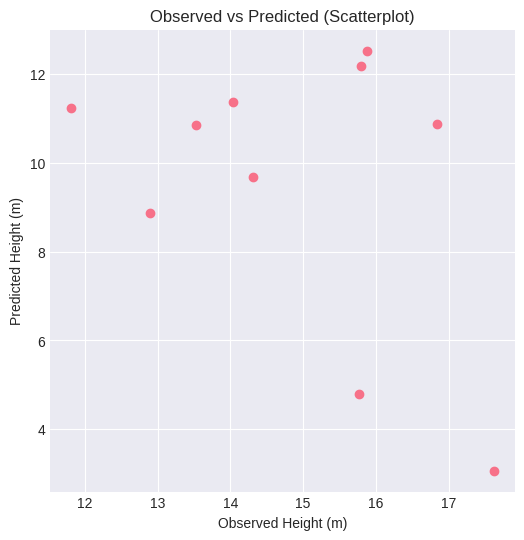

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df['obs'], df['pred'])
plt.xlabel("Observed Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("Observed vs Predicted (Scatterplot)")
plt.grid(True)
plt.show()


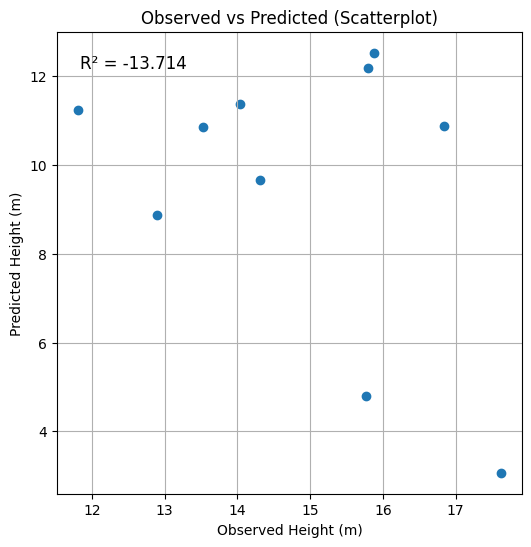

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

obs = df['obs']
pred = df['pred']

# Compute R²
r2 = r2_score(obs, pred)

plt.figure(figsize=(6,6))
plt.scatter(obs, pred)

plt.xlabel("Observed Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("Observed vs Predicted (Scatterplot)")

# Annotate R² on plot
plt.text(
    0.05, 0.95,                # position in axis fraction (5% from left, 5% from top)
    f"R² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.grid(True)
plt.show()


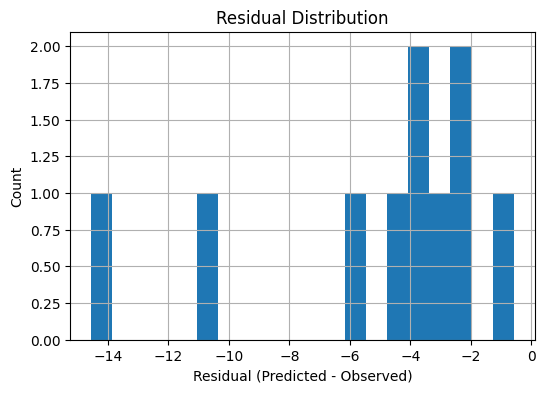

In [ ]:
residuals = df['pred'] - df['obs']

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.xlabel("Residual (Predicted - Observed)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()


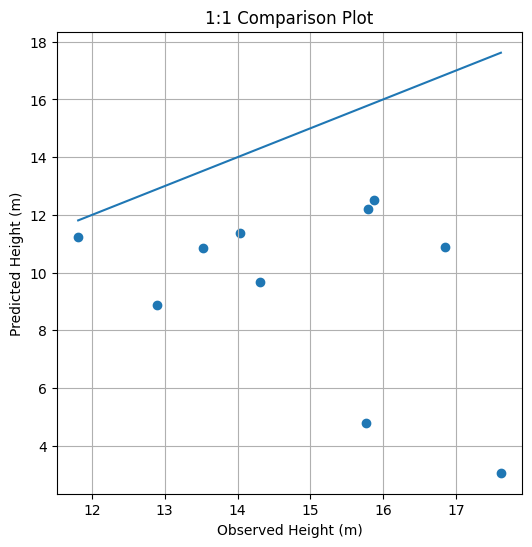

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df['obs'], df['pred'])
plt.plot([df['obs'].min(), df['obs'].max()],
         [df['obs'].min(), df['obs'].max()])
plt.xlabel("Observed Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("1:1 Comparison Plot")
plt.grid(True)
plt.show()


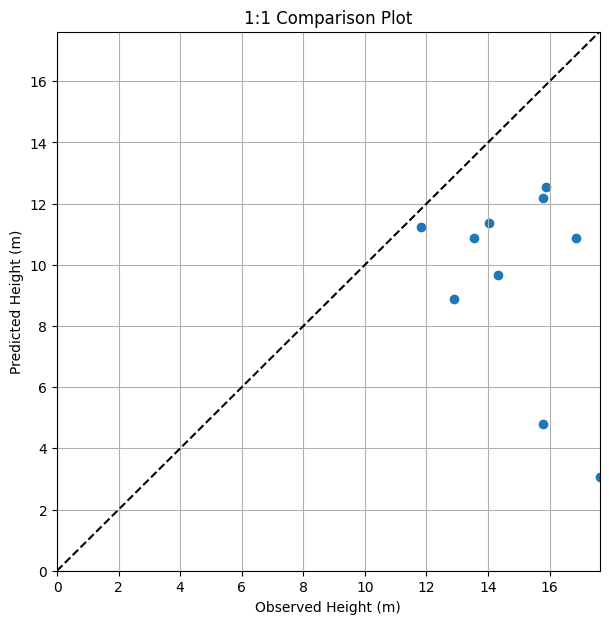

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(df['obs'], df['pred'])

# Force axes to start at 0
min_val = 0
max_val = max(df['obs'].max(), df['pred'].max())

# 1:1 line from (0,0) to (max,max)
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("Observed Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("1:1 Comparison Plot")
plt.grid(True)
plt.show()


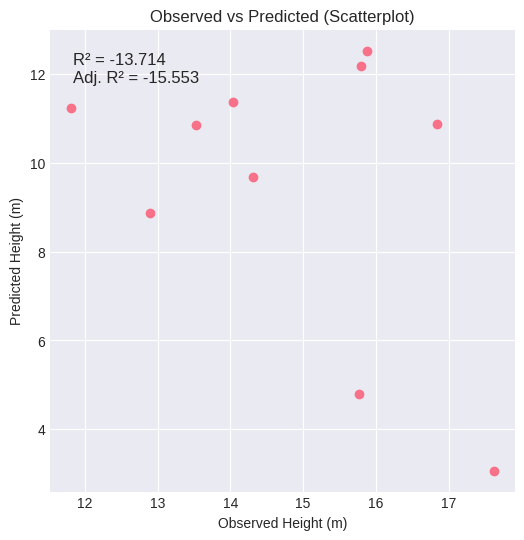

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

obs = df['obs']
pred = df['pred']

# Compute R²
r2 = r2_score(obs, pred)

# Compute Adjusted R²
n = len(df)
p = 1   # number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

plt.figure(figsize=(6,6))
plt.scatter(obs, pred)

plt.xlabel("Observed Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("Observed vs Predicted (Scatterplot)")

# Annotate R² values
plt.text(
    0.05, 0.95,
    f"R² = {r2:.3f}\nAdj. R² = {adj_r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.grid(True)
plt.show()


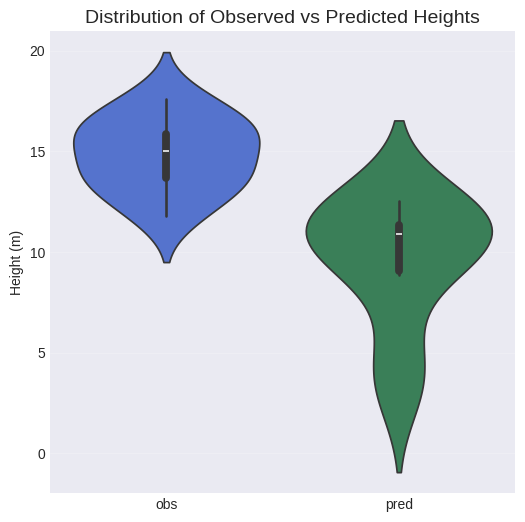

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Melt the data so seaborn can color by variable
plot_df = df[['obs', 'pred']].melt(
    var_name='Type',
    value_name='Height'
)

plt.figure(figsize=(6,6))
sns.violinplot(
    data=plot_df,
    x='Type',
    y='Height',
    palette={'obs': 'royalblue', 'pred': 'seagreen'}
)

plt.title("Distribution of Observed vs Predicted Heights", fontsize=14)
plt.ylabel("Height (m)")
plt.xlabel("")
plt.grid(axis='y', alpha=0.2)

plt.show()
